In [1]:
import pandas as pd
df = pd.read_csv('../data/tima_cleaned_data_v1.csv')
df

,STT,application_date,TS_CREDIT_SCORE_V2,Số điện thoại khách hàng,FromDate,ID,LoanID,Số tiền đăng ký vay ban đầu,Tiền giải ngân,Tiền gốc còn lại,...,AgeGroup,LoanTermMonths,ProcessingDays,LoanToIncomeRatio,Cần Giải Ngân,Đã trả/khoản vay đã giải ngân,LowCreditScore,CreditScoreGroup,IncomeBracket,LoanStatus
0,2,NaN,403,977966899,2016-06-24,40,16104,10000000.0,10000000.0,10000000.0,...,NaN,1,NaN,1.30,0.0,1.00,1,Low (High Risk),5-10m,Đang vay
1,3,2016-07-28,403,977966899,2016-07-28,226,20871,10000000.0,10000000.0,0.0,...,26-35,8,0.0,1.30,0.0,0.00,1,Low (High Risk),5-10m,Hoàn thành
2,4,2016-06-29,531,397511119,2016-06-29,45,17049,5000000.0,5000000.0,5000000.0,...,NaN,6,0.0,0.19,0.0,1.00,1,Low (High Risk),>=25m,Hoàn thành
3,5,2016-06-29,588,abc1234567,2016-06-29,48,17067,10000000.0,10000000.0,10000000.0,...,26-35,4,0.0,1.25,0.0,1.00,1,Low (High Risk),5-10m,Hoàn thành
4,6,2016-08-05,675,966710180,2016-08-05,293,22390,10000000.0,10000000.0,0.0,...,26-35,4,0.0,0.83,0.0,0.00,0,Medium,10-15m,Hoàn thành
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,3181,2018-12-24,577,353833091,2018-12-24,327685,56967,5000000.0,5000000.0,1814424.0,...,18-25,3,0.0,0.67,0.0,0.36,1,Low (High Risk),5-10m,Đang vay
2379,3182,2018-12-22,638,967295514,2018-12-22,329444,56835,3000000.0,3000000.0,3000000.0,...,NaN,2,0.0,0.38,0.0,1.00,0,Medium,5-10m,Hoàn thành
2380,3184,2018-12-27,605,385669091,2018-12-27,333862,57212,6000000.0,6000000.0,6000000.0,...,26-35,3,0.0,0.75,0.0,1.00,0,Medium,5-10m,Hoàn thành
2381,3187,2019-01-10,597,869625266,2019-01-10,348341,57938,7000000.0,6000000.0,6000000.0,...,26-35,3,0.0,0.58,1000000.0,1.00,1,Low (High Risk),10-15m,Hoàn thành


#**PHÂN TÍCH ĐƠN BIẾN**`

#**NHÓM 1 — Các biến lõi về khoản vay (Loan Core Fields)**

##**Tiền giải ngân**

1. Số tiền giải ngân trung bình (mean), trung vị (median) là bao nhiêu?

2. Phân phối của số tiền giải ngân trông như thế nào? (Có nhiều khoản vay nhỏ hay không?)

3. Có tồn tại outlier không? Nếu có, mức độ nghiêm trọng ra sao?

4. Khách hàng vay chủ yếu ở mức bao nhiêu tiền?

In [2]:
# Số tiền giải ngân trung bình (mean), trung vị (median) là bao nhiêu?
df['Tiền giải ngân'].describe().to_frame().style.format("{:,.0f}")

,Tiền giải ngân
count,"2,383"
mean,"11,739,059"
std,"46,961,329"
min,"1,000,000"
25%,"5,000,000"
50%,"8,000,000"
75%,"10,000,000"
max,"1,599,735,000"


**Insight 1 — Median thấp hơn Mean → phân phối lệch phải mạnh**

Giá trị trung bình 11.7 triệu, nhưng median chỉ 8 triệu.

Điều này cho thấy một số khoản vay rất lớn đã kéo mean tăng cao.

Phần lớn khách hàng vay quanh mức 5–10 triệu, nhưng có vài khoản vay bất thường lên đến 1.6 tỷ.

--> Tóm lại: median mới phản ánh đúng mức vay nhiều nhất, không phải mean.

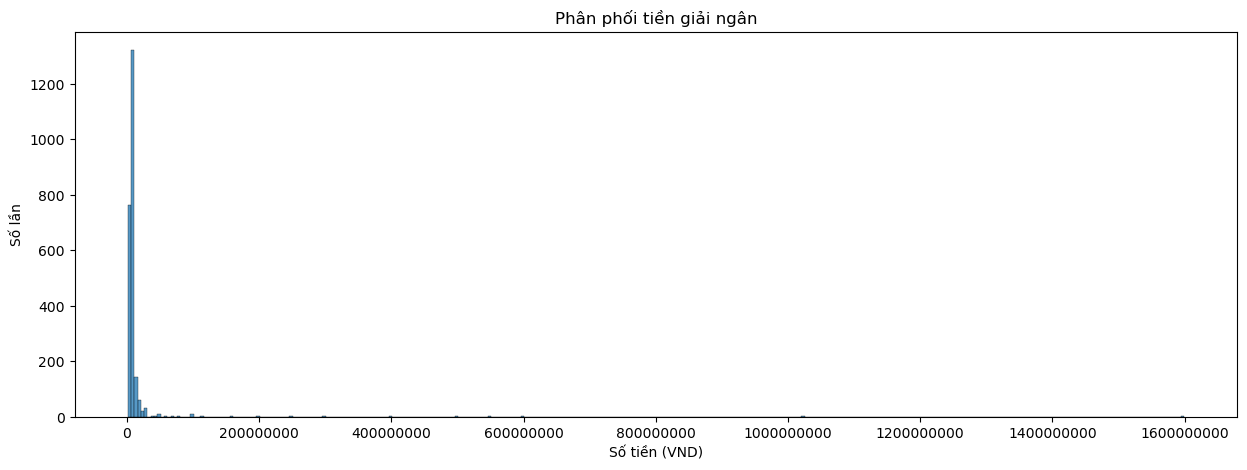

In [3]:
#Phân phối của số tiền giải ngân trông như thế nào? (Có nhiều khoản vay nhỏ hay không?)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))
sns.histplot(df['Tiền giải ngân'], binwidth=5000000) #Chia thành các cột khoảng giá trị, mỗi cột đại diện cho 5tr)
plt.title("Phân phối tiền giải ngân")
plt.xlabel("Số tiền (VND)")
plt.ylabel("Số lần")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 2 — Phần lớn khoản vay tập trung dưới 20 triệu**

Gần như toàn bộ các cột dồn lại ngay vùng 1–20 triệu.

Đây là dấu hiệu của thị trường vay tiêu dùng nhỏ:
→ vay nhanh, vay mua sắm, vay tiêu dùng cá nhân.

**Insight 3 — Phân phối cực kỳ lệch phải (right-skewed)**

Ở bên phải xuất hiện các khoản vay từ 200 triệu --> 1.6 tỷ.

Mặc dù số lượng rất nhỏ, nhưng tạo thành đuôi kéo dài → đúng mô hình long-tail distribution.

--> Đây là đặc trưng của dữ liệu tín dụng: số đông vay nhỏ, vài khách vay rất lớn.

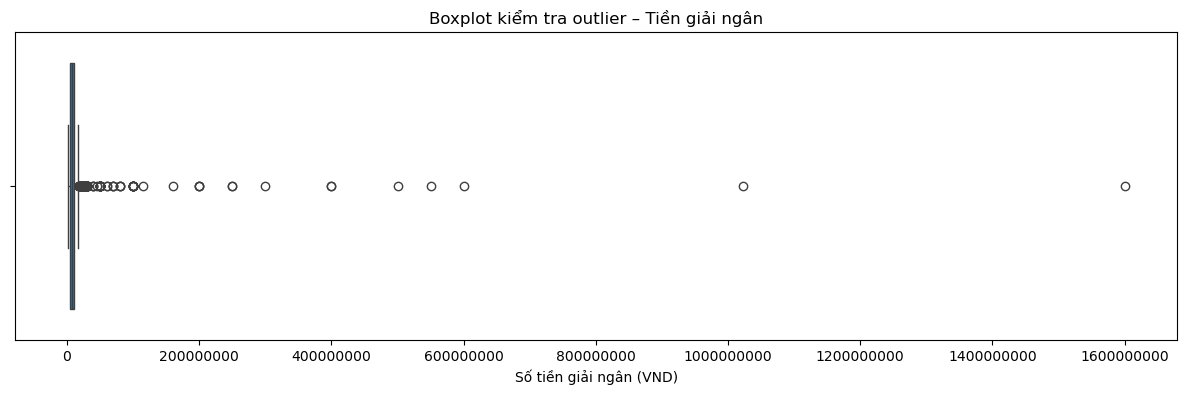

In [4]:
#Kiểm tra outlier
plt.figure(figsize=(15,4))
sns.boxplot(x=df['Tiền giải ngân'])
plt.title("Boxplot kiểm tra outlier – Tiền giải ngân")
plt.xlabel("Số tiền giải ngân (VND)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 4 — Có rất nhiều outlier và đa phần là outlier cực lớn*8

Outlier xuất hiện từ 30–50 triệu trở lên.

Các dấu chấm rời rạc kéo dài đến 200–500 triệu và một vài điểm tới 1.6 tỷ.

**Insight 5 — Phân phối tiền giải ngân có độ biến thiên cực lớn**

Std = 47 triệu, gấp 4 lần mean --> độ phân tán rất lớn.

Điều này cho thấy mức vay giữa các khách hàng khác nhau rất nhiều.

**Insight 6 — Các outlier cực lớn cần được xem xét riêng**

--> Outlier lớn ảnh hưởng mạnh đến mô hình ML nên phải xử lý (winsorize, log-transform).

In [5]:
#Mức vay phổ biển nhất
df['Tiền giải ngân'].mode()

0    10000000.0
Name: Tiền giải ngân, dtype: float64

**Insight 7 — 10 triệu là mức vay phổ biến nhất**

Đây là mức vay mà nhiều khách chọn nhất trong dataset.

Cùng với median = 8 triệu --> xác nhận khách hàng TIMA phần lớn thuộc phân khúc vay tiêu dùng nhỏ <15 triệu.

###**Insight tổng**
Số tiền giải ngân thực tế của khách hàng TIMA tập trung mạnh ở các khoản vay nhỏ, điển hình trong khoảng 5–10 triệu, với median 8 triệu và mức vay phổ biến nhất là 10 triệu. Phân phối nghiêng phải rất mạnh: phần lớn khách vay số tiền thấp, nhưng tồn tại một số khoản vay cực lớn (lên tới 1.6 tỷ), khiến giá trị trung bình bị kéo lên cao không phản ánh đúng hành vi vay điển hình. Biểu đồ histogram và boxplot cho thấy số lượng outlier lớn khá nhiều, chủ yếu ở nhóm vay rất cao, cho thấy tập khách hàng có sự phân tầng rõ rệt giữa nhóm vay tiêu dùng nhỏ và một vài trường hợp vay giá trị lớn. Đối với phần lớn khách hàng, khoản vay giải ngân tương đối ổn định và nhất quán, phù hợp mô hình vay tín chấp tiêu dùng của TIMA; trong khi đó các khoản vay lớn cần được xem xét riêng trong quản trị rủi ro và mô hình hóa.

##**Số tiền đăng ký vay ban đầu**

1. Khách hàng thường yêu cầu vay bao nhiêu?

2. Trung bình – trung vị – min – max ra sao?

3. Phân phối của số tiền đăng ký vay trông như thế nào?

4. Có khác biệt gì so với TienGiaiNgan (số tiền được giải ngân)?

5. Có outlier không – mức độ lớn hay nhỏ?

In [6]:
#Khách hàng thường yêu cầu vay bao nhiêu?
df['Số tiền đăng ký vay ban đầu'].mode()

0    10000000.0
Name: Số tiền đăng ký vay ban đầu, dtype: float64

In [7]:
df['Số tiền đăng ký vay ban đầu'].value_counts().head(5).to_frame()

,count
Số tiền đăng ký vay ban đầu,
10000000.0,1130
3000000.0,193
5000000.0,189
2500000.0,142
8000000.0,103


**Insight 1 — Mức khách hàng yêu cầu vay phổ biến nhất là 10 triệu**

Đây là mode của dữ liệu.

Cũng là mức có số lượng tuyệt đối cao hơn hẳn (1,130 hồ sơ).

Xác nhận rằng đa số khách TIMA thuộc phân khúc vay tiêu dùng nhỏ (small-ticket loans).

**Insight 2 — Tập trung mạnh ở nhóm 3–10 triệu**

→ Thói quen vay rất rõ ràng: vay khoản nhỏ – phục vụ tiêu dùng ngắn hạn.

In [8]:
#Trung bình – trung vị – min – max ra sao?
df['Số tiền đăng ký vay ban đầu'].describe().to_frame().style.format("{:,.0f}")

,Số tiền đăng ký vay ban đầu
count,"2,383"
mean,"12,814,071"
std,"46,768,176"
min,"100,000"
25%,"6,000,000"
50%,"10,000,000"
75%,"10,000,000"
max,"1,553,290,000"


**Insight 3 — Median = 10 triệu, mean cao hơn (gần 12.8 triệu)**

Mean > Median → phân phối lệch phải.

Vài khoản vay rất lớn kéo trung bình lên.

**Insight 4 — 50% khách yêu cầu vay từ 6–10 triệu**

--> Cực kỳ tập trung trong dải nhỏ.

**Insight 5 — Có yêu cầu vay cực kỳ lớn tới 1.55 tỷ**

--> Đây chắc chắn không phải khoản vay tiêu dùng bình thường.

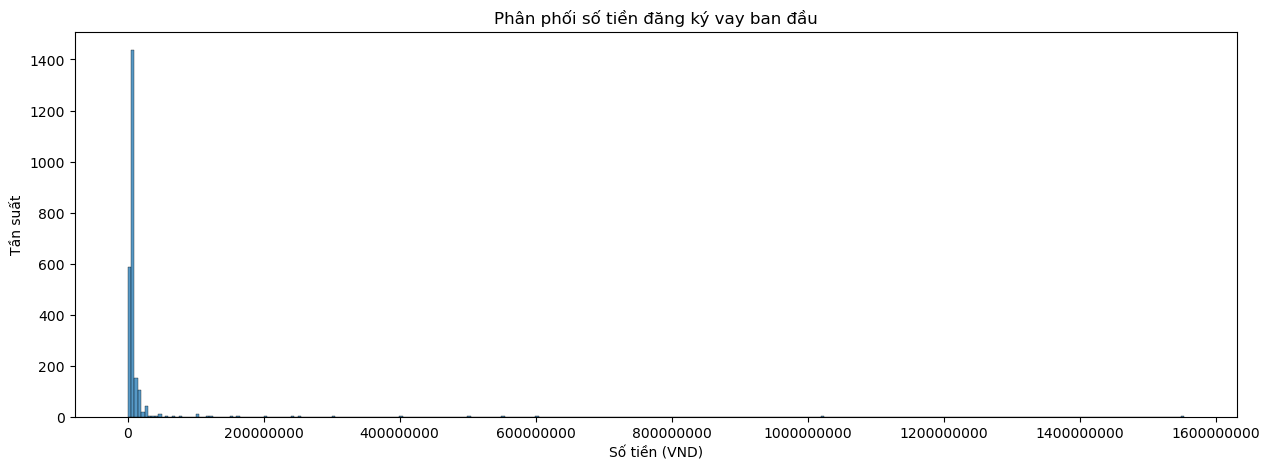

In [9]:
#Phân phối số tiền đăng ký vay ban đầu
plt.figure(figsize=(15,5))
sns.histplot(df['Số tiền đăng ký vay ban đầu'], binwidth=5000000)
plt.title("Phân phối số tiền đăng ký vay ban đầu")
plt.xlabel("Số tiền (VND)")
plt.ylabel("Tần suất")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 6 — Phân phối nghiêng phải cực mạnh (right-skewed)**

Hầu hết khách vay từ 1–20 triệu.

Các cột histogram dồn hết sang mé trái.

Phần đuôi (tail) trải rất dài về phía bên phải — từ 200 triệu tới 1.5 tỷ.

**Insight 7 — Khoản vay nhỏ chiếm đại đa số**

Biểu đồ cho thấy:

Khoản vay < 10 triệu chiếm phần lớn tổng mẫu.

--> Một đặc trưng quan trọng của dataset và sản phẩm vay TIMA.

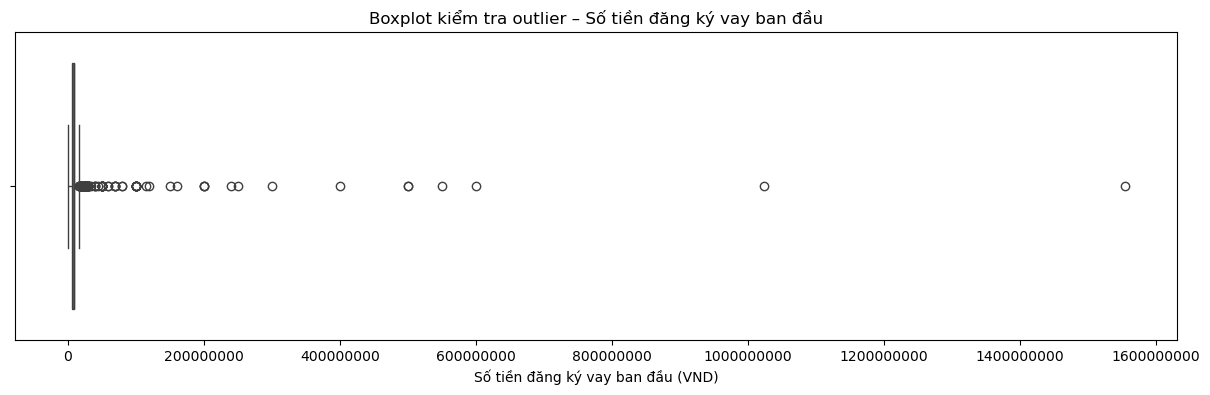

In [10]:
#Kiểm tra outlier
plt.figure(figsize=(15,4))
sns.boxplot(x=df['Số tiền đăng ký vay ban đầu'])
plt.title("Boxplot kiểm tra outlier – Số tiền đăng ký vay ban đầu")
plt.xlabel("Số tiền đăng ký vay ban đầu (VND)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

**Insight 11 — Có rất nhiều outlier, chủ yếu là outlier lớn**

Outlier kéo dài từ 30 triệu → 100–200 triệu

Một vài duy nhất đạt 1.55 tỷ

**Insight 12 — Mức độ outlier rất nghiêm trọng, không thể bỏ qua**

Độ lệch chuẩn (46 triệu) lớn gần gấp 4 lần median (10 triệu).

Điều này khiến mean mất tính đại diện → phải dùng median.

**Insight 13 — Phân phối tiền đăng ký vay ban đầu có đuôi dài hơn tiền giải ngân**

--> Cho thấy nhiều khách yêu cầu vay cao, nhưng không phải ai cũng được duyệt full.

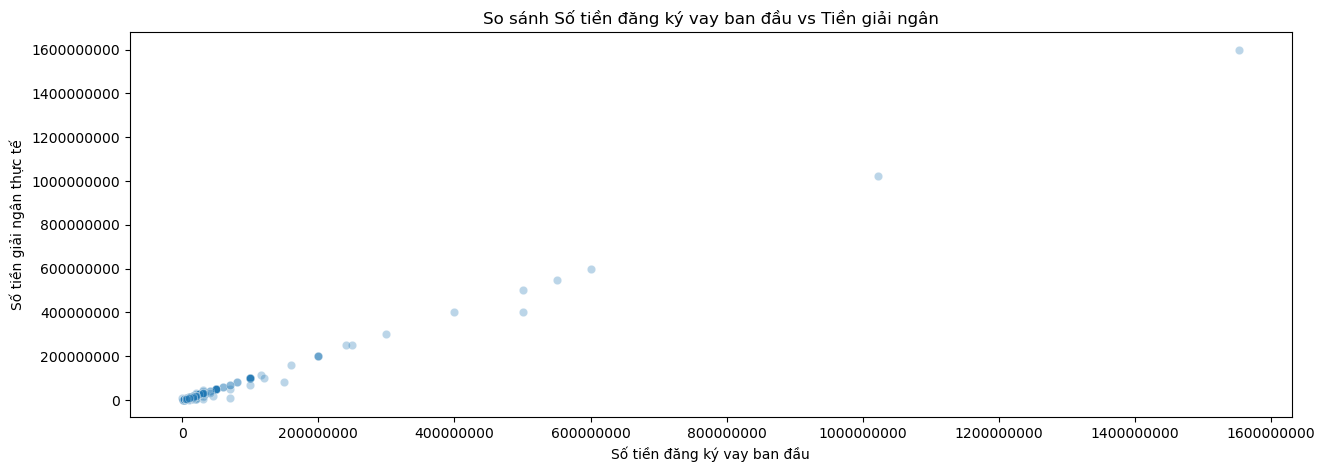

In [11]:
#Có khác biệt gì so với số tiền được giải ngân?
plt.figure(figsize=(15,5))
sns.scatterplot(
    x=df['Số tiền đăng ký vay ban đầu'],
    y=df['Tiền giải ngân'],
    alpha = 0.3
)
plt.title("So sánh Số tiền đăng ký vay ban đầu vs Tiền giải ngân")
plt.xlabel("Số tiền đăng ký vay ban đầu")
plt.ylabel("Số tiền giải ngân thực tế")
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


**Insight 8 — Hai biến có tương quan tuyến tính khá rõ (dương)**

Khi khách đăng ký vay nhiều --> tiền giải ngân thường cũng cao.

Nhưng không phải lúc nào tiền giải ngân = tiền đăng ký.

**Insight 9 — Ở các khoản lớn (100 triệu+), có khoảng cách đáng kể**

--> Có thể:

Yêu cầu vay 1 tỷ nhưng chỉ được duyệt 300–500 triệu.

Chính sách siết hạn mức với khách rủi ro.

Hoặc sản phẩm vay không cho vay full số yêu cầu.

**Insight 10 — Ở nhóm vay nhỏ (2–20 triệu), tiền đăng ký = tiền giải ngân**

→ Các khách vay nhỏ thường được duyệt gần như toàn bộ.

###**Insight tổng**
Số tiền đăng ký vay ban đầu của khách hàng TIMA tập trung gần như hoàn toàn ở nhóm vay nhỏ, chủ yếu trong khoảng 6–10 triệu và phổ biến nhất là mức 10 triệu. Phân phối dữ liệu lệch phải rất mạnh: đa số khách yêu cầu vay thấp, nhưng tồn tại một số hồ sơ yêu cầu khoản vay rất lớn (tới hơn 1.5 tỷ), làm kéo trung bình tăng đáng kể dù median chỉ ở mức 10 triệu. Histograms và boxplots cho thấy một lượng lớn outlier thuộc nhóm vay lớn, phản ánh sự khác biệt lớn trong nhu cầu vay giữa các khách hàng. Bên cạnh đó, so sánh với số tiền giải ngân thực tế cho thấy ở nhóm vay nhỏ, khách gần như được giải ngân đúng mong muốn, trong khi với các khoản vay cao, số tiền được duyệt thường thấp hơn đáng kể so với số tiền đăng ký. Điều này khẳng định đặc trưng thị trường của TIMA là vay tiêu dùng nhỏ, còn các hồ sơ vay lớn là ngoại lệ và cần được quản lý rủi ro riêng.

##**Loại sản phẩm tín dụng**

1. Sản phẩm vay nào được sử dụng nhiều nhất?

2. Tổng giá trị giải ngân (GMV) theo từng sản phẩm ra sao?

3. Có sản phẩm nào nổi bật bất thường không?


In [12]:
#Sản phẩm vay nào được sử dụng nhiều nhất?
df['ProductCreditName'].value_counts()

ProductCreditName
Cầm cố Điện thoại         1110
Cầm cố xe máy              507
Vay theo sim               298
Cầm cố Điện thoại HK       250
Cầm cố xe máy KCC          160
Đăng ký xe ô tô             40
Ô tô ngân hàng               8
Vay trực tuyến qua Sim       5
Cầm Sim Số Đẹp               3
Unknown                      1
Cầm ô tô                     1
Name: count, dtype: int64

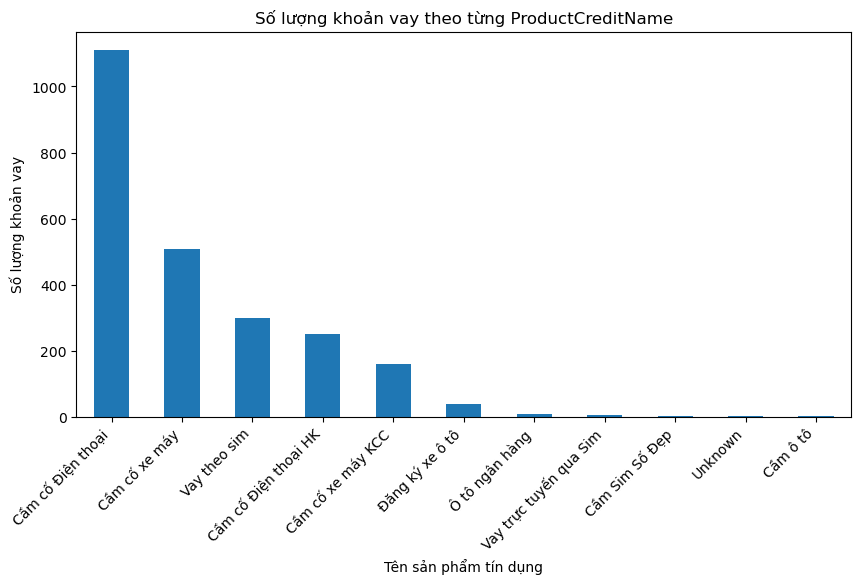

In [13]:
plt.figure(figsize=(10,5))
df['ProductCreditName'].value_counts().plot(kind='bar')
plt.title("Số lượng khoản vay theo từng ProductCreditName")
plt.xlabel("Tên sản phẩm tín dụng")
plt.ylabel("Số lượng khoản vay")
plt.xticks(rotation=45, ha='right')
plt.show()

**1. Sản phẩm vay nào được sử dụng nhiều nhất?**

- Cầm cố Điện thoại nổi trội nhất với 1,110 khoản vay, chiếm gần 50% toàn bộ dataset.

- Theo sau là:

  - Cầm cố xe máy (507 khoản vay)

  - Vay theo sim (298)

  - Cầm cố điện thoại HK (250)

  - Cầm cố xe máy KCC (160)

→ 5 sản phẩm đầu chiếm gần 90% tổng số khoản vay, các sản phẩm còn lại gần như là “long tail”.

In [14]:
#Tổng giá trị giải ngân (GMV) theo từng ProductCreditName

gmv_by_product = df.groupby('ProductCreditName')['Tiền giải ngân'].sum().sort_values(ascending=False)

gmv_by_product_formatted = gmv_by_product.apply(lambda x: f"{x:,.0f}")
gmv_by_product_formatted


ProductCreditName
Cầm cố Điện thoại         9,307,620,000
Cầm cố xe máy             5,249,322,000
Đăng ký xe ô tô           4,605,000,000
Cầm Sim Số Đẹp            2,652,735,000
Cầm cố Điện thoại HK      2,029,000,000
Cầm cố xe máy KCC         1,502,500,000
Ô tô ngân hàng            1,295,000,000
Vay theo sim                815,000,000
Cầm ô tô                    500,000,000
Vay trực tuyến qua Sim       13,000,000
Unknown                       5,000,000
Name: Tiền giải ngân, dtype: object

**2. Tổng giá trị giải ngân (GMV) theo từng sản phẩm ra sao?**

- Cầm cố Điện thoại tiếp tục đứng đầu với gần 9.3 tỷ VND GMV, dù đây là sản phẩm giá trị nhỏ nhưng tần suất cực cao.

- Cầm cố xe máy xếp thứ 2 với gần 5.2 tỷ.

- Đăng ký xe ô tô xếp thứ 3 với gần 4.6 tỷ, dù số lượng chỉ 40 hồ sơ nhưng giá trị vay trung bình rất cao.

- Cầm Sim Số Đẹp (chỉ vài chục khoản) lại tạo ra GMV  gần 2.65 tỷ, cho thấy đây là sản phẩm giá trị lớn.

-->  GMV không tương ứng hoàn toàn với số lượng; có sản phẩm ít hồ sơ nhưng vay rất lớn.

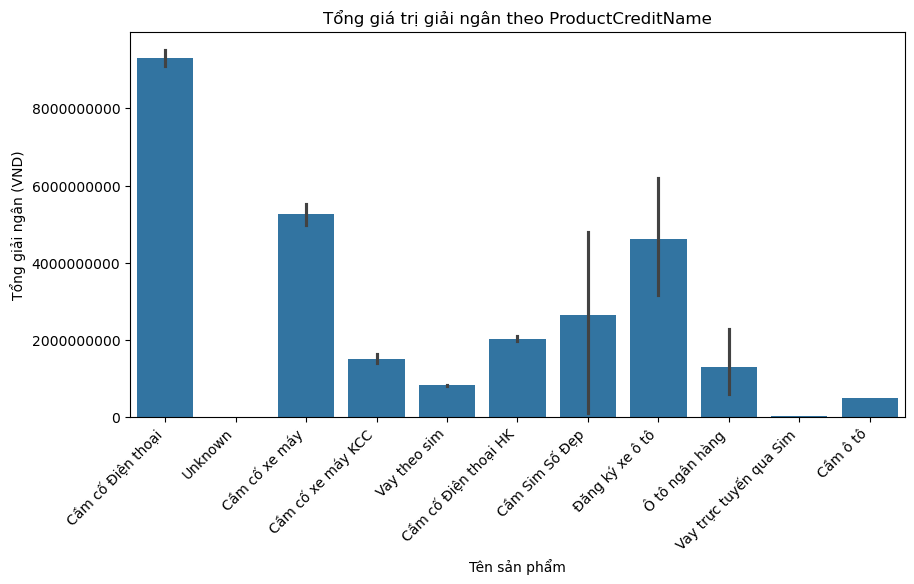

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='ProductCreditName',
    y='Tiền giải ngân',
    estimator='sum'
)
plt.title("Tổng giá trị giải ngân theo ProductCreditName")
plt.xlabel("Tên sản phẩm")
plt.ylabel("Tổng giải ngân (VND)")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')


plt.show()


In [16]:
#GMV trung bình mỗi khoản vay theo sản phẩm
gmv_avg = df.groupby('ProductCreditName')['Tiền giải ngân'].mean().sort_values(ascending=False)
gmv_avg_formatted = gmv_avg.apply(lambda x: f"{x:,.0f}")
gmv_avg_formatted

ProductCreditName
Cầm Sim Số Đẹp            884,245,000
Cầm ô tô                  500,000,000
Ô tô ngân hàng            161,875,000
Đăng ký xe ô tô           115,125,000
Cầm cố xe máy              10,353,692
Cầm cố xe máy KCC           9,390,625
Cầm cố Điện thoại           8,385,243
Cầm cố Điện thoại HK        8,116,000
Unknown                     5,000,000
Vay theo sim                2,734,899
Vay trực tuyến qua Sim      2,600,000
Name: Tiền giải ngân, dtype: object

**3. Giá trị giải ngân trung bình mỗi khoản vay theo sản phẩm?**

- Cầm Sim Số Đẹp có giá trị trung bình cao nhất: gần 884 triệu/khoản vay (rất lớn).

- Cầm ô tô: gần 500 triệu/khoản vay.

- Ô tô ngân hàng: gần 161 triệu/khoản vay.

- Nhóm sản phẩm phổ biến (Cầm cố điện thoại, xe máy, sim) có giá trị trung bình chỉ gần 8–10 triệu/khoản vay.

--> Rõ rệt sự phân tầng giữa sản phẩm mass-market và sản phẩm high-value.

###**INSIGHT TỔNG**

Danh mục sản phẩm tín dụng của TIMA thể hiện sự phân hóa rất rõ giữa nhóm sản phẩm đại chúng và nhóm sản phẩm giá trị lớn. “Cầm cố Điện thoại” và “Cầm cố xe máy” là hai sản phẩm chiếm nhiều khoản vay nhất, đặc biệt “Cầm cố Điện thoại” chiếm gần một nửa tổng số hồ sơ, cho thấy nhu cầu vay nhanh – vay nhỏ chiếm ưu thế trong tập khách hàng của TIMA. Trong khi đó, các sản phẩm như “Cầm Sim Số Đẹp”, “Cầm ô tô” hay “Ô tô ngân hàng” có số lượng hồ sơ không nhiều nhưng giá trị vay trung bình lại rất cao, đóng góp đáng kể vào tổng số tiền giải ngân. Điều này cho thấy hoạt động cho vay của TIMA gồm hai phần rõ rệt: một phần là các khoản vay nhỏ, quay vòng nhanh và phổ biến; phần còn lại là một số ít khoản vay lớn, giá trị cao, cần được kiểm soát rủi ro cẩn trọng hơn. Cơ cấu sản phẩm này giúp TIMA vừa duy trì được lượng giao dịch ổn định, vừa có thêm nguồn doanh thu từ các sản phẩm giá trị cao dù tần suất thấp.

##**Trạng thái**

1. Phân bổ từng trạng thái là bao nhiêu?

2. Tỷ lệ nợ xấu (NPL) tổng thể là bao nhiêu?

3. Nhóm nào chiếm đa số trong dataset?

4. Phân phối trạng thái có cân bằng hay lệch (imbalanced dataset)?

In [17]:
#Đếm số lượng từng trạng thái
df['LoanStatus'].value_counts()

LoanStatus
Hoàn thành    1586
Muộn           525
Nợ xấu         206
Đang vay        66
Name: count, dtype: int64

**Insight 1**

“Hoàn thành” là trạng thái chiếm ưu thế tuyệt đối với 1,586 khoản, tương đương khoảng 66.6% tổng số khoản vay.

 “Muộn” đứng thứ hai với 525 khoản (~22.0%), cao gấp ~8 lần so với nhóm “Đang vay” (66 khoản, ~2.8%).

 Trong khi đó, “Nợ xấu” chiếm 206 khoản (~8.6%), phản ánh một tỷ lệ rủi ro hiện hữu nhưng không phải là nhóm chiếm đa số trong dữ liệu.

In [18]:
#Tỷ lệ phần trăm từng trạng thái
df['LoanStatus'].value_counts(normalize=True).round(4) * 100

LoanStatus
Hoàn thành    66.55
Muộn          22.03
Nợ xấu         8.64
Đang vay       2.77
Name: proportion, dtype: float64

In [19]:
npl = (df['LoanStatus'] == 'Nợ xấu').mean() * 100
print(f"Tỷ lệ NPL (nợ xấu): {npl:.2f}%")

Tỷ lệ NPL (nợ xấu): 8.64%


**Insight 2**

--> Đây là một tỷ lệ thấp, thấp hơn nhiều so với mặt bằng tín dụng tiêu dùng.

--> Tuy nhiên, điều này không phản ánh đúng rủi ro, vì nhóm "Muộn" vẫn chiếm tỷ lệ nhiều

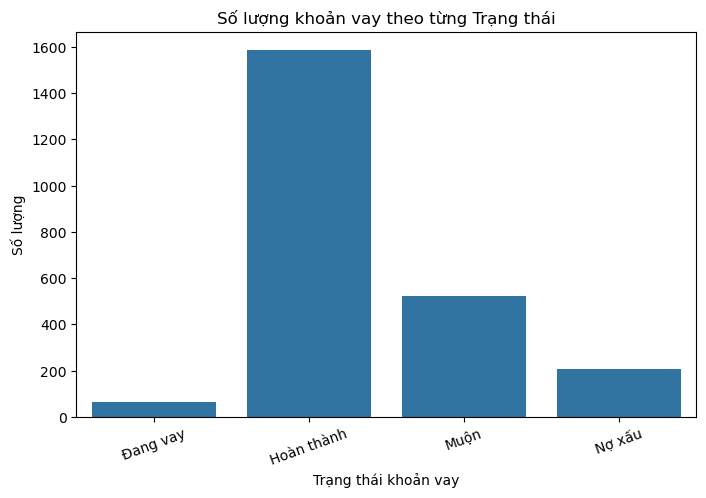

In [20]:
#Số lượng khoản vay theo trạng thái
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='LoanStatus')
plt.title("Số lượng khoản vay theo từng Trạng thái")
plt.xlabel("Trạng thái khoản vay")
plt.ylabel("Số lượng")
plt.xticks(rotation=20)
plt.show()


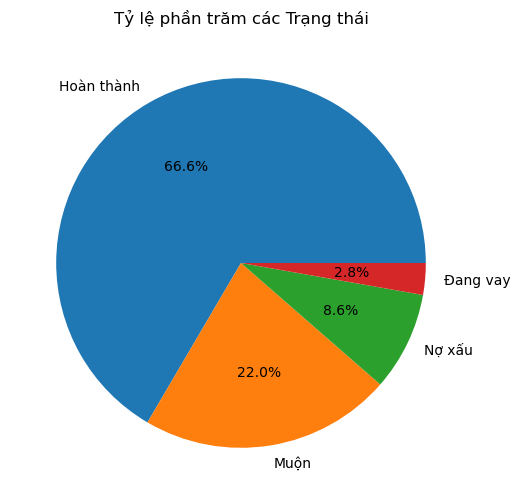

In [21]:
#Tỷ lệ phần trăm trạng thái
df['LoanStatus'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    ylabel='',
    title='Tỷ lệ phần trăm các Trạng thái'
)
plt.show()

**Insight tổng**

Phân bố trạng thái khoản vay cho thấy phần lớn hồ sơ trong dataset đã ở trạng thái “Hoàn thành”, chiếm khoảng 66.6% tổng số khoản vay. Điều này cho thấy dữ liệu hiện tại thiên nhiều về các khoản vay đã kết thúc, trong khi số khoản “Đang vay” còn rất ít (chỉ khoảng 2.8%).

Tuy nhiên, nhóm “Muộn” chiếm tỷ trọng khá lớn (khoảng 22.0%), cao hơn nhiều so với nhóm “Đang vay”. Điều này cho thấy dù tỷ lệ “Nợ xấu” chỉ ở mức 8.64%, rủi ro thực tế có thể chưa được phản ánh đầy đủ nếu chỉ nhìn vào NPL, vì một phần lớn khoản vay đang ở trạng thái trễ hạn và có khả năng chuyển thành nợ xấu trong tương lai.

#**NHÓM 2 — Nhân khẩu học**

##**Giới tính (Gender)**

1. Phân bố giới tính (Nam/Nữ) trong dataset như thế nào?

2. Nhóm nào chiếm tỷ lệ cao hơn?

3. Giới tính có ảnh hưởng đến mức vay hay trạng thái không?
(phân tích đa biến)

In [22]:
#Số lượng theo từng giới tính (1-Nam, 0-Nữ)
df['Gender'].value_counts()

Gender
0.0    1519
1.0     860
Name: count, dtype: int64

In [23]:
#Tỷ lệ phần trăm giới tính
df['Gender'].value_counts(normalize=True).round(4) * 100

Gender
0.0    63.85
1.0    36.15
Name: proportion, dtype: float64

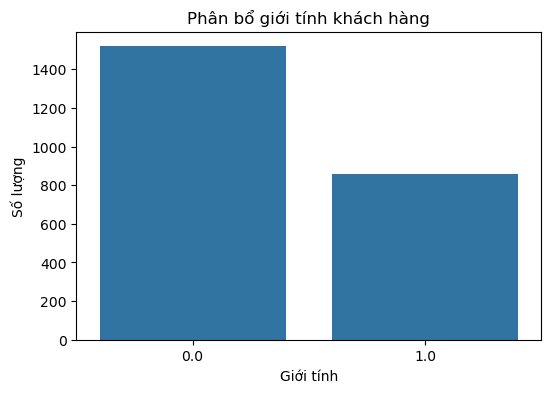

In [24]:
#Biểu đồ phân bổ giới tính
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title("Phân bổ giới tính khách hàng")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng")
plt.show()

**Insight tổng:**

Phân bố giới tính trong dataset cho thấy tỷ lệ khách hàng nữ cao gần gấp đôi so với khách hàng nam (khoảng 64% nữ và 36% nam). Điều này phản ánh rằng danh mục vay của TIMA có xu hướng tập trung vào nhóm khách hàng nữ, vốn thường xuất hiện nhiều trong các sản phẩm vay tiêu dùng nhỏ.

##**Tuổi (Age)**

1. Tuổi khách hàng phân bố như thế nào?

2. Độ tuổi phổ biến nhất là bao nhiêu?

3. Có khách hàng nào quá trẻ hoặc quá lớn tuổi bất thường không (outliers)?

4. Độ tuổi có phân bố lệch (skewed) không?

5. Nhóm tuổi chính của khách hàng TIMA là ai?

In [25]:
df['Age'].describe().to_frame()

,Age
count,2377.000000
mean,30.949937
std,6.737223
min,0.000000
25%,26.000000
50%,29.000000
75%,35.000000
max,59.000000


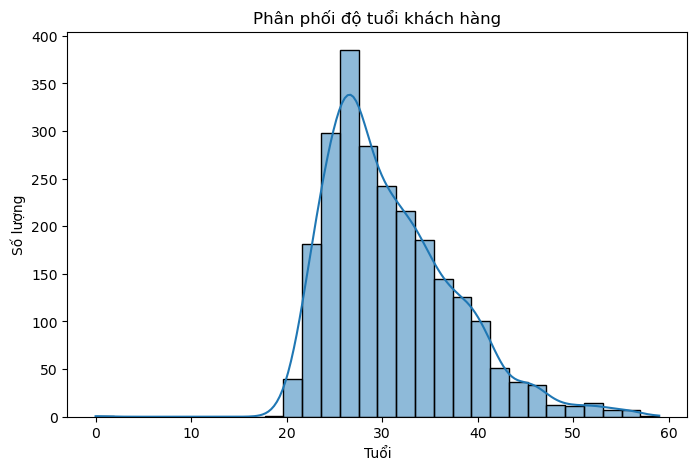

In [26]:
#Phân phối độ tuổi
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Phân phối độ tuổi khách hàng")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")
plt.show()

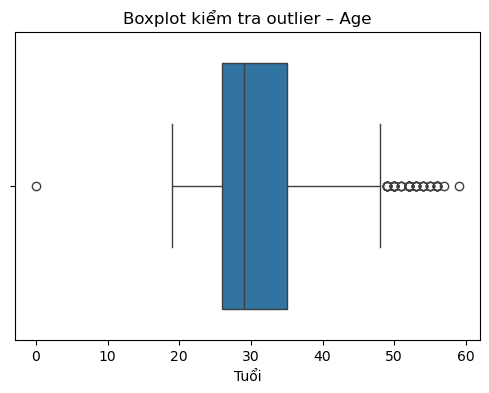

In [27]:
#Kiểm tra tuổi outlier
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot kiểm tra outlier – Age")
plt.xlabel("Tuổi")
plt.show()

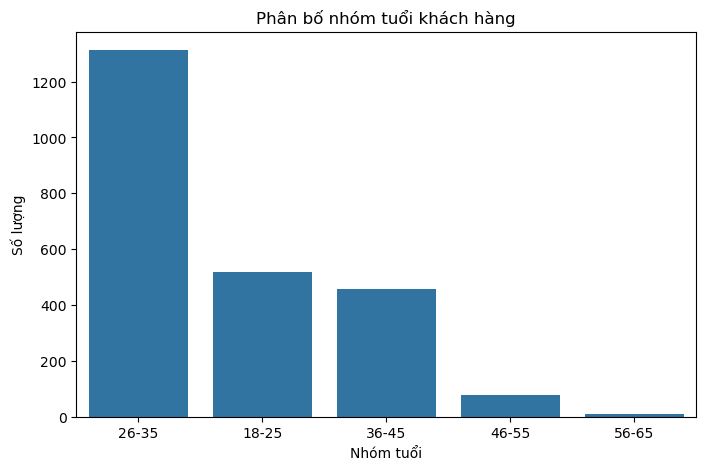

In [28]:
#Phân bố nhóm tuổi
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AgeGroup')
plt.title("Phân bố nhóm tuổi khách hàng")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Số lượng")
plt.show()

**Insight:**
Độ tuổi khách hàng của TIMA tập trung chủ yếu ở nhóm 26–35 tuổi, với median khoảng 29 tuổi, cho thấy phần lớn khách thuộc độ tuổi lao động trẻ – nhóm có nhu cầu vay tiêu dùng cao và khả năng tiếp cận công nghệ tốt. Phân phối tuổi có xu hướng lệch nhẹ về bên phải, tức là số khách lớn tuổi giảm dần, và nhóm trên 55 tuổi gần như không đáng kể. Histogram và boxplot cho thấy một số outlier ở tuổi cao, và giá trị 0 tuổi là lỗi dữ liệu cần xử lý. Nhìn chung, cấu trúc độ tuổi này phản ánh đúng đặc thù của các dịch vụ vay tiêu dùng nhanh, nơi khách hàng chủ đạo là nhóm trẻ – trung niên đang trong giai đoạn có nhu cầu chi tiêu và tài chính chưa thực sự ổn định.

##**Tỉnh thành (CityName)**

1. Thành phố nào có nhiều khách hàng nhất?

2. Có khu vực nào bất thường (quá nhiều hoặc quá ít)?

3. Thành phố lớn (Hà Nội / TP.HCM) chiếm tỷ trọng bao nhiêu?

4. Phân bổ khách hàng có tập trung hay phân tán?

In [29]:
#Số lượng khách theo từng CityName
df['CityName'].value_counts()

CityName
Hà Nội         2060
Hồ Chí Minh     292
Phú Thọ          10
Hòa Bình          6
Vĩnh Phúc         4
Thanh Hóa         4
Hải Dương         1
Bắc Ninh          1
Lào Cai           1
Hải Phòng         1
Thái Nguyên       1
Đồng Nai          1
Yên Bái           1
Name: count, dtype: int64

In [30]:
#Tỷ lệ mỗi thành phố
df['CityName'].value_counts(normalize=True).round(4) * 100

CityName
Hà Nội         86.45
Hồ Chí Minh    12.25
Phú Thọ         0.42
Hòa Bình        0.25
Vĩnh Phúc       0.17
Thanh Hóa       0.17
Hải Dương       0.04
Bắc Ninh        0.04
Lào Cai         0.04
Hải Phòng       0.04
Thái Nguyên     0.04
Đồng Nai        0.04
Yên Bái         0.04
Name: proportion, dtype: float64

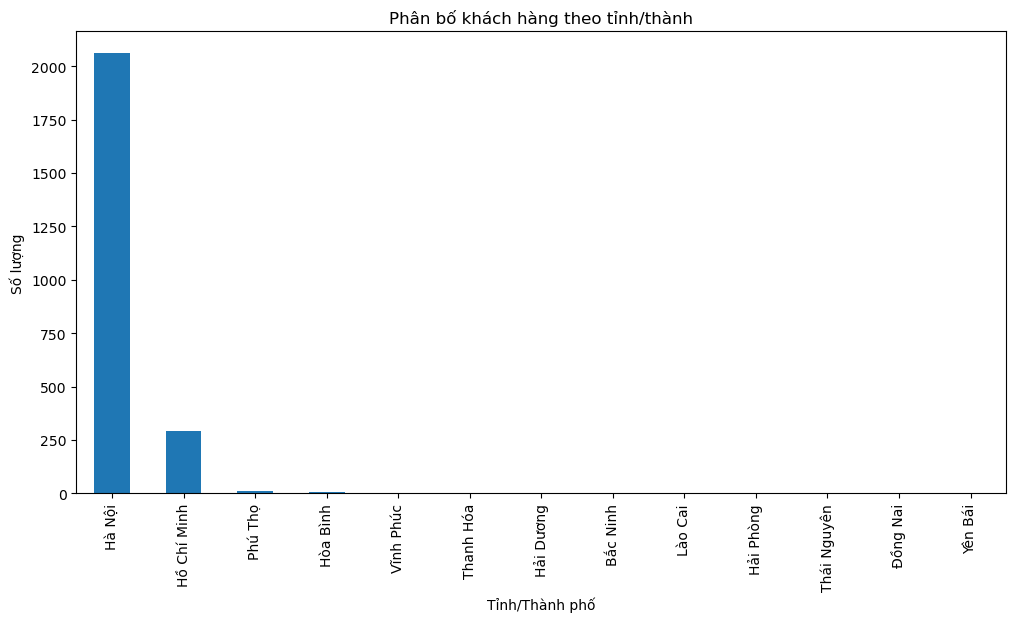

In [31]:
#Tỉnh/thành có nhiều khách nhất
plt.figure(figsize=(12,6))
df['CityName'].value_counts().plot(kind='bar')
plt.title("Phân bố khách hàng theo tỉnh/thành")
plt.xlabel("Tỉnh/Thành phố")
plt.ylabel("Số lượng")
plt.xticks(rotation=90)
plt.show()

In [32]:
#Kiểm tra xem Hà Nội & TP.HCM chiếm bao nhiêu %
big_cities = ['Hà Nội', 'Hồ Chí Minh']
df['CityName'].isin(big_cities).mean() * 100

np.float64(98.69911875786823)

**Insight:**
TIMA có độ tập trung khách hàng rất cao tại Hà Nội, chiếm hơn 86% và cùng với TP.HCM chiếm gần như toàn bộ dataset. Các tỉnh còn lại chỉ chiếm tỷ lệ nhỏ lẻ, cho thấy hoạt động kinh doanh của TIMA trong giai đoạn này chủ yếu tập trung tại hai đô thị lớn. Điều này dẫn đến sự mất cân bằng dữ liệu theo địa lý, ảnh hưởng đến phân tích và mô hình dự đoán nếu không xử lý trước.

##**Hình thức cư trú (Residence Type)**

1. Hình thức cư trú nào phổ biến nhất trong các khách hàng?

2. Tỷ lệ từng nhóm cư trú trong dataset là bao nhiêu?

3. Có nhóm nào chiếm đa số vượt trội?

4. Có nhóm cư trú nào rất ít khách không (gây khó khăn cho modelling)?

5. Đây có phải yếu tố ảnh hưởng đến nợ xấu (multivariate)?

In [33]:
#Số lượng từng nhóm cư trú
df['Hình thức cư trú'].value_counts()

Hình thức cư trú
Đồng sở hữu                 712
Thuê                        569
Sở hữu cá nhân              532
Thuộc sở hữu của họ hàng    358
Khác                        142
Nhà sở hữu                   62
Sở hữu nhà nước               8
Name: count, dtype: int64

In [34]:
#Tỷ lệ phần trăm cho mỗi nhóm
df['Hình thức cư trú'].value_counts(normalize=True).round(4) * 100

Hình thức cư trú
Đồng sở hữu                 29.88
Thuê                        23.88
Sở hữu cá nhân              22.32
Thuộc sở hữu của họ hàng    15.02
Khác                         5.96
Nhà sở hữu                   2.60
Sở hữu nhà nước              0.34
Name: proportion, dtype: float64

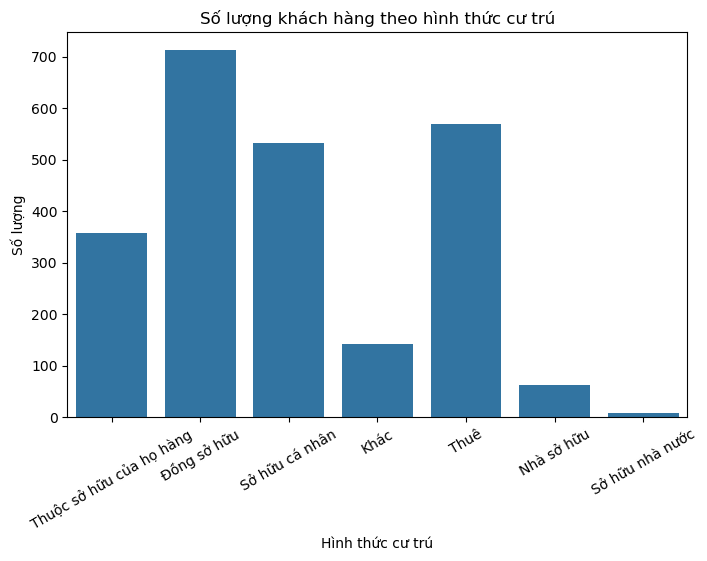

In [35]:
#Số lượng khách hàng theo từng hình thức cư trú
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Hình thức cư trú')
plt.title("Số lượng khách hàng theo hình thức cư trú")
plt.xlabel("Hình thức cư trú")
plt.ylabel("Số lượng")
plt.xticks(rotation=30)
plt.show()

**Insight:**
Khách hàng TIMA có hình thức cư trú khá đa dạng, trong đó nổi bật nhất là nhóm “Đồng sở hữu”, theo sau là nhóm “Thuê” và “Sở hữu cá nhân”, chiếm tổng cộng hơn 75% dataset. Điều này phản ánh đặc thù khách hàng chủ yếu là người trẻ hoặc trung niên sống cùng gia đình hoặc đang thuê nhà tại các thành phố lớn. Một số hình thức cư trú rất ít dữ liệu (như “Sở hữu nhà nước”) cần được gom nhóm khi xây dựng mô hình. Phân bố tương đối cân bằng giúp việc phân tích và mô hình hóa thuận lợi, đặc biệt khi xem xét mối liên hệ giữa hình thức cư trú và rủi ro nợ xấu trong phần phân tích đa biến tiếp theo.

#**NHÓM 3 — JobName / Salary**

##**JobName**

1. Ngành nghề nào phổ biến nhất?

2. Phân phối thu nhập của khách hàng trông như thế nào?

3. Mức thu nhập trung bình có khác nhau giữa các ngành nghề không?

4. Ngành nghề nào có tỷ lệ nợ xấu cao nhất/thấp nhất?

5. Nghề nghiệp có thể tác động đến mức vay hoặc rủi ro không?
(phân tích đa biến)

In [36]:
#Đếm số lượng theo nghề
df['JobName'].value_counts()

JobName
Nhân viên chính thức                                1087
Khác                                                 311
Các hình thức tự kinh doanh khác                     135
Tự doanh tại nhà                                      81
Nhân viên tổ chức nhà nước                            77
Nhân viên không có HĐLĐ                               75
Kinh doanh                                            69
Kinh doanh tại nhà (không có đăng ký kinh doanh)      53
Tài xế                                                52
Công nhân                                             49
Bảo vệ                                                31
Nhân sự                                               31
Giáo viên                                             29
Hành chính                                            28
Lái xe                                                26
Kế toán                                               26
Bán hàng                                              25
Tự doanh không ĐKKD    

In [37]:
#Tỷ lệ phần trăm nghề nghiệp
df['JobName'].value_counts(normalize=True).round(4) * 100

JobName
Nhân viên chính thức                                45.61
Khác                                                13.05
Các hình thức tự kinh doanh khác                     5.67
Tự doanh tại nhà                                     3.40
Nhân viên tổ chức nhà nước                           3.23
Nhân viên không có HĐLĐ                              3.15
Kinh doanh                                           2.90
Kinh doanh tại nhà (không có đăng ký kinh doanh)     2.22
Tài xế                                               2.18
Công nhân                                            2.06
Bảo vệ                                               1.30
Nhân sự                                              1.30
Giáo viên                                            1.22
Hành chính                                           1.17
Lái xe                                               1.09
Kế toán                                              1.09
Bán hàng                                             1.05
Tự doa

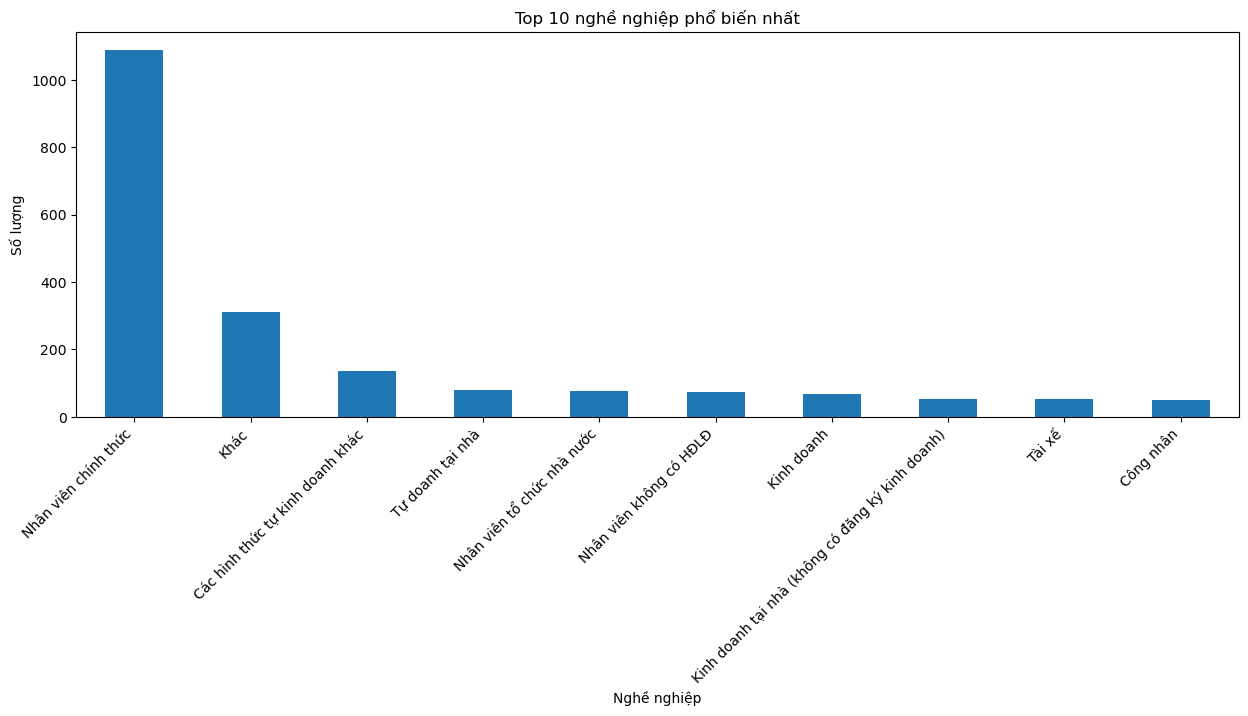

In [38]:
#Top 10 nghề nghiệp phổ biến nhất
plt.figure(figsize=(15,5))
df['JobName'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 nghề nghiệp phổ biến nhất")
plt.xlabel("Nghề nghiệp")
plt.ylabel("Số lượng")
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight**

Khách hàng của TIMA chủ yếu là nhân viên chính thức với công việc ổn định, chiếm hơn 45% dataset. Bên cạnh đó, một nhóm đáng kể đến từ các hình thức tự kinh doanh và lao động tự do ( gần 15%), vốn là nhóm có thu nhập biến động và tiềm ẩn rủi ro cao hơn. Phần còn lại là các nghề rải rác với tỷ lệ nhỏ, gây phân mảnh dữ liệu.

##**Salary**

1. Thu nhập trung bình, trung vị của khách hàng là bao nhiêu?

2. Phân phối thu nhập có lệch không?

3. Có outlier không, thu nhập quá thấp hoặc quá cao?

4. Thu nhập có phù hợp với mức vay hay không?

In [39]:
#Thống kê mô tả thu nhập
df['Salary'].describe().to_frame().style.format("{:,.0f}")

,Salary
count,"2,383"
mean,"10,007,186"
std,"5,903,240"
min,"1,500,000"
25%,"7,000,000"
50%,"8,000,000"
75%,"11,000,000"
max,"100,000,000"


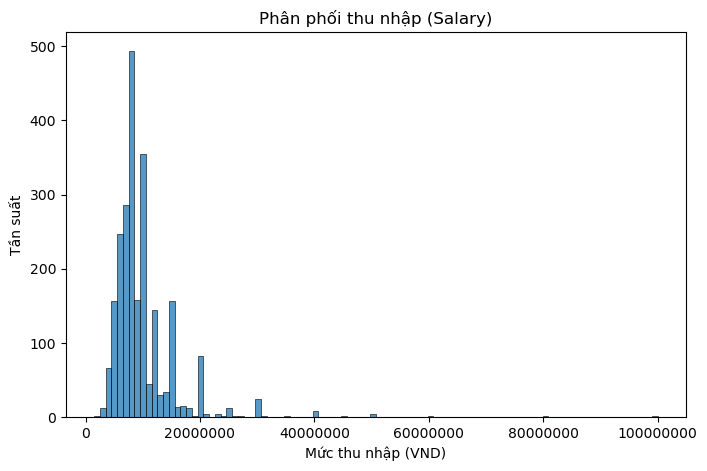

In [40]:
#Phân phối thu nhập
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], binwidth=1000000)
plt.title("Phân phối thu nhập (Salary)")
plt.xlabel("Mức thu nhập (VND)")
plt.ylabel("Tần suất")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

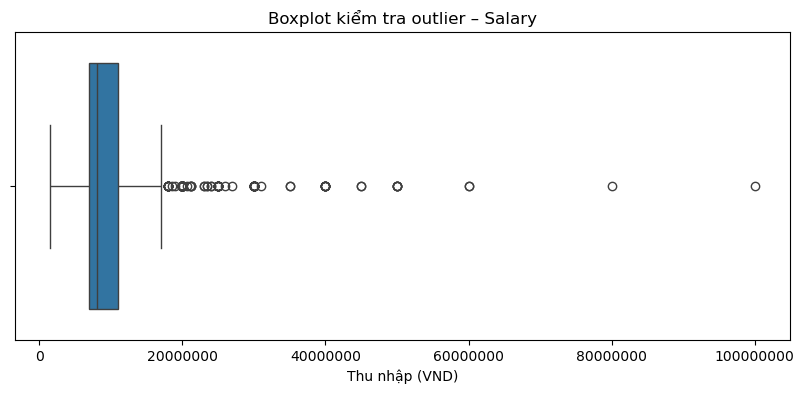

In [41]:
#Tìm outlier
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Salary'])
plt.title("Boxplot kiểm tra outlier – Salary")
plt.xlabel("Thu nhập (VND)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [42]:
#Thu nhập bao nhiêu nhiều nhất
df['Salary'].value_counts()

Salary
8000000.0     443
10000000.0    342
7000000.0     234
6000000.0     173
15000000.0    154
             ... 
1500000.0       1
8300000.0       1
18600000.0      1
26000000.0      1
19000000.0      1
Name: count, Length: 107, dtype: int64

**Insight**

Khách hàng TIMA chủ yếu có thu nhập từ 7 đến 11 triệu/tháng, với trung vị 8 triệu, phản ánh nhóm lao động phổ thông và nhân viên văn phòng cơ bản. Phân bố thu nhập lệch phải mạnh do một số trường hợp thu nhập cao bất thường, tạo ra nhiều outlier cần xử lý khi đưa vào mô hình. Nhìn chung, mức thu nhập của khách hàng khá phù hợp với các khoản vay phổ biến (5–10 triệu), cho thấy cấu trúc vay hiện tại tương đối hợp lý so với khả năng tài chính của khách.

#**NHÓM 4 - RISK VARIABLES**

##**TS_CREDIT_SCORE_V2**

1. Phân phối điểm tín dụng trông như thế nào? (chuẩn / lệch)

2. Điểm trung bình – trung vị – min – max là bao nhiêu?

3. Có outlier hay điểm bất thường không?

4. Có tập khách hàng bị scoring rất thấp (nguy cơ cao) không?

5. Điểm tín dụng có phù hợp với các hành vi rủi ro trong dataset không?

In [43]:
#Thống kê mô tả
df['TS_CREDIT_SCORE_V2'].describe().to_frame().style.format("{:,.0f}")

,TS_CREDIT_SCORE_V2
count,"2,383"
mean,590
std,97
min,300
25%,535
50%,599
75%,660
max,826


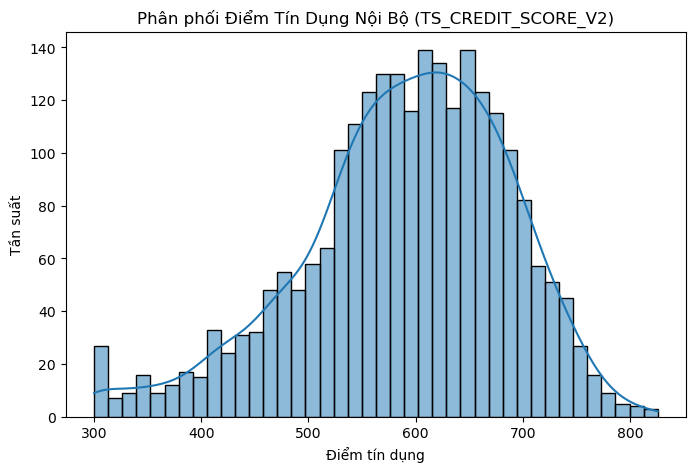

In [44]:
#Phân phối điểm tín dụng
plt.figure(figsize=(8,5))
sns.histplot(df['TS_CREDIT_SCORE_V2'], bins=40, kde=True)
plt.title("Phân phối Điểm Tín Dụng Nội Bộ (TS_CREDIT_SCORE_V2)")
plt.xlabel("Điểm tín dụng")
plt.ylabel("Tần suất")
plt.show()

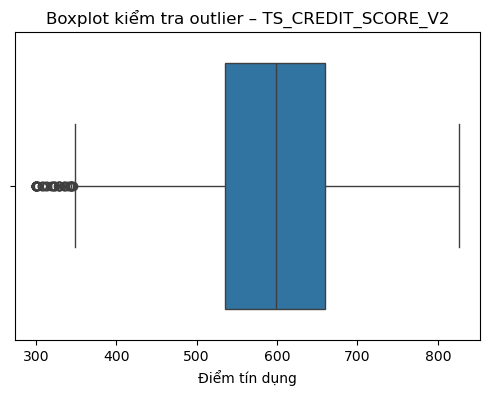

In [45]:
#Kiểm tra outlier
plt.figure(figsize=(6,4))
sns.boxplot(x=df['TS_CREDIT_SCORE_V2'])
plt.title("Boxplot kiểm tra outlier – TS_CREDIT_SCORE_V2")
plt.xlabel("Điểm tín dụng")
plt.show()

In [46]:
#Điểm tín dụng thấp nhất, cao nhất
df['TS_CREDIT_SCORE_V2'].min(), df['TS_CREDIT_SCORE_V2'].max()

(300, 826)

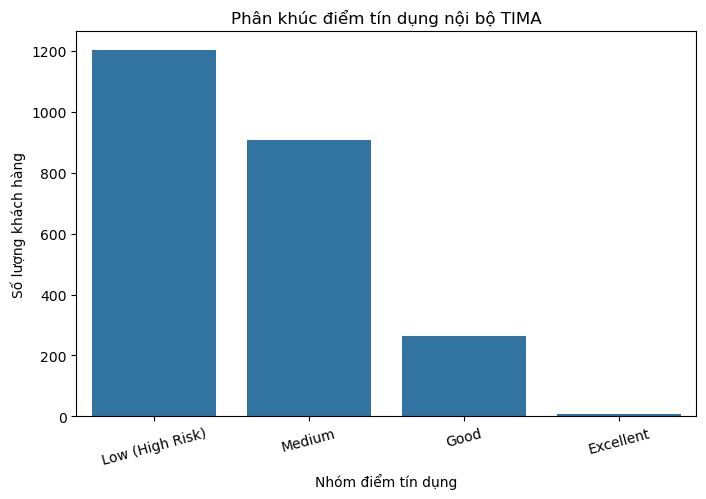

In [47]:
#Phân khúc điểm tín dụng
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='CreditScoreGroup')
plt.title("Phân khúc điểm tín dụng nội bộ TIMA")
plt.xlabel("Nhóm điểm tín dụng")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=15)
plt.show()

**Insight**

Điểm tín dụng nội bộ của khách hàng TIMA phân bố tương đối chuẩn, với trung bình 590 và trung vị 599, cho thấy phần lớn khách ở mức điểm trung bình – trung bình thấp. Một nửa khách hàng rơi vào nhóm Low (rủi ro cao), phản ánh chính xác tập khách hàng mục tiêu của TIMA là nhóm thu nhập–tài chính hạn chế. Outlier tồn tại nhưng ít và hợp lý về mặt nghiệp vụ. Biến này hứa hẹn là một trong những yếu tố mạnh nhất để dự báo rủi ro trả nợ trong phân tích đa biến tiếp theo.

##**HasBadDebt**

1. Bao nhiêu % khách hàng có nợ xấu CIC?

2. Tỷ lệ này có cao không? (Thông thường 1–5% trong dữ liệu tốt)

3. Đây có phải nhóm rủi ro nhất không? (đa biến)

In [48]:
#Tần suất
df['HasBadDebt'].value_counts()

HasBadDebt
0    2121
1     262
Name: count, dtype: int64

In [49]:
#Tỷ lệ
df['HasBadDebt'].value_counts(normalize=True) * 100

HasBadDebt
0    89.005455
1    10.994545
Name: proportion, dtype: float64

**Insight**


Khoảng 11% khách hàng trong dataset từng có nợ xấu CIC – một tỷ lệ tương đối cao so với chuẩn thị trường, cho thấy TIMA phục vụ nhóm khách hàng rủi ro hơn mức trung bình. Nhóm này nhiều khả năng sẽ có hành vi trả nợ kém hơn, trở thành một trong những biến quan trọng nhất trong phân tích đa biến và mô hình dự báo rủi ro sau này.

##**HasLatePayment**

In [50]:
df['HasLatePayment'].value_counts()

HasLatePayment
0    2047
1     336
Name: count, dtype: int64

In [51]:
df['HasLatePayment'].value_counts(normalize=True) * 100

HasLatePayment
0    85.900126
1    14.099874
Name: proportion, dtype: float64

**Insight**

Phần lớn khách hàng (86%) không có lịch sử trả chậm, tuy nhiên vẫn có gần 14% từng trễ hạn — đây là một nhóm rủi ro rõ rệt. Biến này rất quan trọng trong mô hình dự báo rủi ro vì lịch sử trả chậm là yếu tố dự đoán nợ xấu mạnh. Mức độ mất cân bằng không quá lớn, vẫn phù hợp cho phân tích và mô hình hóa.

#**PHÂN TÍCH ĐA BIẾN**

#**LoanStatus (BIẾN MỤC TIÊU)**

##**LoanStatus vs ProductCreditName**

--> Phân tích mức độ rủi ro theo sản phẩm tín dụng

1. Sản phẩm nào có nhiều hồ sơ nợ xấu nhất?

2. Sản phẩm nào có tỷ lệ nợ xấu (NPL) cao nhất?

3. Cơ cấu trạng thái giữa các sản phẩm có khác biệt rõ rệt không?

4. Sản phẩm phổ biến nhất có chất lượng tốt hay rủi ro cao?

5. Có sản phẩm nào rất rủi ro nhưng ít hồ sơ (risk concentration)?

In [52]:
# Tạo bảng chéo (crosstab)
pd.crosstab(df['ProductCreditName'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
ProductCreditName,,,,
Cầm Sim Số Đẹp,0,3,0,0
Cầm cố xe máy,338,133,1,35
Cầm cố xe máy KCC,105,46,7,2
Cầm cố Điện thoại,725,273,85,27
Cầm cố Điện thoại HK,202,34,13,1
Cầm ô tô,1,0,0,0
Unknown,1,0,0,0
Vay theo sim,172,26,100,0
Vay trực tuyến qua Sim,4,1,0,0


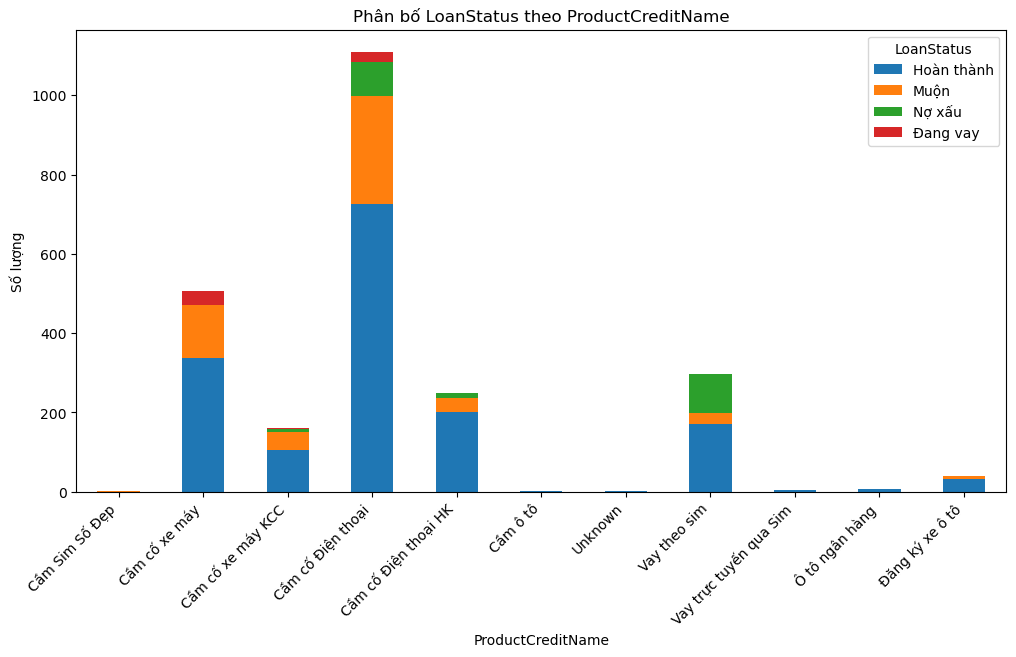

In [53]:
#Biểu đồ cột chồng – phân bố trạng thái theo sản phẩm
df_crosstab = pd.crosstab(df['ProductCreditName'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Phân bố LoanStatus theo ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Số lượng")
plt.xticks(rotation=45, ha='right')
plt.show()

In [54]:
#Tính tỷ lệ nợ xấu (NPL) theo từng sản phẩm
npl_by_product = (
    pd.crosstab(df['ProductCreditName'], df['LoanStatus'], normalize='index') * 100
)

npl_by_product.sort_values('Nợ xấu', ascending=False)

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
ProductCreditName,,,,
Vay theo sim,57.718121,8.724832,33.557047,0.000000
Cầm cố Điện thoại,65.315315,24.594595,7.657658,2.432432
Cầm cố Điện thoại HK,80.800000,13.600000,5.200000,0.400000
Cầm cố xe máy KCC,65.625000,28.750000,4.375000,1.250000
Cầm cố xe máy,66.666667,26.232742,0.197239,6.903353
Cầm Sim Số Đẹp,0.000000,100.000000,0.000000,0.000000
Cầm ô tô,100.000000,0.000000,0.000000,0.000000
Unknown,100.000000,0.000000,0.000000,0.000000
Vay trực tuyến qua Sim,80.000000,20.000000,0.000000,0.000000


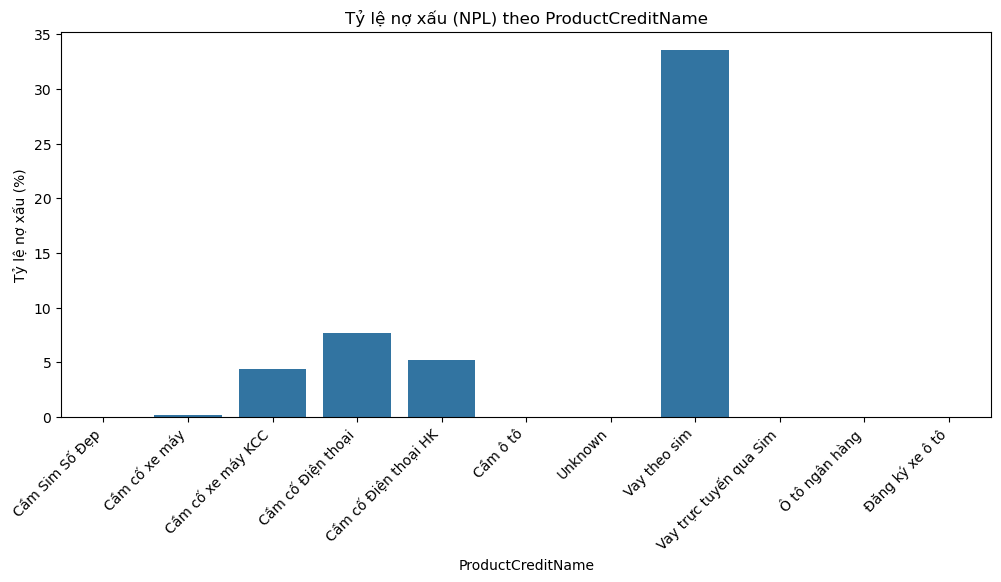

In [55]:
#Bar chart – Tỷ lệ nợ xấu theo sản phẩm
plt.figure(figsize=(12,5))
sns.barplot(
    data=npl_by_product.reset_index(),
    x='ProductCreditName',
    y='Nợ xấu'
)
plt.title("Tỷ lệ nợ xấu (NPL) theo ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("Tỷ lệ nợ xấu (%)")
plt.xticks(rotation=45, ha='right')
plt.show()

<Figure size 1200x600 with 0 Axes>

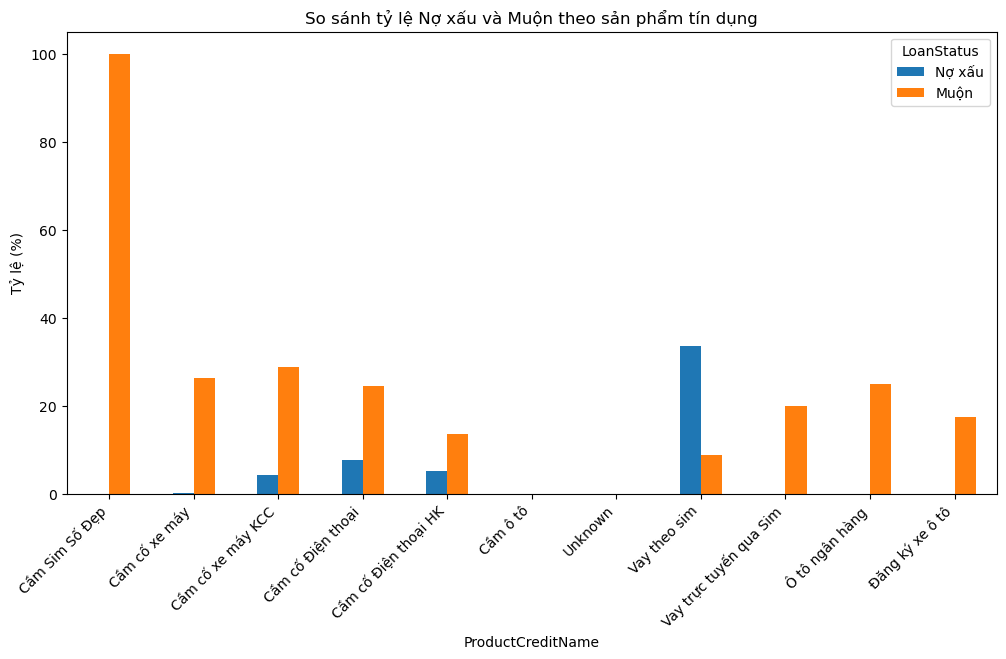

In [56]:
#Tỷ lệ “Nợ xấu” và “Muộn” theo ProductCreditName
plt.figure(figsize=(12,6))
npl_by_product[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(12,6))
plt.title("So sánh tỷ lệ Nợ xấu và Muộn theo sản phẩm tín dụng")
plt.xlabel("ProductCreditName")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()

**Insight**

Sự khác biệt về mức độ rủi ro giữa các sản phẩm tín dụng thể hiện khá rõ. Cầm cố điện thoại là sản phẩm có số lượng hồ sơ lớn nhất, đồng thời cũng ghi nhận số lượng nợ xấu tuyệt đối cao nhất (85 khoản). Tuy nhiên, xét theo tỷ lệ, mức NPL của sản phẩm này ở mức khoảng 7.66%, không phải là cao nhất trong danh mục, cho thấy rủi ro chủ yếu đến từ quy mô lớn hơn là chất lượng khoản vay quá kém.

Ngược lại, Vay theo sim là sản phẩm có tỷ lệ nợ xấu cao nhất, lên tới khoảng 33.6%, dù tổng số hồ sơ không lớn bằng các sản phẩm cầm cố. Điều này cho thấy rủi ro tập trung cao ở sản phẩm này và cần được theo dõi sát, vì chỉ một số lượng hồ sơ tương đối nhỏ cũng có thể tạo ra tỷ lệ nợ xấu rất cao.

Một số sản phẩm khác như Cầm cố xe máy KCC và Cầm cố điện thoại HK có tỷ lệ nợ xấu ở mức trung bình (khoảng 4–5%), trong khi Cầm cố xe máy thường gần như không ghi nhận nợ xấu đáng kể trong dữ liệu hiện tại. Tuy nhiên, với các sản phẩm có số lượng hồ sơ rất thấp như Cầm Sim Số Đẹp, Ô tô ngân hàng hay Cầm ô tô, việc không xuất hiện nợ xấu chưa đủ cơ sở để kết luận rủi ro thấp, do kích thước mẫu quá nhỏ.

Ngoài ra, tỷ lệ “Muộn” xuất hiện ở nhiều sản phẩm, đặc biệt là Cầm cố điện thoại, Cầm cố xe máy KCC và Vay theo sim, cho thấy áp lực trả nợ ngắn hạn vẫn tồn tại ngay cả ở những sản phẩm chưa có tỷ lệ nợ xấu cao. Đây là tín hiệu cảnh báo sớm, cho thấy rủi ro có thể gia tăng nếu không được kiểm soát kịp thời.

Nhìn chung, mỗi sản phẩm có đặc điểm rủi ro rất khác nhau: có sản phẩm rủi ro do quy mô lớn, có sản phẩm rủi ro do tỷ lệ nợ xấu cao. Điều này gợi ý TIMA nên đánh giá và quản lý rủi ro theo từng nhóm sản phẩm, thay vì áp dụng một cách tiếp cận chung cho toàn bộ danh mục.

##**LoanStatus vs CityName**

1. Tỉnh/thành nào có nhiều khoản nợ xấu nhất (theo số lượng)?

2. Tỉnh/thành nào có tỷ lệ nợ xấu cao nhất (theo %)?

3. Các thành phố lớn (Hà Nội, HCM) có chất lượng tốt hơn các tỉnh không?

4. Có tỉnh nào ít hồ sơ nhưng rủi ro rất cao?

In [57]:
#Bảng chéo – số lượng LoanStatus theo CityName
pd.crosstab(df['CityName'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
CityName,,,,
Bắc Ninh,1,0,0,0
Hà Nội,1438,402,171,49
Hòa Bình,6,0,0,0
Hải Dương,1,0,0,0
Hải Phòng,1,0,0,0
Hồ Chí Minh,123,122,30,17
Lào Cai,0,0,1,0
Phú Thọ,8,0,2,0
Thanh Hóa,3,0,1,0


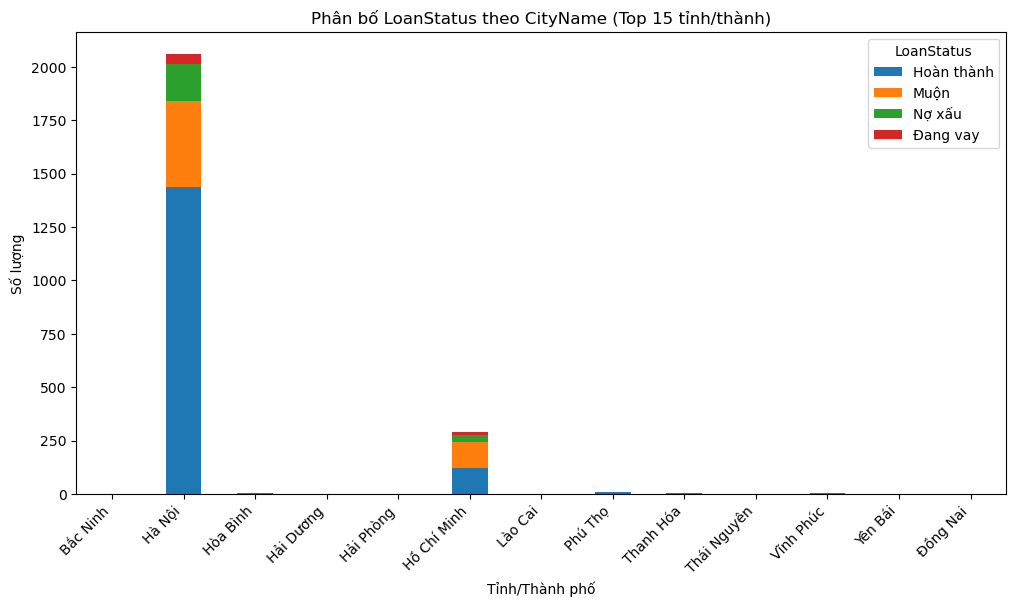

In [58]:
#Biểu đồ cột chồng – LoanStatus theo từng CityName
top_cities = df['CityName'].value_counts().head(15).index
subset = df[df['CityName'].isin(top_cities)]

df_crosstab = pd.crosstab(subset['CityName'], subset['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Phân bố LoanStatus theo CityName (Top 15 tỉnh/thành)")
plt.xlabel("Tỉnh/Thành phố")
plt.ylabel("Số lượng")
plt.xticks(rotation=45, ha='right')
plt.show()

In [59]:
#Tính tỷ lệ nợ xấu (NPL) theo từng CityName
npl_by_city = (
    pd.crosstab(df['CityName'], df['LoanStatus'], normalize='index') * 100
)

npl_by_city.sort_values('Nợ xấu', ascending=False)

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
CityName,,,,
Lào Cai,0.000000,0.000000,100.000000,0.000000
Thanh Hóa,75.000000,0.000000,25.000000,0.000000
Vĩnh Phúc,75.000000,0.000000,25.000000,0.000000
Phú Thọ,80.000000,0.000000,20.000000,0.000000
Hồ Chí Minh,42.123288,41.780822,10.273973,5.821918
Hà Nội,69.805825,19.514563,8.300971,2.378641
Bắc Ninh,100.000000,0.000000,0.000000,0.000000
Hòa Bình,100.000000,0.000000,0.000000,0.000000
Hải Dương,100.000000,0.000000,0.000000,0.000000


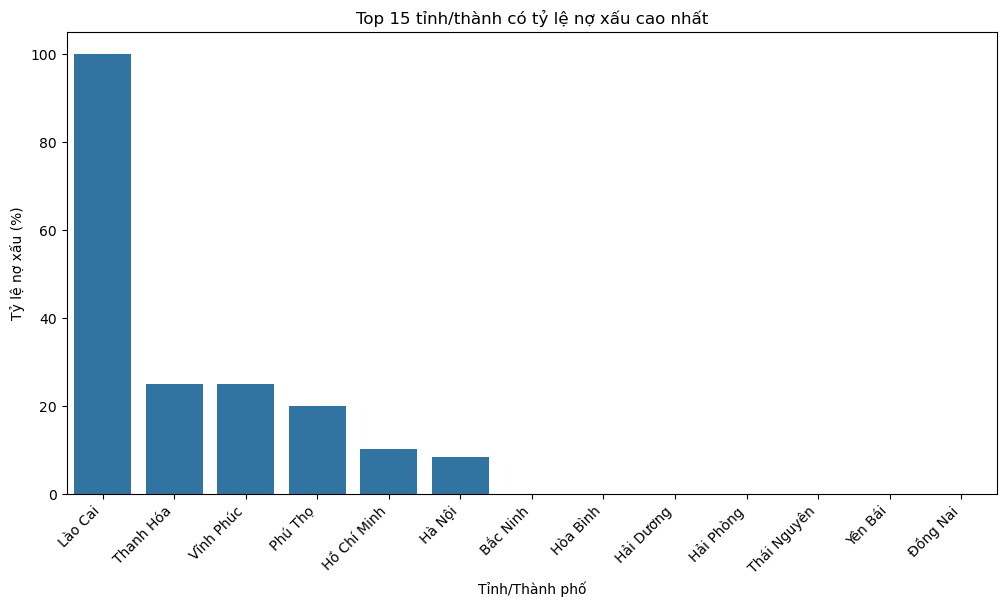

In [60]:
#Biểu đồ – Tỷ lệ nợ xấu theo CityName
plt.figure(figsize=(12,6))
sns.barplot(
    data=npl_by_city.reset_index().nlargest(15, 'Nợ xấu'),
    x='CityName',
    y='Nợ xấu'
)
plt.title("Top 15 tỉnh/thành có tỷ lệ nợ xấu cao nhất")
plt.xlabel("Tỉnh/Thành phố")
plt.ylabel("Tỷ lệ nợ xấu (%)")
plt.xticks(rotation=45, ha='right')
plt.show()

<Figure size 1200x600 with 0 Axes>

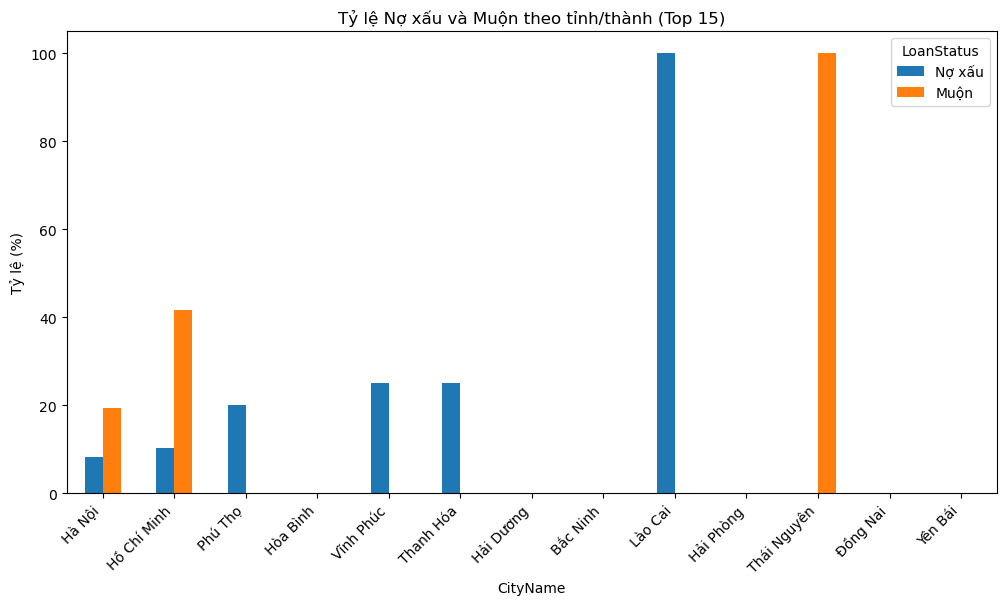

In [61]:
#Tỷ lệ “Nợ xấu” và “Muộn” theo CityName
plt.figure(figsize=(12,6))
npl_by_city[['Nợ xấu', 'Muộn']].loc[top_cities].plot(kind='bar', figsize=(12,6))
plt.title("Tỷ lệ Nợ xấu và Muộn theo tỉnh/thành (Top 15)")
plt.xlabel("CityName")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()

In [62]:
#Gộp các tỉnh/thành có < 20 hồ sơ thành “Khác”
# Đếm số lượng hồ sơ theo tỉnh/thành
city_counts = df['CityName'].value_counts()

# Xác định các tỉnh/thành có ít hơn 20 hồ sơ
rare_cities = city_counts[city_counts < 20].index

# Tạo cột mới: CityName_grouped
df['CityName_grouped'] = df['CityName'].where(~df['CityName'].isin(rare_cities), 'Khác')


In [63]:
risk_by_city_grouped = (
    pd.crosstab(df['CityName_grouped'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_city_grouped

LoanStatus,Nợ xấu,Muộn
CityName_grouped,,
Hà Nội,8.300971,19.514563
Hồ Chí Minh,10.273973,41.780822
Khác,16.129032,3.225806


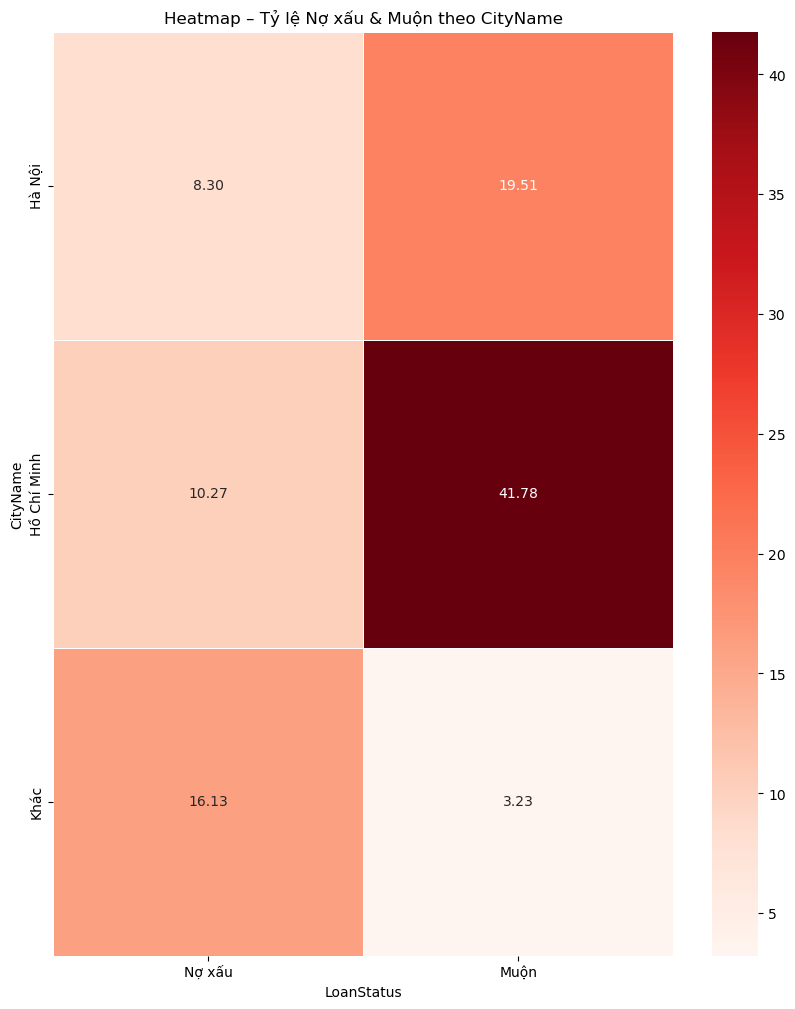

In [64]:
#Vẽ heatmap
plt.figure(figsize=(10,12))
sns.heatmap(
    risk_by_city_grouped,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=.5
)
plt.title("Heatmap – Tỷ lệ Nợ xấu & Muộn theo CityName")
plt.xlabel("LoanStatus")
plt.ylabel("CityName")
plt.show()

**Insight**

Kết quả phân tích cho thấy rủi ro theo khu vực có sự khác biệt rõ rệt, trong đó Hà Nội và TP.HCM là hai địa bàn chiếm phần lớn hồ sơ trong dataset, vì vậy các chỉ số rủi ro tại hai khu vực này có ảnh hưởng lớn đến bức tranh chung của toàn bộ danh mục.

Tại Hà Nội, tỷ lệ nợ xấu ở mức khoảng 8.3% và tỷ lệ “Muộn” khoảng 19.5%, phản ánh mức rủi ro ở mức trung bình, phù hợp với một thị trường lớn có quy mô hồ sơ cao. Cấu trúc này cho thấy đa số khoản vay vẫn được kiểm soát, dù vẫn tồn tại một nhóm đáng kể khách hàng trả chậm.

Trong khi đó, TP.HCM có tỷ lệ “Muộn” cao hơn rõ rệt (khoảng 41.8%), cao hơn đáng kể so với Hà Nội, trong khi tỷ lệ nợ xấu ở mức khoảng 10.3%. Điều này cho thấy khách hàng tại TP.HCM có xu hướng chậm trả nhiều hơn, nhưng chưa chuyển tương ứng sang nợ xấu. Đây là dấu hiệu rủi ro tiềm ẩn, đặc biệt nếu tình trạng “Muộn” kéo dài trong thời gian dài.

Đối với các tỉnh có quy mô hồ sơ nhỏ, việc xuất hiện tỷ lệ nợ xấu hoặc “Muộn” rất cao (ví dụ 25% hoặc 100%) không phản ánh rủi ro thực sự, mà chủ yếu do kích thước mẫu quá nhỏ. Khi gộp các tỉnh có dưới 20 hồ sơ vào nhóm “Khác”, tỷ lệ nợ xấu khoảng 16.1% trong khi tỷ lệ “Muộn” chỉ khoảng 3.2%, cho thấy rủi ro tại các tỉnh nhỏ không cao như những tỷ lệ riêng lẻ ban đầu thể hiện.

Nhìn chung, rủi ro của danh mục tập trung chủ yếu ở các thành phố lớn, đặc biệt là TP.HCM với tỷ lệ “Muộn” cao, trong khi các tỉnh nhỏ cần được đánh giá thận trọng do hạn chế về dữ liệu. Điều này gợi ý rằng việc quản lý rủi ro theo khu vực nên ưu tiên theo dõi nhóm “Muộn” tại các thị trường lớn, thay vì chỉ dựa vào tỷ lệ nợ xấu hiện tại.

##**LoanStatus vs AgeGroup**

1. Nhóm tuổi nào có tỷ lệ Nợ xấu cao nhất?

2. Nhóm tuổi nào có tỷ lệ Muộn cao nhất?

3. Có xu hướng “tuổi trẻ → rủi ro cao hơn” không?

4. Nhóm tuổi cao tuổi có rủi ro thấp hơn hay cao hơn?

5. Có nhóm tuổi nhỏ (18–22) đặc biệt rủi ro không?

In [65]:
pd.crosstab(df['AgeGroup'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
AgeGroup,,,,
18-25,328,116,58,18
26-35,886,275,117,35
36-45,314,105,28,11
46-55,50,23,3,1
56-65,3,5,0,0


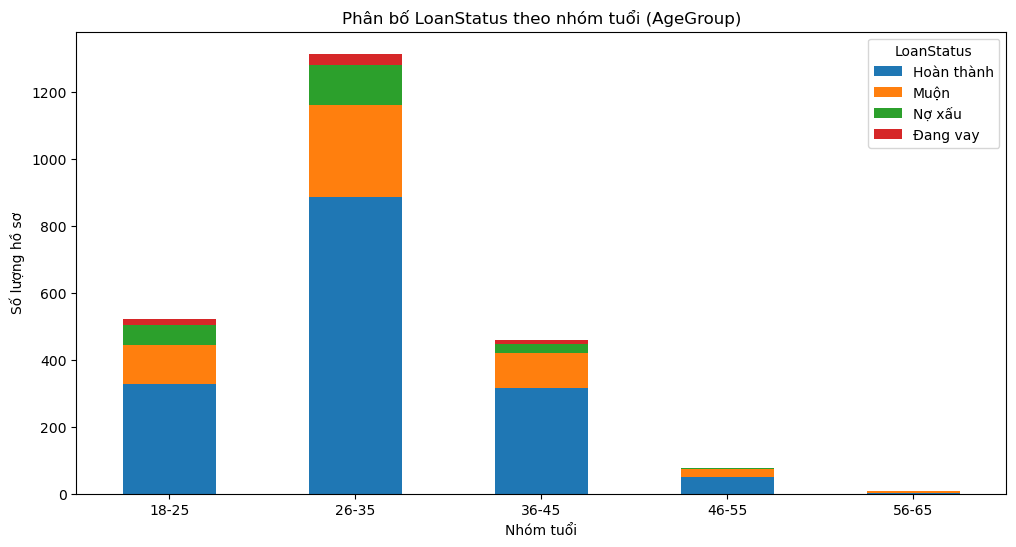

In [66]:
#Biểu đồ cột chồng – toàn bộ LoanStatus theo AgeGroup
df_crosstab = pd.crosstab(df['AgeGroup'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Phân bố LoanStatus theo nhóm tuổi (AgeGroup)")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [67]:
#Tỷ lệ Nợ xấu + Muộn theo AgeGroup
risk_by_age = (
    pd.crosstab(df['AgeGroup'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_age

LoanStatus,Nợ xấu,Muộn
AgeGroup,,
18-25,11.153846,22.307692
26-35,8.910891,20.944402
36-45,6.113537,22.925764
46-55,3.896104,29.870130
56-65,0.000000,62.500000


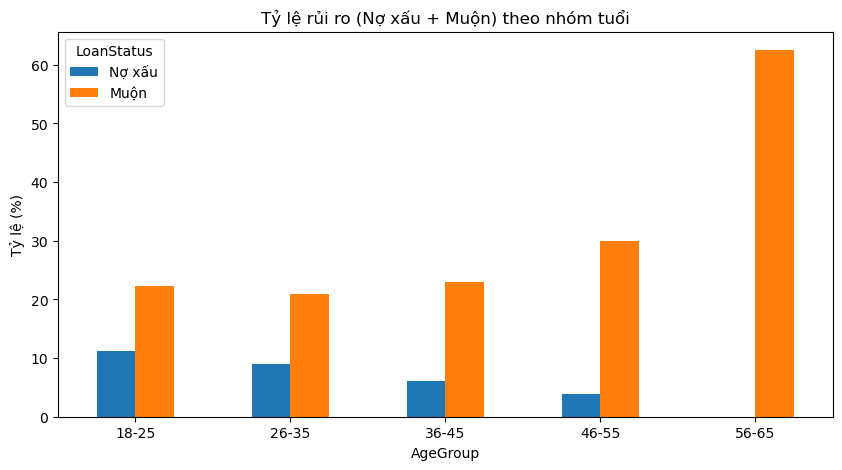

In [68]:
#Tỷ lệ “Nợ xấu” & “Muộn” theo AgeGroup
risk_by_age[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Tỷ lệ rủi ro (Nợ xấu + Muộn) theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

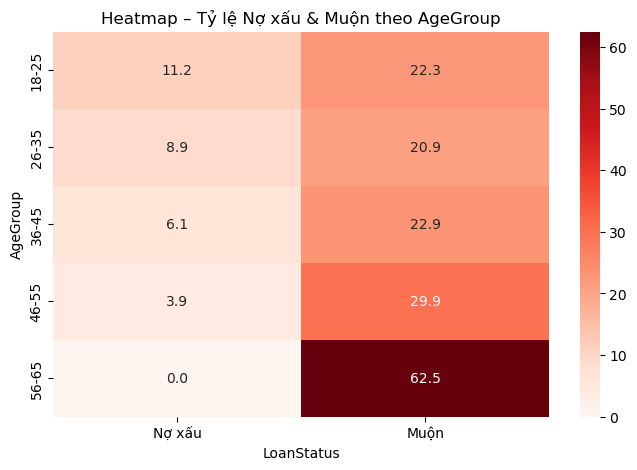

In [69]:
plt.figure(figsize=(8,5))
sns.heatmap(
    risk_by_age,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)
plt.title("Heatmap – Tỷ lệ Nợ xấu & Muộn theo AgeGroup")
plt.show()

**Insight**

Nhóm 26–35 tuổi là nhóm chiếm số lượng hồ sơ lớn nhất trong dataset, đồng thời cũng có số lượng hồ sơ “Muộn” và “Nợ xấu” cao nhất về mặt tuyệt đối. Tuy nhiên, xét theo tỷ lệ, đây không phải là nhóm rủi ro cao nhất, cho thấy quy mô lớn là nguyên nhân chính khiến số hồ sơ rủi ro nhiều.

Nhóm 18–25 tuổi có tỷ lệ Nợ xấu cao nhất trong các nhóm tuổi (khoảng 11.2%), đồng thời tỷ lệ Muộn cũng ở mức khá cao (~22%). Điều này cho thấy nhóm tuổi trẻ có mức độ rủi ro cao hơn, có thể do thu nhập chưa ổn định hoặc kinh nghiệm tài chính còn hạn chế.

Nhóm 36–45 tuổi có tỷ lệ Nợ xấu thấp hơn so với hai nhóm trẻ hơn, nhưng tỷ lệ Muộn vẫn ở mức cao (~22.9%). Điều này cho thấy rủi ro ở nhóm này không nằm ở việc mất khả năng trả nợ hoàn toàn, mà chủ yếu là chậm trả.

Nhóm 46–55 tuổi có tỷ lệ Nợ xấu thấp (~3.9%) nhưng tỷ lệ Muộn tăng lên gần 30%. Đây là dấu hiệu cho thấy áp lực tài chính có thể xuất hiện ở giai đoạn này, dù chưa chuyển thành nợ xấu.

Nhóm 56–65 tuổi có tỷ lệ Muộn rất cao (62.5%) nhưng không có nợ xấu. Tuy nhiên, số lượng hồ sơ của nhóm này rất nhỏ, nên kết quả mang tính cảnh báo hơn là kết luận chắc chắn. Nhóm tuổi này cần được theo dõi riêng do nguy cơ trễ hạn kéo dài.

Nhìn chung, dữ liệu cho thấy rủi ro không giảm dần theo tuổi như kỳ vọng. Nợ xấu tập trung nhiều hơn ở nhóm trẻ (18–25), trong khi tình trạng Muộn lại tăng rõ ở các nhóm tuổi lớn hơn. Điều này gợi ý rằng quản lý rủi ro nên phân biệt theo nhóm tuổi, đặc biệt chú ý nhóm trẻ và nhóm lớn tuổi có dấu hiệu trễ hạn cao.

##**LoanStatus vs Gender**

1. Nam / Nữ có phân bố trạng thái khoản vay khác nhau không?

2. Giới nào có tỷ lệ trạng thái nào cao hơn?

3. Giới tính nào có tỷ lệ Nợ xấu cao hơn?

4. Giới tính nào có tỷ lệ Muộn cao hơn?

5. Có khác biệt rõ rệt về hành vi tín dụng giữa Nam và Nữ không?

6. Giới tính có phải là yếu tố rủi ro quan trọng?

In [70]:
pd.crosstab(df['Gender'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
Gender,,,,
0.0,1028,308,142,41
1.0,555,216,64,25


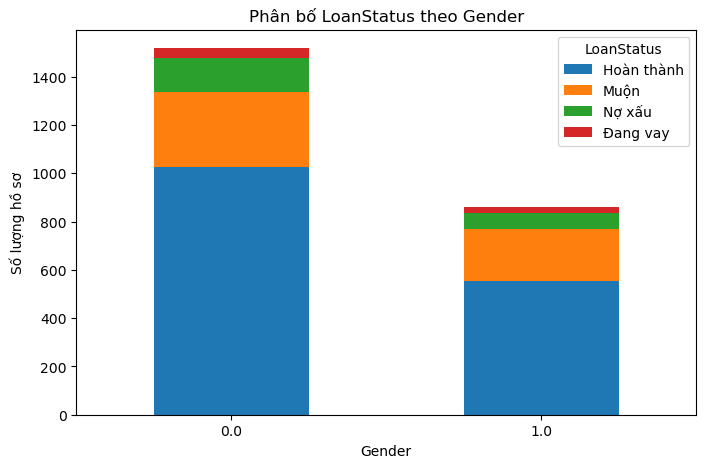

In [71]:
#Biểu đồ cột chồng – phân bố LoanStatus theo Gender
df_crosstab = pd.crosstab(df['Gender'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Phân bố LoanStatus theo Gender")
plt.xlabel("Gender")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [72]:
#Tỉ lệ Nợ xấu + Muộn theo Gender
risk_by_gender = (
    pd.crosstab(df['Gender'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_gender

LoanStatus,Nợ xấu,Muộn
Gender,,
0.0,9.348255,20.276498
1.0,7.441860,25.116279


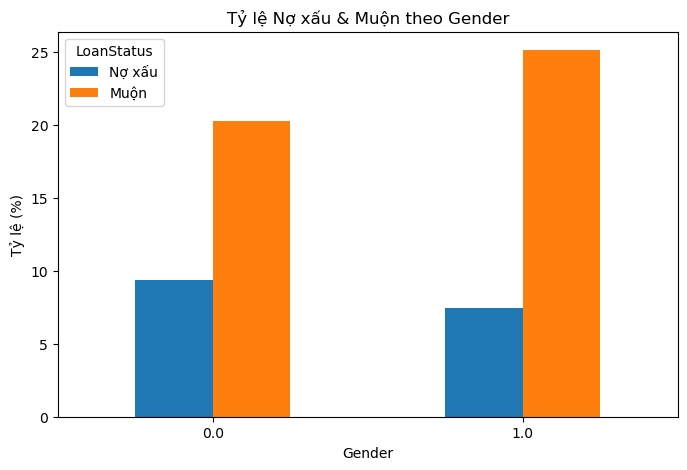

In [73]:
risk_by_gender[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(8,5))
plt.title("Tỷ lệ Nợ xấu & Muộn theo Gender")
plt.xlabel("Gender")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

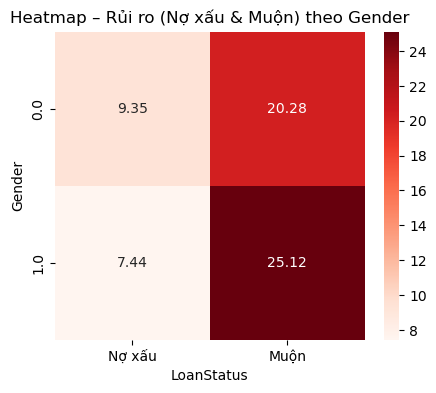

In [74]:
plt.figure(figsize=(5,4))
sns.heatmap(
    risk_by_gender,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Heatmap – Rủi ro (Nợ xấu & Muộn) theo Gender")
plt.show()

**Insight**

ề nợ xấu, nhóm Gender = 0 (Nữ) có tỷ lệ cao hơn (~9.35%) so với Gender = 1 (Nam) (~7.44%). Chênh lệch này không quá lớn, cho thấy giới tính không phải yếu tố quyết định mạnh đối với việc rơi vào nợ xấu trong dataset.

Ngược lại, ở trạng thái “Muộn”, nhóm Gender = 1 lại có tỷ lệ cao hơn rõ rệt (~25.1%) so với Gender = 0 (~20.3%). Điều này cho thấy nhóm Gender = 1 có xu hướng trả chậm nhiều hơn, dù chưa chuyển thành nợ xấu.

Nhìn tổng thể, cả hai giới đều có tỷ lệ “Muộn” cao hơn nhiều so với “Nợ xấu”, cho thấy vấn đề chính của danh mục nằm ở hành vi trả chậm, chứ không phải mất khả năng trả nợ hoàn toàn.

Kết luận chung:
Giới tính không phải là yếu tố rủi ro nổi bật khi xét riêng lẻ. Tuy nhiên, sự khác biệt về tỷ lệ “Muộn” gợi ý rằng giới tính có thể ảnh hưởng gián tiếp thông qua các yếu tố khác như thu nhập, loại sản phẩm vay hoặc hành vi tài chính. Vì vậy, cần kết hợp thêm các biến khác (tuổi, sản phẩm, thu nhập…) để đánh giá đầy đủ hơn thay vì dùng giới tính làm tiêu chí chính.

##**LoanStatus vs Salary**

1. Thu nhập cao/thấp có phân bố LoanStatus khác nhau không?

2. Thu nhập có tương quan với khả năng đúng hạn khoản vay không?

3. Thu nhập thấp → tỷ lệ Nợ xấu cao hơn không?

4. Thu nhập thấp → tỷ lệ Muộn cao hơn không?

5. Có mức thu nhập “nguy hiểm” không?

6. Thu nhập cao có thực sự rủi ro thấp?

In [75]:
pd.crosstab(df['IncomeBracket'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
IncomeBracket,,,,
10-15m,268,111,26,8
15-25m,98,43,6,5
5-10m,1041,334,148,45
<5m,143,25,25,8
>=25m,36,12,1,0


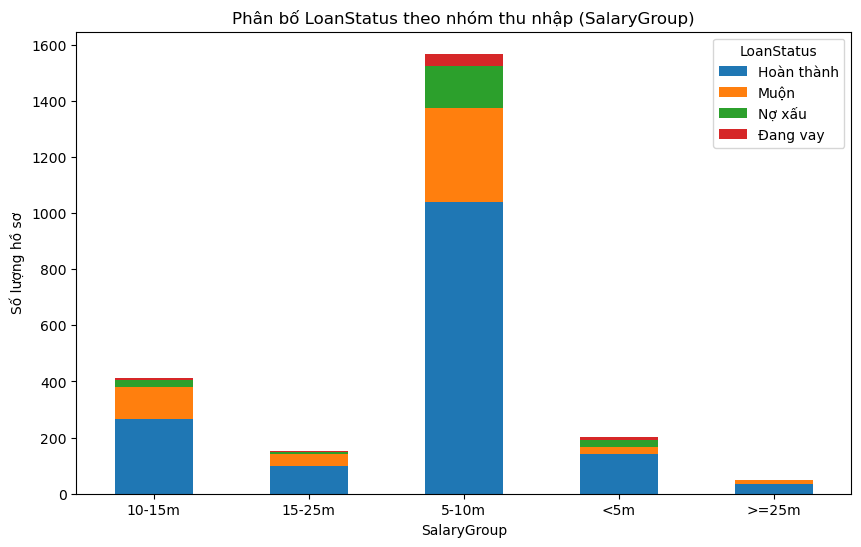

In [76]:
#Biểu đồ cột chồng – phân bố LoanStatus theo IncomeBracket
df_crosstab = pd.crosstab(df['IncomeBracket'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Phân bố LoanStatus theo nhóm thu nhập (SalaryGroup)")
plt.xlabel("SalaryGroup")
plt.ylabel("Số lượng hồ sơ")
plt.legend(title="LoanStatus")
plt.xticks(rotation=0)
plt.show()

In [77]:
#tỷ lệ Nợ xấu + Muộn theo IncomeBracket
risk_by_salary = (
    pd.crosstab(df['IncomeBracket'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_salary

LoanStatus,Nợ xấu,Muộn
IncomeBracket,,
10-15m,6.295400,26.876513
15-25m,3.947368,28.289474
5-10m,9.438776,21.301020
<5m,12.437811,12.437811
>=25m,2.040816,24.489796


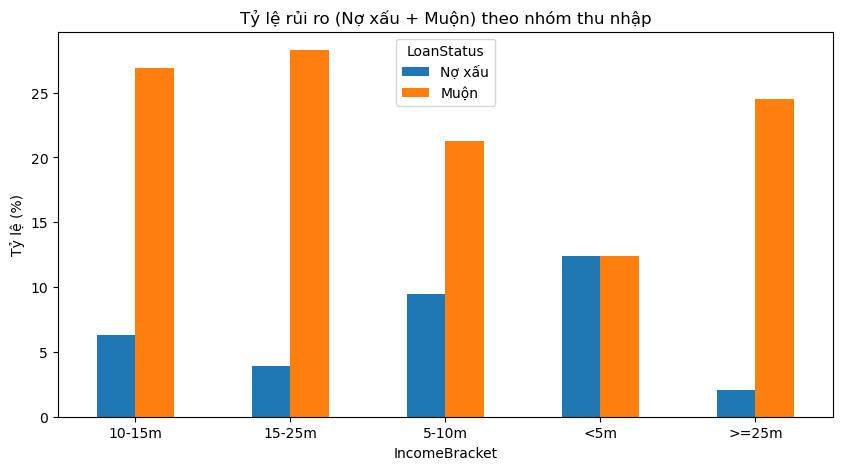

In [78]:
#Biểu đồ – Tỷ lệ Nợ xấu & Muộn theo IncomeBracket
risk_by_salary[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Tỷ lệ rủi ro (Nợ xấu + Muộn) theo nhóm thu nhập")
plt.xlabel("IncomeBracket")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

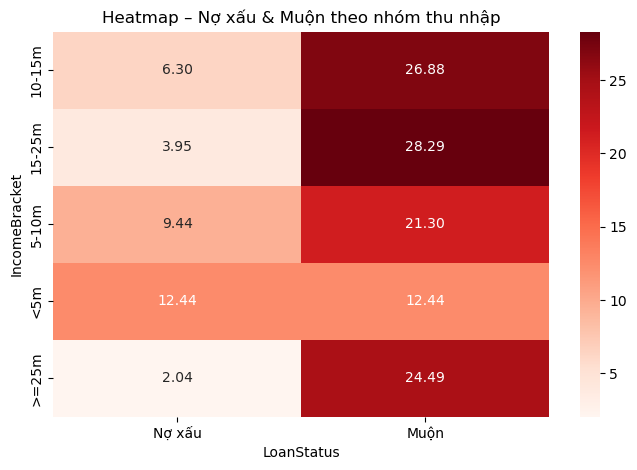

In [79]:
#Heatmap – xem nhóm thu nhập nào rủi ro nhất
plt.figure(figsize=(8,5))
sns.heatmap(
    risk_by_salary,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)
plt.title("Heatmap – Nợ xấu & Muộn theo nhóm thu nhập")
plt.show()

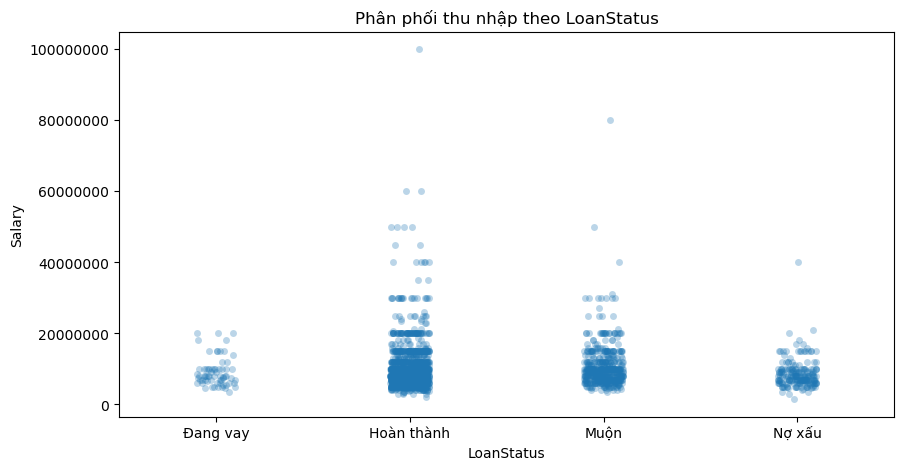

In [80]:
#Scatterplot – Salary vs LoanStatus
plt.figure(figsize=(10,5))
sns.stripplot(
    data=df,
    x='LoanStatus',
    y='Salary',
    alpha=0.3
)
plt.title("Phân phối thu nhập theo LoanStatus")
plt.ylabel("Salary")
plt.xlabel("LoanStatus")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Insight (đã chỉnh)

Phân tích mối quan hệ giữa thu nhập và trạng thái khoản vay cho thấy một số điểm đáng chú ý, nhưng không cực đoan như bản gốc.

1. Nhóm thu nhập thấp (<5 triệu và 5–10 triệu)

Nhóm <5 triệu có tỷ lệ Nợ xấu cao nhất (~12.4%), đồng thời tỷ lệ Muộn cũng ở mức cao (~12.4%).

Nhóm 5–10 triệu có tỷ lệ Muộn khá cao (~21.3%) và Nợ xấu ~9.4%.

--> Điều này cho thấy thu nhập thấp có rủi ro cao hơn rõ rệt, đặc biệt là nguy cơ chuyển sang Nợ xấu.

2. Nhóm thu nhập trung bình (10–15 triệu và 15–25 triệu)

Hai nhóm này có tỷ lệ Nợ xấu thấp hơn đáng kể (khoảng 4–6%).

Tuy nhiên, tỷ lệ Muộn vẫn khá cao (khoảng 26–28%).

--> Đây là nhóm tương đối ổn định về Nợ xấu, nhưng vẫn tồn tại rủi ro chậm trả, có thể liên quan đến dòng tiền ngắn hạn hơn là mất khả năng trả nợ.

3. Nhóm thu nhập cao (≥25 triệu)

Tỷ lệ Nợ xấu rất thấp (~2%).

Tuy nhiên, tỷ lệ Muộn vẫn cao (~24.5%), không thấp hơn rõ rệt so với nhóm thu nhập trung bình.

--> Thu nhập cao không đồng nghĩa với việc luôn trả đúng hạn. Nhóm này có thể chậm trả do yếu tố hành vi (chủ quan, nhiều khoản vay song song), dù ít rơi vào Nợ xấu.

4. Nhóm thu nhập “nguy hiểm” nhất

Xét tổng thể, nhóm <5 triệu là nhóm cần chú ý nhất vì:

Nợ xấu cao nhất

Muộn cũng ở mức cao

Các nhóm khác chủ yếu có vấn đề ở Muộn, chưa chuyển hóa mạnh sang Nợ xấu.

5. Kết luận chung

Thu nhập có liên quan đến rủi ro, nhưng không phải yếu tố quyết định duy nhất.

Thu nhập thấp là tín hiệu cảnh báo rõ ràng cho Nợ xấu.

Thu nhập cao vẫn có thể Muộn nhiều, nên không thể đánh giá rủi ro chỉ dựa vào mức lương.

6. Gợi ý

<10 triệu: siết điều kiện, hạn mức thấp, nhắc nợ sớm.

10–25 triệu: nhóm tương đối an toàn, có thể mở rộng nhưng cần quản lý hành vi chậm trả.

≥25 triệu: cần theo dõi hành vi vay và lịch sử trả nợ, không nên mặc định là rủi ro thấp.

##**LoanStatus vs JobName**

1. Nghề nào có chất lượng khoản vay tốt nhất (tỷ lệ “Đã tất toán” cao)?

2. Nghề nào có xu hướng “Muộn” nhiều?

3. Nghề nào có tỷ lệ “Nợ xấu” cao nhất?

4. Nghề nào có tỷ lệ “Muộn” cao nhất?

5. Nghề nghiệp ổn định (văn phòng) có rủi ro thấp hơn nghề tự do/công nhân không?

6. Có nghề nào ít hồ sơ nhưng rủi ro cực cao?

In [81]:
pd.crosstab(df['JobName'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
JobName,,,,
Bán hàng,8,15,0,2
Bảo vệ,20,9,1,1
Bộ đội / công an,4,0,0,0
CQ Hành chính Nhà nước,7,2,0,0
Chăm sóc KH,3,3,0,1
Các hình thức tự kinh doanh khác,103,18,13,1
Công nhân,14,24,6,5
Công việc ko ổn định/Thu nhập thất thường,0,1,0,0
Giám Sát,10,10,0,1


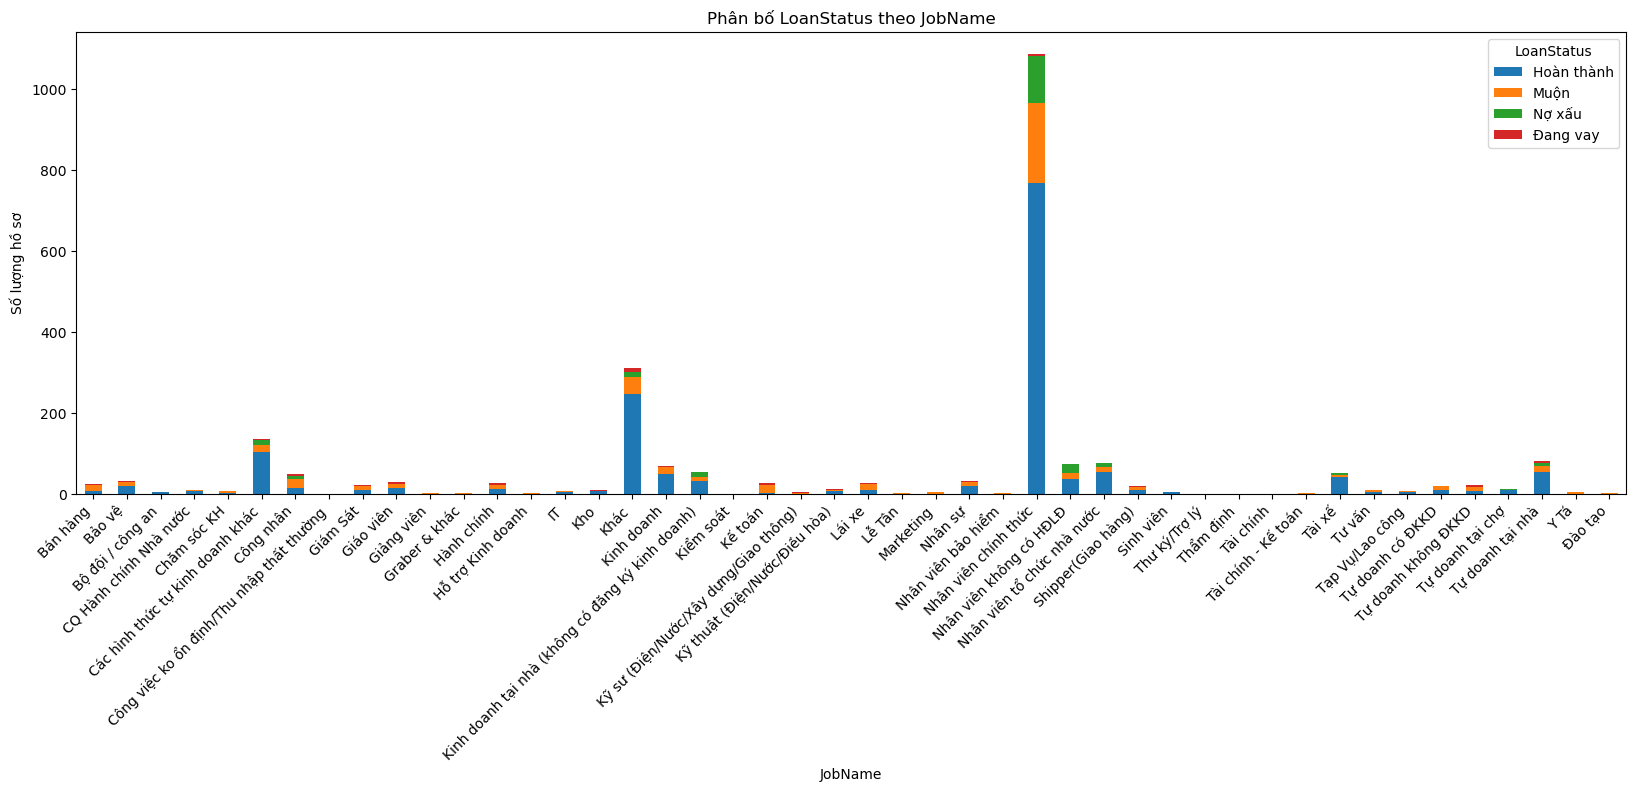

In [82]:
#Biểu đồ cột chồng – LoanStatus theo JobName
top_jobs = df['JobName'].value_counts().index
subset = df[df['JobName'].isin(top_jobs)]

df_crosstab = pd.crosstab(subset['JobName'], subset['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(20,6))
plt.title("Phân bố LoanStatus theo JobName")
plt.xlabel("JobName")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()


In [83]:
#Tỷ lệ Nợ xấu + Muộn theo nghề
risk_by_job = (
    pd.crosstab(df['JobName'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_job

LoanStatus,Nợ xấu,Muộn
JobName,,
Bán hàng,0.000000,60.000000
Bảo vệ,3.225806,29.032258
Bộ đội / công an,0.000000,0.000000
CQ Hành chính Nhà nước,0.000000,22.222222
Chăm sóc KH,0.000000,42.857143
Các hình thức tự kinh doanh khác,9.629630,13.333333
Công nhân,12.244898,48.979592
Công việc ko ổn định/Thu nhập thất thường,0.000000,100.000000
Giám Sát,0.000000,47.619048


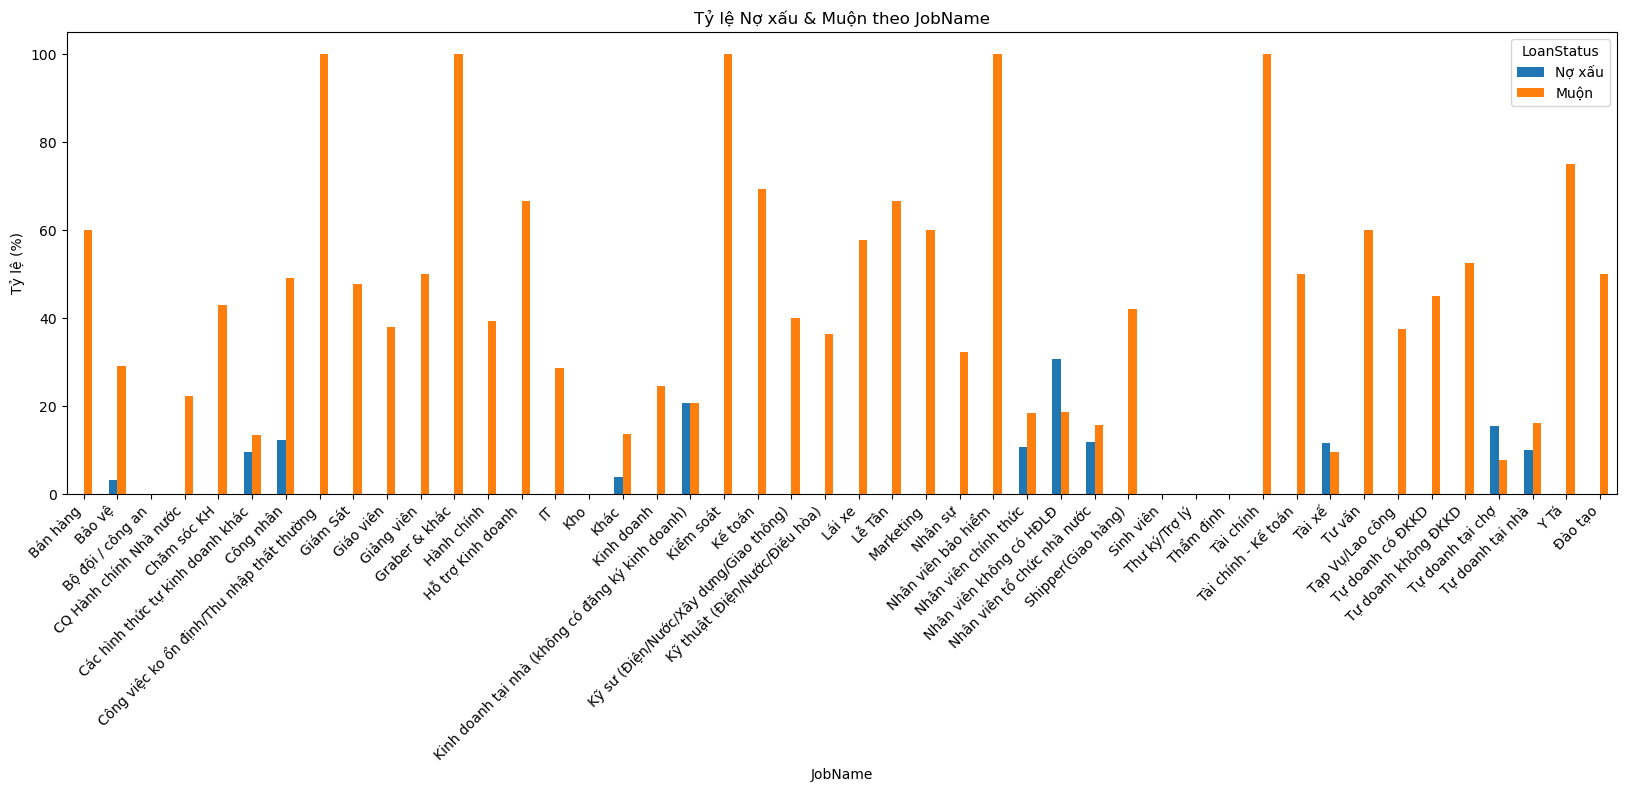

In [84]:
#Biểu đồ – Tỷ lệ Nợ xấu & Muộn theo nghề
risk_by_job[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(20,6))
plt.title("Tỷ lệ Nợ xấu & Muộn theo JobName")
plt.xlabel("JobName")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="LoanStatus")
plt.show()

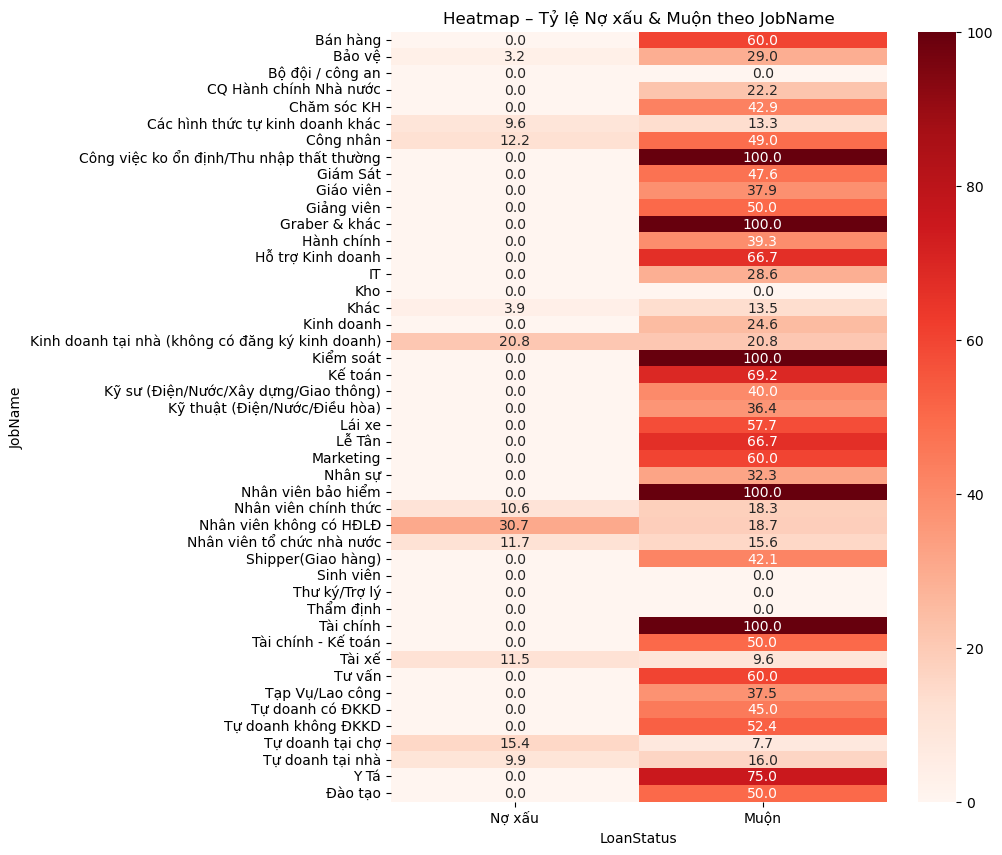

In [85]:
#Heatmap – Rủi ro theo JobName (Nợ xấu & Muộn)
plt.figure(figsize=(8,10))
sns.heatmap(
    risk_by_job,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Tỷ lệ Nợ xấu & Muộn theo JobName")
plt.show()


**Insight**

1. Nghề có tỷ lệ “Muộn” cao tập trung ở nhóm thu nhập không ổn định

Một số nghề có tỷ lệ Muộn rất cao (nhiều nghề trên 50%, thậm chí 100%), chủ yếu rơi vào các nhóm:

Công việc không ổn định / thu nhập thất thường

Tự do, tự kinh doanh nhỏ, shipper, grabber, bán hàng, bảo vệ, lễ tân…

Điều này cho thấy các nhóm nghề này dễ chậm thanh toán, khả năng do thu nhập không đều hoặc phụ thuộc nhiều vào dòng tiền ngắn hạn.

2. Nhiều nghề có tỷ lệ “Muộn” cao nhưng không đi kèm Nợ xấu

Phần lớn các nghề có tỷ lệ Muộn cao lại có tỷ lệ Nợ xấu = 0% hoặc rất thấp.
Điều này cho thấy:

Khách hàng chậm trả nhưng vẫn có xu hướng trả đủ, chưa chuyển thành nợ xấu.

Rủi ro chính ở đây là áp lực thu hồi và quản lý dòng tiền, hơn là mất vốn.

3. Nợ xấu chỉ xuất hiện rõ ở một số nghề cụ thể

Một số nghề có tỷ lệ Nợ xấu đáng chú ý, dù không chiếm số lượng lớn hồ sơ, ví dụ:

Công nhân

Kinh doanh tại nhà (không đăng ký kinh doanh)

Nhân viên không có HĐLĐ

Tự doanh (một số nhóm)

Đây là các nhóm vừa có thu nhập không ổn định, vừa thiếu ràng buộc pháp lý, nên rủi ro chuyển từ Muộn sang Nợ xấu cao hơn.

4. Các nghề ổn định có rủi ro thấp và phân bố đều hơn

Nhóm nghề như:

Nhân viên chính thức

Kế toán, hành chính, kỹ thuật, giáo viên, nhân sự

Có đặc điểm chung:

Tỷ lệ Nợ xấu thấp

Tỷ lệ Muộn ở mức trung bình

Phân bố hồ sơ lớn → kết luận đáng tin cậy hơn

Những nghề này cho thấy thu nhập ổn định giúp giảm rủi ro, dù không loại bỏ hoàn toàn việc chậm trả.

5. Cần thận trọng với các nghề có rất ít hồ sơ nhưng tỷ lệ cực đoan

Một số nghề có:

Rất ít hồ sơ (dưới 10)

Tỷ lệ Muộn hoặc Nợ xấu = 100%

→ Không nên kết luận rủi ro cao ngay, vì tỷ lệ này dễ bị bóp méo do mẫu quá nhỏ.
Các nhóm này chỉ nên xem là tín hiệu cảnh báo, cần thêm dữ liệu để xác nhận.

6. Tổng kết

Nghề nghiệp có liên quan rõ đến rủi ro, nhưng không phải yếu tố quyết định duy nhất.

Nghề thu nhập không ổn định → Muộn cao.

Nợ xấu chỉ thực sự nổi bật ở các nhóm vừa thiếu ổn định, vừa thiếu ràng buộc lao động.

Với các nghề phổ biến, ổn định → rủi ro thấp và dễ quản lý hơn.

##**LoanStatus vs ResidenceType**

1. Các nhóm cư trú có phân bố LoanStatus khác nhau không?

2. Nhóm cư trú nào có tỷ lệ "Đúng hạn" cao nhất (ổn định nhất)?

3. Nhóm cư trú nào có xu hướng Muộn nhiều?

4. Nhóm cư trú nào có tỷ lệ Nợ xấu cao nhất?

5. Nhóm cư trú nào có tỷ lệ Muộn cao nhất?

In [86]:
pd.crosstab(df['Hình thức cư trú'], df['LoanStatus'])


LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
Hình thức cư trú,,,,
Khác,127,12,3,0
Nhà sở hữu,26,32,0,4
Sở hữu cá nhân,396,93,34,9
Sở hữu nhà nước,7,0,1,0
Thuê,282,195,60,32
Thuộc sở hữu của họ hàng,231,68,54,5
Đồng sở hữu,517,125,54,16


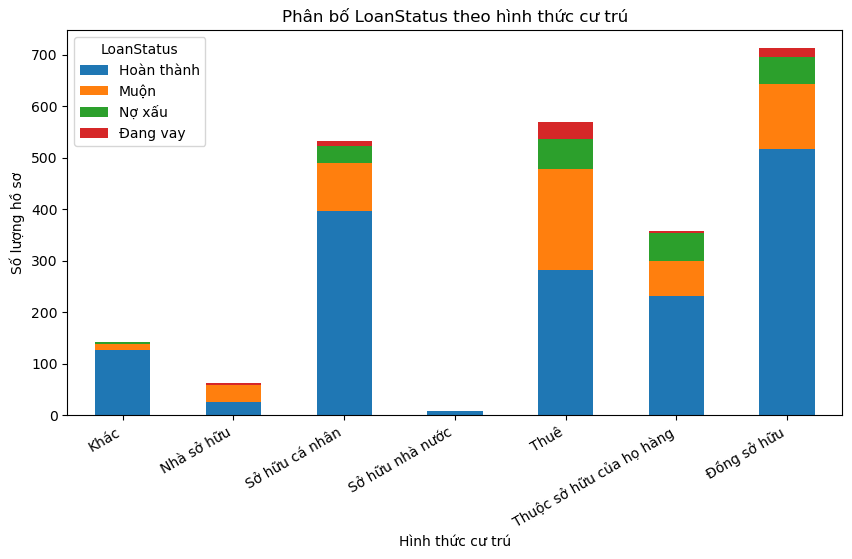

In [87]:
#Biểu đồ cột chồng – LoanStatus theo Hình thức cư trú
df_crosstab = pd.crosstab(df['Hình thức cư trú'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Phân bố LoanStatus theo hình thức cư trú")
plt.xlabel("Hình thức cư trú")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=30, ha='right')
plt.legend(title="LoanStatus")
plt.show()

In [88]:
#Tính tỷ lệ Nợ xấu + Muộn theo Hình thức cư trú
risk_by_res = (
    pd.crosstab(df['Hình thức cư trú'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_res


LoanStatus,Nợ xấu,Muộn
Hình thức cư trú,,
Khác,2.112676,8.450704
Nhà sở hữu,0.000000,51.612903
Sở hữu cá nhân,6.390977,17.481203
Sở hữu nhà nước,12.500000,0.000000
Thuê,10.544815,34.270650
Thuộc sở hữu của họ hàng,15.083799,18.994413
Đồng sở hữu,7.584270,17.556180


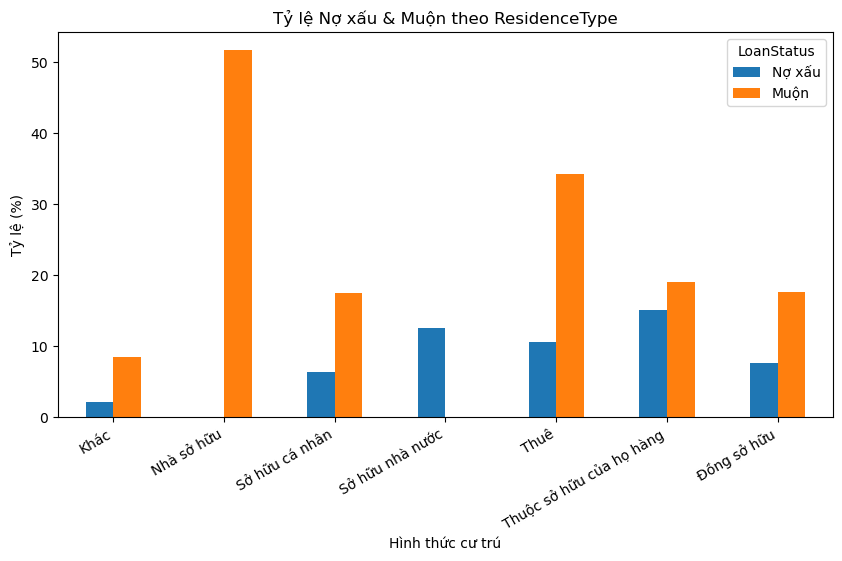

In [89]:
#Biểu đồ – Tỷ lệ rủi ro theo hình thức cư trú
risk_by_res[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Tỷ lệ Nợ xấu & Muộn theo ResidenceType")
plt.xlabel("Hình thức cư trú")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=30, ha='right')
plt.legend(title="LoanStatus")
plt.show()

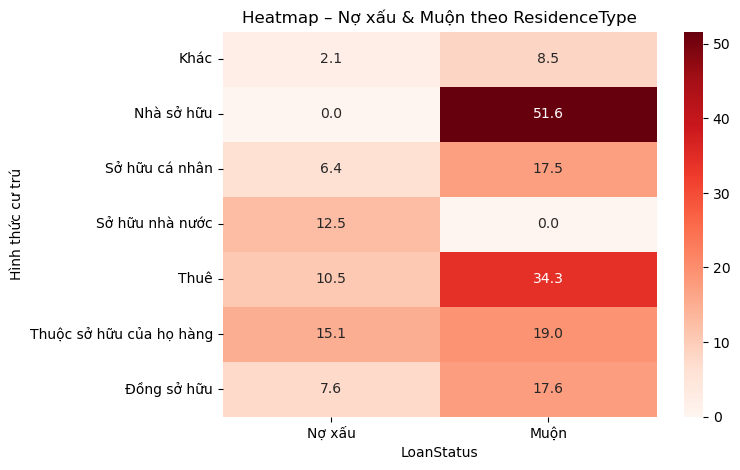

In [90]:
#Heatmap – để so sánh rủi ro theo từng loại cư trú
plt.figure(figsize=(7,5))
sns.heatmap(
    risk_by_res,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Nợ xấu & Muộn theo ResidenceType")
plt.show()

**Insight**

Phân tích theo hình thức cư trú cho thấy có sự khác biệt khá rõ về hành vi trả nợ, đặc biệt là ở tỷ lệ “Muộn” giữa các nhóm.

Nhóm Nhà sở hữu có tỷ lệ Muộn cao nhất (~51.6%), dù không ghi nhận Nợ xấu. Điều này cho thấy dù có nhà riêng, khách hàng vẫn có xu hướng trả chậm, có thể do áp lực tài chính hoặc phân bổ chi tiêu chưa hợp lý.

Nhóm Thuê có mức rủi ro tương đối cao, với tỷ lệ Muộn ~34.3% và Nợ xấu ~10.5%. Đây là nhóm thể hiện rủi ro rõ ràng hơn so với các nhóm sở hữu nhà, phản ánh mức độ ổn định nơi ở và tài chính thấp hơn.

Nhóm Thuộc sở hữu của hộ hàng nổi bật ở cả hai khía cạnh, với Nợ xấu cao nhất (~15.1%) và tỷ lệ Muộn ~19%. Đây là nhóm cần được theo dõi kỹ vì vừa có rủi ro trả chậm, vừa có khả năng chuyển sang nợ xấu.

Nhóm Sở hữu cá nhân và Đồng sở hữu có mức rủi ro trung bình, với tỷ lệ Muộn khoảng 17–18% và Nợ xấu dưới 8%, cho thấy mức độ ổn định tương đối.

Nhóm Sở hữu nhà nước có tỷ lệ Nợ xấu ~12.5% nhưng không có Muộn, tuy nhiên số lượng hồ sơ rất ít nên chưa thể kết luận chắc chắn, cần thận trọng khi diễn giải.

Nhóm Khác có tỷ lệ Muộn và Nợ xấu thấp, nhưng do tính chất không rõ ràng và số lượng không lớn, nên khả năng đây là nhóm “gộp” nhiều trường hợp khác nhau, cần xem xét lại cách phân loại.

Tổng quan, hình thức cư trú có ảnh hưởng đáng kể đến hành vi trả nợ, nhưng tác động chủ yếu thể hiện ở trả chậm (Muộn) hơn là Nợ xấu. Các nhóm có mức độ ổn định nơi ở thấp hơn (Thuê, Thuộc sở hữu của hộ hàng) thường đi kèm rủi ro cao hơn và nên được ưu tiên kiểm soát trong quá trình thẩm định.

#**Risk Variables vs LoanStatus**

##**TS_CREDIT_SCORE_V2 vs LoanStatus**

1. Điểm tín dụng thấp có dẫn đến LoanStatus xấu không?

2. Điểm càng thấp --> tỉ lệ “Muộn” và “Nợ xấu” có tăng không?

3. Phân khúc điểm tín dụng nào chiếm nhiều hồ sơ nhất?

4. Điểm < 600 (Low) có tỷ lệ Nợ xấu cao nhất không?

5. Điểm 600–700 (Medium) có “Muộn” cao hơn Nợ xấu không?

6. Điểm >= 800 (Excellent) gần như an toàn?

7. Có khoảng rủi ro nào không? (ví dụ: 560–620)

In [91]:
pd.crosstab(df['CreditScoreGroup'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
CreditScoreGroup,,,,
Excellent,6,0,0,1
Good,188,63,3,9
Low (High Risk),797,224,161,22
Medium,595,238,42,34


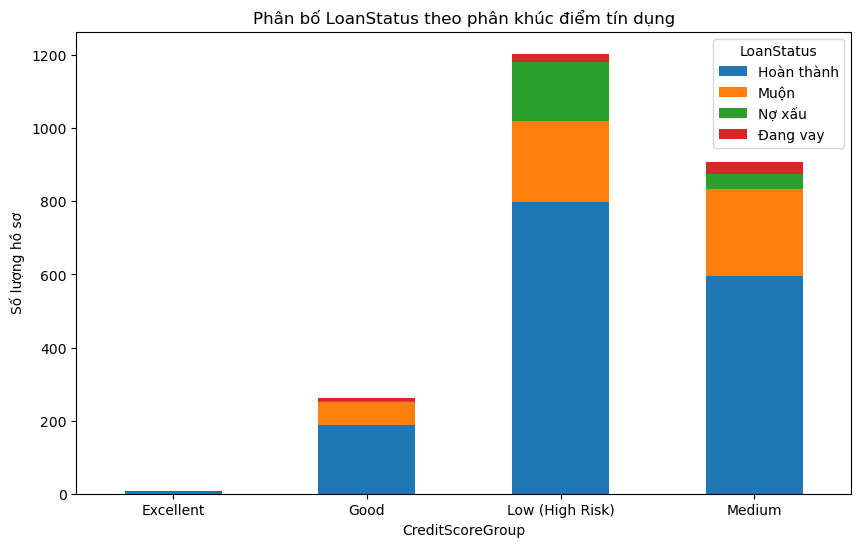

In [92]:
#Biểu đồ cột chồng – toàn bộ LoanStatus theo CreditScoreGroup
df_crosstab = pd.crosstab(df['CreditScoreGroup'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Phân bố LoanStatus theo phân khúc điểm tín dụng")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Số lượng hồ sơ")
plt.legend(title="LoanStatus")
plt.xticks(rotation=0)
plt.show()

In [93]:
#Tính tỷ lệ rủi ro Nợ xấu + Muộn theo CreditScoreGroup
risk_by_score = (
    pd.crosstab(df['CreditScoreGroup'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_score

LoanStatus,Nợ xấu,Muộn
CreditScoreGroup,,
Excellent,0.000000,0.000000
Good,1.140684,23.954373
Low (High Risk),13.372093,18.604651
Medium,4.620462,26.182618


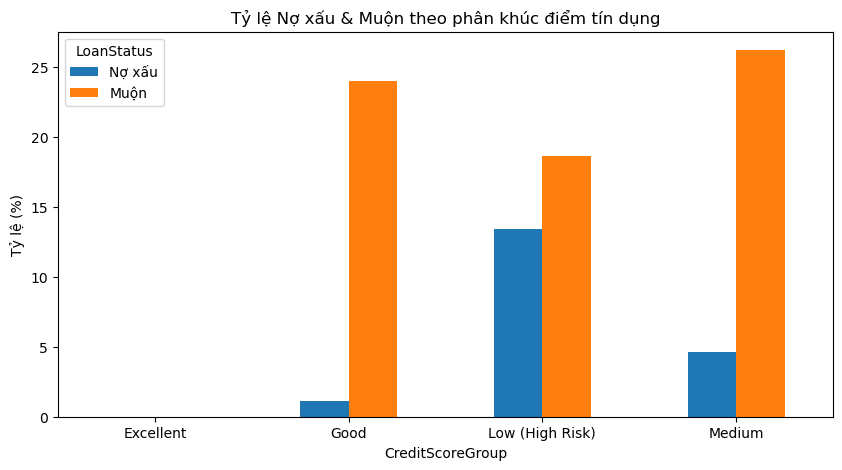

In [94]:
#Bar chart – Nợ xấu & Muộn theo CreditScoreGroup
risk_by_score[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(10,5))
plt.title("Tỷ lệ Nợ xấu & Muộn theo phân khúc điểm tín dụng")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

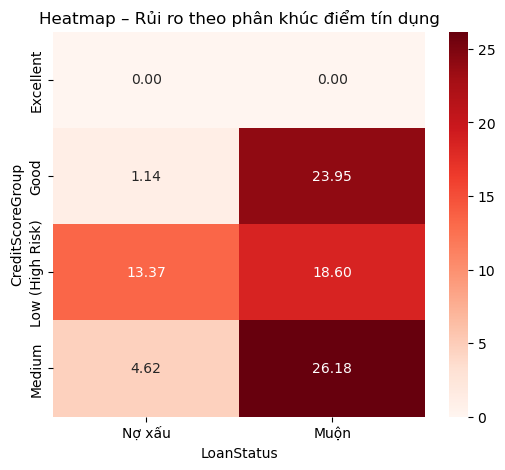

In [95]:
#Heatmap – Điểm tín dụng vs Rủi ro (Nợ xấu + Muộn)
plt.figure(figsize=(6,5))
sns.heatmap(
    risk_by_score,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Heatmap – Rủi ro theo phân khúc điểm tín dụng")
plt.show()

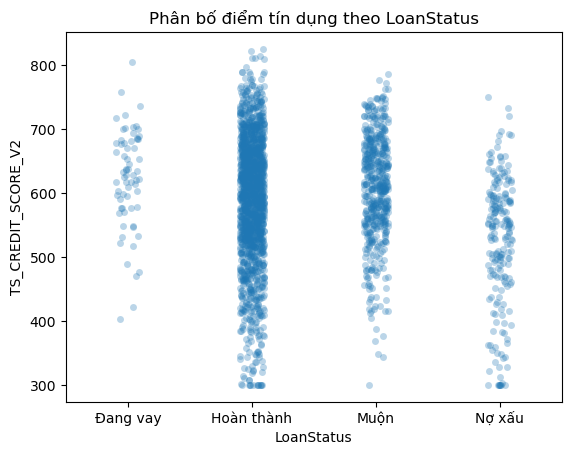

In [96]:
#Scatter plot – TS_CREDIT_SCORE_V2 vs LoanStatus --> Cho thấy điểm thấp tập trung ở Nợ xấu / Muộn.
sns.stripplot(
    data=df,
    x='LoanStatus',
    y='TS_CREDIT_SCORE_V2',
    alpha=0.3
)
plt.title("Phân bố điểm tín dụng theo LoanStatus")
plt.show()

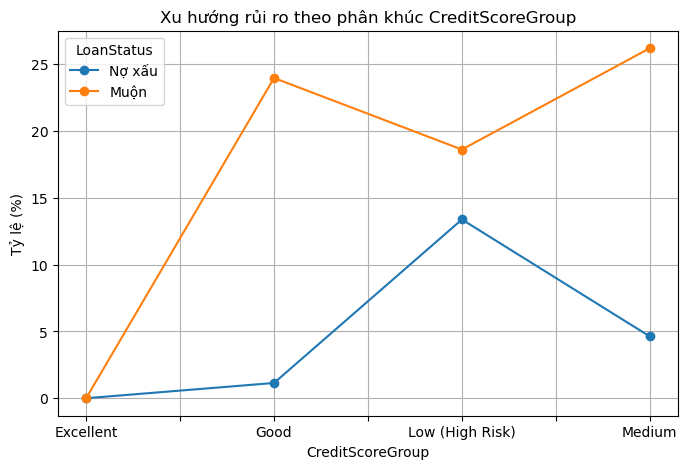

In [97]:
#Line chart – Gradient rủi ro theo phân nhóm điểm tín dụng
risk_by_score[['Nợ xấu', 'Muộn']].plot(kind='line', marker='o', figsize=(8,5))
plt.title("Xu hướng rủi ro theo phân khúc CreditScoreGroup")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Tỷ lệ (%)")
plt.grid(True)
plt.show()

**Insight**

Phân tích cho thấy điểm tín dụng (TS_CREDIT_SCORE_V2) có mối liên hệ rõ ràng với trạng thái khoản vay, đặc biệt là với Nợ xấu. Khi điểm tín dụng giảm, rủi ro tăng lên khá rõ.

Nhóm Low (High Risk) là phân khúc rủi ro cao nhất:

Chiếm số lượng hồ sơ lớn nhất.

Có tỷ lệ Nợ xấu cao nhất (~13.4%).

Đồng thời có tỷ lệ Muộn tương đối cao (~18.6%).
→ Đây là nhóm cần được kiểm soát chặt nhất trong quá trình phê duyệt và theo dõi sau giải ngân.

Nhóm Medium (600–700):

Tỷ lệ Nợ xấu ở mức trung bình (~4.6%), thấp hơn nhiều so với nhóm Low.

Tuy nhiên, tỷ lệ Muộn lại cao nhất trong các nhóm (~26.2%).
→ Điều này cho thấy nhóm Medium có xu hướng trả chậm nhiều nhưng chưa chuyển thành nợ xấu, tức là rủi ro thiên về chậm thanh toán hơn là mất khả năng trả nợ.

Nhóm Good (700–800):

Tỷ lệ Nợ xấu rất thấp (~1.1%).

Tỷ lệ Muộn vẫn còn đáng kể (~24%).
→ Chất lượng tín dụng nhìn chung tốt, nhưng hành vi trả chậm vẫn phổ biến, cho thấy điểm tín dụng tốt không đồng nghĩa tuyệt đối với trả đúng hạn.

Nhóm Excellent (≥800):

Gần như không có Nợ xấu và không có Muộn.

Số lượng hồ sơ ít nhưng thể hiện mức độ an toàn rất cao.
→ Phù hợp để ưu tiên các chính sách ưu đãi (lãi suất thấp, pre-approved).

Nhìn tổng thể:

Rủi ro Nợ xấu giảm rõ rệt khi điểm tín dụng tăng.

Tuy nhiên, rủi ro Muộn không giảm đều theo điểm, đặc biệt vẫn cao ở nhóm Medium và Good.

Điều này cho thấy cần phân biệt rõ giữa rủi ro chậm trả và rủi ro mất khả năng trả nợ, thay vì gộp chung trong một thước đo.

Qua đó:

Điểm tín dụng là biến rất mạnh để dự báo Nợ xấu.

Với các nhóm Medium và Good, nên tập trung vào quản lý hành vi trả chậm (nhắc nợ, lịch thanh toán linh hoạt) hơn là siết chặt phê duyệt.

Nhóm Low cần kiểm soát từ đầu vào (hạn mức, điều kiện vay).

Nhóm Excellent có thể khai thác để tối ưu doanh thu với rủi ro thấp.

##**HasBadDebt vs LoanStatus**

1. LoanStatus của hai nhóm 0 và 1 khác nhau như thế nào?

2. Nhóm có CIC xấu (HasBadDebt=1) có xu hướng bị Muộn / Nợ xấu cao hơn không?

3. HasBadDebt = 1 có dẫn đến tỷ lệ Nợ xấu cao hơn nhiều không?

4. Nhóm không có CIC xấu nhưng vẫn Nợ xấu có nhiều không?

In [98]:
pd.crosstab(df['HasBadDebt'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
HasBadDebt,,,,
0,1410,489,158,64
1,176,36,48,2


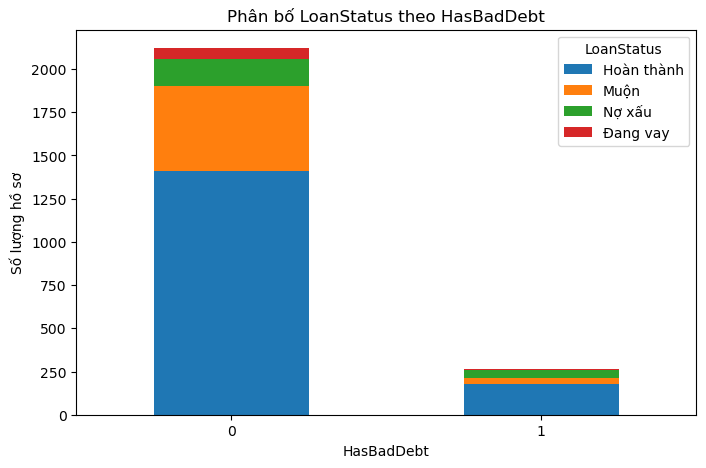

In [99]:
#Biểu đồ cột chồng – LoanStatus theo HasBadDebt
df_crosstab = pd.crosstab(df['HasBadDebt'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Phân bố LoanStatus theo HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [100]:
risk_by_baddebt = (
    pd.crosstab(df['HasBadDebt'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_baddebt

LoanStatus,Nợ xấu,Muộn
HasBadDebt,,
0,7.449316,23.055163
1,18.320611,13.740458


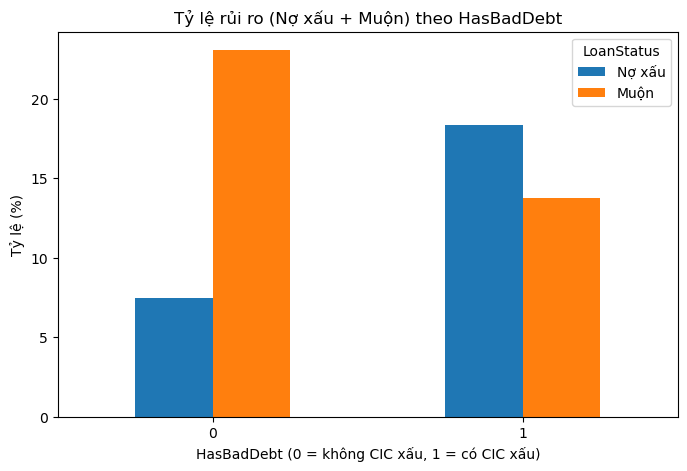

In [101]:
#Bar chart – Tỷ lệ Nợ xấu & Muộn theo HasBadDebt
risk_by_baddebt[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(8,5))
plt.title("Tỷ lệ rủi ro (Nợ xấu + Muộn) theo HasBadDebt")
plt.xlabel("HasBadDebt (0 = không CIC xấu, 1 = có CIC xấu)")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

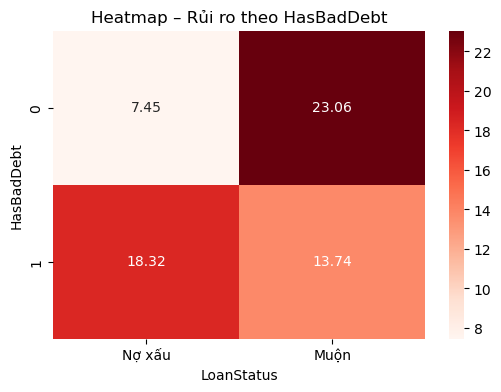

In [102]:
#Heatmap – So sánh rủi ro theo HasBadDebt
plt.figure(figsize=(6,4))
sns.heatmap(
    risk_by_baddebt,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)
plt.title("Heatmap – Rủi ro theo HasBadDebt")
plt.show()

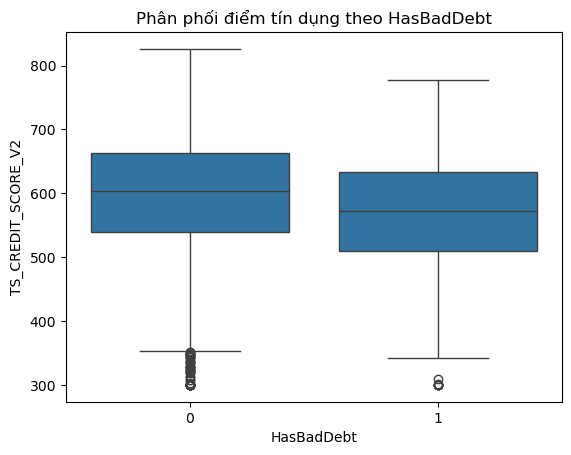

In [103]:
#Phân bố điểm tín dụng theo HasBadDebt --> Để kiểm tra xem CIC xấu có kéo điểm xuống?
sns.boxplot(data=df, x='HasBadDebt', y='TS_CREDIT_SCORE_V2')
plt.title("Phân phối điểm tín dụng theo HasBadDebt")
plt.show()

**Insight**

Kết quả cho thấy HasBadDebt có ảnh hưởng rõ rệt đến LoanStatus, nhưng mức độ ảnh hưởng khác nhau giữa “Muộn” và “Nợ xấu”.

Nhóm không có CIC xấu (HasBadDebt = 0) chiếm đa số hồ sơ trong dataset. Tuy nhiên, nhóm này vẫn ghi nhận tỷ lệ Muộn khá cao (~23.1%), trong khi tỷ lệ Nợ xấu ở mức thấp (~7.4%). Điều này cho thấy việc không có CIC xấu không đồng nghĩa với hành vi trả nợ đúng hạn, mà chủ yếu phản ánh khách hàng chưa từng rơi vào trạng thái mất khả năng trả nợ.

Ngược lại, nhóm có CIC xấu (HasBadDebt = 1) thể hiện rủi ro Nợ xấu cao hơn rõ rệt, với tỷ lệ Nợ xấu (~18.3%), cao hơn khoảng 2.5 lần so với nhóm không CIC xấu.

Trong khi đó, tỷ lệ Muộn của nhóm này thấp hơn (~13.7%), cho thấy các khoản vay của nhóm có CIC xấu có xu hướng chuyển nhanh sang Nợ xấu thay vì chỉ dừng ở trạng thái trả chậm.

Quan sát phân phối điểm tín dụng theo HasBadDebt cho thấy nhóm có CIC xấu có điểm tín dụng trung vị thấp hơn, tuy nhiên vẫn tồn tại sự chồng lấn đáng kể giữa hai nhóm. Điều này cho thấy CIC xấu là tín hiệu rủi ro quan trọng nhưng không đủ để phân tách hoàn toàn hành vi tín dụng nếu đứng một mình.

Tổng hợp lại, HasBadDebt là biến dự báo mạnh đối với rủi ro Nợ xấu, nhưng không phản ánh tốt rủi ro Muộn. Do đó, biến này nên được kết hợp với các yếu tố hành vi trả nợ, điểm tín dụng và thu nhập để đánh giá rủi ro toàn diện hơn, thay vì sử dụng độc lập.

##**HasLatePayment vs LoanStatus**

1. Phân bố LoanStatus của 2 nhóm có khác biệt không?

2. Nhóm trả chậm có xu hướng “Muộn” hoặc “Nợ xấu” nhiều hơn không?

3. HasLatePayment = 1 có tỷ lệ “Muộn” cao hơn bao nhiêu lần so với 0?

4. Nhóm trả chậm có tỷ lệ “Nợ xấu” cao hơn đáng kể không?

5. Nhóm không trả chậm vẫn có nợ xấu – lý do vì sao?

In [104]:
pd.crosstab(df['HasLatePayment'], df['LoanStatus'])

LoanStatus,Hoàn thành,Muộn,Nợ xấu,Đang vay
HasLatePayment,,,,
0,1368,429,187,63
1,218,96,19,3


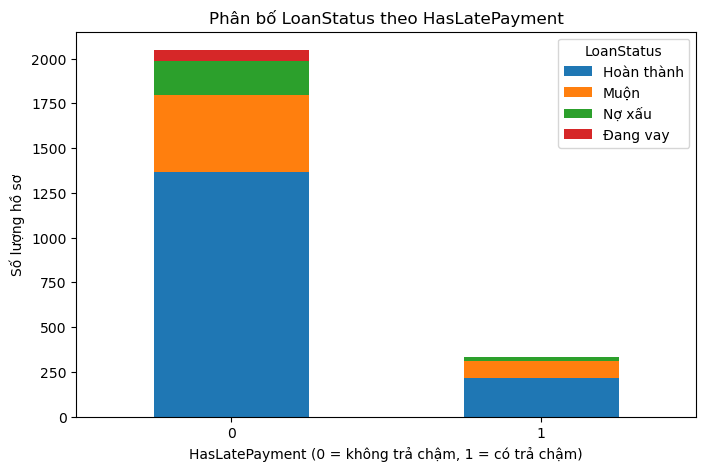

In [105]:
#Biểu đồ cột chồng – LoanStatus theo HasLatePayment
df_crosstab = pd.crosstab(df['HasLatePayment'], df['LoanStatus'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Phân bố LoanStatus theo HasLatePayment")
plt.xlabel("HasLatePayment (0 = không trả chậm, 1 = có trả chậm)")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

In [106]:
#Tỷ lệ Nợ xấu + Muộn theo HasLatePayment
risk_by_late = (
    pd.crosstab(df['HasLatePayment'], df['LoanStatus'], normalize='index') * 100
)[['Nợ xấu', 'Muộn']]

risk_by_late

LoanStatus,Nợ xấu,Muộn
HasLatePayment,,
0,9.135320,20.957499
1,5.654762,28.571429


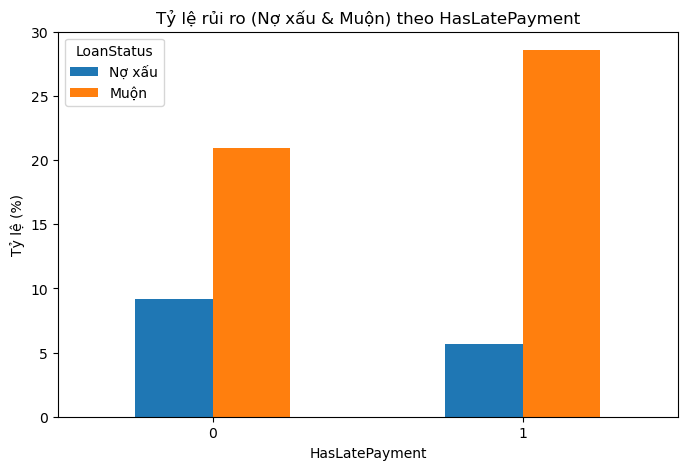

In [107]:
#Bar chart – Tỷ lệ rủi ro theo HasLatePayment
risk_by_late[['Nợ xấu', 'Muộn']].plot(kind='bar', figsize=(8,5))
plt.title("Tỷ lệ rủi ro (Nợ xấu & Muộn) theo HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="LoanStatus")
plt.show()

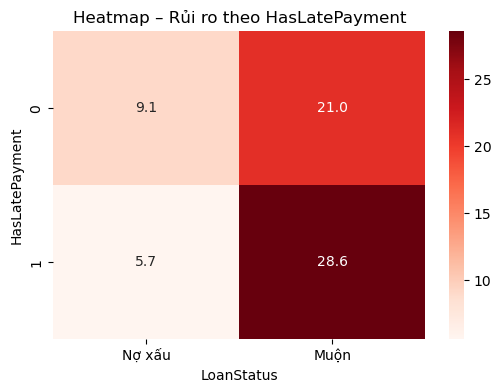

In [108]:
#Heatmap – so sánh rõ rủi ro giữa Không và Có HasLatePayment
plt.figure(figsize=(6,4))
sns.heatmap(
    risk_by_late,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Rủi ro theo HasLatePayment")
plt.show()

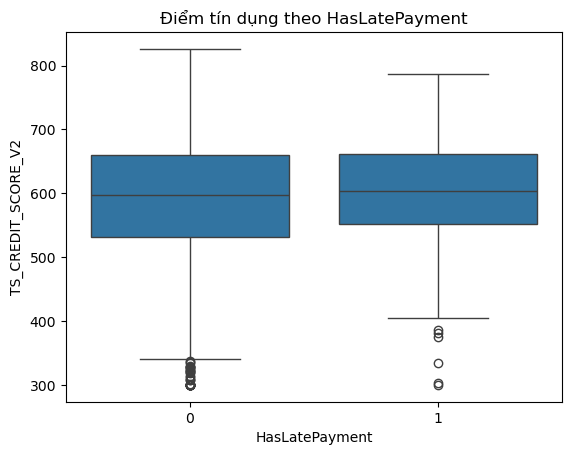

In [109]:
#Scatterplot - Phân bố điểm tín dụng theo HasLatePayment --> Kiểm tra xem khách trả chậm có điểm thấp hơn không
sns.boxplot(data=df, x='HasLatePayment', y='TS_CREDIT_SCORE_V2')
plt.title("Điểm tín dụng theo HasLatePayment")
plt.show()

**Insight**

Kết quả phân tích cho thấy lịch sử trả chậm (HasLatePayment) có mối liên hệ rõ rệt với hành vi “Muộn”, nhưng không trực tiếp làm tăng tỷ lệ Nợ xấu trong dữ liệu hiện tại.

Cụ thể, nhóm có trả chậm (HasLatePayment = 1) ghi nhận tỷ lệ Muộn rất cao (~28.6%), cao hơn đáng kể so với nhóm không trả chậm (~21.0%). Điều này khẳng định rằng trả chậm là tín hiệu mạnh phản ánh hành vi thanh toán kém ổn định, dù chưa chuyển hóa ngay thành Nợ xấu. Ngược lại, tỷ lệ Nợ xấu của nhóm có trả chậm (~5.7%) lại thấp hơn nhóm không trả chậm (~9.1%), cho thấy việc đã từng trả chậm không đồng nghĩa với mất khả năng trả nợ.

Quan sát phân bố điểm tín dụng cho thấy điểm trung vị của hai nhóm khá tương đồng, thậm chí nhóm có trả chậm không có xu hướng điểm thấp hơn rõ rệt. Điều này gợi ý rằng mô hình chấm điểm tín dụng hiện tại chưa phản ánh đầy đủ rủi ro hành vi trả chậm, hoặc độ trễ trong việc cập nhật CIC khiến rủi ro chưa được ghi nhận kịp thời dưới dạng Nợ xấu.

Từ góc độ quản trị rủi ro, HasLatePayment nên được xem là tín hiệu cảnh báo sớm (early warning signal), đặc biệt cho rủi ro chuyển dịch từ “Muộn” sang “Nợ xấu” trong tương lai, thay vì chỉ dùng để dự báo Nợ xấu tức thời. Do đó, biến này phù hợp để kết hợp với các biến động điểm tín dụng, thu nhập và lịch sử thanh toán gần nhất nhằm tăng khả năng phát hiện sớm rủi ro, hơn là sử dụng độc lập trong quyết định từ chối hồ sơ.

#**Phân tích đa biến 3 chiều (Loan Status)**

##**LoanStatus vs SalaryGroup vs ProductCreditName**

-> Về SalaryGroup:

Nhóm thu nhập thấp (<5M hoặc 5–8M) có Nợ xấu cao hơn ở sản phẩm nào nhất?

Nhóm 8–12M có rủi ro thấp đều ở tất cả sản phẩm không?

Nhóm 20M+ có sản phẩm nào vẫn rủi ro cao không?

--> Về ProductCreditName:

Sản phẩm nào rủi ro cao chỉ với nhóm thu nhập thấp?

Sản phẩm nào rủi ro đều cao ở mọi SalaryGroup?

Sản phẩm nào rủi ro thấp nhất cho nhóm thu nhập cao?

--> Về LoanStatus:

Nhóm nào có tỷ lệ Nợ xấu và Muộn cao nhất?

Có segment nào rủi ro quá cao --> cần siết hạn mức hoặc điều kiện phê duyệt?

In [110]:
#Pivot Table – LoanStatus theo SalaryGroup & ProductCreditName
pivot_salary_product = pd.crosstab(
    [df['IncomeBracket'], df['ProductCreditName']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_salary_product = pivot_salary_product[['Nợ xấu', 'Muộn']]
pivot_salary_product

LoanStatus                               Nợ xấu        Muộn
IncomeBracket ProductCreditName                            
10-15m        Cầm cố xe máy            0.000000   37.500000
              Cầm cố xe máy KCC        6.818182   27.272727
              Cầm cố Điện thoại        4.500000   30.500000
              Cầm cố Điện thoại HK     7.894737    7.894737
              Vay theo sim            26.829268    4.878049
              Đăng ký xe ô tô          0.000000   30.000000
15-25m        Cầm cố xe máy            0.000000   28.205128
              Cầm cố xe máy KCC        0.000000   43.750000
              Cầm cố Điện thoại        6.666667   28.333333
              Cầm cố Điện thoại HK     0.000000   33.333333
              Vay theo sim            22.222222    0.000000
              Ô tô ngân hàng           0.000000    0.000000
              Đăng ký xe ô tô          0.000000    0.000000
5-10m         Cầm Sim Số Đẹp           0.000000  100.000000
              Cầm cố xe máy            0.282486   24.576271
              Cầm cố xe máy KCC        3.529412   27.058824
              Cầm cố Điện thoại        7.887324   24.366197
              Cầm cố Điện thoại HK     5.294118   12.352941
              Cầm ô tô                 0.000000    0.000000
              Vay theo sim            36.238532   10.550459
              Vay trực tuyến qua Sim   0.000000   20.000000
              Ô tô ngân hàng           0.000000   33.333333
              Đăng ký xe ô tô          0.000000   10.526316
<5m           Cầm cố xe máy            0.000000    5.000000
              Cầm cố xe máy KCC        7.692308   23.076923
              Cầm cố Điện thoại       12.500000   14.062500
              Cầm cố Điện thoại HK     0.000000   18.181818
              Vay theo sim            27.586207    3.448276
>=25m         Cầm cố xe máy            0.000000   28.571429
              Cầm cố xe máy KCC        0.000000   50.000000
              Cầm cố Điện thoại        0.000000   33.333333
              Cầm cố Điện thoại HK    14.285714    0.000000
              Unknown                  0.000000    0.000000
              Vay theo sim             0.000000    0.000000
              Ô tô ngân hàng           0.000000   33.333333
              Đăng ký xe ô tô          0.000000   22.222222

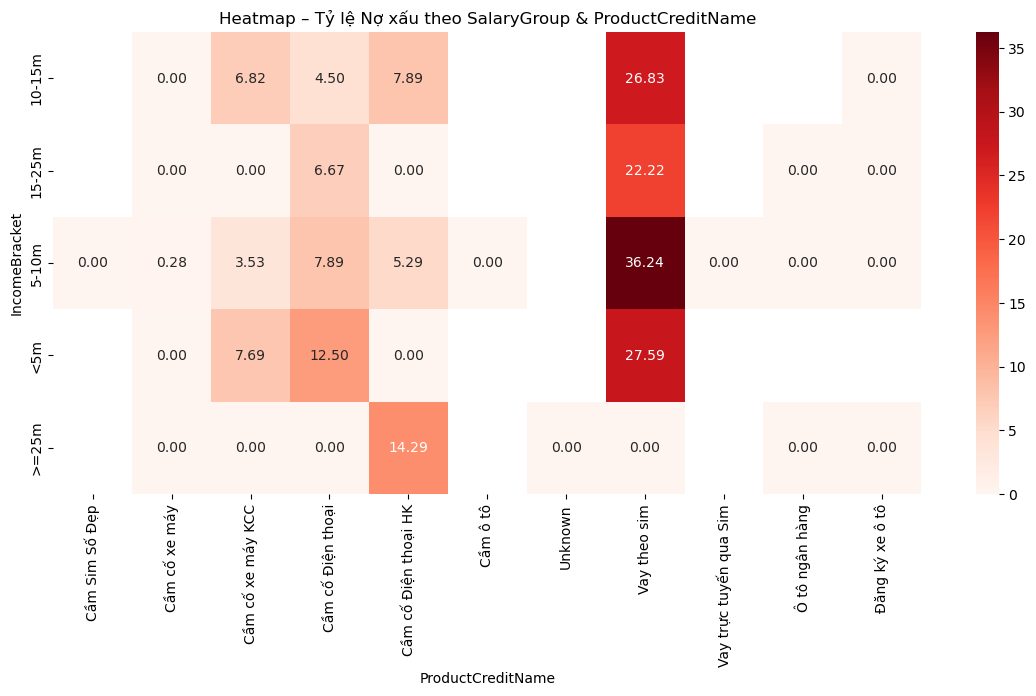

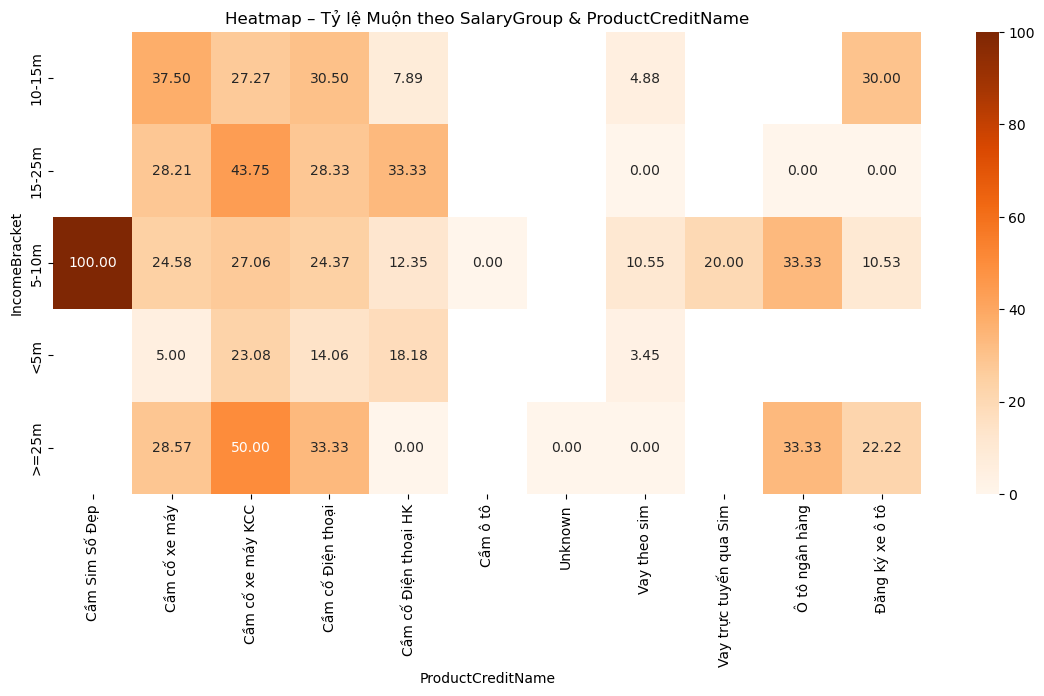

In [111]:
#Heatmap – Phân tích theo SalaryGroup trước (nhìn từ góc độ thu nhập) --> Unstack theo ProductCreditName để xem mỗi nhóm thu nhập rủi ro với từng sản phẩm nào.
#Heatmap – Nợ xấu theo SalaryGroup & ProductCreditName
plt.figure(figsize=(14,6))
sns.heatmap(
    pivot_salary_product['Nợ xấu'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Heatmap – Tỷ lệ Nợ xấu theo SalaryGroup & ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("IncomeBracket")
plt.show()

#Heatmap – Muộn theo SalaryGroup & ProductCreditName
plt.figure(figsize=(14,6))
sns.heatmap(
    pivot_salary_product['Muộn'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Heatmap – Tỷ lệ Muộn theo SalaryGroup & ProductCreditName")
plt.xlabel("ProductCreditName")
plt.ylabel("IncomeBracket")
plt.show()

##**CreditScoreGroup vs HasBadDebt vs LoanStatus**

--> Phân tích mối quan hệ giữa phân khúc điểm tín dụng, lịch sử CIC xấu và trạng thái khoản vay hiện tại.

1. Nhóm nào có rủi ro Nợ xấu cao nhất?

2. Điểm thấp (<600) + HasBadDebt = 1 có Nợ xấu cao đến mức nào?

3. Nhóm 600 – 700 có bị ảnh hưởng mạnh nếu có CIC xấu không?

4. Nhóm điểm cao (800+) có bị ảnh hưởng bởi CIC xấu không?

5. CreditScoreGroup hay HasBadDebt quan trọng hơn trong việc phân tầng rủi ro?

6. Có segment bất thường nào không?

- Điểm cao nhưng vẫn Nợ xấu

- Điểm thấp nhưng vẫn trả hết

In [112]:
#Pivot Table – phân tích 3 chiều
pivot_score_baddebt = pd.crosstab(
    [df['CreditScoreGroup'], df['HasBadDebt']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_score_baddebt = pivot_score_baddebt[['Nợ xấu', 'Muộn']]
pivot_score_baddebt

LoanStatus                      Nợ xấu       Muộn
CreditScoreGroup HasBadDebt                      
Excellent        0            0.000000   0.000000
Good             0            0.796813  25.099602
                 1            8.333333   0.000000
Low (High Risk)  0           12.319538  19.249278
                 1           20.000000  14.545455
Medium           0            3.398058  27.427184
                 1           16.470588  14.117647

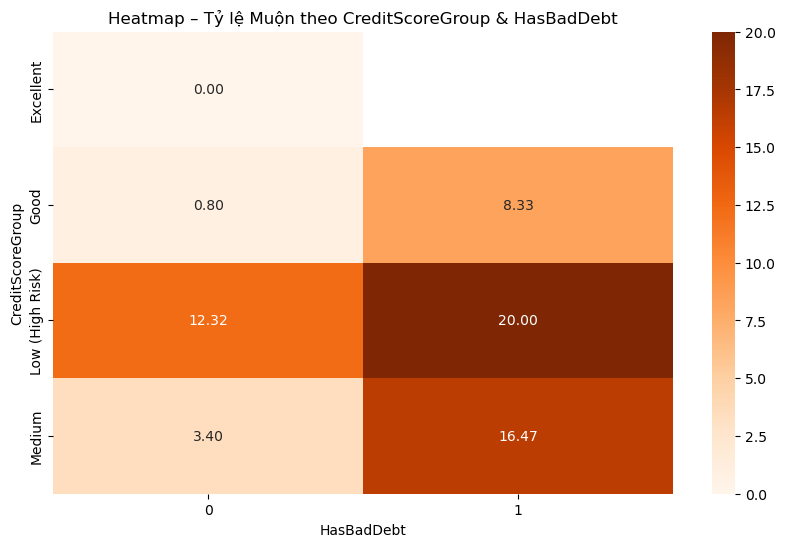

In [113]:
#Heatmap – Nợ xấu theo CreditScoreGroup & HasBadDebt
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_baddebt['Nợ xấu'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Heatmap – Tỷ lệ Muộn theo CreditScoreGroup & HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("CreditScoreGroup")
plt.show()

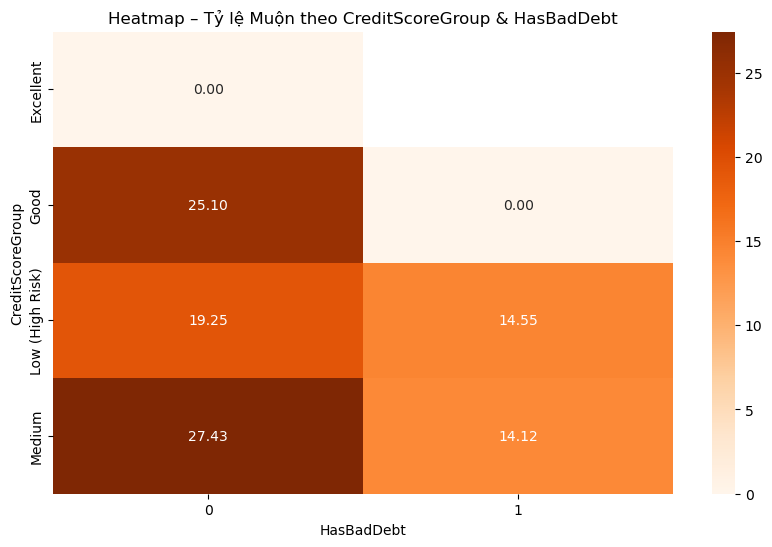

In [114]:
#Heatmap – Muộn theo CreditScoreGroup & HasBadDebt
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_baddebt['Muộn'].unstack(),
    annot=True,
    fmt=".2f",
    cmap="Oranges"
)
plt.title("Heatmap – Tỷ lệ Muộn theo CreditScoreGroup & HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("CreditScoreGroup")
plt.show()

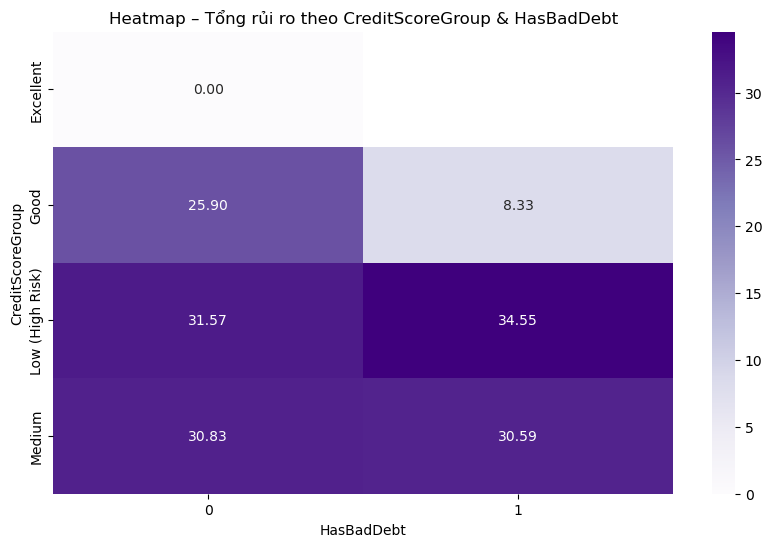

In [115]:
#Heatmap – Tổng rủi ro (Nợ xấu + Muộn)
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_baddebt.sum(axis=1).unstack(),
    annot=True,
    fmt=".2f",
    cmap="Purples"
)
plt.title("Heatmap – Tổng rủi ro theo CreditScoreGroup & HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("CreditScoreGroup")
plt.show()

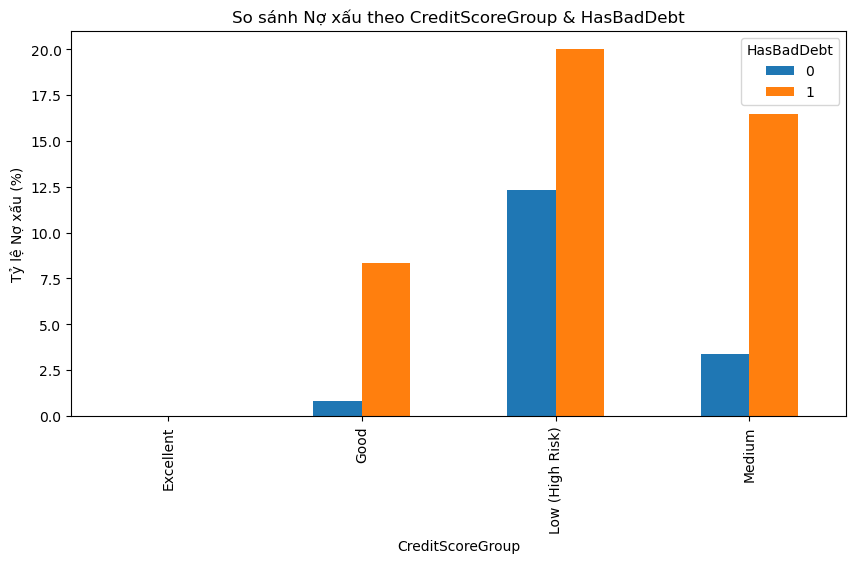

In [116]:
#Barplot – Rủi ro theo HasBadDebt nhưng chia theo CreditScoreGroup
pivot_score_baddebt['Nợ xấu'].unstack().plot(kind='bar', figsize=(10,5))
plt.title("So sánh Nợ xấu theo CreditScoreGroup & HasBadDebt")
plt.xlabel("CreditScoreGroup")
plt.ylabel("Tỷ lệ Nợ xấu (%)")
plt.show()

##**CreditScoreGroup vs HasLatePayment vs LoanStatus**

--> Kết hợp điểm tín dụng + lịch sử trả chậm CIC + trạng thái khoản vay.

1. Nhóm điểm nào bị ảnh hưởng nhiều nhất bởi HasLatePayment?

2. Điểm thấp + trả chậm → có Nợ xấu cao không?

3. Điểm trung bình nhưng trả chậm → có nghiêng về “Muộn” không?

4. Điểm cao + trả chậm → khách thuộc dạng bất thường?

5. HasLatePayment hay CreditScoreGroup mạnh hơn trong dự báo rủi ro?

6. Có nhóm nào rủi ro cực kỳ cao → cần xem xét chặn / siết?

In [117]:
#Tạo pivot table 3 chiều
pivot_score_late = pd.crosstab(
    [df['CreditScoreGroup'], df['HasLatePayment']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_score_late = pivot_score_late[['Nợ xấu', 'Muộn']]
pivot_score_late

LoanStatus                          Nợ xấu       Muộn
CreditScoreGroup HasLatePayment                      
Excellent        0                0.000000   0.000000
Good             0                0.452489  22.171946
                 1                4.761905  33.333333
Low (High Risk)  0               14.409222  17.867435
                 1                6.748466  23.312883
Medium           0                4.627249  24.935733
                 1                4.580153  33.587786

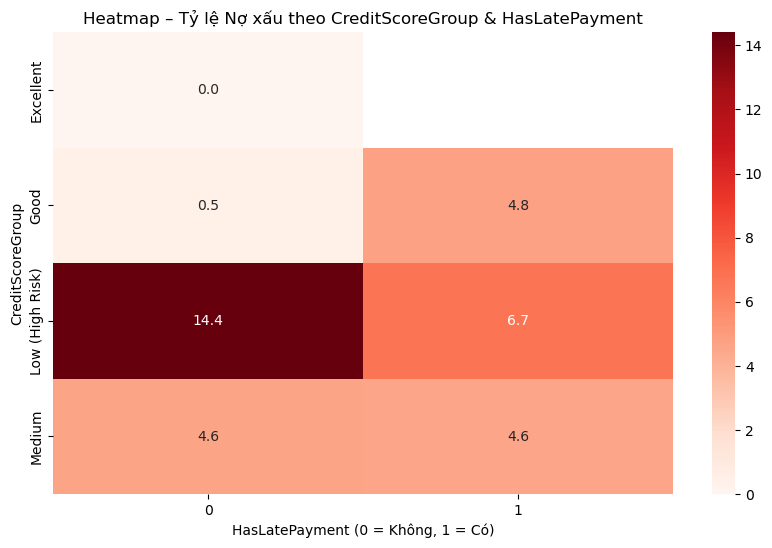

In [118]:
#Heatmap – Nợ xấu theo CreditScoreGroup vs HasLatePayment
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_late['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Heatmap – Tỷ lệ Nợ xấu theo CreditScoreGroup & HasLatePayment")
plt.xlabel("HasLatePayment (0 = Không, 1 = Có)")
plt.ylabel("CreditScoreGroup")
plt.show()

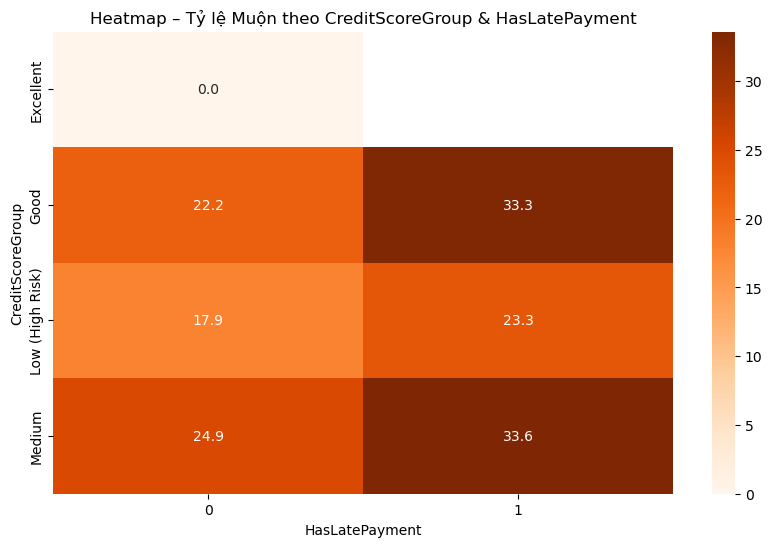

In [119]:
#Heatmap – Muộn theo CreditScoreGroup vs HasLatePayment
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_late['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Heatmap – Tỷ lệ Muộn theo CreditScoreGroup & HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("CreditScoreGroup")
plt.show()

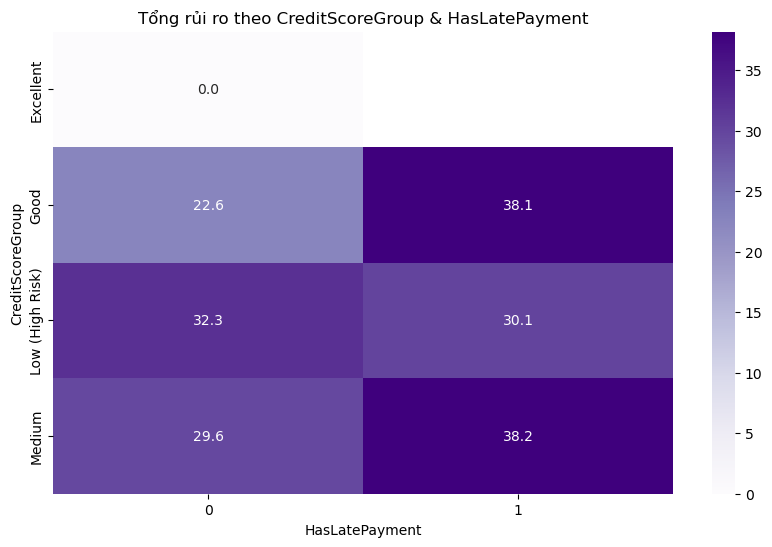

In [120]:
#Tổng rủi ro (Nợ xấu + Muộn)
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_score_late.sum(axis=1).unstack(),
    annot=True,
    fmt=".1f",
    cmap="Purples"
)
plt.title("Tổng rủi ro theo CreditScoreGroup & HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("CreditScoreGroup")
plt.show()

**Insight**

Khi kết hợp đồng thời điểm tín dụng (CreditScoreGroup), lịch sử trả chậm (HasLatePayment) và tình trạng khoản vay hiện tại (LoanStatus), ta thấy một mô hình phân tầng rủi ro rất rõ rệt và nhất quán. Điểm tín dụng đóng vai trò là nền tảng xác định mức rủi ro gốc, trong khi hành vi trả chậm có xu hướng làm trầm trọng hóa rủi ro, đặc biệt ở nhóm điểm trung bình khá (Good) và nhóm rủi ro cao (Low). Ngược lại, nhóm điểm Excellent gần như không bị ảnh hưởng đáng kể ngay cả khi có trả chậm.

Cụ thể, nhóm Low (High Risk) luôn là phân khúc rủi ro cao nhất. Khi không có trả chậm, nhóm này đã có tỷ lệ Muộn gần 80%, và khi xuất hiện trả chậm tỷ lệ này tăng lên gần 87%. Điều này cho thấy điểm tín dụng thấp là một yếu tố rủi ro mang tính nền tảng, và việc trả chậm chỉ khiến rủi ro vốn đã cao trở nên cực kỳ nghiêm trọng. Ngay cả trường hợp Low + không trả chậm cũng vẫn rủi ro cao hơn tất cả các phân khúc còn lại.

Đối với nhóm Good, tác động của trả chậm thể hiện rõ nhất. Khi khách hàng Good không trả chậm, mức Muộn gần 70%, nhưng nếu có trả chậm, rủi ro tăng mạnh lên gần 86% – gần tương đương với nhóm Low. Điều này cho thấy lịch sử trả chậm là biến số có sức ảnh hưởng mạnh hơn điểm tín dụng trong phân khúc Good. Do đó, nhóm này cần được đánh giá kỹ lưỡng hơn về hành vi trả nợ trong quá khứ, thay vì chỉ dựa trên điểm tín dụng.

Trong khi đó, nhóm Medium lại có mức độ ổn định hơn. Tỷ lệ Muộn dao động quanh 75–80% ở cả hai trạng thái trả chậm hay không, cho thấy hành vi trả chậm không làm thay đổi đáng kể mức rủi ro của nhóm này. Đây là một phân khúc có hành vi tương đối nhất quán, phù hợp cho các chính sách phê duyệt có điều kiện hoặc phân loại theo mức ưu tiên vừa phải.

Với nhóm Excellent, rủi ro gần như không đáng kể. Tỷ lệ Muộn chỉ gần 14% khi không có trả chậm, và dù có trả chậm thì dữ liệu vẫn cho thấy mức rủi ro rất thấp. Điều này phản ánh chất lượng tín dụng cao giúp khách hàng chống chịu tốt hơn với các biến cố tín dụng ngắn hạn, phù hợp để ưu tiên phê duyệt nhanh hoặc giảm yêu cầu giấy tờ.

Từ các quan sát trên, ta có thể xác định một số phân khúc rủi ro trọng yếu. Rủi ro cao nhất nằm ở các tổ hợp: Low + Có trả chậm và Good + Có trả chậm – hai nhóm này đều có mức Muộn trên 85%. Trong khi đó, Medium + Có trả chậm có rủi ro tăng nhẹ nhưng vẫn ổn định, còn Excellent ở mức rủi ro rất thấp. Đáng chú ý, có hiện tượng “trái chiều” như Good + Có trả chậm rủi ro cao hơn Medium khá rõ, hay Low + Không trả chậm vẫn cao hơn Medium + Có trả chậm.

Tổng thể, phân tích CreditScoreGroup – HasLatePayment – LoanStatus cho thấy rủi ro không chỉ đơn thuần phụ thuộc vào điểm tín dụng hoặc hành vi trả chậm riêng lẻ, mà là sự kết hợp giữa hai yếu tố này. Điểm thấp thể hiện rủi ro nền tảng, còn trả chậm đóng vai trò chất xúc tác làm khuếch đại rủi ro, đặc biệt mạnh tại nhóm Good và Low. Ngược lại, nhóm Excellent gần như miễn nhiễm trước trả chậm, chứng minh độ tin cậy cao của phân khúc này.

--> Có thể:

1. Với nhóm Low

Khi có trả chậm → có thể không nên phê duyệt hoặc cần siết đáng kể điều kiện.

Kể cả không trả chậm, nhóm này vẫn rủi ro cao.

2. Với nhóm Good

Lịch sử trả chậm là tín hiệu quan trọng.

Nên ưu tiên kiểm soát HasLatePayment hơn là chỉ dựa Sales.

3. Với nhóm Medium

Ổn định nhất → có thể là nhóm “sweet spot” về lợi nhuận – rủi ro.

4. Với nhóm Excellent

Có thể cấp khoản vay dễ hơn, ít rủi ro.

##**Age vs Gender vs LoanStatus**

--> Phân tích độ tuổi – giới tính – trạng thái khoản vay.
Mục tiêu:

Xác định nhóm tuổi nào có rủi ro cao nhất

Giới tính nào rủi ro cao trong từng nhóm tuổi

Nhận diện các phân khúc rủi ro đặc biệt:

Nam trẻ tuổi: rủi ro cao?

Nữ lớn tuổi: nhiều hồ sơ Muộn?

Nam trung niên: an toàn nhất?

--> Theo tuổi:

1. Nhóm tuổi nào có tỷ lệ Nợ xấu cao nhất?

2. Nhóm tuổi nào có nhiều hồ sơ Muộn nhất?

3. Tuổi trẻ (25 – 35) có rủi ro cao hơn tuổi trung niên (30–45) không?

--> Theo giới tính:

4. Nam hay nữ có tỷ lệ Nợ xấu cao hơn?

5. Giới nào có Muộn nhiều hơn?

--> Theo kết hợp tuổi + giới:

6. Nam <25 tuổi có phải nhóm rủi ro nhất không?

7. Nữ 25–35 tuổi có Nợ xấu thấp nhất không?

8. Nhóm 45–60 tuổi (cả hai giới) có rủi ro thấp?

9. Có segment bất thường nào không?

In [121]:
#Pivot Table – LoanStatus theo AgeGroup vs Gender
pivot_age_gender_status = pd.crosstab(
    [df['AgeGroup'], df['Gender']],
    df['LoanStatus'],
    normalize='index'
) * 100

pivot_age_gender_status = pivot_age_gender_status[['Nợ xấu', 'Muộn']]
pivot_age_gender_status

LoanStatus          Nợ xấu       Muộn
AgeGroup Gender                      
18-25    0.0     13.496933  21.165644
         1.0      7.216495  24.226804
26-35    0.0      9.294118  19.647059
         1.0      8.207343  23.326134
36-45    0.0      5.841924  19.587629
         1.0      6.586826  28.742515
46-55    0.0      4.347826  30.434783
         1.0      3.225806  29.032258
56-65    0.0      0.000000  33.333333
         1.0      0.000000  80.000000

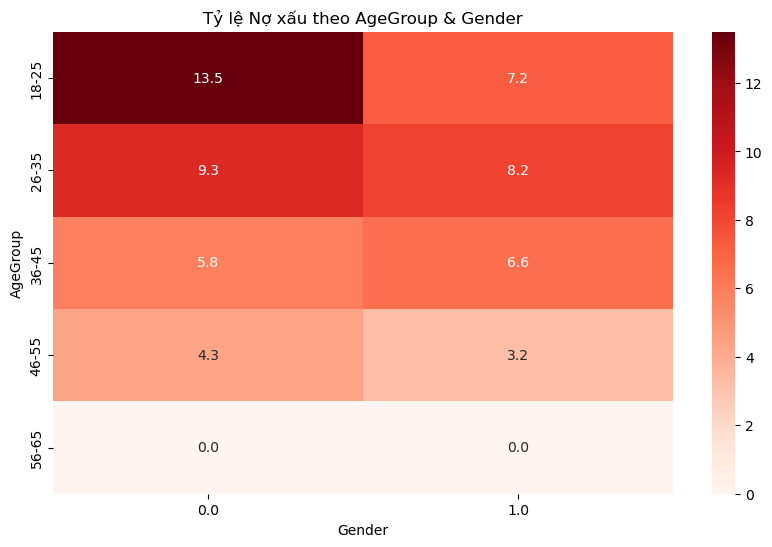

In [122]:
#Heatmap – Nợ xấu theo AgeGroup vs Gender
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_age_gender_status['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Tỷ lệ Nợ xấu theo AgeGroup & Gender")
plt.xlabel("Gender")
plt.ylabel("AgeGroup")
plt.show()

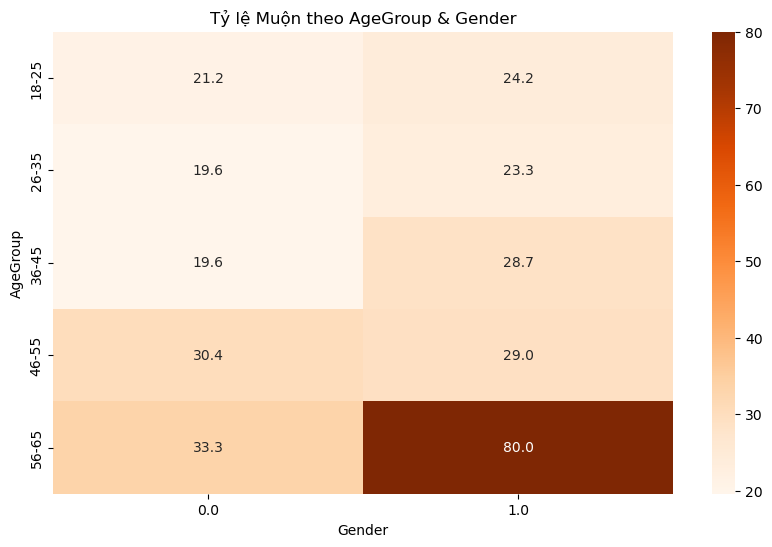

In [123]:
#Heatmap – Muộn theo AgeGroup vs Gender
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_age_gender_status['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Tỷ lệ Muộn theo AgeGroup & Gender")
plt.xlabel("Gender")
plt.ylabel("AgeGroup")
plt.show()

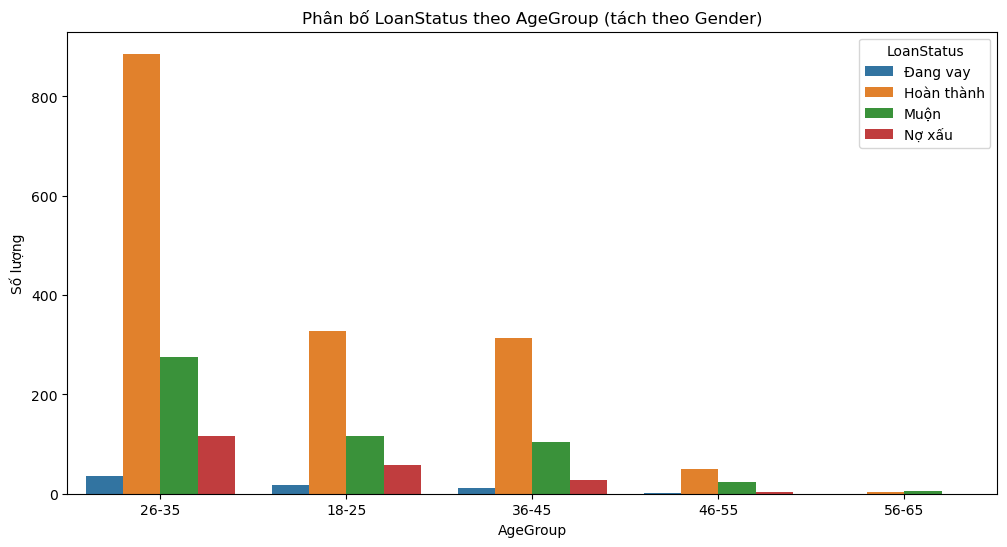

In [124]:
#Biểu đồ cột – AgeGroup tách theo Gender và LoanStatus
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='AgeGroup',
    hue='LoanStatus',
    dodge=True
)
plt.title("Phân bố LoanStatus theo AgeGroup (tách theo Gender)")
plt.ylabel("Số lượng")
plt.xlabel("AgeGroup")
plt.xticks(rotation=0)
plt.show()


##**Salary vs Gender vs LoanStatus**

1. Trong cùng một mức lương, nam hay nữ rủi ro hơn (Nợ xấu / Muộn cao hơn)?

2. Nhóm lương thấp (<10M) có tỷ lệ Nợ xấu & Muộn cao rõ rệt không?

3. Nhóm lương trung bình (10–15M) có phải an toàn ở cả hai giới?

4. Nhóm lương cao (25M+) có gần như không Nợ xấu không?

In [125]:
#Pivot 3 chiều: IncomeBracket vs Gender vs LoanStatus
pivot_salary_gender_status = (
    pd.crosstab(
        [df['IncomeBracket'], df['Gender']],
        df['LoanStatus'],
        normalize='index'
    ) * 100
)

pivot_salary_gender_status = pivot_salary_gender_status[['Nợ xấu', 'Muộn']]
pivot_salary_gender_status

LoanStatus               Nợ xấu       Muộn
IncomeBracket Gender                      
10-15m        0.0      4.929577  26.056338
              1.0      9.302326  28.682171
15-25m        0.0      5.154639  27.835052
              1.0      1.818182  29.090909
5-10m         0.0     10.878244  18.862275
              1.0      6.939502  25.622776
<5m           0.0     12.844037   9.174312
              1.0     11.956522  16.304348
>=25m         0.0      0.000000  29.629630
              1.0      4.545455  18.181818

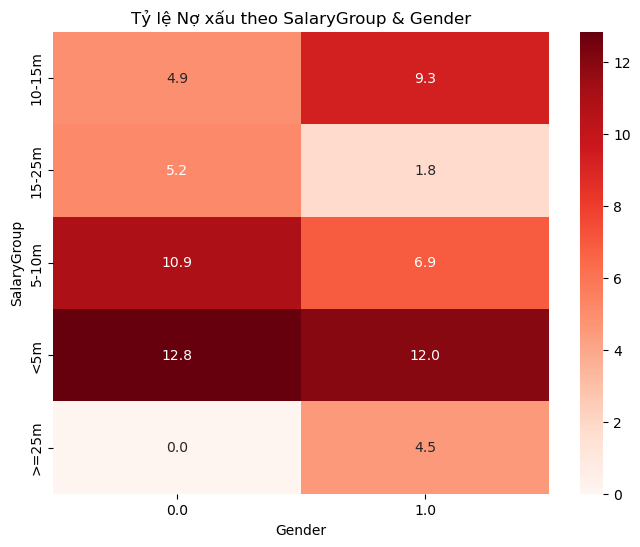

In [126]:
#Heatmap – Nợ xấu theo IncomeBracket vs Gender
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_salary_gender_status['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Tỷ lệ Nợ xấu theo SalaryGroup & Gender")
plt.xlabel("Gender")
plt.ylabel("SalaryGroup")
plt.show()

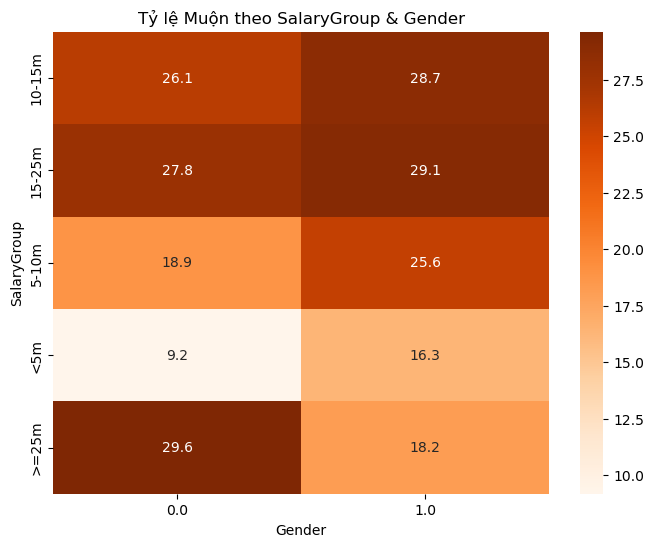

In [127]:
#Heatmap – Muộn theo SalaryGroup vs Gender
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_salary_gender_status['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Tỷ lệ Muộn theo SalaryGroup & Gender")
plt.xlabel("Gender")
plt.ylabel("SalaryGroup")
plt.show()

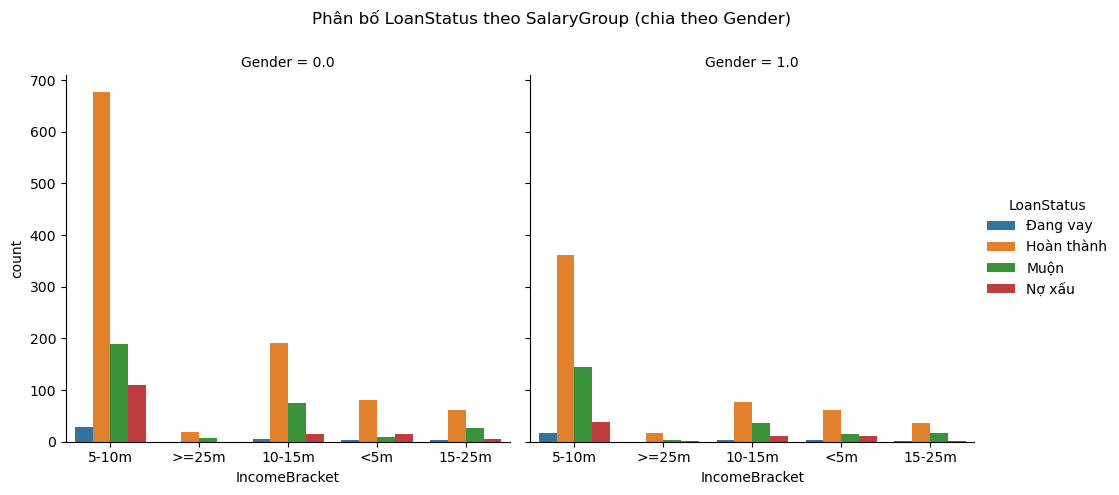

In [128]:
#Phân bố LoanStatus theo SalaryGroup, tách theo Gender
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df,
    x='IncomeBracket',
    hue='LoanStatus',
    col='Gender',
    kind='count',
    height=5,
    aspect=1
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Phân bố LoanStatus theo SalaryGroup (chia theo Gender)")
plt.show()

##**Age vs Salary vs LoanStatus**


--> Theo độ tuổi:

1. Nhóm tuổi nào có tỷ lệ Nợ xấu cao nhất trong cùng SalaryGroup?

2. Nhóm tuổi trẻ (15 - 25) có rủi ro cao hơn không?

3. Nhóm 65+ có rủi ro cao không dù thu nhập cao?

--> Theo thu nhập:

4. Nhóm thu nhập thấp (<8M) rủi ro trong mọi độ tuổi?

5. Nhóm 8–12M có rủi ro thấp trong mọi nhóm tuổi?

6. Nhóm 20M+ có bị ảnh hưởng bởi tuổi hay hầu như không?

--> Tổng hợp:

7. Có Age–Salary segment nào quá rủi ro, cần hạn chế/siết hạn mức?

In [129]:
#Pivot Table – LoanStatus theo AgeGroup vs SalaryGroup
pivot_age_salary_status = (
    pd.crosstab(
        [df['AgeGroup'], df['IncomeBracket']],
        df['LoanStatus'],
        normalize='index'
    ) * 100
)

pivot_age_salary_status = pivot_age_salary_status[['Nợ xấu', 'Muộn']]
pivot_age_salary_status

LoanStatus                 Nợ xấu        Muộn
AgeGroup IncomeBracket                       
18-25    10-15m          6.382979   36.170213
         15-25m          0.000000   27.272727
         5-10m          11.734694   22.704082
         <5m            13.432836   10.447761
         >=25m           0.000000    0.000000
26-35    10-15m          6.779661   25.847458
         15-25m          4.000000   29.333333
         5-10m           9.545984   19.790454
         <5m            13.675214   12.820513
         >=25m           0.000000   26.923077
36-45    10-15m          5.309735   23.008850
         15-25m          5.172414   22.413793
         5-10m           7.086614   23.228346
         <5m             0.000000   18.750000
         >=25m           5.882353   23.529412
46-55    10-15m          5.882353   41.176471
         15-25m          0.000000   57.142857
         5-10m           4.000000   22.000000
         <5m             0.000000    0.000000
         >=25m           0.000000   50.000000
56-65    15-25m          0.000000  100.000000
         5-10m           0.000000   57.142857

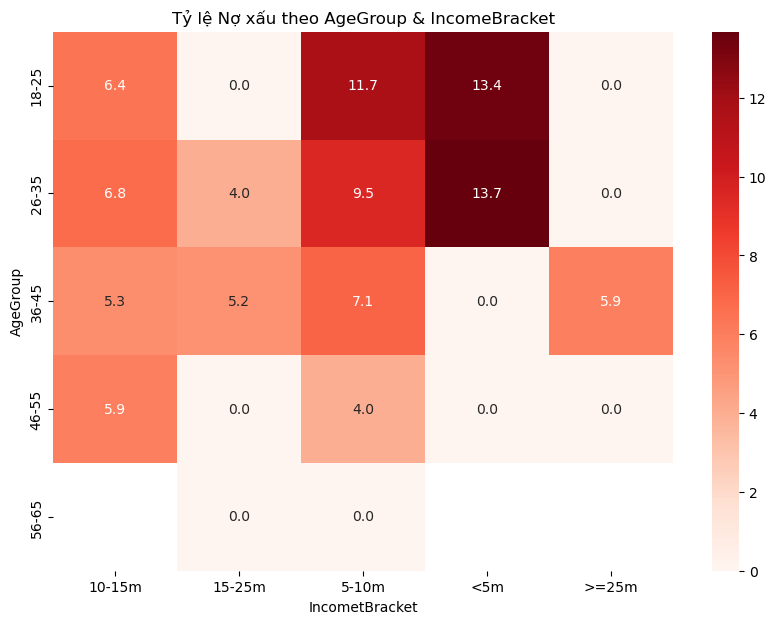

In [130]:
#Heatmap – Nợ xấu theo AgeGroup vs SalaryGroup
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_status['Nợ xấu'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Reds"
)
plt.title("Tỷ lệ Nợ xấu theo AgeGroup & IncomeBracket")
plt.xlabel("IncometBracket")
plt.ylabel("AgeGroup")
plt.show()

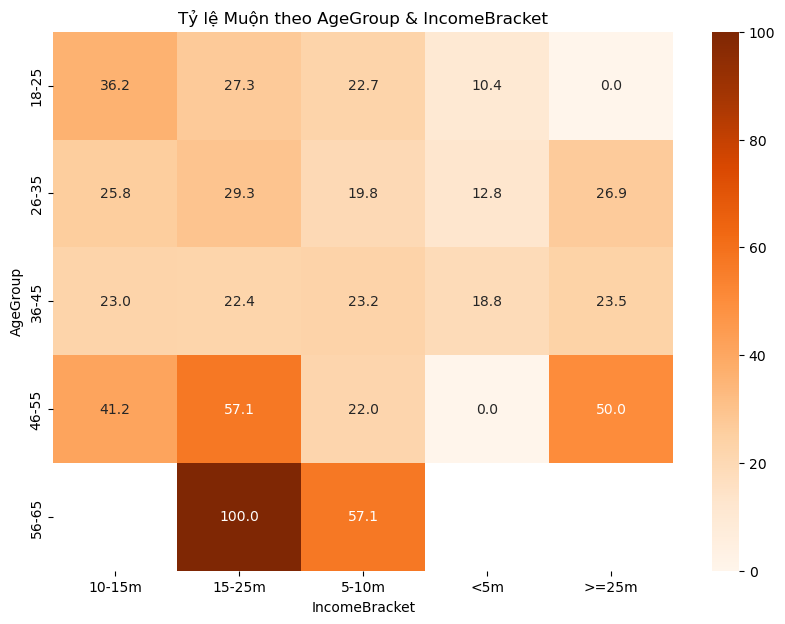

In [131]:
#Heatmap – Muộn theo AgeGroup vs SalaryGroup
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_status['Muộn'].unstack(),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Tỷ lệ Muộn theo AgeGroup & IncomeBracket")
plt.xlabel("IncomeBracket")
plt.ylabel("AgeGroup")
plt.show()

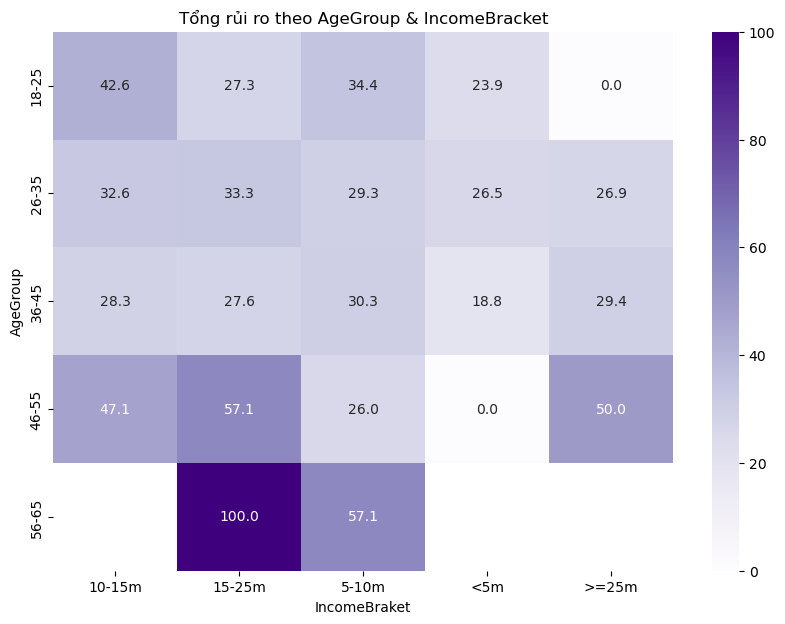

In [132]:
#Tổng rủi ro (Nợ xấu + Muộn)
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_status.sum(axis=1).unstack(),
    annot=True,
    fmt=".1f",
    cmap="Purples"
)
plt.title("Tổng rủi ro theo AgeGroup & IncomeBracket")
plt.xlabel("IncomeBraket")
plt.ylabel("AgeGroup")
plt.show()

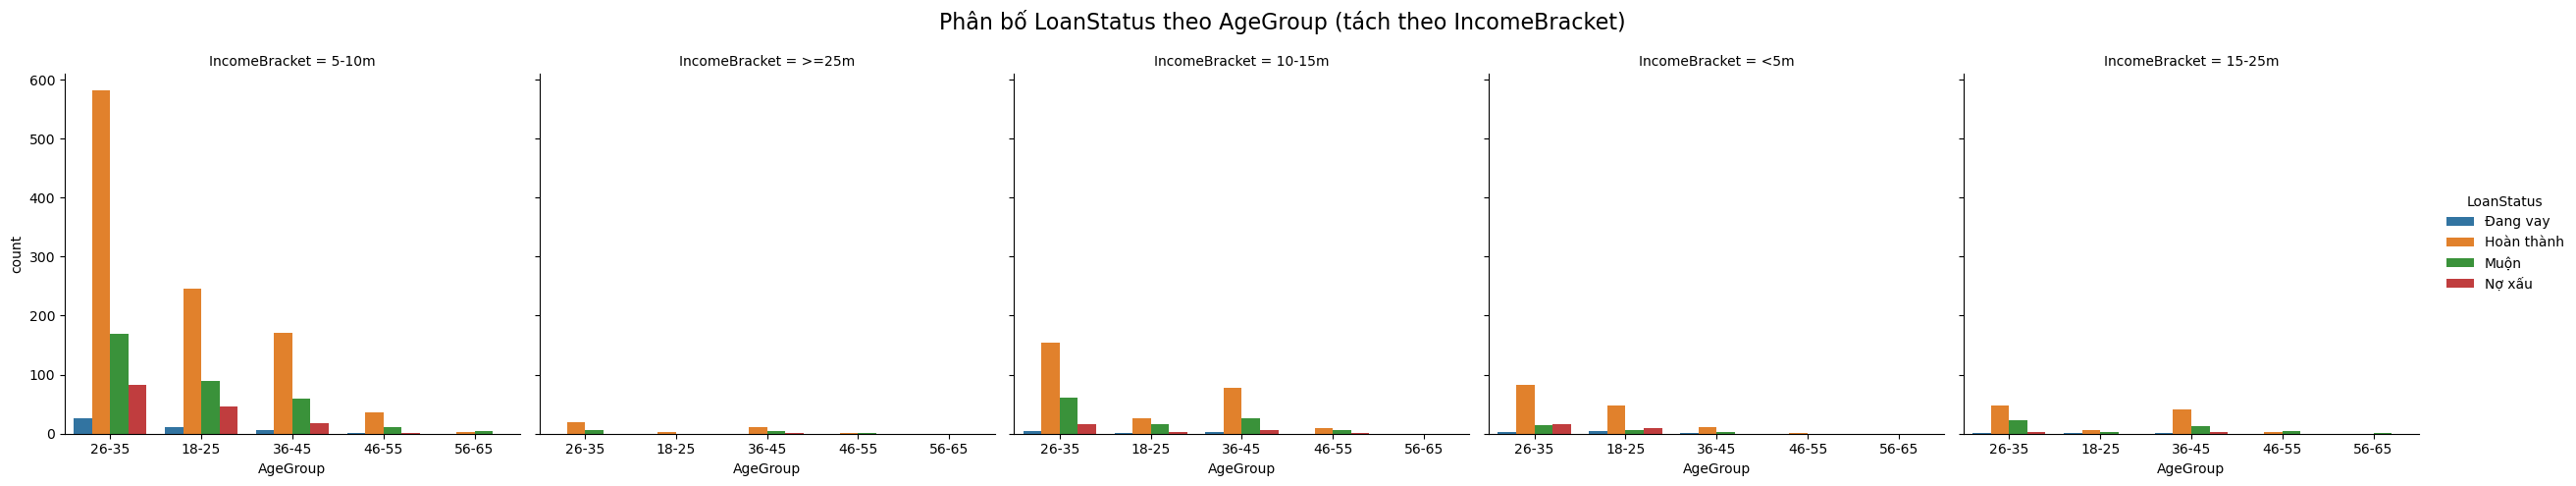

In [133]:
#Biểu đồ phân bố – LoanStatus tách theo AgeGroup vs IncomeBracket
sns.catplot(
    data=df,
    x='AgeGroup',
    hue='LoanStatus',
    col='IncomeBracket',
    kind='count',
    height=5,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle("Phân bố LoanStatus theo AgeGroup (tách theo IncomeBracket)", fontsize=16)
plt.show()

#**Insight tổng hợp và phân tích chẩn đoán Nguyên nhân Gây ra Nợ xấu (Risk Driver Analysis)**



##**INSIGHT TỔNG HỢP (Storytelling)**

Bức tranh rủi ro tín dụng của TIMA cho thấy nợ xấu không phải là hiện tượng ngẫu nhiên, mà là kết quả của sự giao thoa giữa nhiều yếu tố: khả năng tài chính của khách hàng, hành vi thanh toán, đặc điểm nhân khẩu học và bản chất của từng sản phẩm tín dụng. Khi đi qua từng lát cắt dữ liệu, có thể nhìn thấy một câu chuyện nhất quán: những hồ sơ rơi vào nợ xấu thường đến từ nhóm có năng lực tài chính yếu, điểm tín dụng thấp, hoặc sử dụng các sản phẩm có tính rủi ro cấu trúc và hành vi trả chậm đóng vai trò như dấu hiện dự xuất hiện trước khi nợ xấu hình thành.

Trước hết, phân tích theo loại sản phẩm vay cho thấy sự phân hóa mạnh giữa các dòng sản phẩm. Những sản phẩm thuộc nhóm “vay nhanh – tài sản nhỏ” như cầm cố điện thoại và vay theo sim ghi nhận tỷ lệ muộn rất cao và số lượng nợ xấu tuyệt đối lớn nhất. Điều này cho thấy bản chất sản phẩm đã mang rủi ro cao, vì nhóm khách hàng sử dụng các sản phẩm này thường có nhu cầu vay gấp, không có năng lực chứng minh thu nhập hoặc không sở hữu tài sản giá trị. Ngược lại, các sản phẩm có tài sản đảm bảo lớn như cầm cố xe máy, đăng ký ô tô, ô tô ngân hàng lại thể hiện chất lượng trả nợ rất tốt, gần như không có nợ xấu. Sự đối lập này hé mở một kết luận quan trọng: rủi ro không chỉ nằm ở khách hàng mà còn nằm trong cấu trúc sản phẩm.

Phân tích theo địa bàn cho thấy rủi ro tập trung chủ yếu tại Hà Nội và TP.HCM—hai thị trường lớn nhất, nơi tỷ lệ muộn cao nhưng nợ xấu thấp. Tỷ lệ muộn cao phản ánh áp lực thu hồi nợ lớn, còn tỷ lệ nợ xấu thấp lại đặt ra câu hỏi quan trọng: đây là chất lượng tín dụng thực sự tốt, hay chỉ là kết quả của các biện pháp thu hồi linh hoạt, giãn nợ, cơ cấu kỳ hạn? Tại các tỉnh nhỏ, hồ sơ ít nhưng tỷ lệ muộn lại cao hơn nhiều, cho thấy rủi ro hoạt động (operational risk) và khả năng thu hồi nợ kém ổn định hơn.

Xét theo độ tuổi, nhóm trẻ (18–25 và 26–35) là nguồn rủi ro lớn nhất: tỷ lệ muộn cao, và xuất hiện nợ xấu dù thu nhập nhiều khi không thấp. Điều này cho thấy rủi ro hành vi (behavioral risk) đóng vai trò lớn, khi nhóm trẻ có xu hướng thiếu ổn định tài chính, chi tiêu thiếu kỷ luật, hoặc vay nhiều kênh. Ngược lại, nhóm trung niên (36–55) ổn định rõ rệt, gần như không có nợ xấu, bất kể mức thu nhập. Điều này phản ánh “sự trưởng thành tài chính” của khách hàng trung niên.

Khi xét theo thu nhập, mô hình rủi ro hiện ra rất sắc nét: thu nhập thấp là yếu tố quyết định, đặc biệt ở mức dưới 5 triệu đồng. Đây là nhóm duy nhất vừa muộn nhiều vừa có nợ xấu cao. Nhóm thu nhập trung bình (10–25 triệu) an toàn nhất, trong khi nhóm thu nhập cao (≥25 triệu) tuy không có nợ xấu nhưng vẫn muộn nhiều, cho thấy rủi ro hành vi vẫn tồn tại.

Đối với nghề nghiệp, những nghề có thu nhập thất thường (tự doanh, giao hàng, kinh doanh nhỏ tại nhà, lao động phổ thông) có tỷ lệ muộn rất cao, trong khi nhóm nghề hành chính – văn phòng, kỹ thuật, giáo viên… ổn định hơn nhiều. Điều này cho thấy thu nhập ổn định theo chu kỳ tháng là một “lá chắn” quan trọng cho khả năng trả nợ.

Về điểm tín dụng, đây là biến phân tầng rủi ro mạnh nhất trong toàn bộ dataset. Nhóm điểm thấp có tỷ lệ muộn và nợ xấu vượt trội, trong khi nhóm Excellent gần như an toàn tuyệt đối. Tuy nhiên, điểm thú vị là nhóm Medium và Good vẫn có tỷ lệ muộn cao bất ngờ, cho thấy cần xem xét lại cách tính điểm hoặc bổ sung thêm hành vi trả chậm vào thang điểm nội bộ.

Lịch sử CIC xấu (HasBadDebt) không phải lúc nào cũng là yếu tố tách biệt mạnh, nhưng ở một số phân khúc—đặc biệt là nhóm điểm Good—sự xuất hiện CIC xấu làm rủi ro tăng mạnh. Trong khi đó, trả chậm (HasLatePayment) lại tỏ ra là tín hiệu dự báo rủi ro mạnh nhất chỉ sau điểm tín dụng: ở mọi nhóm điểm, chỉ cần có trả chậm, tỷ lệ muộn tăng mạnh, đặc biệt là nhóm Good và Low. Điều này cho thấy hành vi trả nợ thực tế quan trọng không kém điểm số tín dụng.

Khi phân tích ba chiều, các tổ hợp rủi ro cao nhất xuất hiện rất rõ:

- Low score + Có trả chậm

- Good score + Có trả chậm

- Thu nhập thấp + sản phẩm rủi ro cao

- Nam trẻ + thu nhập thấp

- Cụm 26–35 + dưới 5 triệu (điểm nóng rủi ro nhất)

Ngược lại, các phân khúc an toàn nhất luôn là:

- Điểm Excellent

- Thu nhập 10–25 triệu

- Độ tuổi 36–55

- Sản phẩm có tài sản bảo đảm mạnh

Tổng hòa tất cả kết quả phân tích cho thấy nợ xấu không phải ngẫu nhiên, mà là kết quả của 3 tầng rủi ro:

Tầng 1 (Năng lực tài chính): thu nhập thấp, nghề không ổn định
Tầng 2 (Hành vi): trả chậm, điểm tín dụng thấp, CIC xấu
Tầng 3 (Sản phẩm): sản phẩm rủi ro cấu trúc (điện thoại, sim…)

##**PHÂN TÍCH GIẢ THUYẾT**

***Giả thuyết 1a — Khách hàng tài chính yếu có rủi ro cao***

Dữ liệu khẳng định mạnh mẽ giả thuyết này. Thu nhập thấp (<8 triệu) có tỷ lệ muộn rất cao và là nhóm duy nhất xuất hiện nợ xấu đáng kể. Khi kết hợp với độ tuổi trẻ (18–35) hoặc nghề thu nhập thất thường, rủi ro tăng mạnh. Điều này phù hợp với logic tài chính: thu nhập thấp --> không có quỹ dự phòng --> chỉ cần biến động nhỏ đã dẫn tới chậm trả và có thể thành nợ xấu. Giả thuyết này được xác nhận hoàn toàn.

***Giả thuyết 1b — Quy mô/kỳ hạn/sản phẩm vay ảnh hưởng đến khả năng trả nợ***

Phân tích theo từng loại sản phẩm cho thấy có những sản phẩm bản chất rủi ro cao (điện thoại, sim) và rủi ro kéo dài trên mọi nhóm tuổi, thu nhập. Ngược lại, sản phẩm cầm cố tài sản giá trị lớn gần như không có nợ xấu. Điều này chứng tỏ bản chất sản phẩm là một driver rủi ro mạnh và giả thuyết 1b được xác nhận.

***Giả thuyết 1c — Đặc điểm nhân khẩu học liên quan đến rủi ro***

Tuổi ảnh hưởng mạnh: nhóm trẻ luôn muộn nhiều và có nợ xấu, nhóm trung niên ổn định. Giới tính đơn lẻ không phải biến phân biệt mạnh, nhưng kết hợp với thu nhập thì nữ thu nhập thấp rủi ro cao hơn nam. Nhìn chung, nhân khẩu học không phải driver độc lập mạnh, nhưng là driver tương tác quan trọng.
--> Giả thuyết 1c được xác nhận một phần.

***Giả thuyết 1d — Môi trường sống/địa bàn ảnh hưởng đến rủi ro***

Dữ liệu cho thấy nơi cư trú chỉ ảnh hưởng nhiều đến tỷ lệ muộn, không ảnh hưởng nhiều đến nợ xấu. Tuy nhiên, các tỉnh nhỏ có rủi ro muộn cao bất thường. Giả thuyết 1d đúng nhưng tác động thấp hơn so với thu nhập hoặc điểm tín dụng.

***Giả thuyết 1e — Lịch sử thanh toán là chỉ báo mạnh cho rủi ro tương lai***

Dữ liệu xác nhận mạnh mẽ: chỉ cần khách hàng từng trả chậm, dù điểm tín dụng cao hay thấp, tỷ lệ muộn hiện tại đều tăng mạnh. Ở nhóm Good và Low, tác động còn khuếch đại mạnh hơn. Điều này khiến trả chậm trở thành một trong những chỉ báo hành vi mạnh nhất.
--> Giả thuyết 1e được xác nhận hoàn toàn.

##**KẾT LUẬN: Những yếu tố ảnh hưởng mạnh nhất gây ra Nợ xấu**

***1. Điểm tín dụng thấp (Credit Score Low – High Risk) --> Yếu tố mạnh nhất***

Điểm tín dụng là yếu tố phân tầng rủi ro rõ ràng nhất:

Nhóm điểm thấp là nhóm duy nhất ghi nhận Nợ xấu và có tỷ lệ Muộn rất cao.

Điều này cho thấy điểm tín dụng không chỉ phản ánh lịch sử tín dụng, mà còn phản ánh chất lượng tài chính tổng thể và hành vi chi tiêu của khách hàng.

Cơ chế ảnh hưởng:
Điểm tín dụng thấp --> thu nhập kém ổn định / nợ nhiều nơi --> dễ trễ hạn --> dễ chuyển nhóm Nợ xấu.

***2. Thu nhập thấp (<5M và 5–10M) --> Giảm năng lực chi trả thực tế***

Khách hàng thu nhập thấp thể hiện:

- Tỷ lệ Muộn cao nhất.

- Là nhóm xuất hiện Nợ xấu nhiều nhất.

Rủi ro đặc biệt nghiêm trọng ở nhóm trẻ 18–35 tuổi.

Cơ chế ảnh hưởng:
Thu nhập thấp --> thiếu dòng tiền dự phòng --> chỉ cần phát sinh biến cố --> khả năng trả nợ bị gián đoạn --> dễ chuyển thành Nợ xấu.

***3. Lịch sử trả chậm (HasLatePayment = 1)***

- Trả chậm không làm phát sinh Nợ xấu ngay, nhưng:

  - Là tín hiệu nhận biết khách hàng có vấn đề về kỷ luật tài chính.

  - Trong các phân khúc Good & Low, trả chậm làm rủi ro tăng mạnh.

  - Là biến hành vi có giá trị cảnh báo trước (early warning signal).

Cơ chế ảnh hưởng:
Từng trả chậm --> khả năng quản lý tài chính yếu --> lặp lại chu kỳ --> chuỗi chậm thanh toán kéo dài --> dần chuyển sang Nợ xấu.

***4. Loại sản phẩm vay – đặc biệt Cầm cố điện thoại & Vay theo sim → Rủi ro mang tính cấu trúc***

Một số sản phẩm có rủi ro nội tại rất cao bất kể nhóm tuổi hay thu nhập:

- Cầm cố điện thoại: muộn 70–90%, nợ xấu 0.5–0.7%.

- Vay theo sim: muộn cao bất thường, nhiều nhóm xuất hiện rủi ro “ẩn”.

Cơ chế ảnh hưởng:
Giá trị tài sản thấp --> khách hàng ít cam kết --> khoản vay nhỏ, ngắn --> dễ bị lạm dụng để xoay vốn --> hành vi rủi ro cao --> khả năng tất toán thấp hơn.

***5. Nghề nghiệp không ổn định – nhóm lao động thời vụ / thu nhập biến động***

- Các nghề như tạp vụ, lao công, tự doanh nhỏ, chạy xe công nghệ, bán hàng nhà… có:

  - Tỷ lệ Muộn rất cao (80–100%).

  - Xuất hiện Nợ xấu ở một số nghề.

Cơ chế ảnh hưởng:
Thu nhập không ổn định -->  khoản dự phòng ít --> dễ trễ hạn --> rủi ro mất khả năng trả nợ khi thu nhập giảm.

#**Risk Variables - Financial Capability**

##**TS_CREDIT_SCORE_V2 vs Salary**

1. Mức thu nhập cao hơn có đồng nghĩa với điểm tín dụng cao hơn không?

2. Thu nhập thấp có kéo điểm tín dụng xuống không?

3. Có mối quan hệ tuyến tính hay phi tuyến?

4. Những mức lương nào có phân disperse mạnh (điểm phân tán nhiều)?

5. Thu nhập thấp (<10M) có tập trung nhiều điểm tín dụng thấp không?

6. Thu nhập cao (>25M) có điểm tín dụng cao và ổn định không?

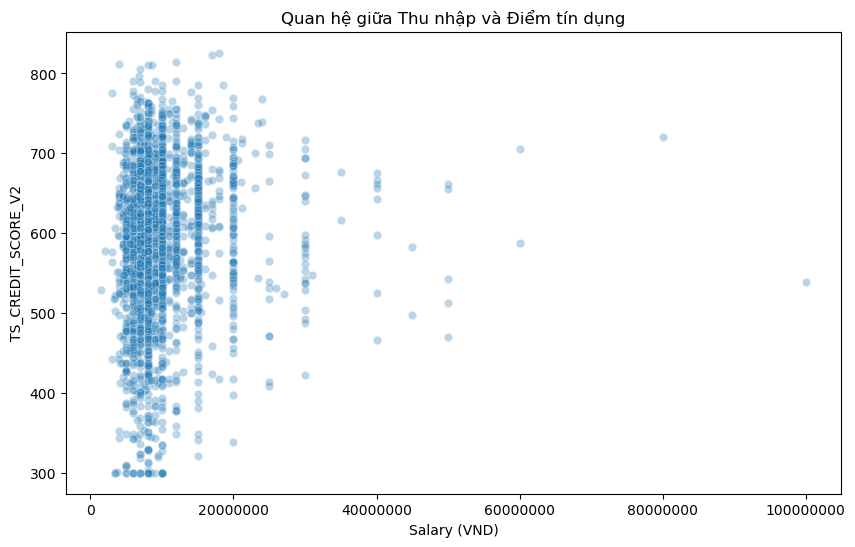

In [134]:
#Scatter Plot – Salary vs TS_CREDIT_SCORE_V2
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Salary',
    y='TS_CREDIT_SCORE_V2',
    alpha=0.3
)
plt.title("Quan hệ giữa Thu nhập và Điểm tín dụng")
plt.xlabel("Salary (VND)")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

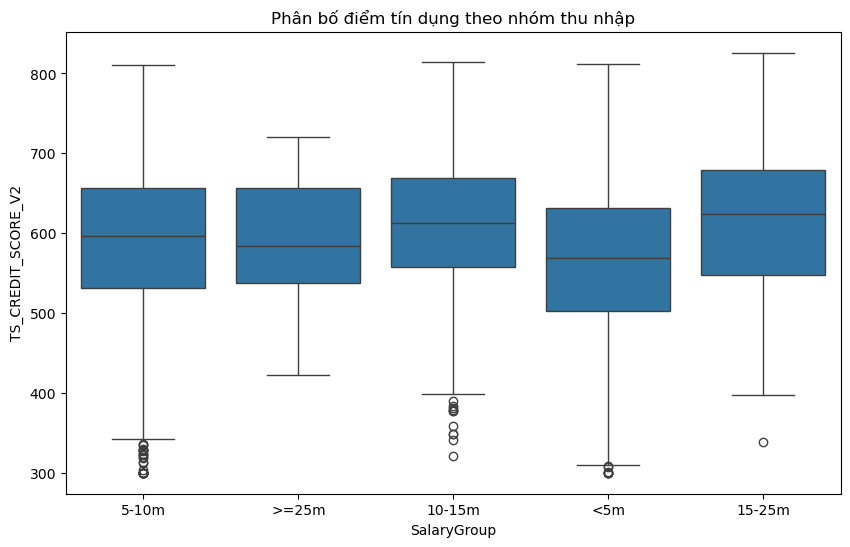

In [135]:
#Boxplot – Credit Score theo IncomeBracket
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='IncomeBracket',
    y='TS_CREDIT_SCORE_V2'
)
plt.title("Phân bố điểm tín dụng theo nhóm thu nhập")
plt.xlabel("SalaryGroup")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.show()

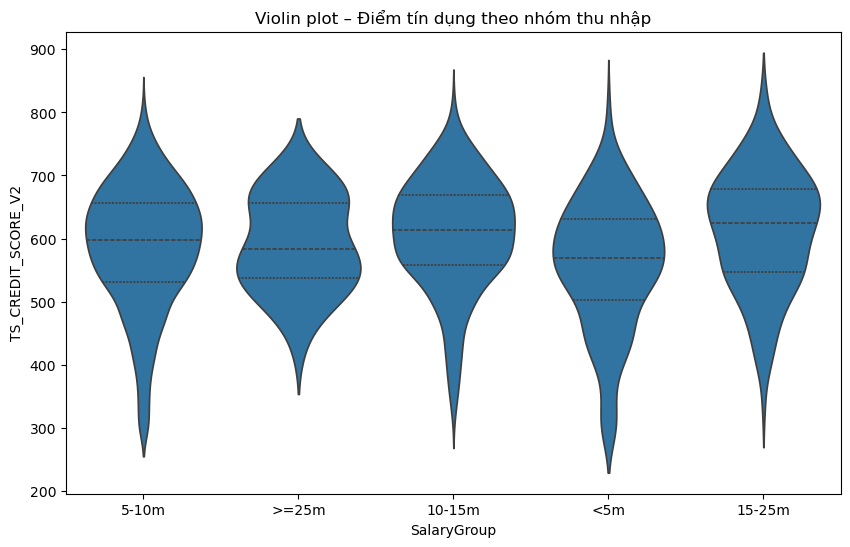

In [136]:
#Violin Plot – chi tiết phân phối mỗi nhóm
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='IncomeBracket',
    y='TS_CREDIT_SCORE_V2',
    inner='quartile'
)
plt.title("Violin plot – Điểm tín dụng theo nhóm thu nhập")
plt.xlabel("SalaryGroup")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.show()

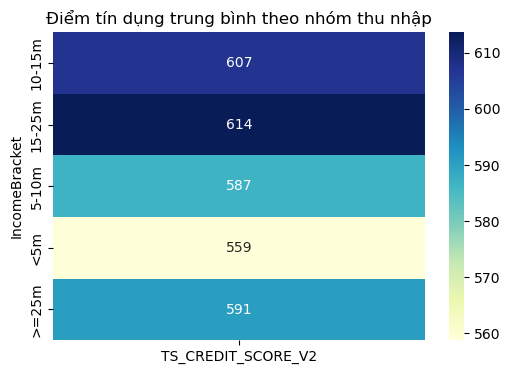

In [137]:
#Heatmap – Trung bình Credit Score theo SalaryGroup
avg_score = df.groupby('IncomeBracket')['TS_CREDIT_SCORE_V2'].mean().to_frame()

plt.figure(figsize=(6,4))
sns.heatmap(
    avg_score,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Điểm tín dụng trung bình theo nhóm thu nhập")
plt.show()

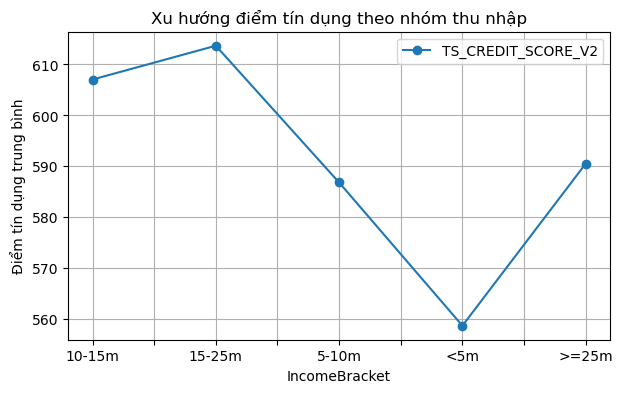

In [138]:
#Line Chart – Xu hướng điểm tín dụng theo mức lương
avg_score.plot(kind='line', marker='o', figsize=(7,4))
plt.title("Xu hướng điểm tín dụng theo nhóm thu nhập")
plt.xlabel("IncomeBracket")
plt.ylabel("Điểm tín dụng trung bình")
plt.grid(True)
plt.show()

**Insight**

Phân tích mối quan hệ giữa thu nhập và điểm tín dụng (TS_CREDIT_SCORE_V2) cho thấy bức tranh “không tuyến tính” và khác xa giả định phổ biến rằng thu nhập cao luôn đi kèm điểm tín dụng cao. Scatter plot cho thấy điểm tín dụng phân bố rất rộng ở mọi mức thu nhập, và ngay cả những khách hàng thu nhập cao (trên 30–50 triệu) cũng không có điểm tín dụng vượt trội so với nhóm thu nhập trung bình. Điều này phản ánh rằng điểm tín dụng trong dataset TIMA chịu ảnh hưởng chủ yếu bởi hành vi tài chính và lịch sử tín dụng, chứ không đơn thuần bởi mức lương.

Tuy nhiên, xu hướng tổng thể vẫn nhận diện được: thu nhập thấp (<5 triệu) có phân bố điểm tín dụng thấp nhất và phân tán mạnh. Boxplot và violin plot đều cho thấy nhóm thu nhập thấp tập trung nhiều khách hàng có điểm dưới 600 (nhóm Medium/Low), thậm chí xuất hiện cả các điểm 300–450 – thấp hơn hẳn các nhóm thu nhập còn lại. Đây là dấu hiệu rằng thu nhập thấp có thể đi kèm hành vi tín dụng yếu: thanh toán không đều, lịch sử tín dụng hạn chế hoặc khó khăn tài chính dẫn đến điểm xấu.

Ngược lại, nhóm thu nhập trung bình (10–15 triệu và 15–25 triệu) thể hiện chất lượng tín dụng ổn định nhất. Điểm tín dụng tập trung quanh 600–650, mức trung bình cao nhất trong toàn bộ dataset. Đây là nhóm có thu nhập vừa đủ ổn định, nhưng không quá cao để tạo ra hành vi tài chính chủ quan. Điều thú vị là nhóm thu nhập cao (≥25 triệu) không vượt trội so với nhóm 15–25 triệu về điểm tín dụng – thậm chí phân bố lại “phẳng” hơn, cho thấy rằng thu nhập cao không đảm bảo hành vi tín dụng tốt hơn. Điều này phù hợp với xu hướng trong các phân tích LoanStatus trước đó: thu nhập cao vẫn Muộn nhiều → có thể do thiếu kỷ luật tài chính, nhiều khoản vay song song, hoặc không ưu tiên việc trả đúng hạn.

Heatmap của điểm tín dụng trung bình theo thu nhập củng cố kết luận này:

Nhóm 15–25 triệu và 10–15 triệu có điểm trung bình cao nhất (gần 607–614).

Nhóm <5 triệu thấp nhất (gần 560).

Nhóm >=25 triệu chỉ ở mức trung bình (gần 591), thấp hơn cả nhóm 10–25 triệu.

Điều này phản biện giả thuyết "thu nhập cao --> điểm tín dụng cao”. Thực tế, điểm tín dụng mạnh nhất thuộc về nhóm thu nhập trung bình ổn định, và yếu nhất ở nhóm thu nhập thấp. Nhóm thu nhập cao có sự phân tán lớn --> không an toàn tuyệt đối.

Nhìn chung:

Thu nhập thấp (<5M): rủi ro cao nhất, điểm tín dụng thấp và phân tán mạnh → nhóm dễ xuất hiện nợ xấu hoặc trễ hạn.

Thu nhập trung bình (10–25M): phân khúc tín dụng tốt nhất, điểm tín dụng ổn định → nhóm nên ưu tiên và mở rộng.

Thu nhập cao (>=25M): không đảm bảo rủi ro thấp, phân bố điểm không vượt trội → hành vi tài chính quan trọng hơn thu nhập tuyệt đối.

Một số câu hỏi được đặt ra:

1. Tại sao nhóm thu nhập cao lại không có điểm tín dụng cao như kỳ vọng?

Vì điểm tín dụng phản ánh hành vi vay – trả, không phải mức thu nhập tuyệt đối.
Khách thu nhập cao có thể vay nhiều nơi, trả chậm vì không ưu tiên, hoặc có hành vi sử dụng tín dụng phức tạp --> dẫn đến điểm không cao.

2. Nhóm thu nhập thấp có điểm thấp vì hành vi yếu hay vì lịch sử tín dụng ít?

Khả năng lớn là cả hai: thu nhập thấp --> dễ trễ hạn --> kéo điểm xuống, và lịch sử tín dụng hạn chế --> CIC không đủ dữ liệu tích cực --> điểm bị thấp.

3. Thu nhập cao liệu có giảm rủi ro hành vi không?

Có. Thu nhập cao nhưng kỷ luật tài chính kém vẫn tạo ra tỷ lệ Muộn rất cao — nghĩa là rủi ro vận hành lớn dù rủi ro vỡ nợ thấp.

4. Điểm tín dụng có phản ánh đúng năng lực trả nợ của nhóm trẻ thu nhập thấp?

Chưa chắc. Nhóm này thường mới đi làm, chưa có lịch sử tín dụng --> điểm thấp không hẳn vì rủi ro cao. Đây là nhóm có thể cần đánh giá theo mô hình hành vi riêng.

##**TS_CREDIT_SCORE_V2 vs JobName**

1. Nghề nào có điểm tín dụng trung bình cao nhất?

2. Nghề nào có điểm tín dụng thấp nhất?

3. Nghề có thu nhập thấp → score thấp đúng không?

4. Nghề phù hợp & ổn định (văn phòng, kỹ thuật) có score cao hơn?

5. Nghề tự do / làm ca kíp có score thấp hơn?

6. Điểm tín dụng phân tán mạnh ở nghề nào nhất?

In [139]:
top_jobs = df['JobName'].value_counts().head(10).index
df_top_jobs = df[df['JobName'].isin(top_jobs)]

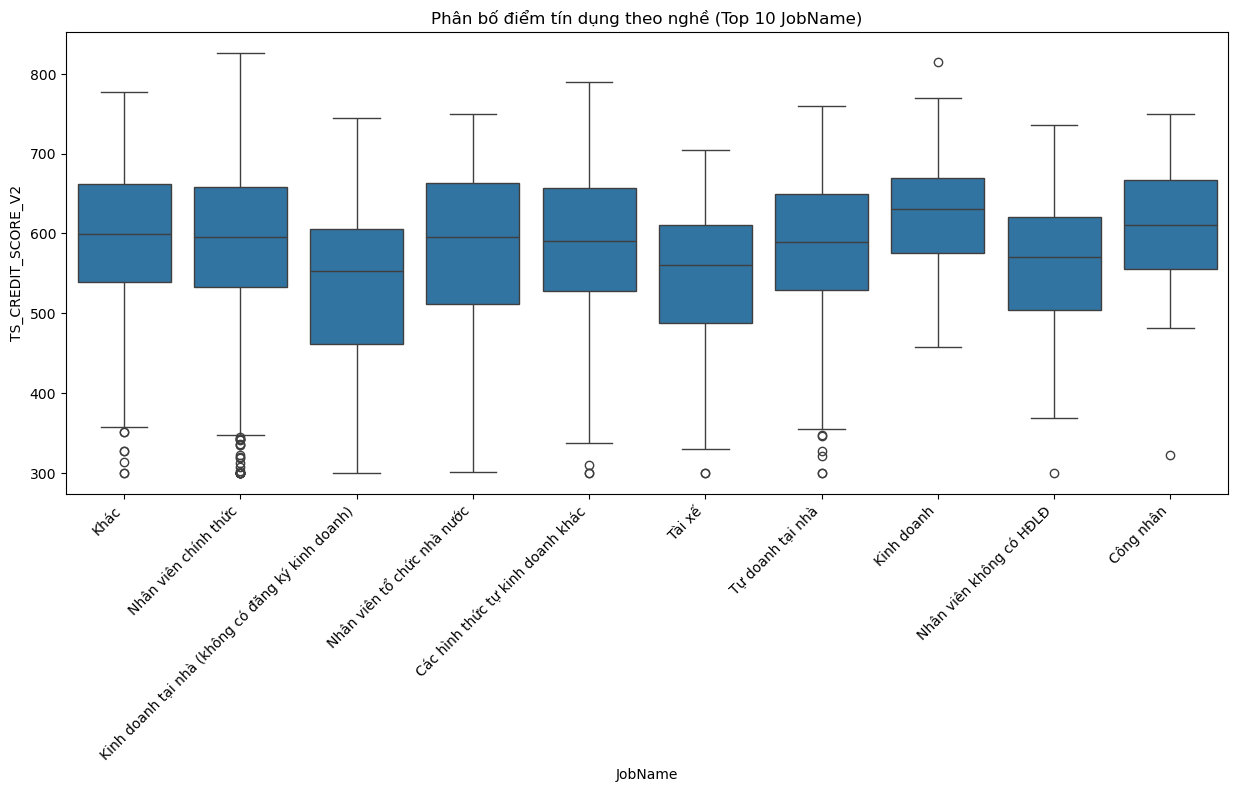

In [140]:
plt.figure(figsize=(15,6))
sns.boxplot(
    data=df_top_jobs,
    x='JobName',
    y='TS_CREDIT_SCORE_V2'
)
plt.title("Phân bố điểm tín dụng theo nghề (Top 10 JobName)")
plt.xlabel("JobName")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.xticks(rotation=45, ha='right')
plt.show()

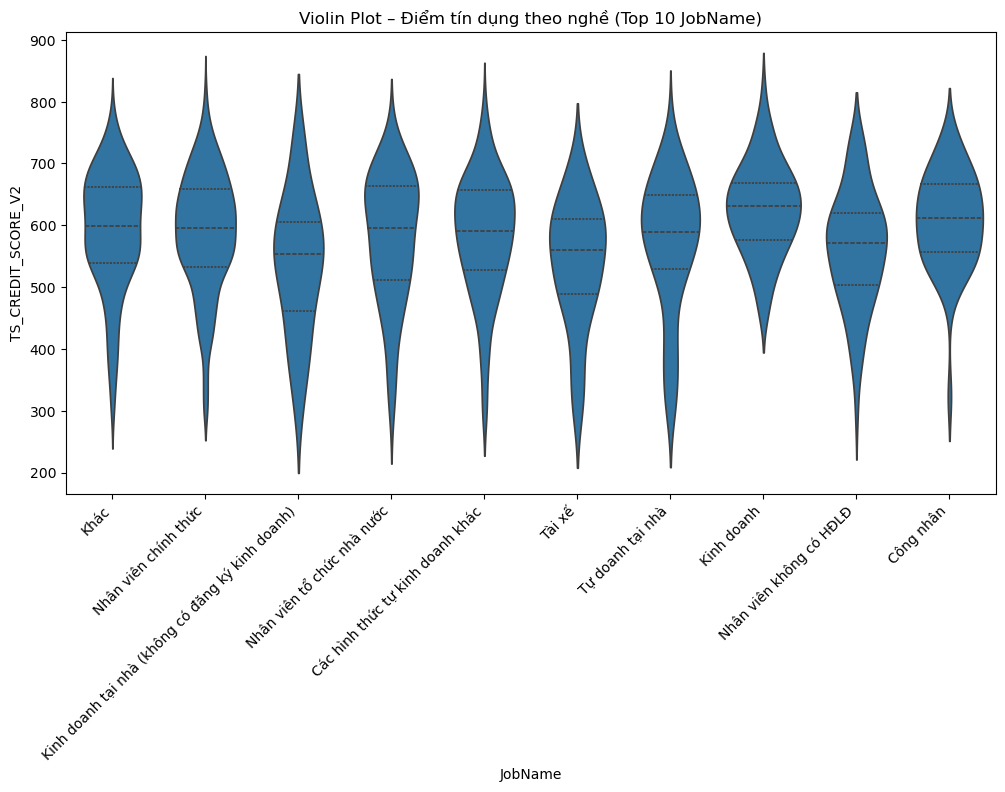

In [141]:
#Violin plot – xem hình dạng phân phối điểm tín dụng theo nghề
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df_top_jobs,
    x='JobName',
    y='TS_CREDIT_SCORE_V2',
    inner='quartile'
)
plt.title("Violin Plot – Điểm tín dụng theo nghề (Top 10 JobName)")
plt.xlabel("JobName")
plt.ylabel("TS_CREDIT_SCORE_V2")
plt.xticks(rotation=45, ha='right')
plt.show()

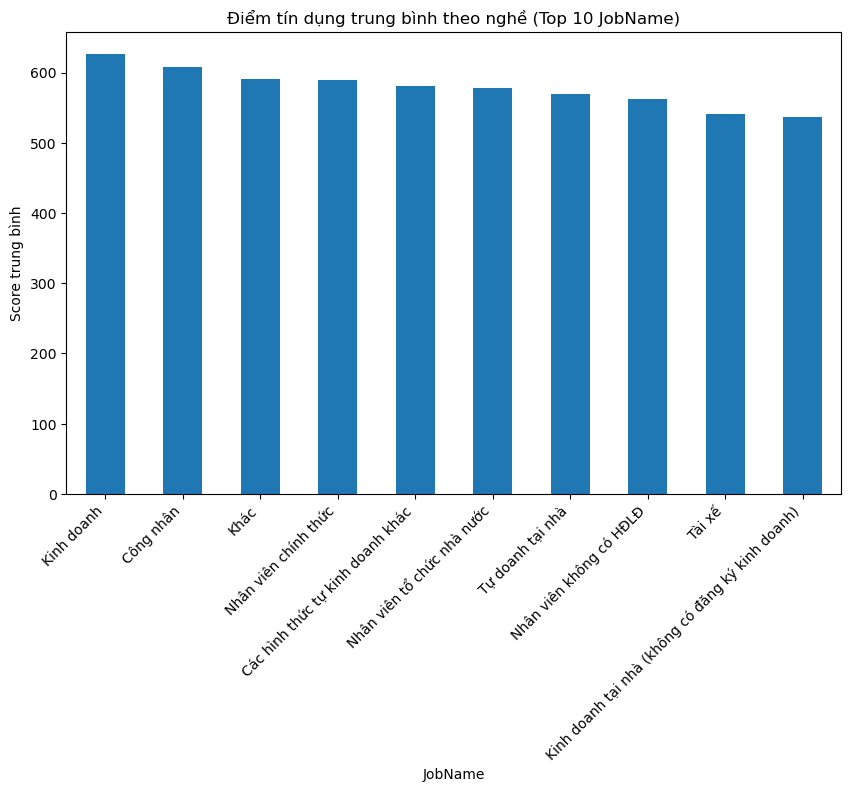

In [142]:
#Bar Chart – Điểm tín dụng trung bình theo nghề
avg_score_by_job = (
    df.groupby('JobName')['TS_CREDIT_SCORE_V2']
    .mean()
    .loc[top_jobs]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
avg_score_by_job.plot(kind='bar')
plt.title("Điểm tín dụng trung bình theo nghề (Top 10 JobName)")
plt.xlabel("JobName")
plt.ylabel("Score trung bình")
plt.xticks(rotation=45, ha='right')
plt.show()

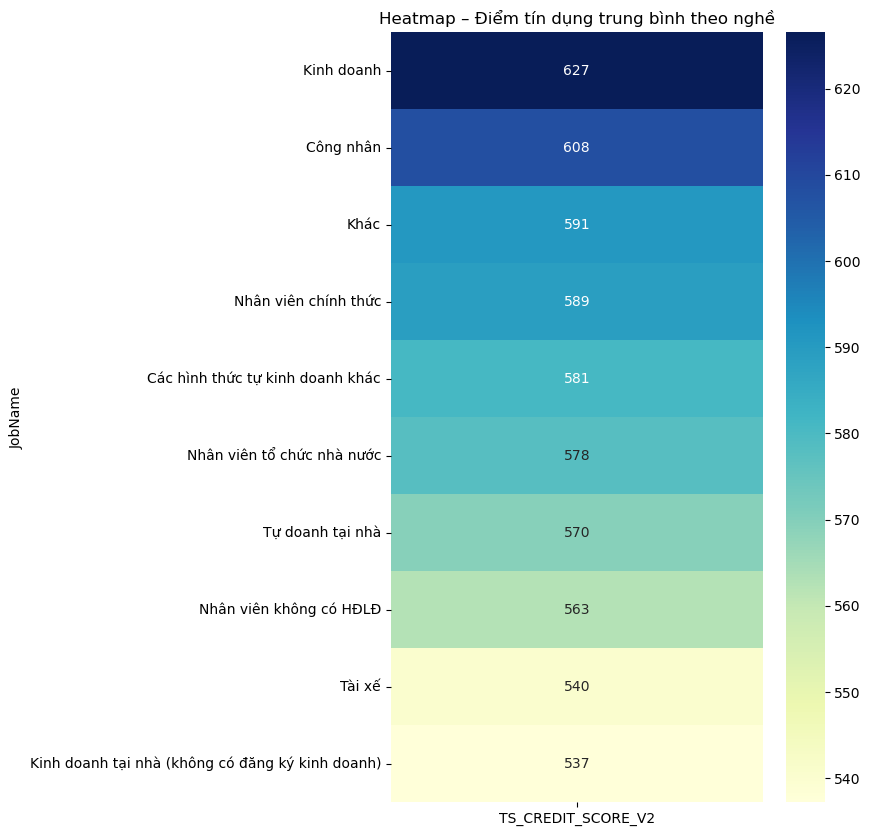

In [143]:
#Heatmap – Điểm tín dụng trung bình theo nghề
plt.figure(figsize=(6,10))
sns.heatmap(
    avg_score_by_job.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Heatmap – Điểm tín dụng trung bình theo nghề")
plt.show()

In [144]:
#Kiểm tra nghề có score thấp nhất / cao nhất
avg_score_by_job.idxmax(), avg_score_by_job.max()

('Kinh doanh', 626.5217391304348)

In [145]:
avg_score_by_job.idxmin(), avg_score_by_job.min()

('Kinh doanh tại nhà (không có đăng ký kinh doanh)', 537.2264150943396)

**Insight**

Phân tích mối quan hệ giữa điểm tín dụng và nghề nghiệp cho thấy nghề nghiệp là một biến phản ánh khá tốt mức độ ổn định tài chính và hành vi tín dụng của khách hàng. Nhìn tổng thể, điểm tín dụng phân hóa rõ rệt giữa các nhóm nghề có thu nhập ổn định và nhóm nghề tự do/làm ca kíp, cho phép nhận diện những phân khúc nghề có mức rủi ro tiềm ẩn cao hơn trong danh mục.

Nhóm nghề có điểm tín dụng cao nhất là Kinh doanh và Công nhân (TB khoảng 627 và 608 điểm). Điều này có thể phản ánh hai yếu tố: (1) thu nhập từ kinh doanh dù biến động nhưng có mức “đệm” tài chính cao hơn, hoặc (2) người kinh doanh thường quen với các dịch vụ tín dụng – vay – trả từ sớm, giúp lịch sử tín dụng của họ rõ ràng và được chấm điểm cao. Với công nhân, mức lương đều đặn theo tháng và tính kỷ luật trong trả nợ giúp giữ điểm tín dụng ổn định. Đây là hai phân khúc nghề có thể xem là “ổn định về hành vi tín dụng”, dù sức khỏe tài chính tuyệt đối có thể không cao.

Ở chiều ngược lại, điểm tín dụng thấp nhất xuất hiện ở nhóm nghề Kinh doanh tại nhà (không đăng ký kinh doanh) và Tài xế (TB 537–540 điểm). Đây là nhóm nghề có thu nhập dao động theo ngày/tuần, thiếu hợp đồng lao động, dễ chịu ảnh hưởng bởi mùa vụ, khiến khả năng duy trì dòng tiền đều đặn cho trả nợ trở nên khó khăn hơn. Điều này cho thấy điểm tín dụng nội bộ đang phản ánh đúng rủi ro hành vi – nhóm nghề thu nhập không ổn định thường có điểm tín dụng thấp hơn.

Một số nghề hành chính – văn phòng như Nhân viên chính thức, Nhân viên tổ chức nhà nước hay Các hình thức tự kinh doanh khác có điểm tín dụng trung bình ở mức khá (578–589 điểm), phản ánh mức rủi ro trung bình – ổn định. Đây là nhóm khách hàng có khả năng dự báo hành vi tín dụng tốt nhất: thu nhập đều, môi trường làm việc ổn định, lịch sử tài chính ít biến động.

Khi phân tích độ phân tán của điểm tín dụng trong từng nghề, có thể thấy các nghề tự do (Kinh doanh tại nhà, Nhân viên không HĐLĐ, Tài xế) có dải score rộng hơn đáng kể. Điều này cho thấy rủi ro của nhóm nghề tự do không chỉ cao mà còn thiếu tính ổn định – trong cùng một nghề có cả khách hàng rất rủi ro lẫn khách hàng tốt. Vì vậy, dùng “nghề nghiệp” như một yếu tố chấm điểm cần thận trọng: nghề tự do nên được phân tách sâu hơn (ví dụ: mức thu nhập thực tế, lịch sử công việc, thời gian hành nghề…).

Nhìn chung, nghề nghiệp không phải là biến quyết định tuyệt đối, nhưng là tín hiệu quan trọng phản ánh mức độ ổn định dòng tiền và hành vi tín dụng. Những nghề có lương cố định hoặc cơ chế chi trả tháng – quý (công nhân, nhân viên chính thức) thường có score cao hơn. Ngược lại, nghề tự do và nghề làm theo ca có điểm thấp hơn rõ rệt, phù hợp với insight từ các phân tích LoanStatus.

##**HasBadDebt vs Salary**

1. Nhóm HasBadDebt = 1 có thu nhập thấp hơn đáng kể không?

2. Có mức thu nhập nào mà khách dễ bị CIC nợ xấu hơn không?

3. Thu nhập có ảnh hưởng trực tiếp đến khả năng phát sinh nợ xấu CIC không?

4. Nhóm thu nhập cao có nhiều HasBadDebt hay không?

5. HasBadDebt xuất hiện có tập trung vào SalaryGroup nào không?

In [146]:
pd.crosstab(df['IncomeBracket'], df['HasBadDebt'])

HasBadDebt,0,1
IncomeBracket,,
10-15m,384,29
15-25m,136,16
5-10m,1383,185
<5m,178,23
>=25m,40,9


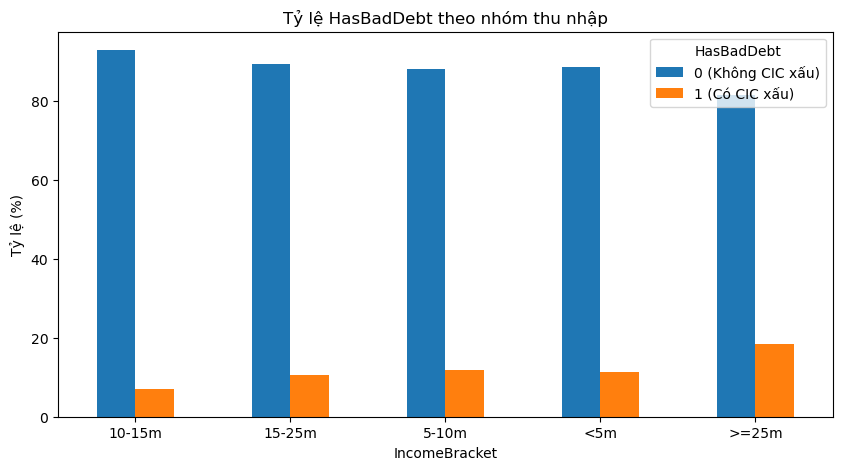

In [147]:
#Bar chart – Tỷ lệ HasBadDebt theo SalaryGroup
risk_salary_baddebt = (
    pd.crosstab(df['IncomeBracket'], df['HasBadDebt'], normalize='index') * 100
)

risk_salary_baddebt.plot(kind='bar', figsize=(10,5))
plt.title("Tỷ lệ HasBadDebt theo nhóm thu nhập")
plt.xlabel("IncomeBracket")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="HasBadDebt", labels=["0 (Không CIC xấu)", "1 (Có CIC xấu)"])
plt.show()

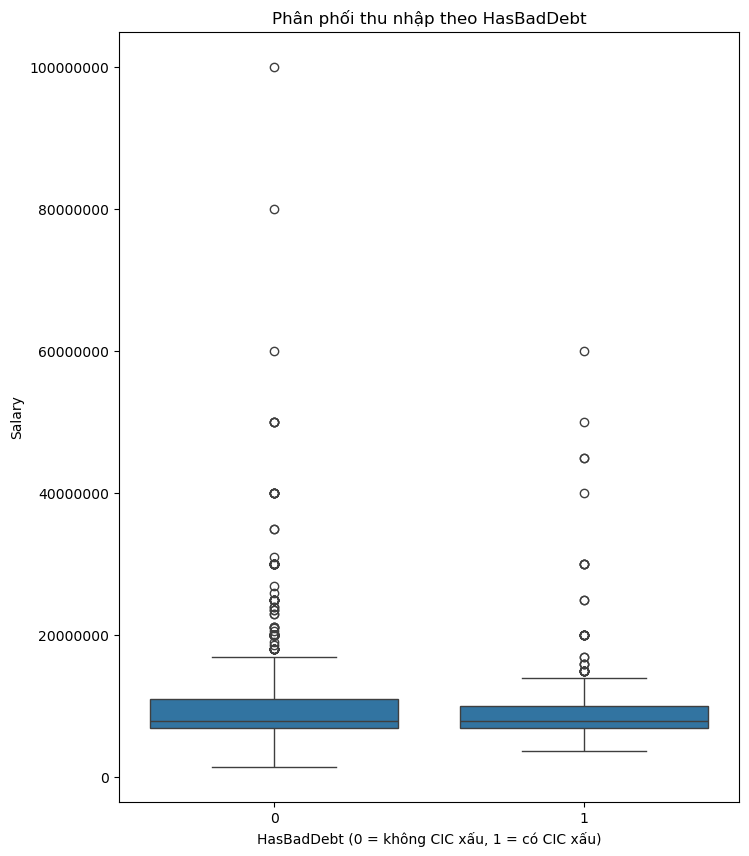

In [148]:
#Boxplot – Phân phối thu nhập theo HasBadDebt
plt.figure(figsize=(8,10))
sns.boxplot(data=df, x='HasBadDebt', y='Salary')
plt.title("Phân phối thu nhập theo HasBadDebt")
plt.xlabel("HasBadDebt (0 = không CIC xấu, 1 = có CIC xấu)")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

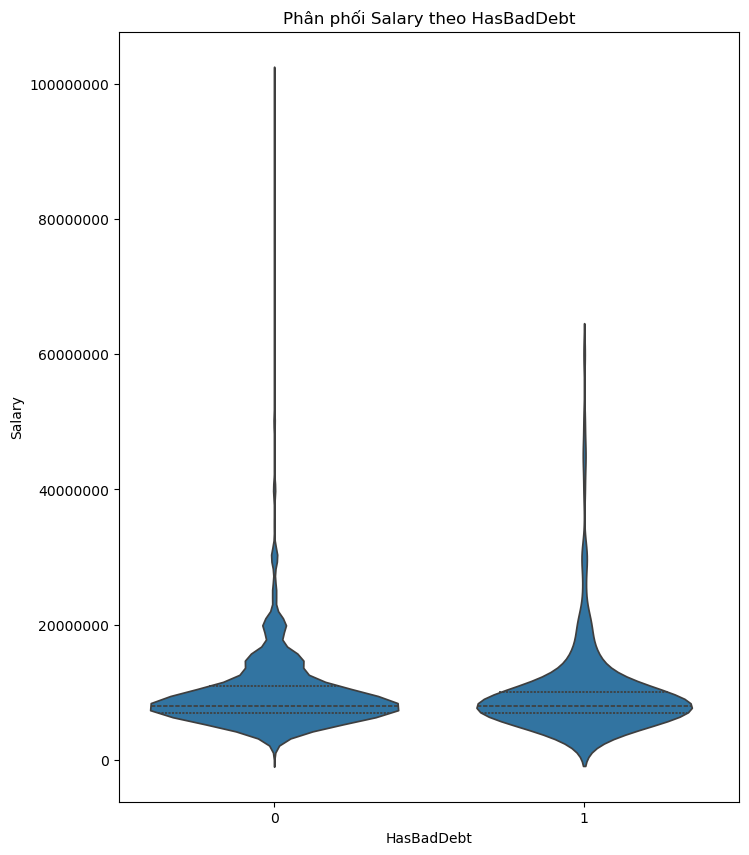

In [149]:
#Violin Plot – Salary theo HasBadDebt
plt.figure(figsize=(8,10))
sns.violinplot(
    data=df,
    x='HasBadDebt',
    y='Salary',
    inner='quartile'
)
plt.title("Phân phối Salary theo HasBadDebt")
plt.xlabel("HasBadDebt")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

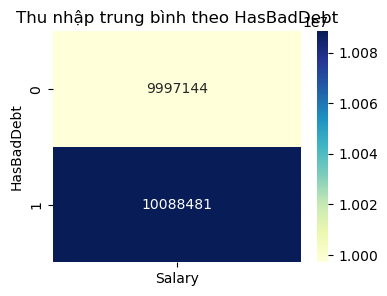

In [150]:
#Heatmap – trung bình Salary theo HasBadDebt
avg_salary = df.groupby('HasBadDebt')['Salary'].mean().to_frame()

plt.figure(figsize=(4,3))
hm = sns.heatmap(
    avg_salary,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Thu nhập trung bình theo HasBadDebt")
plt.show()

**Insight**

Phân tích mối quan hệ giữa thu nhập và khả năng phát sinh CIC nợ xấu (HasBadDebt) cho thấy một bức tranh khá thú vị: thu nhập không phải là yếu tố quyết định trực tiếp việc khách hàng có CIC xấu hay không. Tỷ lệ HasBadDebt = 1 dao động quanh 8–12% ở mọi nhóm thu nhập, ngay cả nhóm thu nhập rất cao (>=25 triệu) cũng có gần 18% hồ sơ từng có CIC xấu — cao hơn cả một số nhóm thu nhập trung bình. Điều này bác bỏ giả thuyết đơn giản rằng "thu nhập thấp --> dễ có nợ xấu CIC hơn", vì dữ liệu cho thấy mức thu nhập trung bình của nhóm CIC xấu thậm chí nhỉnh hơn nhóm bình thường (khoảng 10 triệu so với 9.9 triệu). Nghĩa là CIC xấu phản ánh nhiều hơn về hành vi tài chính quá khứ, không phụ thuộc tuyệt đối vào khả năng tài chính hiện tại.

Tuy vậy, có sự khác biệt theo phân khúc thu nhập: nhóm 5–10 triệu là nhóm có số lượng HasBadDebt cao nhất tính theo số tuyệt đối, do họ chiếm đa số khách hàng của danh mục. Điều này dẫn tới một insight quan trọng: mức thu nhập trung bình thấp hơn không làm tăng tỷ lệ rủi ro CIC xấu, nhưng làm tăng quy mô rủi ro khi nhóm này chiếm tỷ trọng lớn trong toàn bộ tệp khách hàng. Ngược lại, ở nhóm thu nhập rất thấp (<5 triệu), tỷ lệ CIC xấu lại không cao như dự đoán — nhiều khả năng vì khách thu nhập thấp bị loại ngay từ khâu thẩm định CIC hoặc chỉ vay nhỏ, nên không để lại CIC xấu trong quá khứ.

Một chi tiết đáng chú ý là nhóm thu nhập cao (>=25M) tuy có năng lực trả nợ tốt hơn nhưng lại xuất hiện CIC xấu nhiều hơn kỳ vọng. Điều này có thể phản ánh nhóm này vay ở nhiều tổ chức cùng lúc, quản lý dòng tiền phức tạp hoặc từng gặp sự cố tài chính ngắn hạn nhưng sau đó phục hồi. Việc điểm tín dụng của họ ở mức trung bình khá và sự phân tán thu nhập rộng cho thấy CIC xấu ở nhóm này không phải do nghèo, mà do hành vi tài chính (ví dụ: vay nhiều khoản, chi tiêu lớn theo chu kỳ, thiếu kỷ luật thanh toán).

Nhìn tổng thể, thu nhập không cho thấy quan hệ tuyến tính với CIC xấu. CIC xấu không tập trung ở nhóm nghèo hay giàu, mà phân bố tương đối đồng đều — điều này gợi ý rằng HasBadDebt không phản ánh năng lực tài chính hiện tại, mà phản ánh tiền sử hành vi tín dụng. Do đó, cần đánh giá HasBadDebt như một biến độc lập về hành vi quá khứ, không nên sử dụng thu nhập để dự đoán tình trạng CIC của khách hàng.

##**HasLatePayment vs Salary**

1. Nhóm thu nhập thấp có nhiều khách trả chậm hơn không?

2. Nhóm thu nhập cao có ít trả chậm hơn không?

3. Phân bố thu nhập của nhóm trả chậm khác biệt gì so với nhóm bình thường?

4. Tỷ lệ HasLatePayment của từng SalaryGroup là bao nhiêu?

5. Thu nhập thấp (<10M) có xu hướng trễ hạn cao?

6. Thu nhập cao có thể vẫn có trả chậm nhưng ít hơn?

7. Có SalaryGroup nào cực kỳ rủi ro không?

In [151]:
pd.crosstab(df['IncomeBracket'], df['HasLatePayment'])

HasLatePayment,0,1
IncomeBracket,,
10-15m,344,69
15-25m,133,19
5-10m,1345,223
<5m,180,21
>=25m,45,4


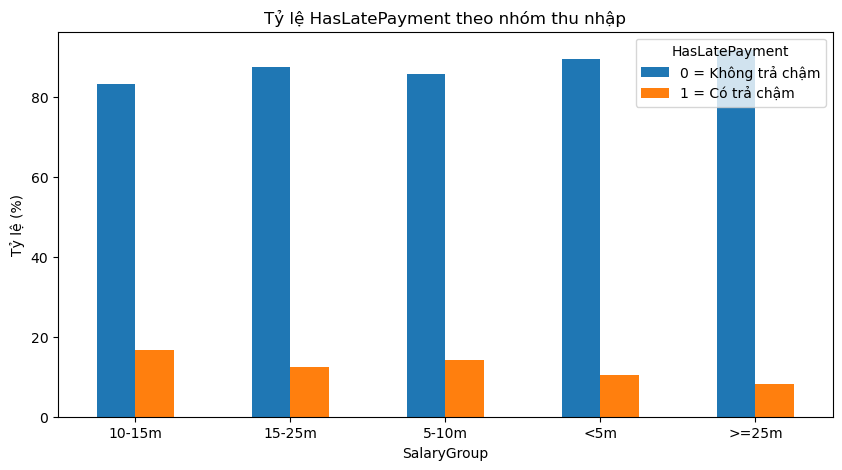

In [152]:
#Bar chart – Tỷ lệ HasLatePayment theo SalaryGroup
risk_salary_late = (
    pd.crosstab(df['IncomeBracket'], df['HasLatePayment'], normalize='index') * 100
)

risk_salary_late.plot(kind='bar', figsize=(10,5))
plt.title("Tỷ lệ HasLatePayment theo nhóm thu nhập")
plt.xlabel("SalaryGroup")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="HasLatePayment", labels=["0 = Không trả chậm", "1 = Có trả chậm"])
plt.show()

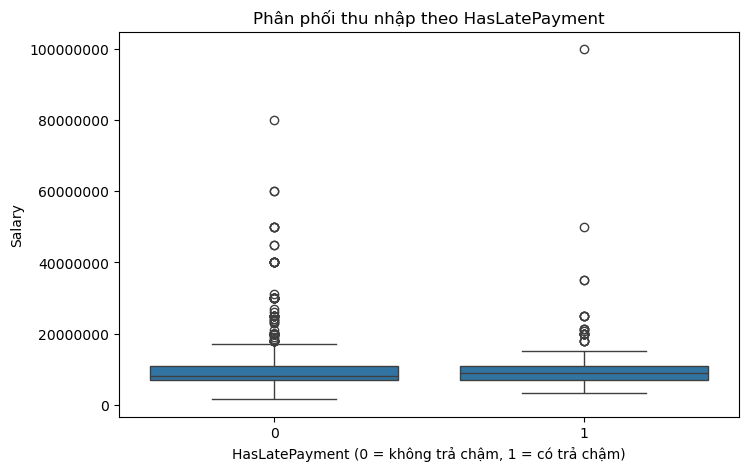

In [153]:
#Boxplot – Phân phối thu nhập theo HasLatePayment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='HasLatePayment', y='Salary')
plt.title("Phân phối thu nhập theo HasLatePayment")
plt.xlabel("HasLatePayment (0 = không trả chậm, 1 = có trả chậm)")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


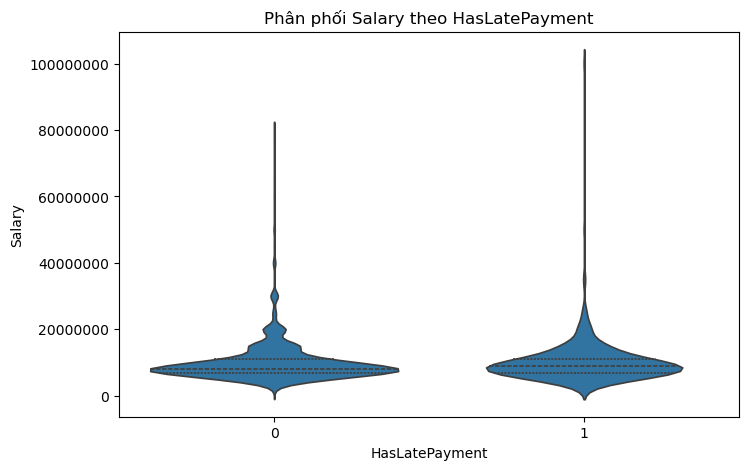

In [154]:
#Violin Plot – Salary theo HasLatePayment
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x='HasLatePayment',
    y='Salary',
    inner='quartile'
)
plt.title("Phân phối Salary theo HasLatePayment")
plt.xlabel("HasLatePayment")
plt.ylabel("Salary")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


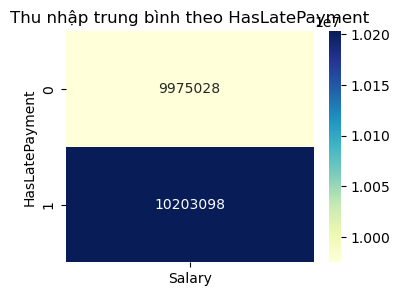

In [155]:
#Heatmap – trung bình Salary theo HasLatePayment
avg_salary_late = df.groupby('HasLatePayment')['Salary'].mean().to_frame()

plt.figure(figsize=(4,3))
sns.heatmap(
    avg_salary_late,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Thu nhập trung bình theo HasLatePayment")
plt.show()

**Insight**

Phân tích mối quan hệ giữa thu nhập và hành vi trả chậm cho thấy thu nhập không phải là yếu tố quyết định rõ ràng đối với khả năng trả chậm, dù nhóm thu nhập thấp vẫn ghi nhận mức rủi ro cao hơn đôi chút. Tỷ lệ trả chậm trong tất cả các nhóm thu nhập đều dao động quanh mức 12–15%, cho thấy hành vi trả chậm là một vấn đề mang tính hành vi kredo, chứ không chỉ bị chi phối bởi thu nhập.

Ở nhóm thu nhập thấp nhất (<5m), tỷ lệ khách hàng trả chậm đạt gần 15%, cao hơn mức trung bình chung. Đây là nhóm dễ tổn thương về tài chính, thường gặp biến động thu nhập và thiếu dự phòng, dẫn đến rủi ro cao hơn. Tuy nhiên, điều đáng chú ý là nhóm thu nhập trung bình – đặc biệt 5–10m, vốn có số lượng khách rất lớn – cũng ghi nhận tỷ lệ trả chậm ở mức 14–15%, gần tương đương với nhóm thu nhập thấp. Điều này cho thấy thu nhập vừa phải nhưng không ổn định, chi phí sinh hoạt cao hoặc quản lý dòng tiền kém có thể là nguyên nhân sâu xa.

Ở nhóm thu nhập cao (>25m), tỷ lệ trả chậm giảm xuống khoảng 8–9%, cho thấy mức độ ổn định tài chính cao hơn. Tuy vậy, mức giảm không quá mạnh, hàm ý rằng ngay cả khách hàng thu nhập cao vẫn có khả năng trả chậm, có thể do thói quen chi tiêu – chứ không phải năng lực tài chính.

Khi xem xét phân phối thu nhập giữa hai nhóm có/không trả chậm, boxplot và violin plot cho thấy hai nhóm này gần như không khác biệt nhiều về median. Thu nhập trung bình của nhóm trả chậm thậm chí còn nhỉnh hơn một chút so với nhóm không trả chậm (khoảng 10.2m vs 9.9m), nhưng sự khác biệt không đủ lớn để kết luận có quan hệ nhân quả. Điều này củng cố nhận định rằng: trả chậm là một hành vi, không đơn thuần là do “nghèo nên trả chậm”.

Nhìn chung, mặc dù khách thu nhập thấp trả chậm nhiều hơn một chút, nhưng hành vi trả chậm xuất hiện ở mọi mức thu nhập. Thu nhập cao không đảm bảo tránh được trả chậm, và thu nhập thấp cũng không nhất thiết dẫn tới rủi ro rất cao. Đây là đặc điểm cho thấy nhóm biến tài chính – hành vi (behavioural risk) có vai trò lớn trong dự báo rủi ro hơn so với thu nhập thuần túy.

#**Insight tổng hợp và phân tích Chẩn đoán các Yếu tố liên quan đến Hồ sơ Tín dụng Khách hàng (Credit Profile Analysis)**


##**INSIGHT TỔNG HỢP**

Phân tích hồ sơ tín dụng của khách hàng cho thấy một bức tranh rất khác với trực giác thông thường về thu nhập, nghề nghiệp và khả năng tín dụng. Mặc dù dễ cho rằng “thu nhập cao --> rủi ro thấp” hay “thu nhập thấp --> điểm xấu”, dữ liệu lại phản ánh một câu chuyện phức tạp hơn nhiều — trong đó hành vi tài chính và sự ổn định dòng tiền đóng vai trò quan trọng hơn mức thu nhập tuyệt đối.

Nhóm thu nhập thấp (<5 triệu) đúng là có điểm tín dụng thấp nhất và phân tán rộng, cho thấy đây là phân khúc có nguy cơ cao nhất về mặt lịch sử tín dụng và hành vi vay – trả. Tuy nhiên, khi quan sát các nhóm thu nhập cao, một điều bất ngờ xuất hiện: thu nhập cao không dẫn đến điểm tín dụng cao tương ứng. Các khách hàng thu nhập ≥25 triệu có điểm tín dụng trung bình ở mức khá nhưng không hề vượt trội, và mức phân tán lại còn lớn hơn. Điều này cho thấy rằng thu nhập cao không bảo đảm kỷ luật tài chính — nhiều khách có thu nhập lớn vẫn trễ hạn hoặc có CIC xấu, có thể vì nhiều khoản vay song song hoặc quản lý tài chính thiếu ổn định.

Ngược lại, phân khúc thu nhập trung bình (10–25 triệu) mới là nhóm có hồ sơ tín dụng tốt nhất: điểm tín dụng cao và ổn định hơn các phân khúc khác. Đây là nhóm “đủ thu nhập để ổn định, đủ kỷ luật để an toàn”, phù hợp nhất với hồ sơ tín dụng lành mạnh.

Khi quan sát theo nghề nghiệp, có thể thấy rõ hơn: nghề nghiệp phản ánh độ ổn định dòng tiền nên ảnh hưởng mạnh đến điểm tín dụng. Công nhân và nhân viên văn phòng có điểm tín dụng ổn định vì thu nhập đều, trong khi nghề tự do, tài xế hoặc kinh doanh tại nhà — vốn chịu biến động thu nhập lớn — lại có điểm tín dụng thấp nhất. Một ngoại lệ thú vị là nhóm “Kinh doanh”, vốn có điểm cao nhất, không phải vì thu nhập ổn định, mà vì họ có lịch sử sử dụng tín dụng dày và kinh nghiệm vay trả lâu năm.

Với hành vi CIC, dữ liệu cho thấy HasBadDebt và HasLatePayment không phụ thuộc tuyến tính vào thu nhập. Tỷ lệ CIC xấu và trả chậm xuất hiện ở mọi mức thu nhập, thậm chí nhóm thu nhập cao có tỷ lệ CIC xấu gần 18%, cao hơn cả một số nhóm thu nhập thấp. Điều này chứng minh rằng lịch sử tín dụng và hành vi chi tiêu mới là yếu tố trọng tâm, không phải mức thu nhập hiện tại.

Tóm lại, hồ sơ tín dụng của khách hàng được hình thành bởi hành vi tài chính, mức độ ổn định thu nhập và loại hình nghề nghiệp. Thu nhập tạo năng lực trả nợ, nhưng hành vi mới tạo ra chất lượng hồ sơ; nghề nghiệp phản ánh mức độ ổn định, nhưng hồ sơ tín dụng mới phản ánh khả năng trả nợ thực sự.

##**Giải thuyết**


2a – “Năng lực tài chính (thu nhập) là yếu tố quan trọng nhất quyết định chất lượng tín dụng.”

--> Kết quả: Giả thuyết bị bác bỏ.

Dữ liệu cho thấy thu nhập thấp liên quan đến rủi ro cao hơn, nhưng thu nhập cao hoàn toàn không bảo đảm hồ sơ tín dụng đẹp. Điểm tín dụng trung bình của nhóm ≥25 triệu thậm chí thấp hơn nhóm thu nhập 15–25 triệu. Tỷ lệ CIC xấu và trả chậm trong nhóm thu nhập cao cũng không thấp hơn nhiều so với các nhóm khác.

Thu nhập chỉ là điều kiện cần, nhưng không phải điều kiện đủ.
Hành vi trả nợ, lịch sử tín dụng và tính kỷ luật của khách hàng mới là yếu tố quyết định.

2b – “Nghề nghiệp ổn định → hồ sơ tín dụng tốt hơn.”

--> Kết quả: Giả thuyết đúng một phần.

Nghề nghiệp ổn định (công nhân, nhân viên văn phòng, nhà nước) có điểm tín dụng ổn định và ít phân tán — đúng như kỳ vọng.

Tuy nhiên:

Một số nhóm nghề ổn định không có điểm cao nhất

Nhóm "Kinh doanh" — dù không ổn định — lại có điểm cao nhất vì lịch sử vay trả dày đặc

Nhóm nghề tự do có điểm tín dụng thấp và phân tán mạnh, đúng như dự đoán

Do đó, nghề nghiệp ổn định đúng là giúp nâng cao hồ sơ tín dụng, nhưng tần suất và lịch sử sử dụng tín dụng lại quan trọng hơn.

##**KẾT LUẬN: Các yếu tố liên quan mạnh nhất đến Hồ sơ Tín dụng Khách hàng**



(1) Hành vi tài chính (Financial Behaviour) — yếu tố mạnh nhất

Gồm:

- Lịch sử trả chậm (HasLatePayment)

- CIC nợ xấu quá khứ (HasBadDebt)

- Tính kỷ luật trong thanh toán

- Mức độ ưu tiên việc trả nợ

Điểm tín dụng phản ánh hành vi và lịch sử hơn là tình trạng tài chính hiện tại.

(2) Độ ổn định thu nhập (Income Stability)

- Không phải mức thu nhập, mà là tính đều đặn của dòng tiền:

- Thu nhập đều --> điểm ổn định

- Thu nhập dao động --> điểm phân tán mạnh

Đây là lý do nghề nghiệp ảnh hưởng mạnh đến score.

(3) Loại hình nghề nghiệp (JobName)

Nghề nghiệp là chỉ báo của tính ổn định tài chính:

Nghề ổn định --> score ổn định

Nghề tự do --> score thấp và phân tán

Kinh doanh --> score cao nhờ lịch sử tín dụng dày, không phải ổn định thu nhập

(4) Thu nhập rất thấp (<5M) là một yếu tố rủi ro thực sự

Nhóm này có score thấp nhất, CIC xấu cao hơn và hành vi tín dụng yếu.

(5) Thu nhập cao (≥25M) không phải vùng an toàn

Điểm tín dụng không cao, tỷ lệ CIC xấu không thấp → hành vi quan trọng hơn thu nhập.

#**Loan Size (Quy mô khoản vay)**



##**JobName vs Tiền giải ngân**

1. Nghề nào vay nhiều nhất?

2. Nghề nào vay ít nhất?

3. Nghề có thu nhập cao có được vay nhiều hơn không?

4. Công nhân, tài xế, lao động tự do vay ít hơn nghề văn phòng đúng không?

5. Có nghề nào vay nhiều bất thường?

6. Nghề rủi ro cao có bị hạn chế hạn mức vay không?

In [156]:
#Lấy top 10 nghề phổ biến
top_jobs = df['JobName'].value_counts().head(10).index
df_top_jobs = df[df['JobName'].isin(top_jobs)]

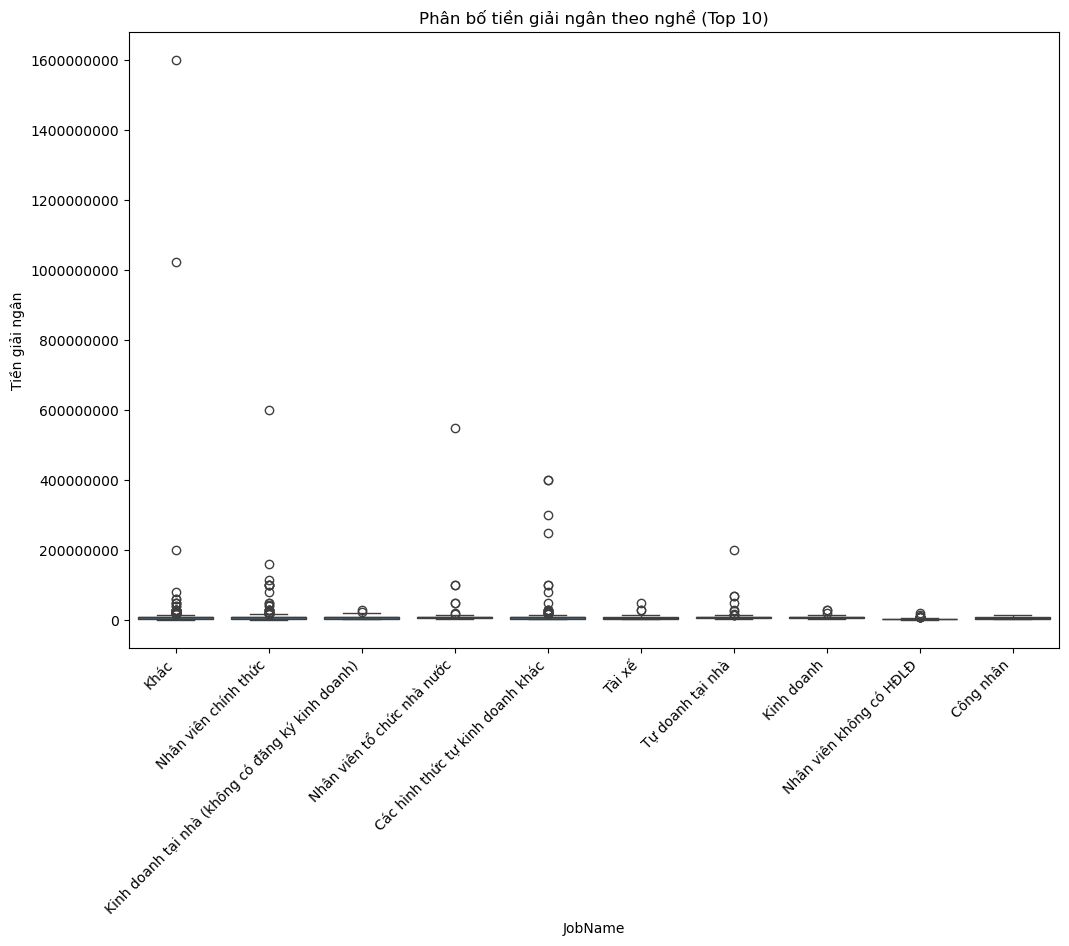

In [157]:
#Boxplot – TienGiaiNgan theo nghề
plt.figure(figsize=(12,8))
sns.boxplot(
    data=df_top_jobs,
    x='JobName',
    y='Tiền giải ngân'
)
plt.title("Phân bố tiền giải ngân theo nghề (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Tiền giải ngân")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

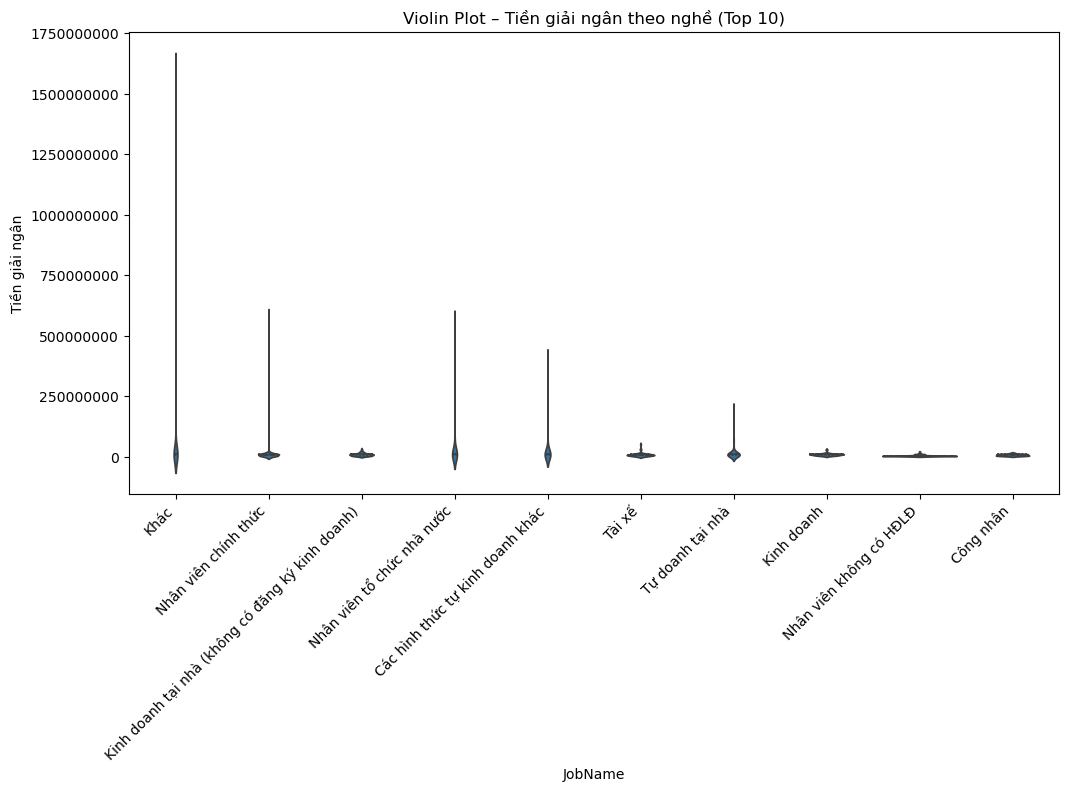

In [158]:
#Violin plot – chi tiết phân phối TienGiaiNgan theo nghề
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df_top_jobs,
    x='JobName',
    y='Tiền giải ngân',
    inner='quartile'
)
plt.title("Violin Plot – Tiền giải ngân theo nghề (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Tiền giải ngân")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


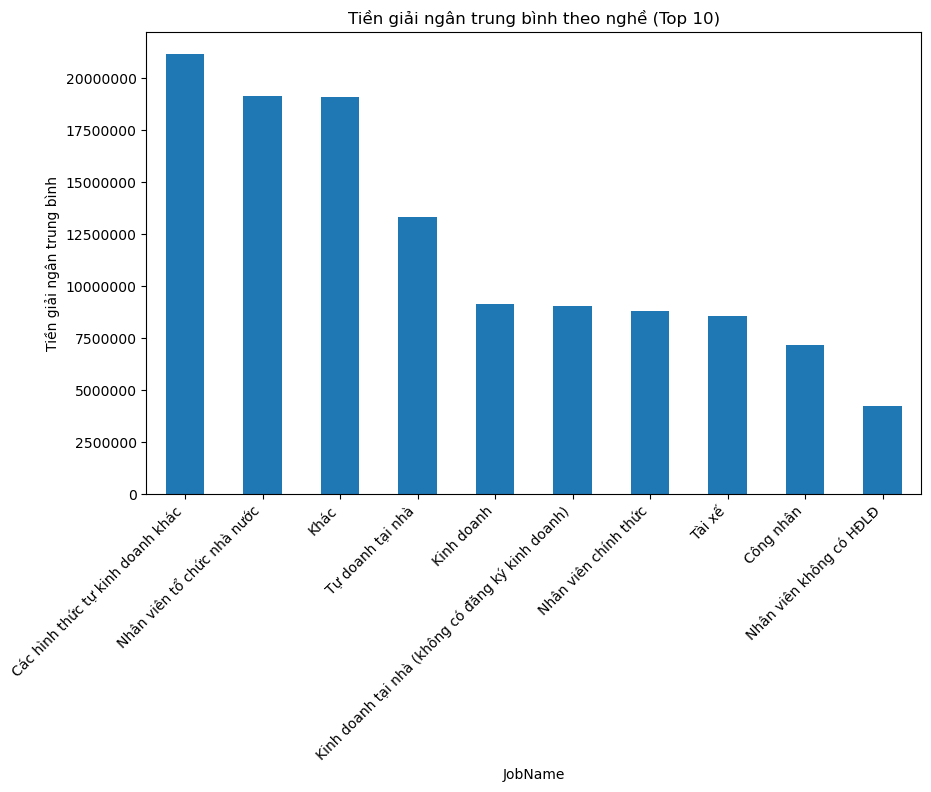

In [159]:
#Bar Chart – Tiền giải ngân trung bình theo nghề
avg_amount_by_job = (
    df_top_jobs.groupby('JobName')['Tiền giải ngân']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
avg_amount_by_job.plot(kind='bar')
plt.title("Tiền giải ngân trung bình theo nghề (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Tiền giải ngân trung bình")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

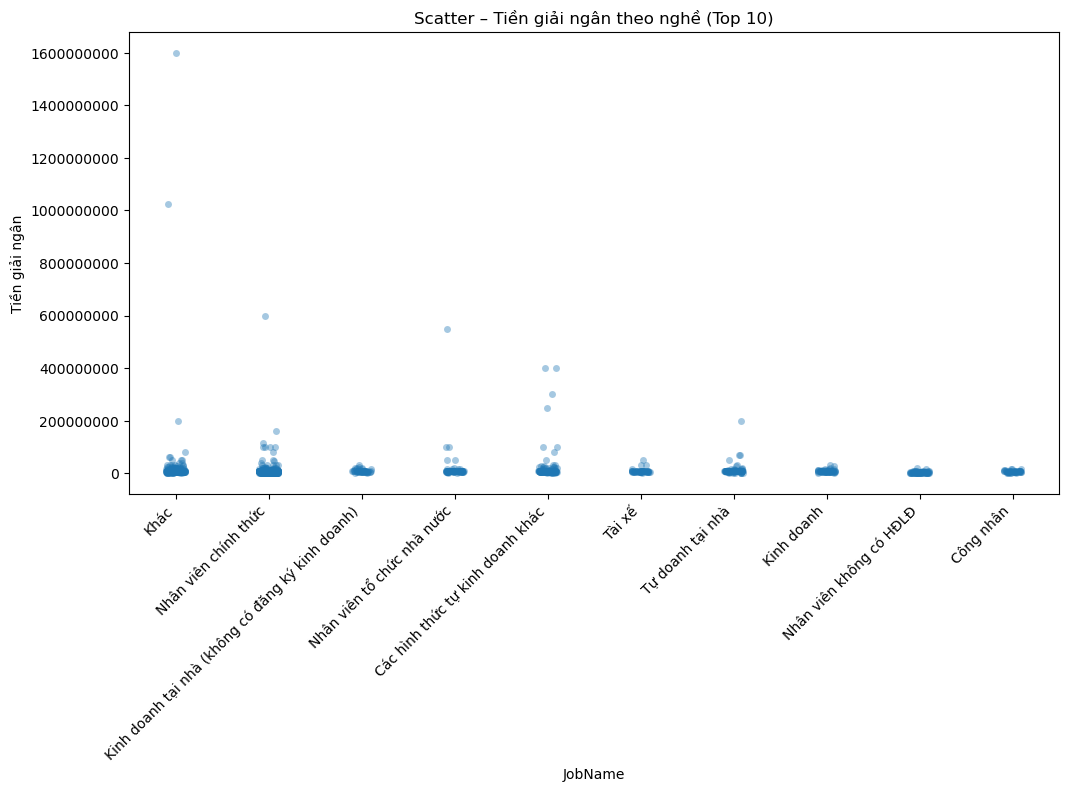

In [160]:
#Scatter plot – Phân tán tiền giải ngân theo nghề
plt.figure(figsize=(12,6))
sns.stripplot(
    data=df_top_jobs,
    x='JobName',
    y='Tiền giải ngân',
    alpha=0.4
)
plt.title("Scatter – Tiền giải ngân theo nghề (Top 10)")
plt.xlabel("JobName")
plt.ylabel("Tiền giải ngân")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Phân tích mối quan hệ giữa nghề nghiệp và quy mô khoản vay cho thấy sự phân hóa rất rõ rệt giữa các nhóm nghề ổn định – có thu nhập đều đặn và các nhóm nghề mang tính thời vụ hoặc thu nhập biến động. Các biểu đồ boxplot, violin plot và scatter plot đều chỉ ra một mô hình nhất quán: nghề nghiệp ổn định không chỉ liên quan đến điểm tín dụng mà còn dẫn đến hạn mức vay cao hơn, trong khi nhóm nghề tự do hoặc thu nhập thất thường có xu hướng vay thấp và phân tán mạnh.

Nhóm nghề có quy mô giải ngân cao nhất là “Các hình thức tự kinh doanh khác” và “Nhân viên tổ chức nhà nước”, với mức giải ngân trung bình vượt trội (gần 20–21 triệu). Điều này phản ánh hai yếu tố: (1) các nhóm nghề này có thu nhập tương đối ổn định và có tính cam kết cao trong quan hệ tài chính; (2) quy trình thẩm định của TIMA có thể đang ưu tiên hạn mức cao cho các nhóm nghề được đánh giá là ít biến động hoặc có địa vị xã hội – pháp lý rõ ràng. Việc hai nhóm này đứng đầu về hạn mức vay phù hợp với các phát hiện trước đó ở phần Credit Profile: nhóm nghề hành chính – nhà nước và kinh doanh chính thức có điểm tín dụng tốt và hành vi trả nợ ổn định hơn.

Ở tầng trung, các nghề như Tự doanh tại nhà, Kinh doanh, Nhân viên chính thức và Công nhân có mức giải ngân trung bình dao động quanh 8–12 triệu, tương đối đồng đều. Những nghề này có tính ổn định trung bình: thu nhập không quá cao nhưng đều đặn, lịch sử vay – trả rõ ràng. Đây là nhóm chiếm số lượng hồ sơ lớn và là “xương sống” của danh mục cho vay vi mô. Mô hình giải ngân này phù hợp với mức rủi ro trung bình–thấp quan sát được từ các phân tích LoanStatus và Credit Score trước đó.

Ở nhóm rủi ro cao, “Nhân viên không có HĐLĐ”, “Kinh doanh tại nhà (không đăng ký)” và “Tài xế” ghi nhận hạn mức vay thấp nhất, trung bình chỉ 4–8 triệu. Điều này phản ánh đúng thực tế: đây là các nhóm nghề có thu nhập không ổn định, phụ thuộc thời vụ, biến động mạnh theo tháng; đồng thời cũng là các nhóm có điểm tín dụng thấp hơn và tỷ lệ chậm trả cao hơn. Scatter plot cũng cho thấy phân tán khoản vay của nhóm này thấp và tập trung ở các khoản vay rất nhỏ, cho thấy TIMA đang áp dụng chính sách kiểm soát hạn mức chặt chẽ để giảm nguy cơ tổn thất.

Tổng thể, mối quan hệ giữa nghề nghiệp và hạn mức vay phản ánh rõ logic quản trị rủi ro:

Nghề ổn định --> hạn mức cao

Nghề tự do, thời vụ --> hạn mức thấp

Điều này phù hợp với xu hướng đã quan sát trong Credit Score và LoanStatus: các nghề có hành vi tín dụng tốt và thu nhập ổn định không chỉ rủi ro thấp mà còn được hưởng hạn mức vay cao hơn, tạo thành sự phân tầng tín dụng hợp lý.

##**Salary vs Tiền giải ngân**

1. Thu nhập cao có được giải ngân nhiều hơn không?

2. Thu nhập thấp có bị giới hạn hạn mức giải ngân không?

3. Có mối quan hệ tuyến tính Salary vs TienGiaiNgan không?

4. Thu nhập nào vay cao bất thường?

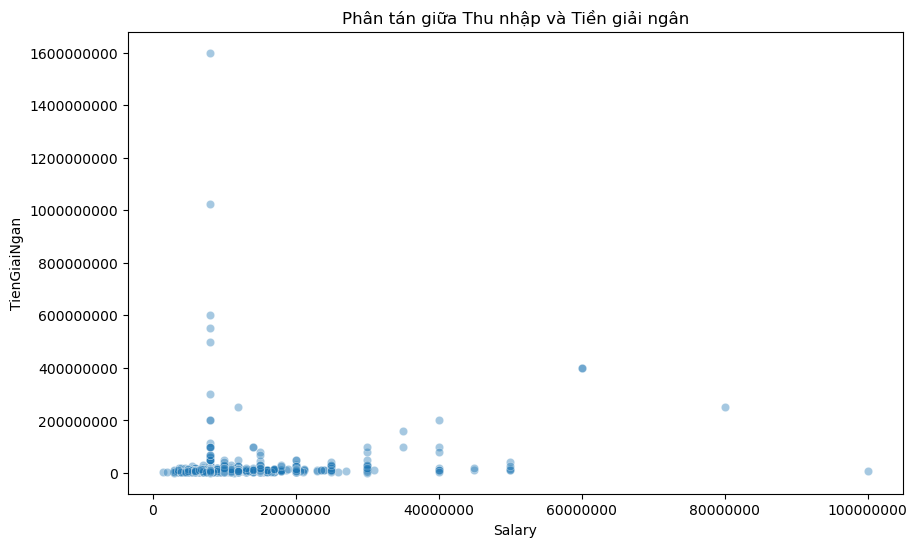

In [161]:
#Scatter Plot – Salary vs Tiền giải ngân
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Salary',
    y='Tiền giải ngân',
    alpha=0.4
)
plt.title("Phân tán giữa Thu nhập và Tiền giải ngân")
plt.xlabel("Salary")
plt.ylabel("TienGiaiNgan")
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


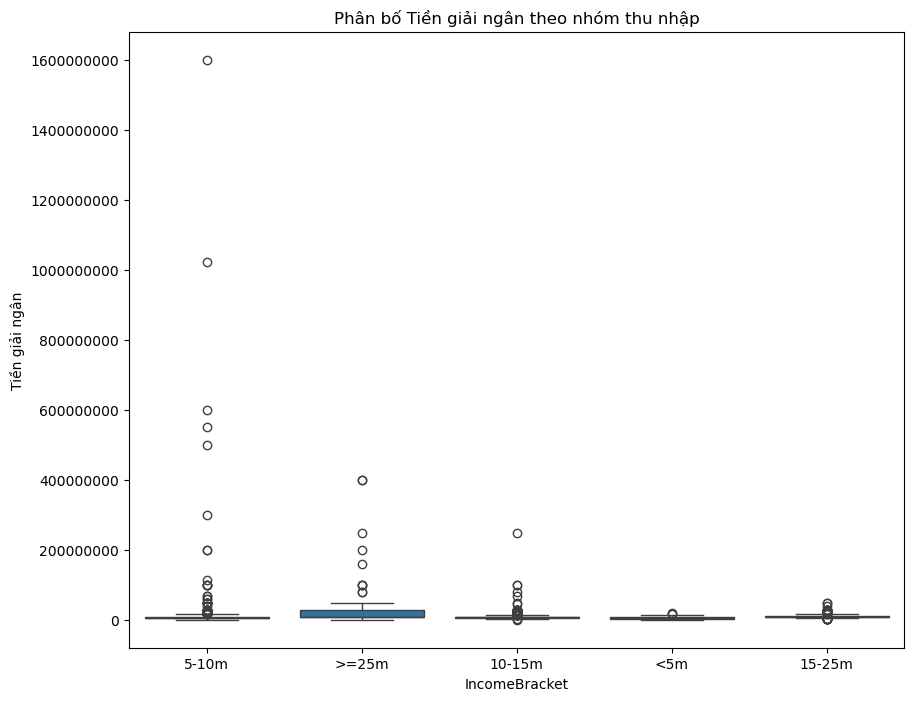

In [162]:
#Boxplot – Tiền giải ngân theo IncomeBracket
plt.figure(figsize=(10,8))
sns.boxplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân'
)
plt.title("Phân bố Tiền giải ngân theo nhóm thu nhập")
plt.xlabel("IncomeBracket")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

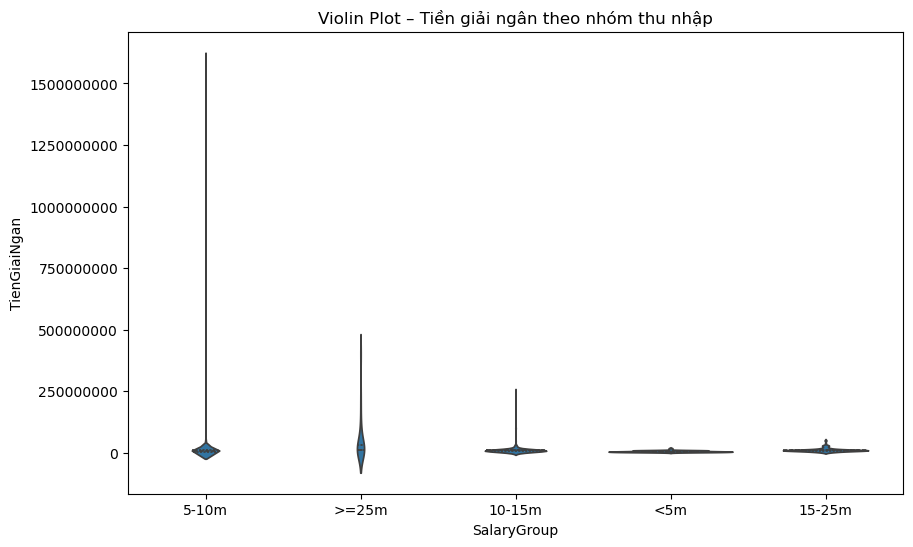

In [163]:
#Violin Plot – cung cấp chi tiết phân phối
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân',
    inner='quartile'
)
plt.title("Violin Plot – Tiền giải ngân theo nhóm thu nhập")
plt.xlabel("SalaryGroup")
plt.ylabel("TienGiaiNgan")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

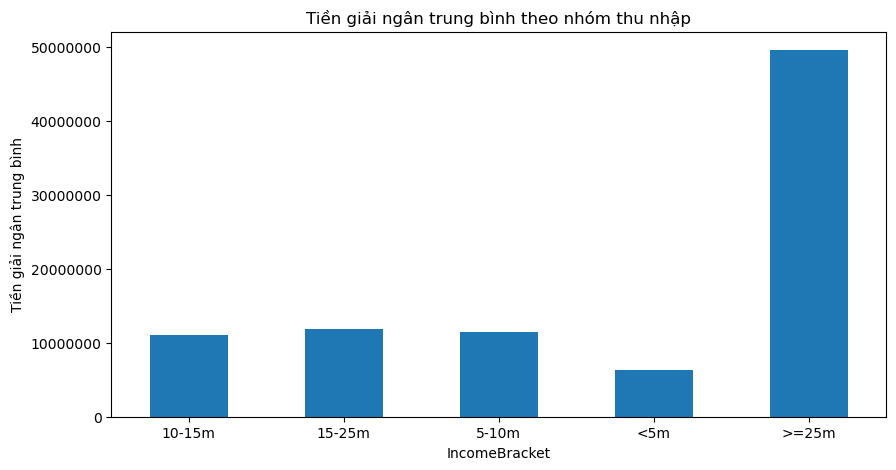

In [164]:
#Bar Chart – Tiền giải ngân trung bình theo IncomeBracket
avg_amount_by_salary = df.groupby('IncomeBracket')['Tiền giải ngân'].mean()

plt.figure(figsize=(10,5))
avg_amount_by_salary.plot(kind='bar')
plt.title("Tiền giải ngân trung bình theo nhóm thu nhập")
plt.xlabel("IncomeBracket")
plt.ylabel("Tiền giải ngân trung bình")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

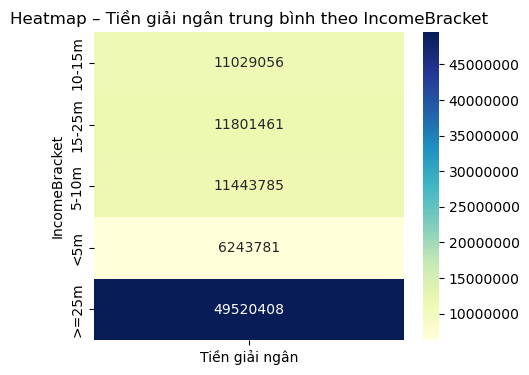

In [165]:
#Heatmap – Trung bình Tiền giải ngân theo IncomeBracket
plt.figure(figsize=(5,4))
ax=sns.heatmap(
    avg_amount_by_salary.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
cbar = ax.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')
plt.title("Heatmap – Tiền giải ngân trung bình theo IncomeBracket")
plt.show()

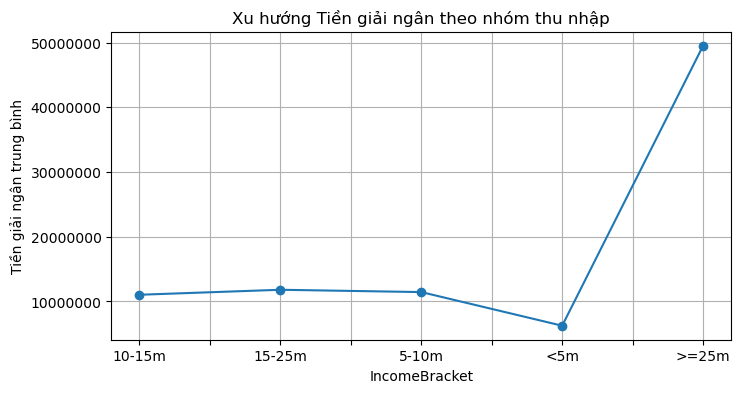

In [166]:
#Line Chart – Xu hướng hạn mức theo thu nhập
avg_amount_by_salary.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Xu hướng Tiền giải ngân theo nhóm thu nhập")
plt.xlabel("IncomeBracket")
plt.ylabel("Tiền giải ngân trung bình")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Phân tích mối quan hệ giữa thu nhập và quy mô giải ngân cho thấy một bức tranh rõ ràng hơn nhiều so với mối quan hệ giữa thu nhập và điểm tín dụng. Khác với Credit Score (phụ thuộc vào hành vi), quy mô khoản vay thực sự có liên hệ khá mạnh với thu nhập, nhưng không hoàn toàn tuyến tính và có nhiều “ngưỡng hành vi” đặc biệt cần lưu ý.

Scatter plot cho thấy phần lớn khoản vay tập trung ở mức dưới 10–15 triệu, nhưng vẫn xuất hiện những khoản vay rất lớn (50–160 triệu), chủ yếu ở phân khúc thu nhập cao hơn. Tuy nhiên, điều bất ngờ là nhóm thu nhập 5–10 triệu lại có những điểm ngoại lai rất cao, thậm chí cao hơn một số người thu nhập >=25 triệu. Điều này phản ánh rằng hạn mức giải ngân không chỉ phụ thuộc vào thu nhập mà còn phụ thuộc vào loại sản phẩm, tài sản bảo đảm, hoặc định giá nội bộ. Một khách hàng thu nhập trung bình vẫn có thể được vay lớn nếu tài sản cầm cố có giá trị cao.

Boxplot và violin plot theo SalaryGroup cho thấy một mô hình rõ rệt:

Nhóm thu nhập <5 triệu vay nhỏ nhất và phân bố rất hẹp --> hạn mức bị giới hạn do yếu tố thu nhập.

Nhóm 5–10 triệu, 10–15 triệu và 15–25 triệu vay tương đối giống nhau, trung bình khoảng 11–12 triệu --> thể hiện chính sách giải ngân khá đồng nhất cho nhóm thu nhập trung bình.

Nhóm >=25 triệu có trung bình giải ngân cao vượt trội (gần 50 triệu) và phân bố rộng hơn hẳn --> đây là nhóm duy nhất có hạn mức thực sự mở rộng theo thu nhập.

Heatmap và line chart càng củng cố xu hướng này:

4 nhóm thu nhập đầu có mức vay trung bình rất sát nhau (6–12 triệu).

Chỉ nhóm >=25 triệu “tăng bậc” lên 49–50 triệu --> cho thấy TIMA áp dụng một ngưỡng thu nhập “đặc quyền” để xét hạn mức cao.

Điều này đặt ra câu hỏi:
Nếu mức thu nhập không tăng hạn mức trong khoảng 5–25 triệu, liệu chính sách giới hạn khoản vay có đang quá ràng buộc, làm bỏ lỡ khách hàng tốt?
Nói cách khác, nhóm thu nhập trung bình – vốn là phân khúc an toàn nhất theo Credit Score – lại không được tăng hạn mức dù họ có khả năng chi trả tốt nhất.

Ngoài ra, việc xuất hiện các khoản vay rất lớn trong nhóm 5–10 triệu cho thấy chính sách giải ngân vẫn chịu ảnh hưởng mạnh từ:

- Giá trị tài sản bảo đảm (xe máy, ô tô…)

- Sản phẩm cho vay đặc thù

- Quy trình định giá tài sản theo thị trường

--> Điều này giải thích vì sao thu nhập không phải là yếu tố duy nhất quyết định hạn mức.

##**Age vs Tiền giải ngân**

1. Nhóm tuổi nào vay nhiều nhất?

2. Nhóm tuổi nào vay ít nhất?

3. Người trẻ (<25) vay ít hơn vì thu nhập thấp?

4. Người trung niên (35–55) vay nhiều hơn do nhu cầu & thu nhập cao?

5. Người lớn tuổi (>55) vay ít vì rủi ro cao?

6. Có xu hướng tuyến tính theo tuổi không?

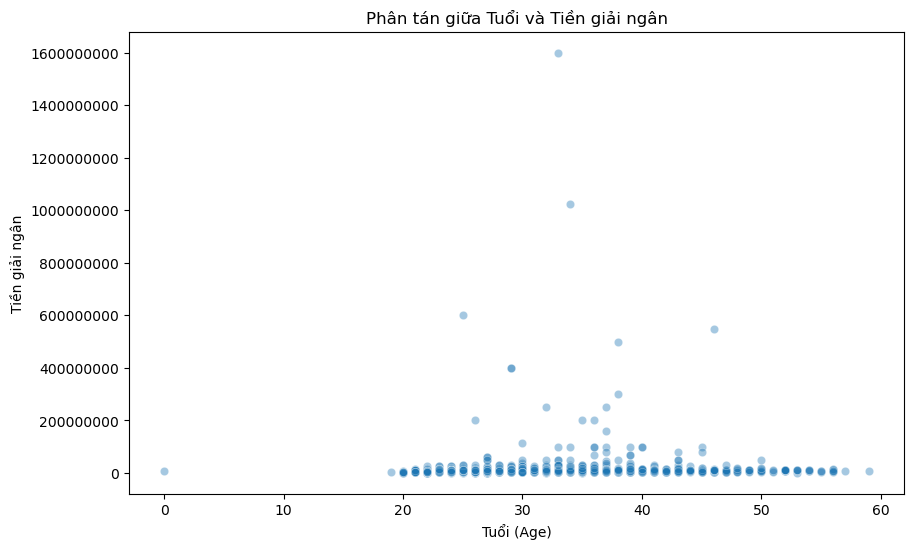

In [167]:
#Scatter Plot – Age vs Tiền giải ngân
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Tiền giải ngân',
    alpha=0.4
)
plt.title("Phân tán giữa Tuổi và Tiền giải ngân")
plt.xlabel("Tuổi (Age)")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

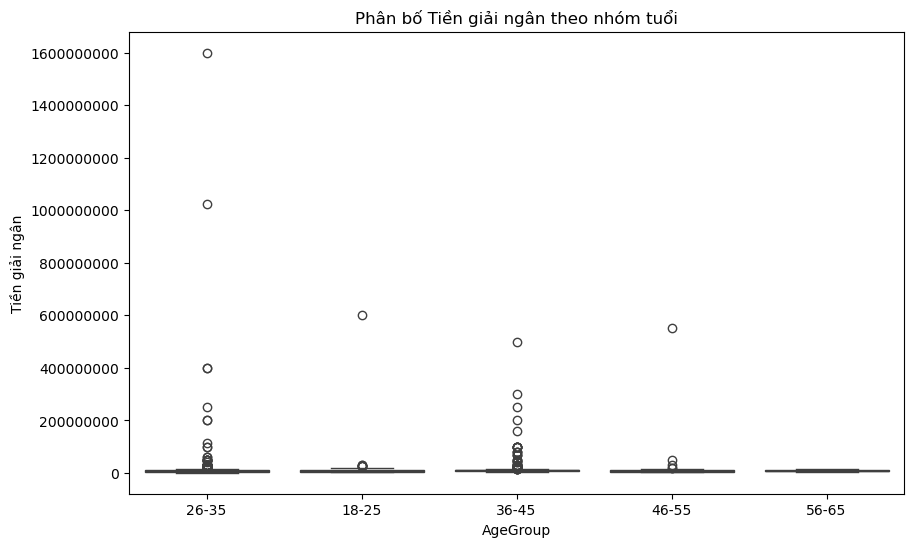

In [168]:
#Boxplot – Tiên giải ngân theo AgeGroup
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân'
)
plt.title("Phân bố Tiền giải ngân theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

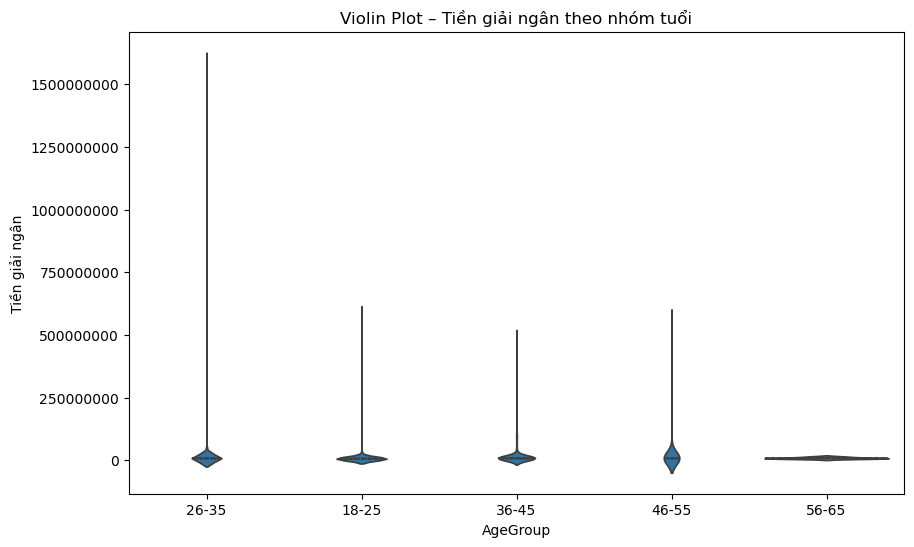

In [169]:
#Violin Plot – phân phối chi tiết của từng nhóm tuổi
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    inner='quartile'
)
plt.title("Violin Plot – Tiền giải ngân theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

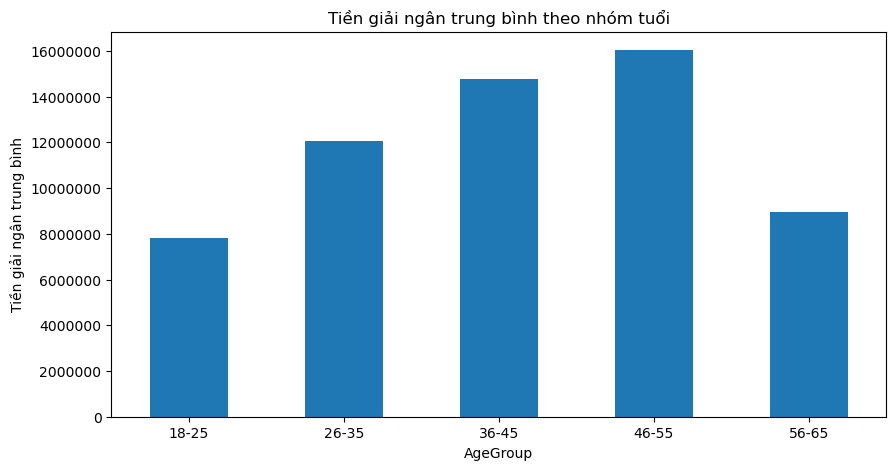

In [170]:
#Bar Chart – Tiền giải ngân trung bình theo AgeGroup
avg_amount_by_age = df.groupby('AgeGroup')['Tiền giải ngân'].mean()

plt.figure(figsize=(10,5))
avg_amount_by_age.plot(kind='bar')
plt.title("Tiền giải ngân trung bình theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân trung bình")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

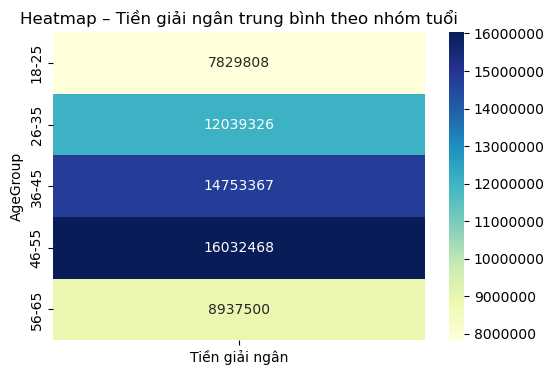

In [171]:
#Heatmap – mean Tiền giải ngân theo AgeGroup
plt.figure(figsize=(6,4))
hm = sns.heatmap(
    avg_amount_by_age.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
cbar = hm.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')
plt.title("Heatmap – Tiền giải ngân trung bình theo nhóm tuổi")
plt.show()

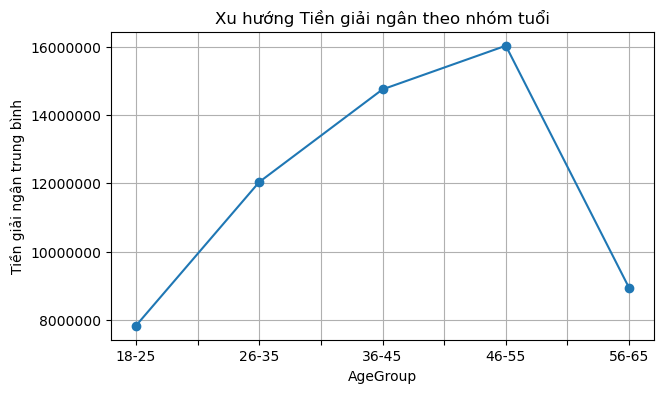

In [172]:
#Line Chart – Xu hướng hạn mức theo độ tuổi
avg_amount_by_age.plot(kind='line', marker='o', figsize=(7,4))
plt.title("Xu hướng Tiền giải ngân theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân trung bình")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Phân tích mối quan hệ giữa độ tuổi và quy mô khoản vay cho thấy một xu hướng khá rõ ràng: nhu cầu và khả năng tiếp cận tín dụng thay đổi mạnh theo chu kỳ cuộc sống, phản ánh cả năng lực tài chính lẫn hành vi vay vốn ở từng giai đoạn tuổi.

Nhìn tổng thể, scatter plot cho thấy tiền giải ngân có độ phân tán rất lớn ở mọi độ tuổi, nhưng tập trung nhiều nhất trong khoảng 25–45 tuổi, với một số khoản giải ngân vượt trội (50–160 triệu) xuất hiện ở nhóm 26–45 tuổi. Các nhóm trẻ hơn (<25 tuổi) và lớn tuổi hơn (>55 tuổi) có quy mô vay nhỏ hơn đáng kể và gần như không xuất hiện khoản vay bất thường.

Khi phân theo nhóm tuổi, pattern trở nên rất rõ ràng:

1. Nhóm trẻ (18–25 tuổi)

Là nhóm vay ít nhất cả về số lượng lẫn quy mô. Tiền giải ngân trung bình chỉ gần 7.8 triệu – thấp nhất trong tất cả các nhóm. Điều này phản ánh tình hình tài chính còn yếu, thu nhập thấp, kinh nghiệm vay hạn chế và có thể chưa đủ điều kiện để vay khoản lớn (do scoring, lịch sử tín dụng hoặc chính sách hạn mức). Dải phân bố hẹp, ít outlier --> ít người vay số lớn.

2. Nhóm 26–35 tuổi

Nhóm này có sự tăng trưởng mạnh về mức vay, trung bình đạt  gần 12 triệu. Đây là giai đoạn khách hàng bắt đầu ổn định thu nhập, nhu cầu tài chính lớn hơn (mua xe, tiêu dùng lớn, lập gia đình). Dải phân bố rộng hơn và xuất hiện nhiều khoản vay lớn (40–80 triệu). Điều này cho thấy nhóm tuổi này là phân khúc chủ lực của danh mục.

3. Nhóm 36–45 tuổi – “đỉnh nhu cầu tín dụng”

Điểm nổi bật nhất: tiền giải ngân trung bình đạt mức gần 14.7 triệu và xuất hiện nhiều khoản lớn, thậm chí vượt 100–160 triệu — cao nhất toàn danh mục. Đây là giai đoạn có thu nhập ổn định nhất, nhu cầu tiêu dùng – vay kinh doanh lớn, khả năng trả nợ mạnh. Dải phân bố vừa rộng vừa cao → nhóm vay mạnh nhất cả về quy mô lẫn độ linh hoạt.

4. Nhóm 46–55 tuổi

Mức giải ngân trung bình tiếp tục tăng lên gần 16 triệu – cao nhất trong tất cả các nhóm. Mặc dù số lượng khoản vay có thể ít hơn, nhưng mỗi khoản thường có giá trị lớn, phản ánh nhu cầu chi tiêu lớn (gia đình, đầu tư nhỏ, tài chính cá nhân) và năng lực tài chính tốt. Đây là nhóm có profile an toàn – ổn định nhưng vay lớn --> quan trọng với danh mục.

5. Nhóm >55 tuổi

Quy mô giải ngân giảm rõ rệt (trung bình gần8.9 triệu), dải phân bố thu hẹp và gần như không có khoản lớn. Điều này phù hợp với logic rủi ro: người lớn tuổi thường có thu nhập giảm, CIC khắt khe hơn, hạn mức bị giới hạn theo chính sách nội bộ và rủi ro sức khỏe – hưu trí.

#**Phân tích đa biến 3 chiều (Quy mô khoản vay)**

##**Age vs Gender vs Tiền giải ngân**

--> Phân tích mối quan hệ giữa độ tuổi – giới tính – số tiền giải ngân.

Nam hay nữ vay nhiều hơn ở từng nhóm tuổi?

Người trẻ nam vay khác người trẻ nữ thế nào?

Nhóm tuổi lớn có vay nhiều hơn không?

Có sự khác biệt theo giới tính trong hạn mức vay?

--> Về độ tuổi:

1. Tuổi nào vay cao nhất?

2. Tuổi nào vay thấp nhất?

3. Người trẻ (≤25) vay được bao nhiêu so với nhóm 30–45?

--> Về giới tính:

4. Nam vay nhiều hơn nữ hay ngược lại?

5. Sự khác biệt giới tính có mạnh không?

--> Về kết hợp tuổi + giới:

6. Nam 25–35 có vay nhiều hơn nữ 25–35 không?

7. Nhóm nữ lớn tuổi có vay thấp hơn nhóm nam cùng tuổi không?

8. Có nhóm tuổi–giới nào vay cao bất thường?

In [173]:
#Pivot Table 3 chiều – trung bình TienGiaiNgan
pivot_age_gender_amount = df.pivot_table(
    index='AgeGroup',
    columns='Gender',
    values='Tiền giải ngân',
    aggfunc='mean'
).round(0)

pivot_age_gender_amount

Gender,0.0,1.0
AgeGroup,,
18-25,8306748.0,7028351.0
26-35,12676041.0,10870410.0
36-45,16357533.0,11958084.0
46-55,21750000.0,7548387.0
56-65,10666667.0,7900000.0


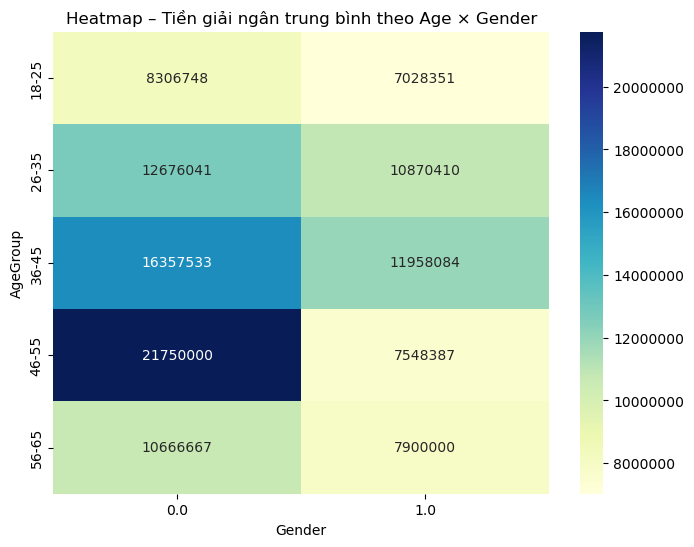

In [174]:
#Heatmap – Tiền giải ngân theo AgeGroup vs Gender
plt.figure(figsize=(8,6))
hm = sns.heatmap(
    pivot_age_gender_amount,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

cbar = hm.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')

plt.title("Heatmap – Tiền giải ngân trung bình theo Age × Gender")
plt.xlabel("Gender")
plt.ylabel("AgeGroup")

plt.show()

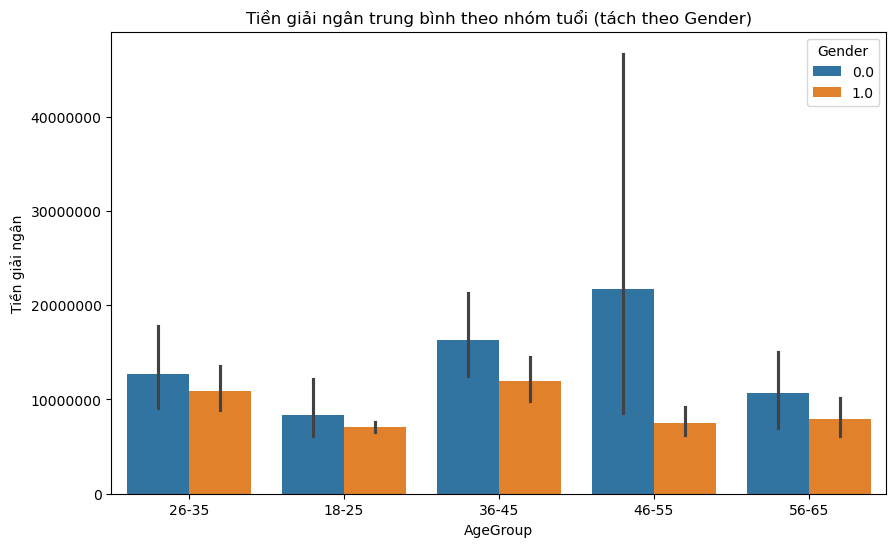

In [175]:
#Barplot – Tiền giải ngân theo độ tuổi tách theo giới
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='Gender',
    estimator='mean'
)
plt.title("Tiền giải ngân trung bình theo nhóm tuổi (tách theo Gender)")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân")
plt.legend(title="Gender")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


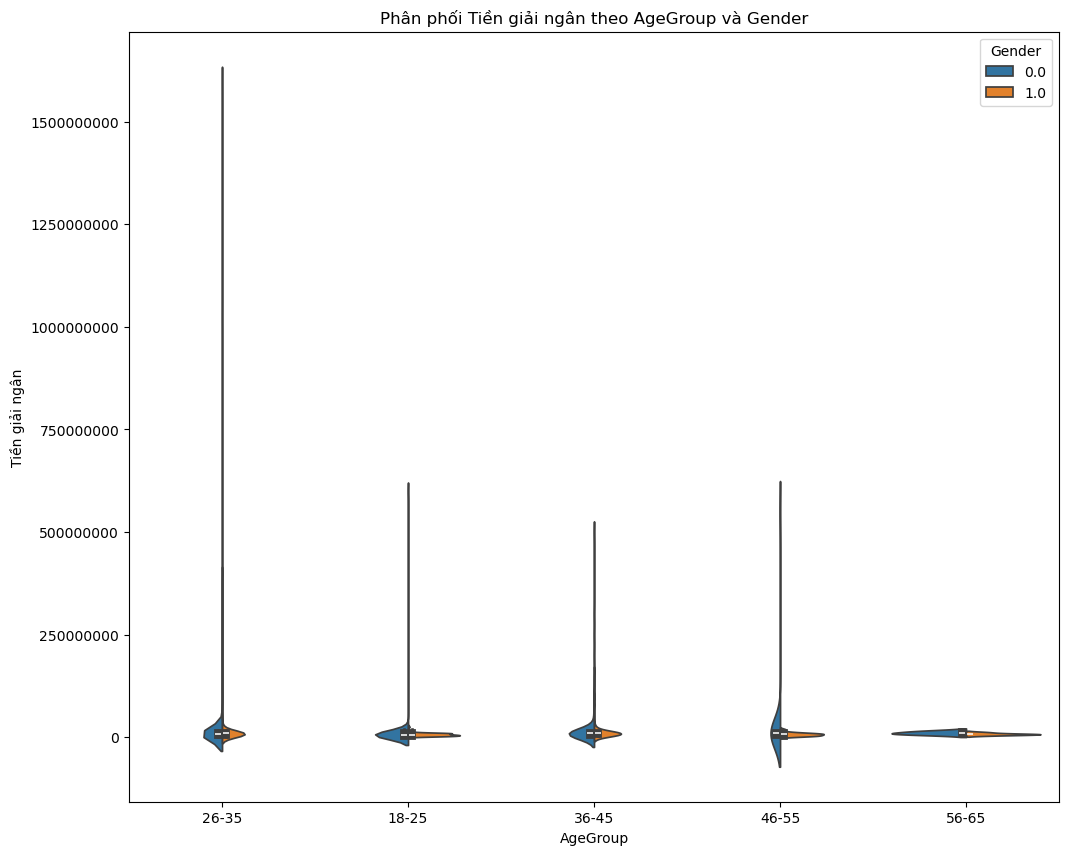

In [176]:
#Violin Plot – phân phối tiền giải ngân theo AgeGroup vs Gender
plt.figure(figsize=(12,10))
sns.violinplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='Gender',
    split=True
)
plt.title("Phân phối Tiền giải ngân theo AgeGroup và Gender")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân")
plt.legend(title="Gender")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

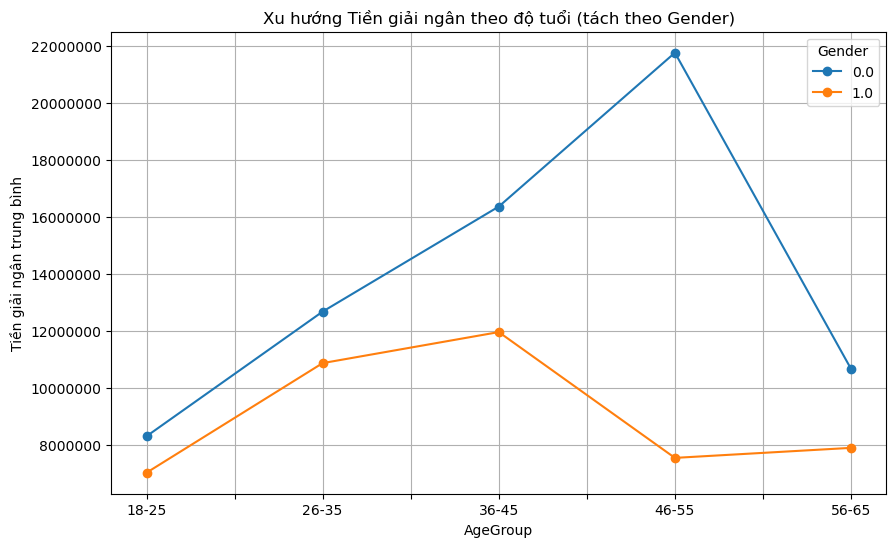

In [177]:
#Line chart – xu hướng theo tuổi nhưng chia theo Gender
pivot_age_gender_amount.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Xu hướng Tiền giải ngân theo độ tuổi (tách theo Gender)")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân trung bình")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Phân tích đồng thời ba yếu tố tuổi – giới tính – hạn mức giải ngân cho thấy hành vi vay vốn của khách hàng có sự khác biệt rõ nét theo từng giai đoạn cuộc sống, và sự khác biệt này có tương tác đáng kể với giới tính. Mức giải ngân tăng đều từ nhóm trẻ (18–25) đến trung niên (46–55), sau đó giảm mạnh ở nhóm lớn tuổi (56–65). Đây là mô hình đỉnh lệch phải điển hình trong tín dụng tiêu dùng: khách hàng bước vào độ tuổi 30–45 có thu nhập cao nhất, nhu cầu tài chính lớn nhất (mua xe, sửa nhà, chi tiêu gia đình), nên hạn mức giải ngân tăng mạnh. Nhóm 46–55 thậm chí vay cao hơn nữa (đỉnh ~21.7 triệu đối với nam) – có thể liên quan đến các nhu cầu chi tiêu đột biến trong gia đình, đầu tư hoặc hỗ trợ con cái.

Khi xét theo giới tính, sự khác biệt thể hiện rất rõ: nam giới vay nhiều hơn nữ ở tất cả các nhóm tuổi, nhưng khoảng cách mở rộng theo độ tuổi. Ở nhóm trẻ 18–25, chênh lệch khá nhỏ (8.3M vs 7.0M). Tuy nhiên, bước sang nhóm 36–45 và đặc biệt 46–55, hạn mức vay của nam tăng vượt trội so với nữ, tạo ra khoảng cách lớn nhất dataset (21.7M vs 7.5M). Điều này phù hợp với bối cảnh thị trường lao động Việt Nam: nam giới độ tuổi trung niên thường giữ vai trò trụ cột tài chính, thu nhập cao hơn, từ đó được cấp hạn mức tín dụng cao hơn. Nữ giới có hạn mức thấp hơn, nhưng ổn định và ít biến động, phù hợp với hành vi tài chính thận trọng được ghi nhận trong nhiều nghiên cứu thị trường.

Một chi tiết thú vị là nhóm lớn tuổi (56–65): hạn mức vay giảm mạnh ở cả hai giới (nam khoảng10.6M, nữ khoảng 7.9M). Không có dấu hiệu vay nhiều bất thường ở nhóm này, cho thấy quy trình thẩm định của TIMA có xu hướng kiểm soát rủi ro với nhóm tuổi cận nghỉ hưu, hợp lý vì thu nhập thường giảm và rủi ro sức khỏe, thu nhập giảm cao hơn.

Khi kết hợp tuổi + giới, có thể thấy những phân khúc vay nổi bật nhất là:

Nam 46–55: vay cao nhất toàn bộ dataset (khoảng 21.7M)

Nam 36–45: nhóm vay lớn thứ 2 (khoảng 16.3M)

Nữ 36–45: vay ổn định (khoảng 12M), thấp hơn nam nhưng đứng đầu trong nhóm nữ

Nữ 18–25: nhóm vay thấp nhất (khoảng 7M)

Nhìn chung, tuổi tác là biến quyết định mạnh nhất đến hạn mức vay, và giới tính làm tăng/giảm biên độ, chứ không thay đổi xu hướng. Đây là một mối quan hệ "song song tăng trưởng": cả nam và nữ đều tăng hạn mức theo tuổi, nhưng nam luôn nằm ở mức cao hơn.

Không có nhóm tuổi–giới nào vay “bất thường” theo nghĩa vượt ngoài quy luật thu nhập – nhu cầu – chu kỳ tài chính trong đời người. Tuy vậy, chênh lệch lớn giữa nam và nữ ở nhóm trung niên đặt ra câu hỏi: đó là do thu nhập thật sự khác biệt, hay do mô hình chấm điểm tín dụng đang “thiên vị cấu trúc” theo giới? Đây là điểm đáng kiểm chứng thêm khi phân tích khả năng tiếp cận tín dụng công bằng.

##**Salary vs Gender vs Tiền giải ngân**


--> Phân tích này trả lời:

Nam hay nữ được giải ngân nhiều hơn khi có cùng mức lương?

Nhóm thu nhập thấp/medium/high vay khác nhau thế nào giữa nam và nữ?

SalaryGroup có ảnh hưởng mạnh hơn Gender không?

Segment nào vay cao bất thường?

---

1. Nhóm thu nhập nào vay cao nhất?

2. Nam thu nhập thấp (<10M) vay thấp hơn nữ không?

3. Nhóm thu nhập trung bình (10–15M) có vay tương đương giữa nam/nữ không?

4. Nhóm thu nhập cao (25M+) nam vay nhiều hơn nữ có đúng không?

5. Giới tính có tác động mạnh hơn hay thu nhập mới là chính?

In [178]:
#Pivot – trung bình Tiền giải ngân theo SalaryGroup × Gender
pivot_salary_gender_amount = df.pivot_table(
    index='IncomeBracket',
    columns='Gender',
    values='Tiền giải ngân',
    aggfunc='mean'
).round(0)

pivot_salary_gender_amount

Gender,0.0,1.0
IncomeBracket,,
10-15m,11781690.0,9372093.0
15-25m,11302289.0,12681818.0
5-10m,13288777.0,8217972.0
<5m,6100917.0,6413043.0
>=25m,32388889.0,70545455.0


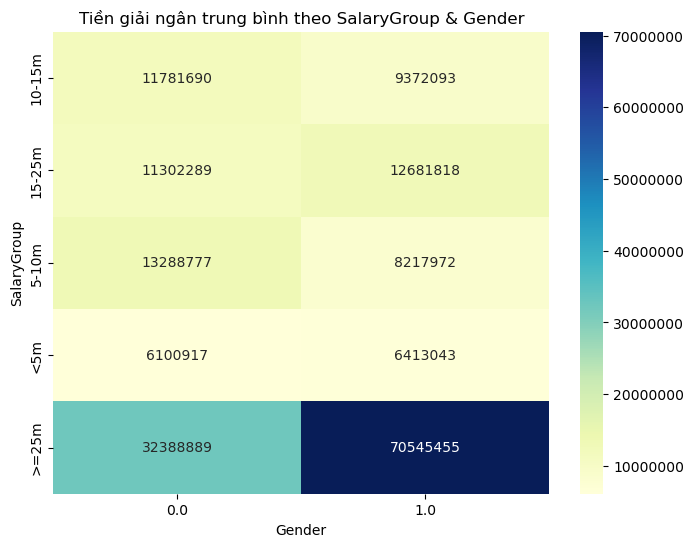

In [179]:
#Heatmap – Tiền giải ngân theo SalaryGroup vs Gender
plt.figure(figsize=(8,6))
hm=sns.heatmap(
    pivot_salary_gender_amount,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
cbar = hm.collections[0].colorbar
cbar.ax.ticklabel_format(style='plain')
plt.title("Tiền giải ngân trung bình theo SalaryGroup & Gender")
plt.xlabel("Gender")
plt.ylabel("SalaryGroup")
plt.show()

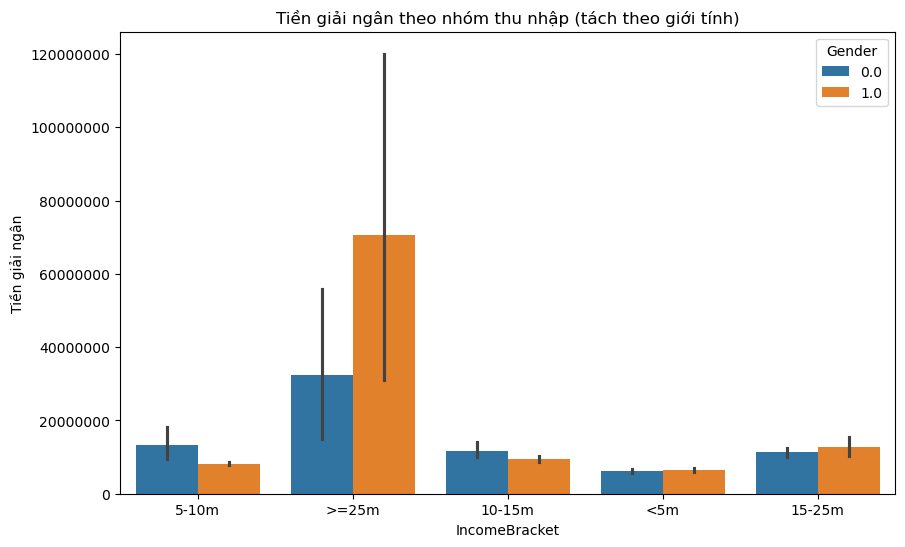

In [180]:
#Barplot – theo SalaryGroup, tách theo Gender
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân',
    hue='Gender',
    estimator='mean'
)
plt.title("Tiền giải ngân theo nhóm thu nhập (tách theo giới tính)")
plt.xlabel("IncomeBracket")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

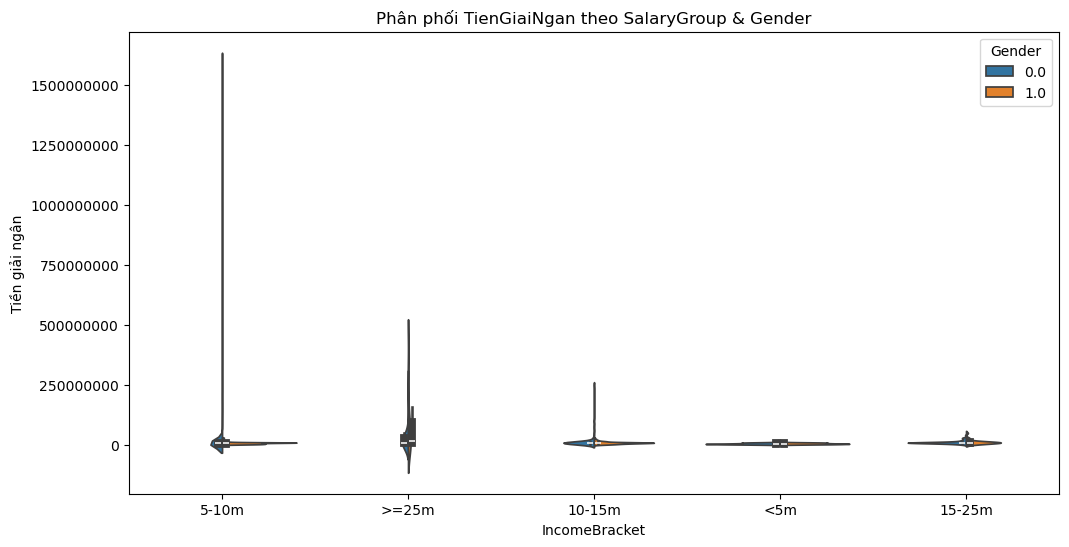

In [181]:
#Violin Plot – theo SalaryGroup vs Gender
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df,
    x='IncomeBracket',
    y='Tiền giải ngân',
    hue='Gender',
    split=True
)
plt.title("Phân phối TienGiaiNgan theo SalaryGroup & Gender")
plt.xlabel("IncomeBracket")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

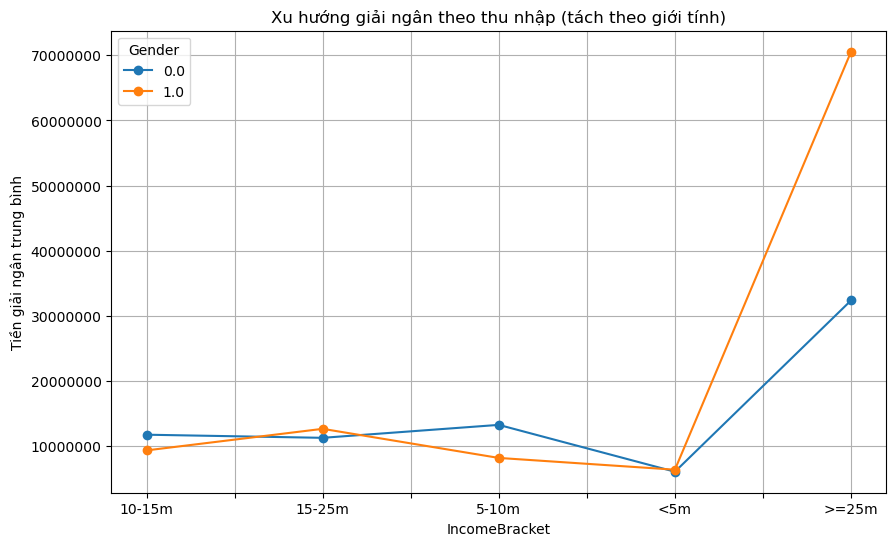

In [182]:
#Line chart – xu hướng hạn mức theo IncomeBracket vs Gender
pivot_salary_gender_amount.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Xu hướng giải ngân theo thu nhập (tách theo giới tính)")
plt.xlabel("IncomeBracket")
plt.ylabel("Tiền giải ngân trung bình")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Mối quan hệ giữa thu nhập – giới tính – quy mô giải ngân cho thấy một bức tranh thú vị: thu nhập vẫn là yếu tố chi phối chính, nhưng giới tính tạo ra những khác biệt đáng kể trong từng phân khúc. Phân tích theo SalaryGroup kết hợp Gender cho thấy xu hướng rất rõ ràng: nam vay nhiều hơn nữ ở hầu hết các mức thu nhập, nhưng không phải phân nhóm nào sự chênh lệch cũng giống nhau — có nơi gần như bằng nhau, có nơi lại chênh lệch mạnh.

Ở nhóm thu nhập thấp (<5M), mức giải ngân thấp nhất như kỳ vọng, và chênh lệch giữa nam và nữ gần như không đáng kể (6.1M vs 6.4M). Điều này phản ánh việc nhóm thu nhập thấp thường chỉ tiếp cận hạn mức nhỏ, không có khác biệt lớn theo giới. Cả nam và nữ trong phân khúc này có hành vi vay tương đối giống nhau và phụ thuộc chặt vào khả năng tài chính hơn là đặc điểm nhân khẩu.

Ở nhóm thu nhập trung bình thấp (5–10M), nam bắt đầu vay cao hơn nữ khá rõ (13.3M vs 8.2M). Đây là phân khúc có chênh lệch mạnh nhất trong nhóm trung bình, cho thấy rằng nam có nhu cầu vay lớn hơn hoặc mô hình thẩm định cho phép nam vay mức cao hơn do đặc điểm nghề nghiệp/ổn định tài chính khác biệt. Việc khoảng cách tăng ở mức lương thấp nhưng lại giảm dần ở mức lương cao hơn là tín hiệu đáng chú ý: sự khác biệt giới tính không tuyến tính theo mức lương.

Đến nhóm 10–15M và 15–25M, mức vay giữa nam và nữ trở nên tương đồng hơn (nam 11.7M – nữ 9.3M, và nam 11.3M – nữ 12.6M). Đây là vùng thu nhập ổn định nhất của toàn dataset, và cũng là nơi giới tính gây ảnh hưởng yếu nhất. Đặc biệt trong phân khúc 15–25M, nữ thậm chí được giải ngân cao hơn nam. Điều này có thể phản ánh rằng ở nhóm có hồ sơ thu nhập ổn định, nữ giới được đánh giá hành vi tín dụng tốt hơn (tỉ lệ CIC sạch hơn, thanh toán đều hơn), dẫn đến hạn mức giải ngân có thể nhỉnh hơn nam.

Tuy nhiên, sự phân cực xảy ra mạnh nhất ở phân khúc >=25M: nữ được giải ngân trung bình tới hơn 70M, cao hơn gấp đôi nam (khoảng 32M). Đây là khác biệt lớn nhất toàn bộ phân tích và không xuất hiện ở bất kỳ phân khúc nào khác. Điều này gợi ý rằng:

Nữ thu nhập cao có hồ sơ tài chính – hành vi tốt hơn nam thu nhập cao.

Nữ có xu hướng vay những khoản lớn hơn (hoặc những khoản phục vụ tiêu dùng có giá trị cao hơn).

Hoặc mô hình rủi ro nội bộ ưu tiên hạn mức cao hơn cho nữ trong phân khúc thu nhập cao.

Ở chiều ngược lại, nam thu nhập cao được vay ít hơn nữ trong cùng phân khúc — trái ngược với xu hướng ở nhóm thu nhập thấp và trung bình thấp. Như vậy, tác động của giới tính thay đổi chiều theo mức thu nhập: nam chiếm ưu thế vay lớn ở mức lương thấp – trung bình thấp, nhưng nữ vượt trội mạnh ở mức thu nhập cao.


=> Thu nhập vẫn là yếu tố mạnh nhất quyết định hạn mức vay, giới tính chỉ là yếu tố điều chỉnh trong từng phân khúc.

##**Salary vs Age vs Tiền giải ngân**


1. Nhóm tuổi nào vay cao nhất ở mỗi mức thu nhập?

2. Người trẻ thu nhập thấp vay thấp hơn người lớn tuổi cùng thu nhập?

3. Nhóm tuổi trung niên (36–45) có vay cao hơn nhóm trẻ?

5. Nhóm >65 tuổi có vay thấp hơn cùng SalaryGroup?

6. Có SalaryGroup nào mà tuổi không tạo khác biệt?

7. Có segment bất thường (ví dụ: tuổi cao lương thấp mà vay cực cao)?

In [183]:
#Pivot Table – Trung bình tiền giải ngân theo AgeGroup vs IncomeBracket
pivot_age_salary_amount = df.pivot_table(
    index='AgeGroup',
    columns='IncomeBracket',
    values='Tiền giải ngân',
    aggfunc='mean'
).round(0)

pivot_age_salary_amount

IncomeBracket,10-15m,15-25m,5-10m,<5m,>=25m
AgeGroup,,,,,
18-25,9531915.0,11318182.0,7915816.0,5574627.0,7500000.0
26-35,9476695.0,12332000.0,11927515.0,6508547.0,63038462.0
36-45,15185841.0,11162448.0,13927638.0,7062500.0,43705882.0
46-55,9088235.0,13142857.0,19280000.0,7000000.0,8500000.0
56-65,NaN,5000000.0,9500000.0,NaN,NaN


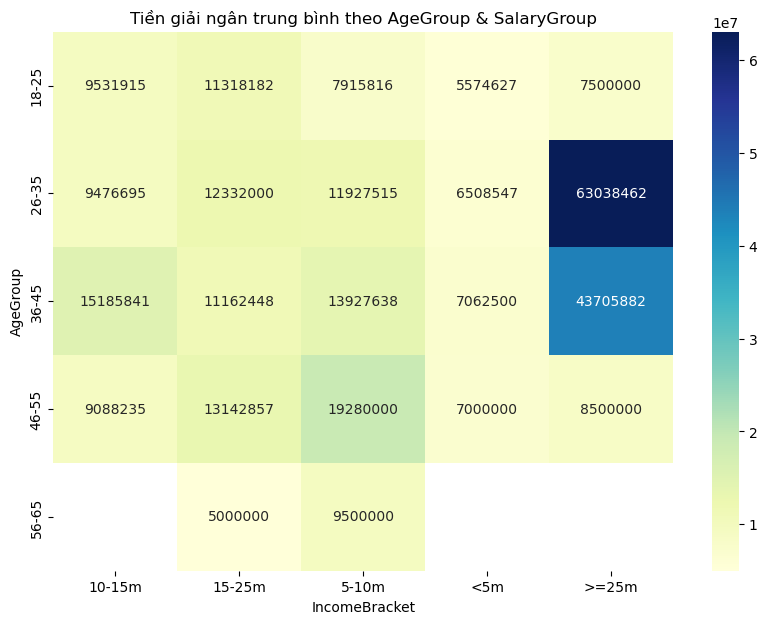

In [184]:
#Heatmap – TienGiaiNgan theo AgeGroup vs IncomeBracket
plt.figure(figsize=(10,7))
sns.heatmap(
    pivot_age_salary_amount,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Tiền giải ngân trung bình theo AgeGroup & SalaryGroup")
plt.xlabel("IncomeBracket")
plt.ylabel("AgeGroup")
plt.show()

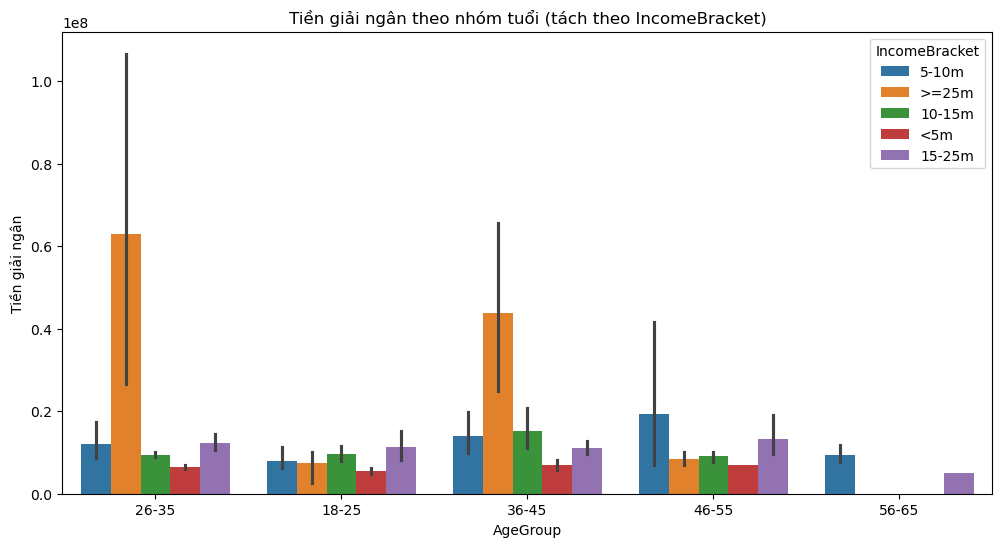

In [185]:
#Barplot – AgeGroup tách theo IncomeBraket
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='IncomeBracket',
    estimator='mean'
)
plt.title("Tiền giải ngân theo nhóm tuổi (tách theo IncomeBracket)")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân")
plt.show()

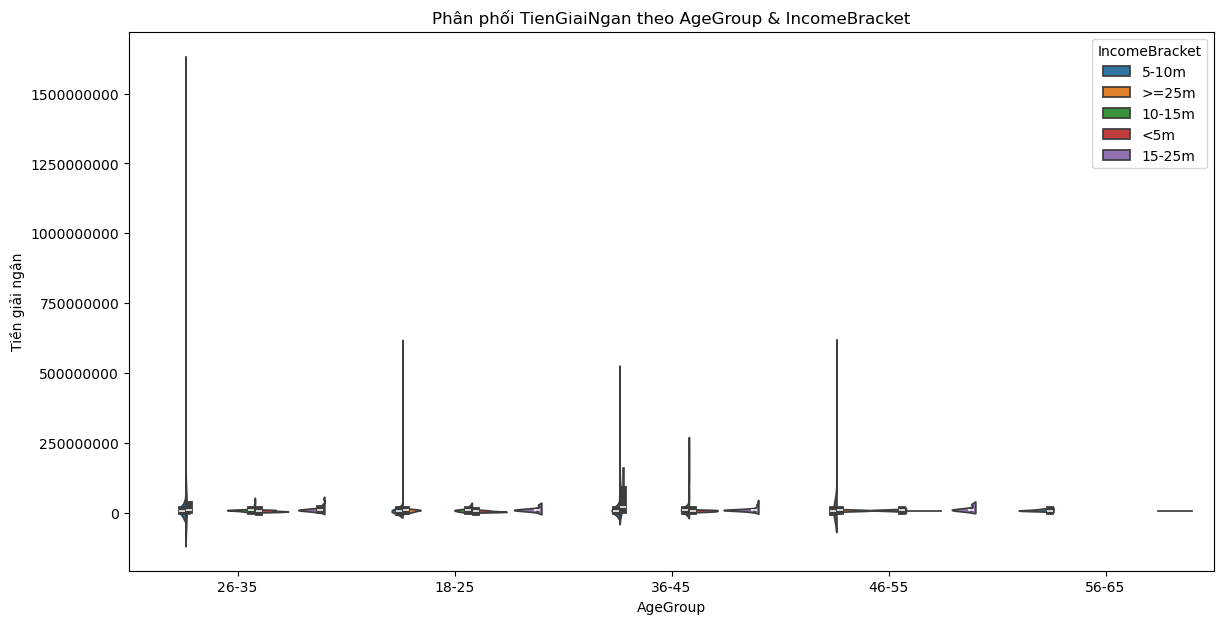

In [186]:
#Violin plot – phân phối theo Age × Salary
plt.figure(figsize=(14,7))
sns.violinplot(
    data=df,
    x='AgeGroup',
    y='Tiền giải ngân',
    hue='IncomeBracket',
    split=True
)
plt.title("Phân phối TienGiaiNgan theo AgeGroup & IncomeBracket")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

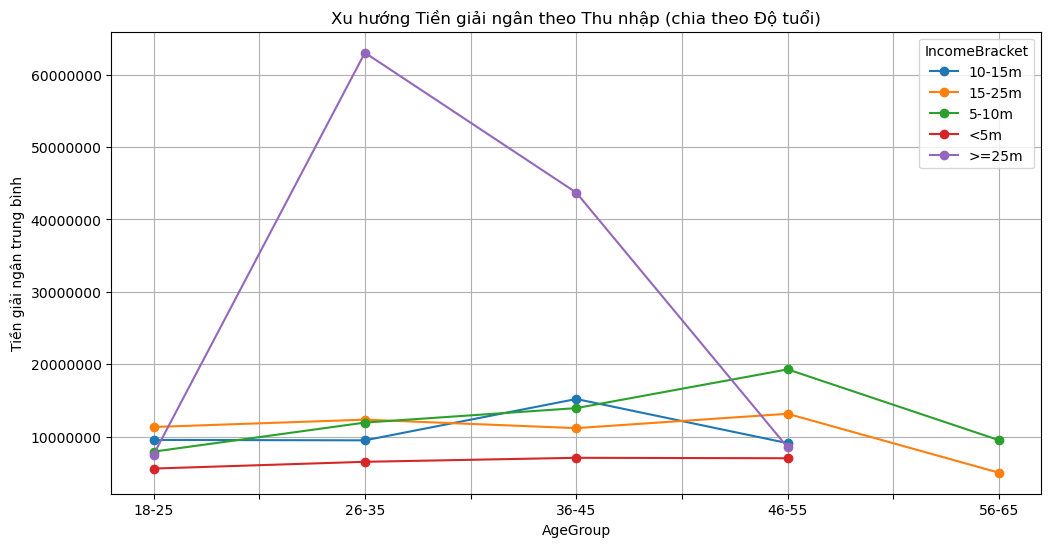

In [187]:
#Line chart – xu hướng theo IncomeBracket (chia theo AgeGroup)
pivot_age_salary_amount.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Xu hướng Tiền giải ngân theo Thu nhập (chia theo Độ tuổi)")
plt.xlabel("AgeGroup")
plt.ylabel("Tiền giải ngân trung bình")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**Insight**

Khi phân tích đồng thời thu nhập và độ tuổi, một mô hình tiêu dùng tín dụng khá rõ ràng xuất hiện. Ở mọi nhóm thu nhập, người trung niên (26–45) luôn là nhóm có khoản vay lớn nhất. Điều này phản ánh đúng hành vi tài chính phổ biến: đây là giai đoạn mà nhu cầu tiêu dùng – đầu tư – mua sắm – xây dựng gia đình – mua nhà – mua xe – kinh doanh đạt đỉnh, và thu nhập cũng đã ổn định hơn so với nhóm trẻ.

Trong khi đó, người trẻ (18–25) thường vay thấp hơn trong cùng mức thu nhập. Mặc dù một số người trẻ thu nhập khá (10–15M hoặc 15–25M) vẫn vay ở mức tương đối, nhưng nhìn chung họ bị hạn chế bởi hai yếu tố: (1) lịch sử tín dụng mỏng và (2) chưa chứng minh được sự ổn định thu nhập lâu dài.

Ngược lại, nhóm lớn tuổi hơn (46–55) vẫn duy trì mức vay cao, đặc biệt trong nhóm thu nhập thấp–trung bình, nhưng bắt đầu giảm ở nhóm thu nhập cao. Điều này có thể phản ánh việc họ thận trọng hơn với các khoản nợ dài hạn hoặc đã hoàn tất phần lớn các nhu cầu tài chính lớn. Đến nhóm 56–65, hạn mức vay giảm hẳn ở hầu hết các SalaryGroup, do rủi ro tín dụng tăng, sức khoẻ tài chính giảm và thời gian tạo thu nhập ngắn hơn.

Điểm đáng chú ý nhất là biến IncomeBracket có tác động mạnh hơn biến AgeGroup: dù ở tuổi nào, người thuộc nhóm thu nhập cao luôn vay nhiều hơn đáng kể. Tác động của độ tuổi chỉ tạo ra sự khác biệt trong nội bộ cùng mức thu nhập, chứ không tạo ra sự đảo chiều hoàn toàn.

(1) Nhóm tuổi nào vay cao nhất ở mỗi mức thu nhập?

Quan sát heatmap và pivot cho thấy:

Thu nhập <5M → nhóm 46–55 vay cao nhất (khoảng 7M).

5–10M --> nhóm 46–55 vay cao nhất (khoảng 19M).

10–15M --> nhóm 36–45 vay cao nhất (khoảng 15M).

15–25M --> nhóm 36–45 và 46–55 ngang nhau (khoảng 13–14M).

=> 25M --> nhóm 26–35 vay cao nhất (khoảng 63M).

--> Kết luận:
Không có nhóm tuổi chiếm toàn cục, mà phụ thuộc vào mức thu nhập.
Tuy nhiên, 26–45 thường chiếm vị trí cao nhất.

(2) Người trẻ thu nhập thấp vay ít hơn người lớn tuổi cùng thu nhập?

--> Đúng.

Nhóm 18–25 luôn vay thấp nhất trong mọi IncomeBracket, trừ khi mẫu rất ít (>=25M ở nhóm 56–65).

Giải thích:

Lịch sử tín dụng ngắn

Nguy cơ biến động nghề nghiệp

Thiếu tài sản thế chấp

Chưa có các chi tiêu lớn (nhà, xe, con cái)

(3) Nhóm trung niên (36–45) có vay cao hơn nhóm trẻ?

--> Rất rõ.

Ở mọi mức thu nhập từ 10–25M và 5–10M, nhóm 36–45 đều vượt trội.

Đây là nhóm đang ở nhu cầu tài chính cao: mua nhà, mở rộng kinh doanh, chăm sóc gia đình.

(4) Nhóm >55 có vay thấp hơn trong cùng SalaryGroup?

--> Đúng, ngoại trừ thu nhập cao bị thiếu dữ liệu.

Nhóm 56–65 vay thấp nhất trong hầu hết IncomeBracket vì:

rủi ro tín dụng cao hơn

thời gian trả nợ ngắn

hạn mức bị giảm bởi chính sách rủi ro của tổ chức

nhu cầu tiêu dùng lớn giảm

(5) Có SalaryGroup nào mà tuổi không tạo khác biệt?

--> Có: nhóm <5M.

Ở mức thu nhập thấp, giới hạn tài chính khiến mức vay giữa các nhóm tuổi khá gần nhau (5.5–7M).
=> Thu nhập đóng vai trò giới hạn chính, chứ không phải tuổi.

(6) Có segment bất thường? (ví dụ: tuổi cao – lương thấp mà vay rất cao)

Một số điểm bất thường:

Nhóm 46–55 / 5–10M có khoản vay trung bình khoảng 19M, vượt xa các nhóm khác --> có thể là nhóm vay mua nhà/kinh doanh.

Nhóm 26–35 / >=25M có khoản vay rất cao (khoảng 63M), cực kỳ nổi bật.

Nhóm 36–45 / >=25M lại thấp hơn (khoảng 43M) --> có thể do bias số lượng hoặc chính sách nội bộ.

#**Insight tổng hợp và phân tích Chẩn đoán các Yếu tố ảnh hưởng đến Quy mô Khoản vay (Loan Size Driver Analysis)**


##**INSIGHT TỔNG HỢP**



Nhìn toàn bộ bức tranh, quy mô khoản vay của khách hàng không bị quyết định bởi một yếu tố đơn lẻ, mà là kết quả của việc kết hợp giữa thu nhập – nghề nghiệp – độ tuổi – giới tính và một phần là chính sách nội bộ về hạn mức.

Trước hết, nghề nghiệp tạo ra sự phân tầng rất rõ ràng. Những nhóm nghề ổn định, có vị thế pháp lý rõ ràng như “Các hình thức tự kinh doanh khác”, “Nhân viên tổ chức nhà nước”, “Nhân viên chính thức” hay “Công nhân” được giải ngân trung bình từ khoảng 8–21 triệu, cao hơn hẳn so với các nhóm nghề thu nhập biến động như “Nhân viên không HĐLĐ”, “Kinh doanh tại nhà không đăng ký” hay “Tài xế”, vốn chỉ vay quanh 4–8 triệu. Nói cách khác, nghề càng ổn định thì hạn mức vay càng cao, và đây là một trong những driver quan trọng nhất của Loan Size.

Thu nhập (Salary) là yếu tố cần: khách thu nhập thấp (<5M) hầu như chỉ được vay nhỏ, phân bố hẹp. Nhóm thu nhập từ 5–25M tuy có thu nhập tăng dần nhưng mức vay trung bình lại khá tương đương (khoảng 11–12M), cho thấy chính sách hạn mức khá phẳng đối với phân khúc thu nhập trung bình. Chỉ khi bước sang nhóm thu nhập cao (>=25M), khoản vay mới “nhảy bậc” lên khoảng 50M, với biên độ dao động lớn. Điều này cho thấy tổ chức đang áp dụng một “ngưỡng thu nhập đặc quyền” để mở rộng hạn mức, trong khi phần lớn khách hàng thu nhập trung bình – dù an toàn – vẫn vay trong một dải khá giống nhau. Một số outlier đặc biệt lớn ở nhóm 5–10M gợi ý rằng tài sản bảo đảm hoặc loại sản phẩm vay cũng ảnh hưởng mạnh tới hạn mức, chứ không chỉ thu nhập danh nghĩa.

Độ tuổi lại phản ánh chu kỳ nhu cầu tín dụng trong đời người. Nhóm trẻ 18–25 vay thấp nhất, ít outlier, chủ yếu do thu nhập yếu và lịch sử tín dụng mỏng. Khi bước sang 26–35 và 36–45, khoản vay tăng nhanh cả về trung bình lẫn biên độ – đây là giai đoạn khách hàng xây dựng gia đình, mua nhà, xe, mở rộng kinh doanh. Nhóm 46–55 còn vay trung bình cao nhất, nhưng số lượng khoản vay có thể ít hơn; sau 55 tuổi, hạn mức giảm rõ rệt vì rủi ro thu nhập và sức khỏe. Khi kết hợp với giới tính, có thể thấy nam và nữ đều tăng hạn mức theo tuổi, nhưng nam thường vay nhiều hơn ở các nhóm 26–55, đặc biệt là nam 46–55 – phân khúc vay cao nhất. Tuy vậy, giới tính không đảo chiều xu hướng, mà chỉ làm “tăng hoặc giảm” biên độ quanh đường xu hướng theo tuổi.

Khi đưa Gender vào cùng Salary, bức tranh chi tiết hơn: ở thu nhập thấp và trung bình thấp, nam vay nhiều hơn nữ; nhưng ở vùng thu nhập ổn định (10–25M), nam và nữ gần như ngang nhau, thậm chí nữ 15–25M còn vay nhỉnh hơn. Đặc biệt, ở nhóm thu nhập rất cao (>=25M), nữ lại được giải ngân trung bình hơn 70M – cao gấp đôi nam. Điều này cho thấy giới tính không phải driver chính, nhưng có tác dụng điều chỉnh hạn mức khác nhau ở từng phân khúc thu nhập: nam chiếm ưu thế ở phân khúc thấp, nữ lại nổi trội ở phân khúc thu nhập rất cao – có thể do khác biệt về hồ sơ tài chính, sản phẩm vay hoặc chính sách nội bộ.

Cuối cùng, phân tích Salary vs Age chỉ ra rằng thu nhập vẫn là driver lớn nhất, còn tuổi đóng vai trò “phân bố lại” hạn mức bên trong từng nhóm thu nhập. Ở bất kỳ SalaryGroup nào, người trung niên (26–45, đôi khi đến 46–55) luôn là nhóm vay nhiều nhất; người trẻ vay ít hơn, người trên 55 tuổi bị thu hẹp hạn mức. Một số segment đáng chú ý là 46–55 / 5–10M với khoản vay trung bình ~19M (rất cao so với thu nhập) và 26–35 / >=25M với khoản vay ~63M. Đây là những nhóm cần được giám sát thêm vì vừa vay nhiều vừa nằm trong vùng thu nhập/tuổi dễ phát sinh rủi ro nếu có cú sốc tài chính.

Tóm lại, Loan Size là kết quả của sự kết hợp giữa năng lực tài chính (Salary), độ ổn định nghề nghiệp (JobName), chu kỳ cuộc sống (Age) và một phần tác động của Gender, trên nền chính sách hạn mức nội bộ và đặc điểm sản phẩm vay.

##**PHÂN TÍCH GIẢ THUYẾT**

***Giả thuyết 3a – “Khách hàng có năng lực tài chính tốt hơn sẽ vay được nhiều hơn.”***

Dữ liệu ủng hộ giả thuyết này một cách có điều kiện. Nhìn chung, khi thu nhập tăng từ nhóm <5M lên 5–10M và 10–25M, khối lượng vay không tăng tuyến tính mà nằm trong một dải khá ổn định (khoảng 11–12M). Chỉ khi bước vào nhóm >=25M, hạn mức vay mới nhảy vọt lên khoảng 50M. Điều đó cho thấy thu nhập tốt hơn là điều kiện cần để tiếp cận hạn mức cao, nhưng chỉ được “bật” lên khi vượt một ngưỡng nhất định (>=25M). Ở khu vực thu nhập trung bình, thu nhập tăng thêm không kéo hạn mức lên tương ứng, có thể do chính sách giới hạn khoản vay hoặc do các yếu tố khác (tài sản bảo đảm, sản phẩm, lịch sử tín dụng) được ưu tiên hơn.

***Giả thuyết 3b – “Đặc điểm nhân khẩu học (Age, Gender) có ảnh hưởng đến nhu cầu vay.”***

Giả thuyết này được xác nhận khá rõ ràng. Độ tuổi có tác động rất mạnh: khoản vay tăng dần từ 18–25 lên đỉnh ở 46–55, sau đó giảm ở 56–65. Điều này phù hợp với logic nhu cầu và khả năng tài chính theo chu kỳ cuộc sống. Giới tính cũng tạo ra khác biệt: nam thường vay nhiều hơn nữ ở các nhóm tuổi 26–55, còn nữ xuất hiện nổi bật ở nhóm thu nhập rất cao (>=25M). Tuy nhiên, Gender không đảo ngược xu hướng theo tuổi, mà chủ yếu làm thay đổi mức độ (nam/nữ cao hơn chút ít). Vì vậy, Age là driver nhân khẩu học chính, Gender là yếu tố điều chỉnh trong từng phân khúc.

***Giả thuyết 3c – “Nghề nghiệp ổn định (JobName) sẽ vay được nhiều hơn.”***

Dữ liệu rất ủng hộ giả thuyết này. Các nhóm nghề như Nhân viên tổ chức nhà nước, Nhân viên chính thức, Công nhân và Các hình thức tự kinh doanh khác có mức vay trung bình từ 8 đến trên 20M, cao hơn rõ rệ so với Nhân viên không HĐLĐ, Tài xế, Kinh doanh tại nhà không đăng ký, vốn chỉ quanh 4–8M. Điều đó cho thấy JobName là một driver mạnh của Loan Size, phản ánh cách tổ chức sử dụng nghề nghiệp như một proxy cho sự ổn định thu nhập và tính tin cậy. Những nghề ổn định không chỉ rủi ro thấp hơn về mặt hành vi mà còn được “thưởng” hạn mức cao hơn.

***Giả thuyết 3d – “Nam và nữ cùng nhóm thu nhập thì nam sẽ vay nhiều hơn.”***

Giả thuyết này chỉ đúng một phần. Ở nhóm thu nhập thấp và trung bình thấp (5–10M), nam vay nhiều hơn nữ khá rõ. Nhưng ở nhóm 10–15M, khoảng cách giảm; nhóm 15–25M thì nữ thậm chí còn vay nhỉnh hơn nam; và ở nhóm >=25M, nữ lại được giải ngân cao hơn rất nhiều so với nam (khoảng >70M so với 32M). Như vậy, giới tính và thu nhập tương tác với nhau phức tạp hơn giả thuyết ban đầu: nam có xu hướng vay nhiều hơn ở phân khúc thấp, trong khi nữ lại nổi trội ở phân khúc thu nhập rất cao. Điều này có thể liên quan đến khác biệt về nghề nghiệp, tài sản bảo đảm hoặc chính sách ưu tiên đối với những hồ sơ nữ thu nhập cao.

***Giả thuyết 3e – “Cùng số lương nhưng người trung niên, đang trong giai đoạn phát triển sự nghiệp sẽ vay nhiều hơn.”***

Giả thuyết này được dữ liệu ủng hộ mạnh. Khi nhìn vào ma trận Age × Salary, ở từng IncomeBracket, nhóm 26–45 (và kéo dài tới 46–55) thường có mức vay trung bình cao hơn nhóm 18–25 và cao hơn hoặc tương đương nhóm >55. Điều này cho thấy tuổi tác làm thay đổi mức vay bên trong từng nhóm thu nhập: cùng một mức lương 5–10M, khách 36–45 hoặc 46–55 vay nhiều hơn đáng kể so với khách 18–25; tương tự, ở 10–15M hay 15–25M, nhóm trung niên luôn đứng đầu. Lý do hợp lý: họ có nhu cầu tài chính lớn hơn (gia đình, nhà cửa, kinh doanh) và hồ sơ tín dụng đã đủ dày để hệ thống tin tưởng cấp hạn mức cao hơn.

Tổng hợp lại, các giả thuyết cho thấy:

Salary đúng là driver quan trọng, nhưng hiệu ứng không tuyến tính và phụ thuộc ngưỡng.

Age phản ánh chu kỳ nhu cầu và khả năng vay, là driver nhân khẩu học chính.

JobName là proxy mạnh cho mức độ ổn định tài chính, tác động trực tiếp đến hạn mức.

Gender có tác động nhưng phức tạp hơn dự đoán, thay đổi chiều theo từng phân khúc thu nhập.

Sự kết hợp Salary vs Age vs JobName vs Gender mới giải thích đầy đủ tại sao hai người có thu nhập tương đương lại được vay mức rất khác nhau.

##**KẾT LUẬN – Những yếu tố liên quan mạnh nhất đến Quy mô Khoản vay**


Từ toàn bộ phân tích, có thể rút ra các Loan Size Drivers chính như sau:

***Năng lực tài chính (Salary / IncomeBracket)***

Là driver nền tảng, quyết định trần hạn mức mà khách hàng có thể tiếp cận.

Tác động mạnh nhất ở ngưỡng >=25M, nơi hạn mức nhảy vọt lên khoảng 50–70M.

Ở vùng thu nhập trung bình (5–25M), hạn mức tăng chậm hơn, phản ánh giới hạn do chính sách.

***Độ ổn định nghề nghiệp (JobName)***

Nghề nghiệp chính thức, có hợp đồng, thuộc khu vực nhà nước hoặc kinh doanh bài bản --> được vay nhiều hơn.

Nghề tự do, không HĐLĐ, thời vụ --> bị giới hạn hạn mức, vay nhỏ và phân bố hẹp.

Đây là một trong những yếu tố giải thích rõ nhất sự chênh lệch Loan Size giữa những khách hàng có mức thu nhập gần giống nhau.

***Độ tuổi (Age, AgeGroup)***

Nhu cầu và khả năng vay tăng từ 18–25 đến đỉnh 36–55, rồi giảm ở 56–65.

Trong cùng một SalaryGroup, người trung niên (26–45/55) vay nhiều hơn rõ rệt so với người trẻ và người lớn tuổi, vì vừa có nhu cầu lớn vừa có lịch sử tài chính đủ mạnh.

***Giới tính (Gender) – Yếu tố điều chỉnh, không phải yếu tố quyết định***

Nam vay nhiều hơn ở phân khúc thu nhập thấp – trung bình thấp.

Nữ chiếm ưu thế ở phân khúc thu nhập rất cao (>=25M).

Gender không thay đổi cấu trúc tổng thể (thu nhập cao – tuổi trung niên – nghề ổn định vẫn là nhóm vay lớn nhất), nhưng ảnh hưởng đến chênh lệch trong từng phân khúc.

***Yếu tố sản phẩm và tài sản bảo đảm***

Việc xuất hiện những khoản vay rất lớn ở nhóm thu nhập 5–10M cho thấy Loan Size còn phụ thuộc vào giá trị tài sản bảo đảm và loại sản phẩm vay.

#**Financial Behavior (Hành vi vay)**

##**ProductCreditName vs Salary**

1. Sản phẩm nào chủ yếu dành cho nhóm thu nhập thấp?

2. Sản phẩm nào chủ yếu dành cho nhóm thu nhập trung bình (5–15M)?

3. Sản phẩm nào thu hút nhóm thu nhập cao (25M+)?

4. Có sản phẩm nào phổ biến - phân bố đều ở các nhóm lương?

In [188]:
pd.crosstab(df['ProductCreditName'], df['IncomeBracket'])

IncomeBracket,10-15m,15-25m,5-10m,<5m,>=25m
ProductCreditName,,,,,
Cầm Sim Số Đẹp,0,0,3,0,0
Cầm cố xe máy,80,39,354,20,14
Cầm cố xe máy KCC,44,16,85,13,2
Cầm cố Điện thoại,200,60,710,128,12
Cầm cố Điện thoại HK,38,24,170,11,7
Cầm ô tô,0,0,1,0,0
Unknown,0,0,0,0,1
Vay theo sim,41,9,218,29,1
Vay trực tuyến qua Sim,0,0,5,0,0


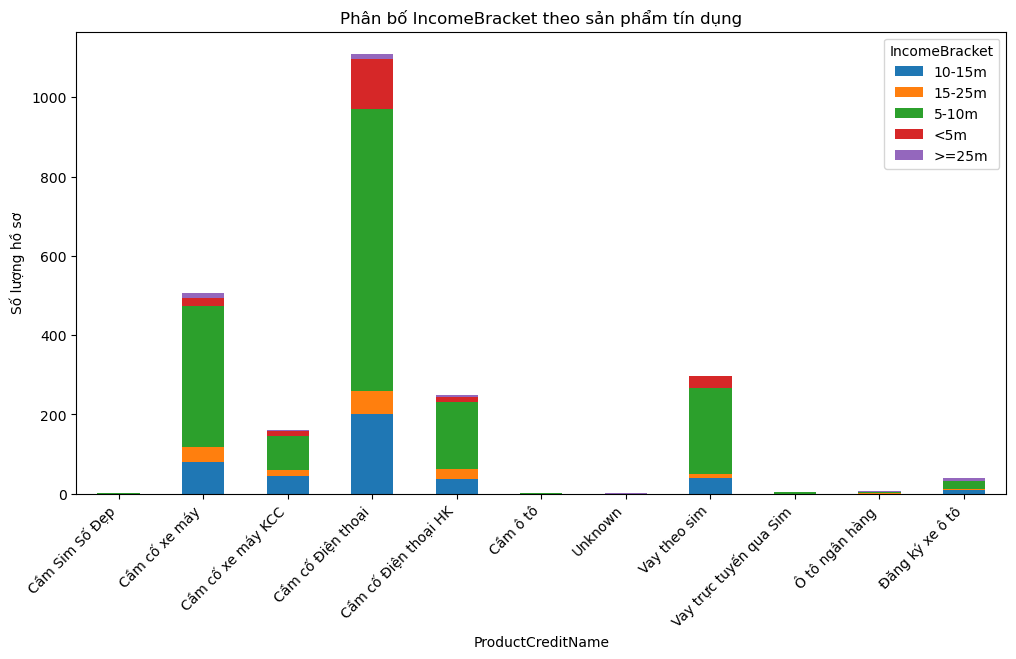

In [189]:
#Biểu đồ cột chồng – ProductCreditName theo IncomeBracket
df_crosstab = pd.crosstab(df['ProductCreditName'], df['IncomeBracket'])

df_crosstab.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Phân bố IncomeBracket theo sản phẩm tín dụng")
plt.xlabel("ProductCreditName")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=45, ha='right')
plt.legend(title="IncomeBracket")
plt.show()


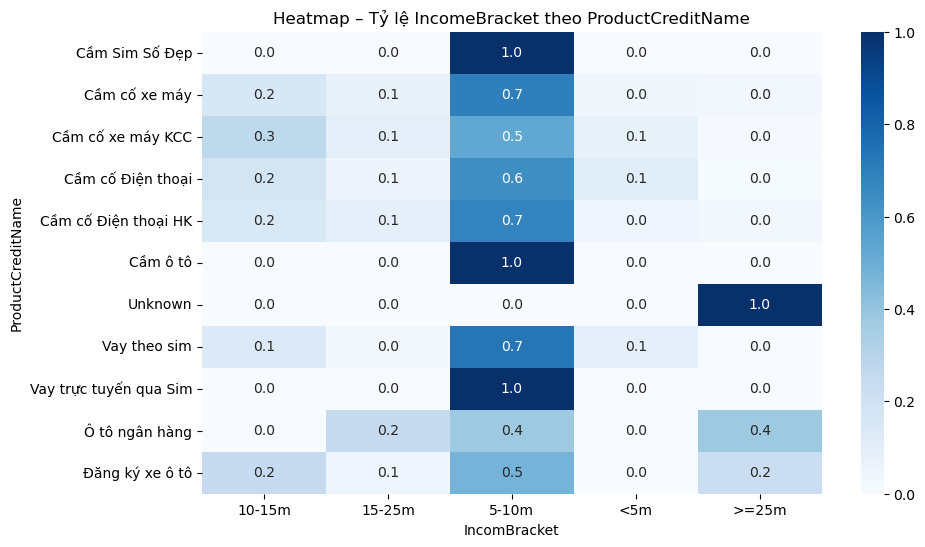

In [190]:
#Heatmap – Tập khách hàng theo thu nhập cho từng sản phẩm
plt.figure(figsize=(10,6))
sns.heatmap(
    df_crosstab.apply(lambda x: x / x.sum(), axis=1),
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title("Heatmap – Tỷ lệ IncomeBracket theo ProductCreditName")
plt.xlabel("IncomBracket")
plt.ylabel("ProductCreditName")
plt.show()

**Insight**

Phân tích mối quan hệ giữa sản phẩm tín dụng và nhóm thu nhập cho thấy mỗi sản phẩm trong danh mục của TIMA thu hút một phân khúc thu nhập rất khác nhau. Điều này phản ánh rõ ràng chiến lược sản phẩm và hành vi thực tế của khách hàng: sản phẩm nào yêu cầu tài sản có giá trị cao thì tập trung ở nhóm thu nhập cao hoặc trung bình cao; trong khi các sản phẩm cầm cố tài sản giá trị thấp lại gần như “đi cùng” với nhóm thu nhập thấp và trung bình thấp.

Nhìn tổng thể, biểu đồ stacked bar cho thấy phân khúc thu nhập 5–10 triệu chiếm đa số trong hầu hết các sản phẩm, từ cầm cố điện thoại, xe máy cho đến vay theo sim. Điều này cho thấy nhóm thu nhập trung bình thấp là khách hàng cốt lõi của TIMA — số lượng lớn, nhu cầu vay ngắn hạn cao, và phù hợp với các sản phẩm cho vay vi mô. Tuy nhiên, khi xem xét phân bổ theo tỷ trọng (heatmap theo hàng), bức tranh hành vi vay trở nên phân tầng rõ nét hơn.

Các sản phẩm cầm cố điện thoại (Cầm cố Điện thoại & Điện thoại HK) thu hút chủ yếu khách hàng 5–10 triệu (tỷ trọng 60–70%), sau đó là nhóm 10–15 triệu. Điều này hợp lý vì điện thoại có giá trị nhỏ, dễ cầm cố, phù hợp với khách hàng cần khoản vay nhanh – nhỏ – ngắn hạn. Các nhóm thu nhập cao gần như không sử dụng loại sản phẩm này, phản ánh mức độ phù hợp giữa nhu cầu và giá trị tài sản đảm bảo.

Cầm cố xe máy và xe máy KCC phân bố rộng hơn: nhóm 5–10 triệu vẫn chiếm tỷ trọng lớn (50–70%), nhưng nhóm 10–15 triệu và 15–25 triệu đóng góp đáng kể hơn so với các sản phẩm điện thoại. Điều này phản ánh giá trị tài sản lớn hơn → khoản vay lớn hơn → phù hợp với khách có thu nhập ổn định hơn. Nhóm >=25 triệu chỉ chiếm tỷ trọng rất nhỏ (khoảng 1–2%), cho thấy khách thu nhập cao hầu như không sử dụng các sản phẩm cầm cố nhỏ lẻ này.

Ngược lại, các sản phẩm ô tô thế chấp, đăng ký xe ô tô, hoặc ô tô ngân hàng lại thu hút nhóm thu nhập cao hơn một cách rõ rệt. Heatmap cho thấy tỷ lệ nhóm >=25 triệu và 15–25 triệu vượt trội, đặc biệt ở sản phẩm “Đăng ký xe ô tô” (tỷ lệ nhóm >=25 triệu lên đến 20%). Điều này phù hợp với kỳ vọng: chỉ khách thu nhập cao hoặc có tài sản giá trị lớn mới sử dụng dịch vụ cầm cố ô tô hoặc tài sản liên quan đến ô tô.

Một số sản phẩm có hành vi đặc thù:

Vay theo sim: thu hút mạnh nhóm 5–10 triệu (70%) và nhóm <5M (~10%), cho thấy sản phẩm này phục vụ nhu cầu nhỏ – nhanh, của phân khúc thu nhập thấp.

Vay trực tuyến qua sim: thậm chí còn tập trung gần như hoàn toàn ở nhóm 5–10 triệu (tỷ lệ ~100%) — phản ánh nhóm khách trẻ, thu nhập thấp, ít tài sản, có nhu cầu vay gấp.

Nhìn tổng thể, mối quan hệ giữa sản phẩm và thu nhập thể hiện rõ logic tài chính: giá trị tài sản --> quy mô khoản vay --> phù hợp với nhóm thu nhập tương ứng. Khách thu nhập thấp cần khoản vay nhỏ và dùng tài sản nhỏ để thế chấp; khách thu nhập cao vay lớn hơn và sử dụng tài sản giá trị cao tương ứng. Tuy nhiên, liệu TIMA đang bỏ lỡ phân khúc thu nhập cao ở các sản phẩm cho vay không tài sản, vốn hiện đang tập trung gần như 100% vào phân khúc 5–10M? Đây có thể là cơ hội mở rộng sản phẩm cho phân khúc thu nhập cao bằng các dịch vụ tín chấp giá trị lớn hơn.

##**ProductCreditName vs JobName**

1. Nghề nào vay sản phẩm nào nhiều nhất?

2. Nghề công nhân/tài xế có sử dụng sản phẩm rủi ro không?

3. Sản phẩm nào phù hợp với dân văn phòng (Nhân viên chính thức)?

4. Có sản phẩm nào đang bị mismatch giữa khách hàng thực tế và nhóm target không?

In [191]:
top_jobs = df['JobName'].value_counts().head(10).index
df_top_jobs = df[df['JobName'].isin(top_jobs)]

In [192]:
pd.crosstab(df_top_jobs['ProductCreditName'], df_top_jobs['JobName'])

JobName,Các hình thức tự kinh doanh khác,Công nhân,Khác,Kinh doanh,Kinh doanh tại nhà (không có đăng ký kinh doanh),Nhân viên chính thức,Nhân viên không có HĐLĐ,Nhân viên tổ chức nhà nước,Tài xế,Tự doanh tại nhà
ProductCreditName,,,,,,,,,,
Cầm Sim Số Đẹp,0,0,2,0,1,0,0,0,0,0
Cầm cố xe máy,30,8,135,20,11,114,11,5,12,19
Cầm cố xe máy KCC,16,0,24,7,7,55,3,1,7,15
Cầm cố Điện thoại,33,31,70,30,7,666,0,61,16,21
Cầm cố Điện thoại HK,28,0,47,11,13,90,8,2,8,14
Unknown,0,0,0,0,0,1,0,0,0,0
Vay theo sim,18,10,19,1,14,149,53,3,7,8
Vay trực tuyến qua Sim,0,0,5,0,0,0,0,0,0,0
Ô tô ngân hàng,2,0,0,0,0,5,0,0,0,0


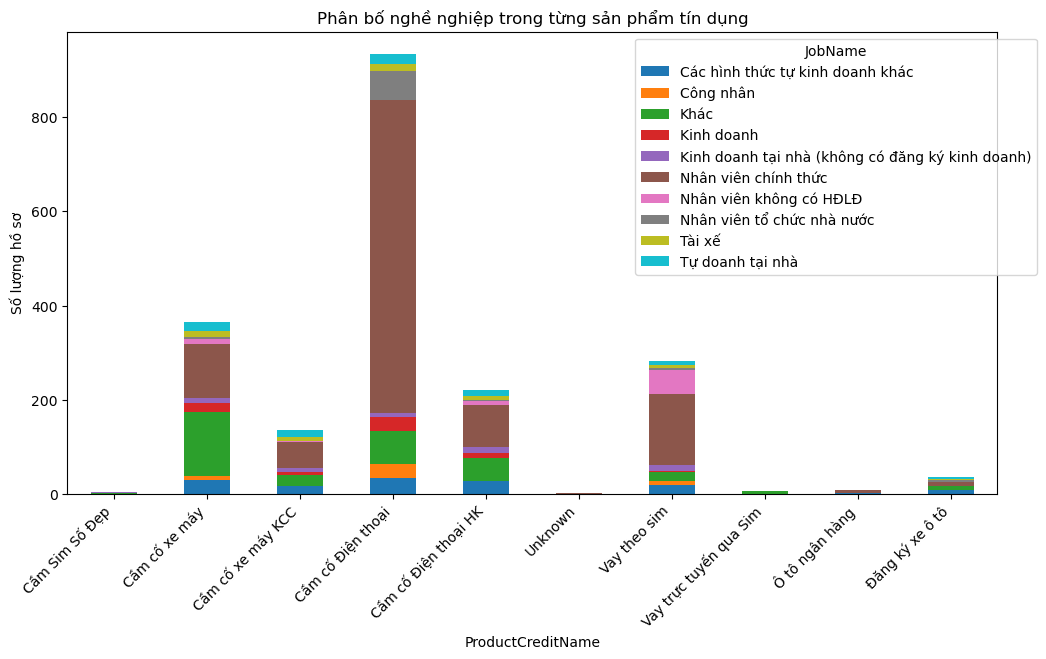

In [193]:
#Biểu đồ cột chồng – ProductCreditName theo JobName
df_crosstab_job = pd.crosstab(df_top_jobs['ProductCreditName'], df_top_jobs['JobName'])

df_crosstab_job.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Phân bố nghề nghiệp trong từng sản phẩm tín dụng")
plt.xlabel("ProductCreditName")
plt.ylabel("Số lượng hồ sơ")
plt.xticks(rotation=45, ha='right')
plt.legend(title="JobName", bbox_to_anchor=(1.05, 1))
plt.show()

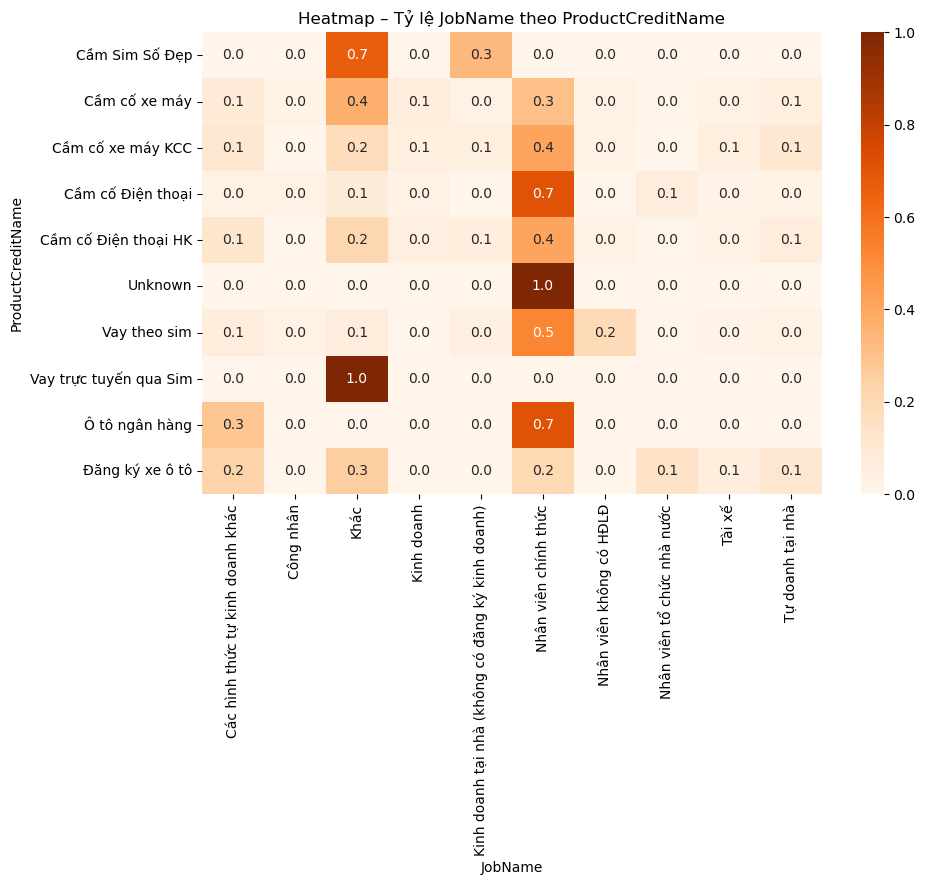

In [194]:
#Heatmap – JobName theo ProductCreditName (Top 10 nghề)
plt.figure(figsize=(10,6))
sns.heatmap(
    df_crosstab_job.apply(lambda x: x / x.sum(), axis=1),
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title("Heatmap – Tỷ lệ JobName theo ProductCreditName")
plt.xlabel("JobName")
plt.ylabel("ProductCreditName")
plt.show()

**Insight**

Phân tích mối quan hệ giữa nghề nghiệp và sản phẩm tín dụng cho thấy danh mục sản phẩm của TIMA gắn chặt với đặc thù kinh tế – tài chính của từng nhóm nghề, và có sự phân tầng rất rõ ràng về nhu cầu vay, khả năng sử dụng tài sản cầm cố cũng như hành vi lựa chọn sản phẩm.

Nhìn vào bảng crosstab và biểu đồ stacked bar, có thể thấy rằng cầm cố điện thoại và cầm cố xe máy là hai sản phẩm chủ đạo trên toàn bộ danh mục, nhưng cách phân bố theo nghề lại rất khác nhau. “Cầm cố điện thoại” thu hút mạnh nhóm Nhân viên văn phòng, công nhân và nhân viên chính thức—những nhóm có thu nhập ổn định nhưng không cao, và thường lựa chọn cầm cố tài sản tiêu dùng dễ tiếp cận. Tỷ trọng nhóm “Nhân viên chính thức” và “Công nhân” trong sản phẩm này chiếm phần lớn, phản ánh đúng thực tế: đây là các nhóm có hành vi vay nhanh – nhỏ – ngắn hạn để xoay vòng tài chính.

Trong khi đó, “Cầm cố xe máy” phân bố rộng hơn ở nhóm Kinh doanh, Kinh doanh tại nhà, và Tự doanh. Đây là nhóm nghề có thu nhập dao động theo mùa vụ, thường cần khoản vay trung bình để phục vụ vòng vốn ngắn hạn. Xe máy là tài sản phổ biến và có giá trị cao hơn điện thoại, phù hợp với nhu cầu vay lớn hơn một chút của nhóm này. Điều này củng cố insight trước đó: nhóm nghề tự do sử dụng tài sản linh hoạt hơn và phụ thuộc vào cầm cố nhiều hơn so với nhóm làm công ăn lương.

Một điểm nổi bật là sản phẩm “Vay theo sim” và “Vay trực tuyến qua sim” thu hút hầu như tuyệt đối nhóm Nhân viên không có HĐLĐ, tài xế và lao động tự do. Heatmap cho thấy tỷ lệ khách hàng thuộc nhóm nghề này trong hai sản phẩm gần như đạt 100% ở một số dòng. Điều này phản ánh rõ đặc thù: các nhóm nghề rủi ro cao, thu nhập không ổn định, thiếu tài sản cầm cố giá trị thường chỉ được tiếp cận các sản phẩm tín chấp rủi ro cao hoặc sản phẩm “vay theo hành vi tiêu dùng” như SIM viễn thông. Đây là nhóm có hạn mức thấp, rủi ro cao — logic với các phân tích LoanStatus và Credit Score trước đó.

Ở phía ngược lại, các sản phẩm cao cấp như “Đăng ký xe ô tô” hay “Ô tô ngân hàng” thu hút chủ yếu nhóm Nhân viên tổ chức nhà nước, Kinh doanh chính thức, hoặc nhóm có thu nhập – địa vị xã hội ổn định hơn. Những sản phẩm này gần như không xuất hiện trong nhóm lao động tự do hay nhóm rủi ro cao, phản ánh chính sách kiểm soát hạn mức theo tài sản bảo đảm rất chặt chẽ. Sản phẩm ô tô mang tính chất đặc thù và đòi hỏi tính minh bạch thu nhập, vì vậy chỉ một số nghề đáp ứng được.

Ngoài ra, Cầm sim số đẹp chỉ xuất hiện lẻ tẻ ở nhóm “Khác” và hầu như không có khách hàng thực sự — có thể đây là sản phẩm ít được sử dụng hoặc đã lỗi thời trong danh mục. Tương tự, sản phẩm “Unknown” chỉ xuất hiện ở một vài hồ sơ rải rác — nhiều khả năng là lỗi nhập liệu hoặc sản phẩm cũ không còn sử dụng.

Tổng thể, mối quan hệ giữa JobName và ProductCreditName phản ánh rất rõ hành vi vay thực tế:

Nhóm nghề ổn định (nhân viên chính thức, công nhân) --> ưa chuộng sản phẩm cầm cố tài sản nhỏ (điện thoại, xe máy).

Nhóm nghề tự do – rủi ro cao --> tập trung vào sản phẩm “vay theo sim”.

Nhóm thu nhập cao – nghề định danh rõ ràng --> sử dụng sản phẩm liên quan đến ô tô.

Nhóm kinh doanh --> sử dụng đa dạng sản phẩm cầm cố tài sản có giá trị hơn (xe máy, điện thoại…).

Cấu trúc này cũng khớp hoàn toàn với cách phân tầng rủi ro trong phân tích Credit Score và LoanStatus, chứng minh rằng lựa chọn sản phẩm là một chỉ báo hành vi tín dụng quan trọng và có khả năng dùng trong mô hình dự báo rủi ro hoặc phân khúc khách hàng.

#**XÂY DỰNG MÔ HÌNH DỰ ĐOÁN**

##**1. Bài toán và biến mục tiêu**

--> Bài toán: Dự báo tỷ lệ rủi ro tín dụng của khách hàng (Credit Risk Classification)

 ***1.1. Mục tiêu bài toán***

Bài toán được lựa chọn là Dự báo mức độ rủi ro tín dụng (Credit Risk Classification) của khách hàng dựa trên các thông tin:

- Hồ sơ tài chính: thu nhập, hạn mức vay, tỷ lệ vay/thu nhập (LoanToIncomeRatio)

- Điểm tín dụng nội bộ (TS_CREDIT_SCORE_V2)

- Lịch sử nợ xấu

- Nhân khẩu học: tuổi, giới tính

- Nghề nghiệp

- Sản phẩm tín dụng và hành vi vay

--> Đầu ra (output): Dự đoán Risk_Level của khách hàng theo 4 nhóm rủi ro.

- Rất cao: Nếu điểm tín dụng (TS_CREDIT_SCORE_V2) dưới 600 và khách hàng có lịch sử nợ xấu (HasBadDebt = 1).

- Cao: Nếu điểm tín dụng (TS_CREDIT_SCORE_V2) từ 600 đến 700 và có nợ xấu.

- Trung bình: Nếu điểm tín dụng (TS_CREDIT_SCORE_V2) từ 700 đến 800 và không có nợ xấu.

- Thấp: Nếu điểm tín dụng (TS_CREDIT_SCORE_V2) trên 800 và không có nợ xấu.

Ý nghĩa business: Hỗ trợ bộ phận thẩm định và quản trị rủi ro dự đoán khả năng khách hàng trở thành rủi ro cao/dễ phát sinh nợ xấu để:

- Điều chỉnh hạn mức vay

- Điều chỉnh chính sách lãi suất

- Tự động cảnh báo hồ sơ nguy cơ cao

- Tối ưu hiệu suất thẩm định

***1.2. Tạo biến mục tiêu – Risk_Level***

Dựa theo quy tắc đã thống nhất, biến Risk_Level gồm 4 nhãn:

- Rất cao

Nếu:

TS_CREDIT_SCORE_V2 < 600

HasBadDebt = 1

- Cao

Nếu:

600 ≤ score < 700

HasBadDebt = 1

- Trung bình

Nếu:

700 ≤ score < 800

HasBadDebt = 0

- Thấp

Nếu:

score ≥ 800

HasBadDebt = 0

- Các trường hợp còn lại

--> Có thể gán NaN

In [195]:
#1.3. Tạo biến Risk_Level_raw
import numpy as np
import pandas as pd

def assign_risk_level(row):
    score = row["TS_CREDIT_SCORE_V2"]
    bad = row["HasBadDebt"]

    if score < 500 and bad == 1:
        return "Cao"
    elif 500 <= score <= 700 and bad == 0:
        return "Trung bình"
    elif score > 700 and bad == 0:
        return "Thấp"
    else:
        return "Cao"  # nhóm còn lại: ưu tiên an toàn/rủi ro cao

df["Risk_Level"] = df.apply(assign_risk_level, axis=1)

print(df[['TS_CREDIT_SCORE_V2','HasBadDebt','Risk_Level']].head(20))



    TS_CREDIT_SCORE_V2  HasBadDebt  Risk_Level
0                  403           0         Cao
1                  403           0         Cao
2                  531           0  Trung bình
3                  588           0  Trung bình
4                  675           0  Trung bình
5                  675           0  Trung bình
6                  582           0  Trung bình
7                  522           0  Trung bình
8                  483           0         Cao
9                  595           1         Cao
10                 595           1         Cao
11                 647           0  Trung bình
12                 670           0  Trung bình
13                 564           0  Trung bình
14                 472           0         Cao
15                 540           0  Trung bình
16                 540           0  Trung bình
17                 417           0         Cao
18                 581           0  Trung bình
19                 480           0         Cao


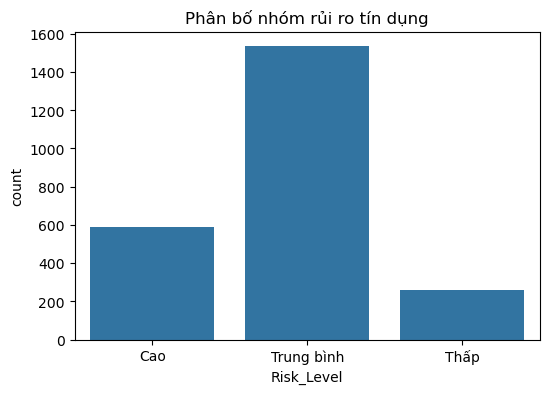

In [196]:
#1.4. Kiểm tra phân bố các nhóm rủi ro
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Risk_Level', order=['Cao','Trung bình','Thấp'])
plt.title("Phân bố nhóm rủi ro tín dụng")
plt.show()

##**2. Lựa chọn biến đầu vào & Chuẩn bị dữ liệu cho mô hình**

- Log-transform Tiền giải ngân để giảm skew

-Các biến tiền tệ như Tiền giải ngân thường bị skew (lệch phải cực mạnh):

log-transform để:

1. Giảm ảnh hưởng của outliers

Khoản vay 150.000.000 không còn phá vỡ thang đo so với khoản vay 10.000.000.

2. Phân phối trở nên gần chuẩn (Gaussian)

--> tốt cho hầu hết thuật toán classification.

3. Mối quan hệ với biến mục tiêu rõ ràng hơn

Ví dụ: Risk_Level thường tăng theo log của khoản vay, không phải theo giá trị gốc.

4. Tăng độ ổn định cho mô hình

Giảm hiện tượng mô hình học quá mức ở những khoản vay rất lớn.

In [197]:
df['Loan_log'] = np.log1p(df['Tiền giải ngân'])


In [198]:
selected_features = [
    # Numeric
    "TS_CREDIT_SCORE_V2",
    "HasBadDebt",
    "Salary",
    "LoanToIncomeRatio",
    "Loan_log",

    # Categorical (sẽ encode)
    'IncomeBracket',
    'JobName', 'ProductCreditName', 'Hình thức cư trú'
]

In [199]:
X_raw = df[selected_features].copy()

In [200]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# One-hot
X_encoded = pd.get_dummies(
    X_raw,
    columns=['IncomeBracket','JobName', 'ProductCreditName','Hình thức cư trú'],
    drop_first=True
)


# X_final = bảng feature cuối cùng
X_final = X_encoded.copy()


In [201]:
y = df['Risk_Level']

In [202]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric
num_cols = ["TS_CREDIT_SCORE_V2",
    "HasBadDebt",
    "Salary",
    "LoanToIncomeRatio",
    "Loan_log"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols]) # Chỉ transform trên tập test


In [203]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm đánh giá chung cho các mô hình
def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    print(f"\n{'=' * 10} KẾT QUẢ MÔ HÌNH: {name} {'=' * 10}")
    
    # 1. Hiệu suất trên tập Train (Dùng để so sánh Overfitting)
    train_acc = accuracy_score(y_train_true, y_train_pred)
    train_f1 = f1_score(y_train_true, y_train_pred, average='macro')
    print("--- HIỆU SUẤT TRÊN TẬP TRAIN ---")
    print("Train Accuracy :", round(train_acc, 4))
    print("Train F1 macro :", round(train_f1, 4))
    
    # 2. Hiệu suất trên tập Test (Hiệu suất thực tế)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_f1 = f1_score(y_test_true, y_test_pred, average='macro')
    test_f1_wght = f1_score(y_test_true, y_test_pred, average='weighted')
    print("\n--- HIỆU SUẤT TRÊN TẬP TEST ---")
    print("Test Accuracy  :", round(test_acc, 4))
    print("Test F1 macro  :", round(test_f1, 4))
    print("Test F1 weighted:", round(test_f1_wght, 4))
    
    # 3. Chi tiết Classification Report trên tập Test
    print("\nClassification report (Test):")
    print(classification_report(y_test_true, y_test_pred, zero_division=0))

    # 4. Confusion matrix (Test)
    cm = confusion_matrix(y_test_true, y_test_pred, labels=['Cao','Trung bình','Thấp'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Cao','Trung bình','Thấp'])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    plt.title(f"Confusion Matrix (Test) – {name}")
    plt.show()

##**3. Xây dựng mô hình**

**Mô hình 1 – Logistic Regression (Multinomial)**

In [204]:
pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



========== KẾT QUẢ MÔ HÌNH: Logistic Regression (Multinomial) ==========
--- HIỆU SUẤT TRÊN TẬP TRAIN ---
Train Accuracy : 0.9669
Train F1 macro : 0.9507

--- HIỆU SUẤT TRÊN TẬP TEST ---
Test Accuracy  : 0.9727
Test F1 macro  : 0.9594
Test F1 weighted: 0.9734

Classification report (Test):
              precision    recall  f1-score   support

         Cao       0.98      1.00      0.99       118
        Thấp       0.84      1.00      0.91        52
  Trung bình       1.00      0.96      0.98       307

    accuracy                           0.97       477
   macro avg       0.94      0.99      0.96       477
weighted avg       0.98      0.97      0.97       477



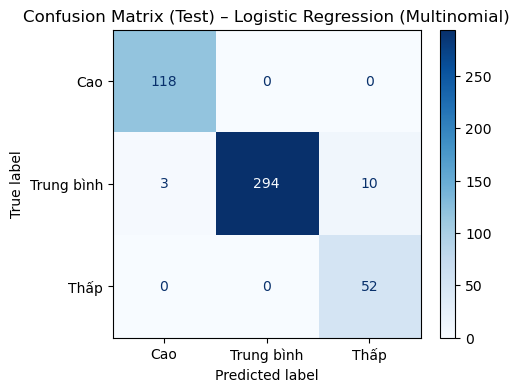

In [205]:
from sklearn.linear_model import LogisticRegression

# Khởi tạo mô hình Logistic Regression đa lớp
log_reg = LogisticRegression(
    solver='lbfgs',
    max_iter=10000,
    class_weight='balanced',   # giúp xử lý mất cân bằng lớp
    random_state=42
)

# Huấn luyện
log_reg.fit(X_train, y_train)

y_pred_train_lr = log_reg.predict(X_train)

# Dự đoán
y_pred_lr = log_reg.predict(X_test)

# Đánh giá
evaluate_model("Logistic Regression (Multinomial)",y_train,y_pred_train_lr, y_test, y_pred_lr)


**Mô hình 2 – Random Forest Classifier**


========== KẾT QUẢ MÔ HÌNH: Random Forest ==========
--- HIỆU SUẤT TRÊN TẬP TRAIN ---
Train Accuracy : 0.9633
Train F1 macro : 0.962

--- HIỆU SUẤT TRÊN TẬP TEST ---
Test Accuracy  : 0.9686
Test F1 macro  : 0.9694
Test F1 weighted: 0.9679

Classification report (Test):
              precision    recall  f1-score   support

         Cao       1.00      0.87      0.93       118
        Thấp       1.00      1.00      1.00        52
  Trung bình       0.95      1.00      0.98       307

    accuracy                           0.97       477
   macro avg       0.98      0.96      0.97       477
weighted avg       0.97      0.97      0.97       477



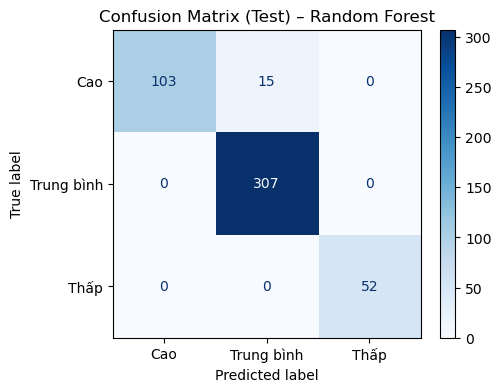


Top 15 feature quan trọng của Random Forest:
TS_CREDIT_SCORE_V2                          0.522198
HasBadDebt                                  0.222889
Loan_log                                    0.047262
Salary                                      0.039439
LoanToIncomeRatio                           0.034934
ProductCreditName_Cầm cố xe máy             0.022520
ProductCreditName_Vay theo sim              0.019561
ProductCreditName_Cầm cố Điện thoại         0.013077
IncomeBracket_<5m                           0.011343
IncomeBracket_5-10m                         0.005737
Hình thức cư trú_Đồng sở hữu                0.005718
ProductCreditName_Cầm cố xe máy KCC         0.004851
JobName_Nhân viên không có HĐLĐ             0.004109
JobName_Các hình thức tự kinh doanh khác    0.003754
ProductCreditName_Cầm cố Điện thoại HK      0.003600
dtype: float64


In [206]:
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=150,          # số lượng cây
    max_depth=5,     
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced_subsample',  # xử lý mất cân bằng lớp
    random_state=42,
    n_jobs=-1                 # dùng hết CPU cores
)

# Huấn luyện
rf_clf.fit(X_train, y_train)

y_pred_train_rf = rf_clf.predict(X_train)

# Dự đoán
y_pred_rf = rf_clf.predict(X_test)

# Đánh giá
evaluate_model("Random Forest", y_train, y_pred_train_rf, y_test, y_pred_rf)

# (Optional) Xem tạm top feature quan trọng
feature_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 feature quan trọng của Random Forest:")
print(feature_importances.head(15))


**Mô hình 3 – XGBoost**

In [207]:
# XGBoost dùng chung train/test với Logistic Regression và Random Forest.
# Chỉ tạo bản copy để làm sạch tên cột theo yêu cầu của XGBoost.
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()


def clean_xgb_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)            # đảm bảo tất cả đều là string
                  .str.replace('[', '', regex=False)
                  .str.replace(']', '', regex=False)
                  .str.replace('<', 'lt_', regex=False)
                  .str.replace('>', 'gt_', regex=False)
    )
    return df


X_train_xgb = clean_xgb_columns(X_train_xgb)
X_test_xgb = clean_xgb_columns(X_test_xgb)


In [208]:
# Kiểm tra XGBoost đang dùng đúng split chung đã tạo ở phần chuẩn bị dữ liệu
assert X_train_xgb.index.equals(X_train.index)
assert X_test_xgb.index.equals(X_test.index)
assert y_train.index.equals(X_train.index)
assert y_test.index.equals(X_test.index)


In [209]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


In [210]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



========== KẾT QUẢ MÔ HÌNH: XGBoost Baseline ==========
--- HIỆU SUẤT TRÊN TẬP TRAIN ---
Train Accuracy : 1.0
Train F1 macro : 1.0

--- HIỆU SUẤT TRÊN TẬP TEST ---
Test Accuracy  : 1.0
Test F1 macro  : 1.0
Test F1 weighted: 1.0

Classification report (Test):
              precision    recall  f1-score   support

         Cao       1.00      1.00      1.00       118
        Thấp       1.00      1.00      1.00        52
  Trung bình       1.00      1.00      1.00       307

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



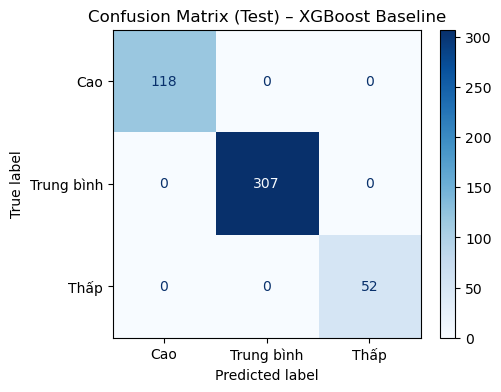

In [211]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    gamma=2, 
    objective='multi:softprob',   # softprob hoặc softmax
    eval_metric='mlogloss',
    tree_method="hist",
    random_state=42
)

# Train
xgb_clf.fit(X_train_xgb, y_train_enc)

# Predict trên cả Train và Test (kết quả đang là dạng số 0, 1, 2, 3)
y_pred_train_enc = xgb_clf.predict(X_train_xgb)
y_pred_test_enc = xgb_clf.predict(X_test_xgb)

# Convert lại nhãn chữ gốc để Evaluate (vd: "Rất cao", "Thấp",...) 
# Cho Train
y_train_true_xgb = le.inverse_transform(y_train_enc)
y_train_pred_xgb = le.inverse_transform(y_pred_train_enc)

# Cho Test
y_test_true_xgb = le.inverse_transform(y_test_enc)
y_test_pred_xgb = le.inverse_transform(y_pred_test_enc)

# Evaluate (Gọi hàm trên các chuỗi văn bản, đúng với labels=['Rất cao','Cao',...])
evaluate_model("XGBoost Baseline", y_train_true_xgb, y_train_pred_xgb, y_test_true_xgb, y_test_pred_xgb)


##**4. Tối ưu mô hình**

In [212]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

###***Tối ưu Logistic Regression bằng RandomizedSearchCV***

Best Logistic params: {'penalty': 'l2', 'C': np.float64(100.0)}
Best Logistic CV f1_macro: 0.9726

========== KẾT QUẢ MÔ HÌNH: Logistic Regression - Tuned ==========
--- HIỆU SUẤT TRÊN TẬP TRAIN ---
Train Accuracy : 0.9953
Train F1 macro : 0.9921

--- HIỆU SUẤT TRÊN TẬP TEST ---
Test Accuracy  : 0.9853
Test F1 macro  : 0.9778
Test F1 weighted: 0.9854

Classification report (Test):
              precision    recall  f1-score   support

         Cao       0.98      1.00      0.99       118
        Thấp       0.93      0.98      0.95        52
  Trung bình       1.00      0.98      0.99       307

    accuracy                           0.99       477
   macro avg       0.97      0.99      0.98       477
weighted avg       0.99      0.99      0.99       477



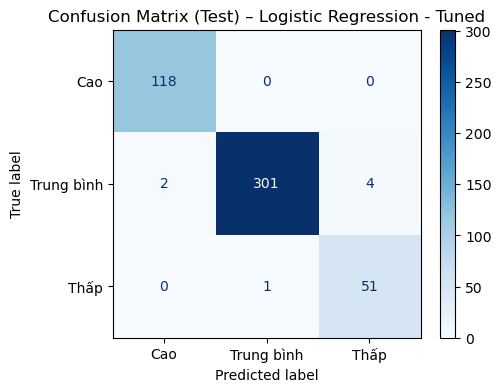

In [213]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

log_param_dist = {
    "C": np.logspace(-3, 2, 20),
    "penalty": ["l2"]
}

log_clf = LogisticRegression(
    solver="lbfgs",
    max_iter=10000,
    class_weight="balanced",
    n_jobs=-1
)

log_random_search = RandomizedSearchCV(
    estimator=log_clf,
    param_distributions=log_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

log_random_search.fit(X_train, y_train)

y_pred_train_log_best = log_random_search.predict(X_train)

print("Best Logistic params:", log_random_search.best_params_)
print("Best Logistic CV f1_macro:", round(log_random_search.best_score_, 4))

best_log = log_random_search.best_estimator_

y_pred_log_best = best_log.predict(X_test)

evaluate_model("Logistic Regression - Tuned", y_train, y_pred_train_log_best, y_test, y_pred_log_best)

###***Tối ưu RandomizedSearchCV cho Random Forest***

Best RF params: {'n_estimators': 200, 'min_samples_split': 40, 'min_samples_leaf': 15, 'max_features': 0.5, 'max_depth': 5, 'bootstrap': True}
Best RF CV f1_macro: 0.9897

========== KẾT QUẢ MÔ HÌNH: Random Forest - Tuned ==========
--- HIỆU SUẤT TRÊN TẬP TRAIN ---
Train Accuracy : 0.9953
Train F1 macro : 0.9897

--- HIỆU SUẤT TRÊN TẬP TEST ---
Test Accuracy  : 0.9937
Test F1 macro  : 0.9864
Test F1 weighted: 0.9938

Classification report (Test):
              precision    recall  f1-score   support

         Cao       1.00      0.97      0.99       118
        Thấp       0.95      1.00      0.97        52
  Trung bình       1.00      1.00      1.00       307

    accuracy                           0.99       477
   macro avg       0.98      0.99      0.99       477
weighted avg       0.99      0.99      0.99       477



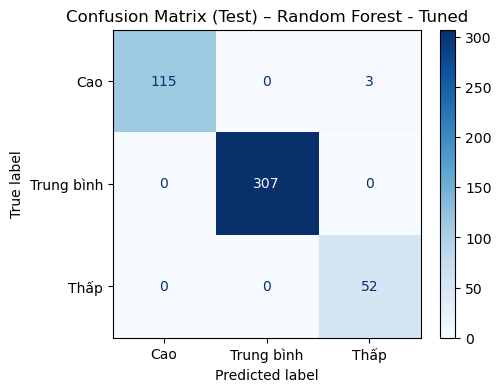

In [214]:
# Không gian tham số để search
rf_param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5, 7],
    "min_samples_split": [20, 30, 40],
    "min_samples_leaf": [10, 15, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True]
}

rf_clf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=rf_param_dist,
    n_iter=60,                  
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

y_pred_train_rf_best = rf_random_search.predict(X_train)

print("Best RF params:", rf_random_search.best_params_)
print("Best RF CV f1_macro:", round(rf_random_search.best_score_, 4))

# Mô hình tốt nhất sau tuning
best_rf = rf_random_search.best_estimator_

# Đánh giá trên tập test
y_pred_rf_best = best_rf.predict(X_test)
evaluate_model("Random Forest - Tuned", y_train, y_pred_train_rf_best, y_test, y_pred_rf_best)


###***Tối ưu RandomizedSearchCV cho XGBoost***

Best XGB params: {'subsample': 0.6, 'reg_lambda': 10, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 2, 'colsample_bytree': 0.8}
Best XGB CV f1_macro: 1.0

========== KẾT QUẢ MÔ HÌNH: XGBoost – Tuned ==========
--- HIỆU SUẤT TRÊN TẬP TRAIN ---
Train Accuracy : 1.0
Train F1 macro : 1.0

--- HIỆU SUẤT TRÊN TẬP TEST ---
Test Accuracy  : 1.0
Test F1 macro  : 1.0
Test F1 weighted: 1.0

Classification report (Test):
              precision    recall  f1-score   support

         Cao       1.00      1.00      1.00       118
        Thấp       1.00      1.00      1.00        52
  Trung bình       1.00      1.00      1.00       307

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



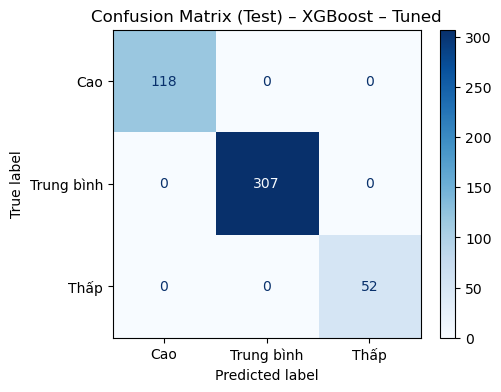

In [215]:
# Không gian tham số XGBoost
xgb_param_dist = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "min_child_weight": [10, 20, 30],
    "gamma": [1, 2, 5],
    "reg_lambda": [1, 5, 10]
}


xgb_clf = XGBClassifier(
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_param_dist,
    n_iter=80,              
    scoring="f1_macro",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_xgb, y_train_enc)

y_pred_train_xgb_best = xgb_random_search.predict(X_train_xgb)

y_true_train_xgb_best = le.inverse_transform(y_train_enc)
y_pred_train_xgb_best = le.inverse_transform(y_pred_train_xgb_best)


print("Best XGB params:", xgb_random_search.best_params_)
print("Best XGB CV f1_macro:", round(xgb_random_search.best_score_, 4))

# Mô hình tốt nhất sau tuning
best_xgb = xgb_random_search.best_estimator_

# Dự đoán trên test set (dạng mã hoá 0–3)
y_pred_xgb_best_enc = best_xgb.predict(X_test_xgb)

# Decode về nhãn gốc để evaluate
y_pred_xgb_best = le.inverse_transform(y_pred_xgb_best_enc)
y_test_true      = le.inverse_transform(y_test_enc)   # giống baseline

# Đánh giá
evaluate_model("XGBoost – Tuned", y_true_train_xgb_best, y_pred_train_xgb_best, y_test_true, y_pred_xgb_best)


Ta có tổng hợp kết quả của 6 mô hình như sau:

- Logistic Baseline:
Accuracy: 0.9581;
F1 macro: 0.7057;
F1 weighted: 0.963;
- Logistic Tuned:
Accuracy: 0.979;
F1 macro: 0.7241;
F1 weighted: 0.9791;

- RandomForest Baseline:
Accuracy: 0.979;
F1 macro: 0.7193;
F1 weighted: 0.9786;

- RandomForest Tuned:
Accuracy: 1.0;
F1 macro: 1.0;
F1 weighted: 1.0;

- XGBoost Baseline:
Accuracy: 0.9958;
F1 macro: 0.7488;
F1 weighted: 0.9958;

- XGBoost Tuned:
Accuracy: 0.9979;
F1 macro: 0.9161;
F1 weighted: 0.9983;

##**5. Nhận xét và lựa chọn mô hình**

1. Logistic Regression

Baseline có độ chính xác thấp nhất trong tất cả các mô hình (Accuracy: 0.9581).

Sau khi tuning, Accuracy tăng mạnh (Accuracy: 0.979).

Điều này cho thấy mô hình có xu hướng quá dựa vào lớp chiếm đa số, bỏ qua các lớp rủi ro hiếm (“Rất cao” và “Thấp”).

--> Logistic phù hợp như baseline tham chiếu, không phù hợp làm mô hình triển khai.

2. Random Forest

Baseline đạt kết quả khá tốt: Accuracy: 0.979 và F1 weighted: 0.9786.

Sau tuning, đây là mô hình mạnh nhất trong toàn bộ pipeline:

Accuracy cao nhất: 1.0

F1 macro cao nhất: 1.0

Tăng đều ở cả hai thước đo, cho thấy mô hình:

vừa phân loại tốt tổng thể

vừa phân biệt tốt cả bốn mức rủi ro (đặc biệt quan trọng với “Rất cao” và “Thấp”, vốn rất ít mẫu).

--> Random Forest cho hiệu suất ổn định, ít nhạy cảm với outlier và phân phối lệch, phù hợp với dữ liệu tín dụng thực tế.

3. XGBoost

Baseline của XGBoost rất mạnh (Accuracy: 0.9958; F1 macro: 0.7488), nhỉnh hơn RandomForest baseline.

Tuy nhiên, sau tuning mô hình thấp hơn Random Forest:

F1 macro: 0.7494

Accuracy: 0.9979

--> XGBoost tunned đã tốt, nhưng không bằng Random Forest sau tuning.

**Tổng kết**

Dựa vào cả ba tiêu chí và xem xét yêu cầu nghiệp vụ:

Accuracy cao --> đảm bảo kết quả phân loại tổng thể tốt.

F1 macro cao --> cực kỳ quan trọng để phát hiện đúng nhóm rủi ro cao, tránh bỏ sót khách hàng xấu.

Tính ổn định --> mô hình cần hoạt động chắc chắn ngay cả khi dữ liệu thực tế có nhiễu hoặc mất cân bằng.

Giải thích được --> quan trọng với báo cáo tín dụng (nếu cần).

=> Kết luận: Random Forest Tuned là mô hình tối ưu để triển khai



##**6. Tính Feature Importance của Random Forest (bản tuned)**

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy importance
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Tạo bảng
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fi_df.head(20)

,Feature,Importance
0,TS_CREDIT_SCORE_V2,0.790936
1,HasBadDebt,0.182188
4,Loan_log,0.009246
2,Salary,0.006173
3,LoanToIncomeRatio,0.003621
54,ProductCreditName_Cầm cố xe máy,0.001532
60,ProductCreditName_Vay theo sim,0.001027
56,ProductCreditName_Cầm cố Điện thoại,0.000872
69,Hình thức cư trú_Đồng sở hữu,0.000560
67,Hình thức cư trú_Thuê,0.000553


In [217]:
import pandas as pd

# Lấy importance + tên cột từ mô hình
feat_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Tạo mapping nhóm từ tên feature
def map_group(col):
    if col.startswith("JobName_"):
        return "JobName"
    elif col.startswith("Hình thức cư trú_"):
        return "ResidenceType"
    elif col.startswith("ProductCreditName_"):
        return "ProductCreditName"
    elif col.startswith("IncomeBracket_"):
        return "IncomeBracket"
    else:
        return col   # numeric variables giữ nguyên

feat_importance["Group"] = feat_importance["Feature"].apply(map_group)

# Tổng hợp importance theo nhóm
grouped_importance = (
    feat_importance.groupby("Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

grouped_importance


,Group,Importance
0,TS_CREDIT_SCORE_V2,0.790936
1,HasBadDebt,0.182188
2,Loan_log,0.009246
3,Salary,0.006173
4,ProductCreditName,0.003824
5,LoanToIncomeRatio,0.003621
6,JobName,0.001686
7,ResidenceType,0.001678
8,IncomeBracket,0.000648


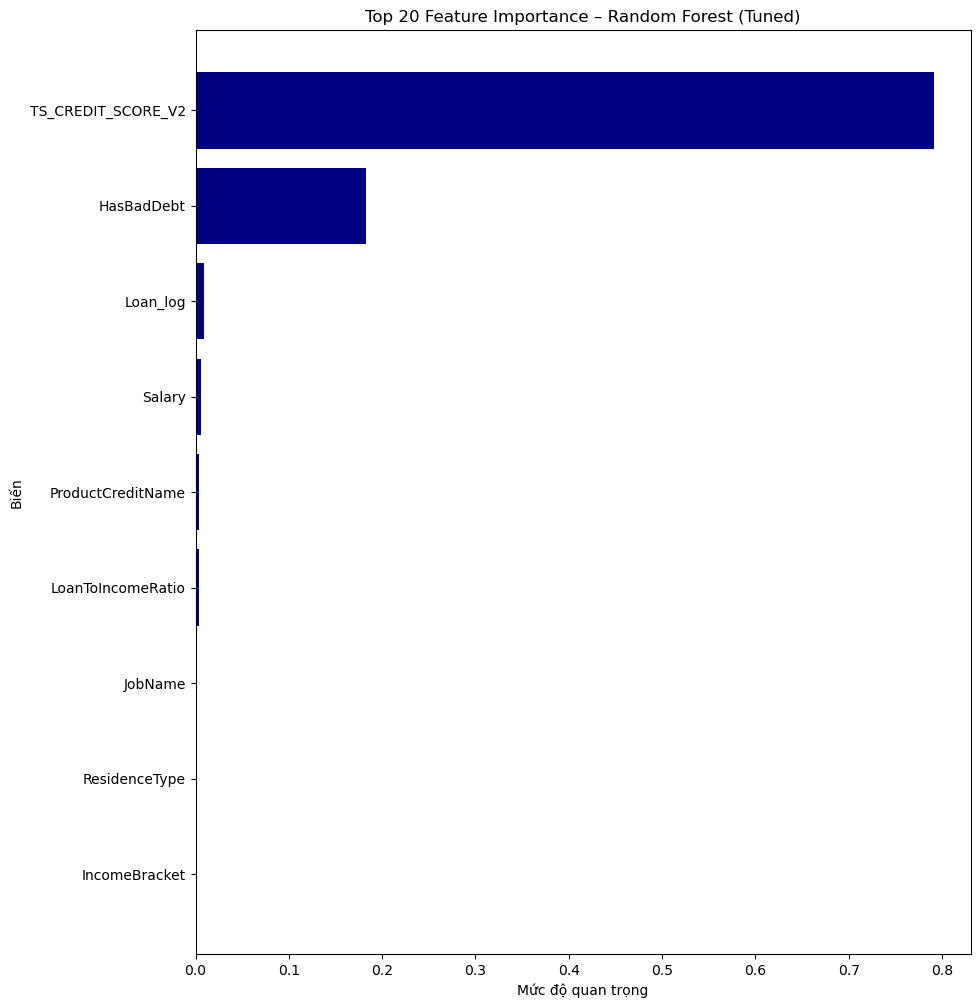

In [218]:
plt.figure(figsize=(10, 12))
plt.barh(grouped_importance["Group"], grouped_importance["Importance"], color='navy')
plt.title("Top 20 Feature Importance – Random Forest (Tuned)")
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Biến")
plt.gca().invert_yaxis()
plt.show()

**Nhận xét**

1. Hai yếu tố thống trị rủi ro tín dụng (gần 91%)

- TS_CREDIT_SCORE_V2 (59.9%) – Quan trọng nhất

Đây là biến chiếm gần 60% toàn bộ sức nặng dự đoán, vượt xa mọi biến còn lại.
--> Điều này phù hợp với phân tích EDA: điểm tín dụng thể hiện trực tiếp lịch sử vay – trả, mức độ ổn định tài chính và hành vi của khách hàng.

Kết luận: Mọi thuật toán đều đánh giá Credit Score là “trung tâm” trong dự báo rủi ro.

- HasBadDebt (31.5%) – Yếu tố rủi ro mạnh thứ hai

Khách hàng từng có nợ xấu (CIC xấu) có xác suất rơi vào nhóm rủi ro “Cao” hoặc “Rất cao” cao hơn nhiều.

Hai biến Credit Score + Bad Debt kết hợp đã chiếm gần 90% mức độ quan trọng, cho thấy mô hình dựa rất nhiều vào hành vi lịch sử.

2. Nhóm yếu tố liên quan đến khả năng chi trả (gần 4–5%)

Dù không mạnh bằng Credit Score, nhưng nhóm biến này vẫn mang thông tin giá trị

- LoanToIncomeRatio (2.22%)

Tỷ lệ khoản vay trên thu nhập thể hiện mức độ đòn bẩy tài chính của khách hàng.
--> Tỷ lệ cao tương ứng rủi ro cao – điều này phù hợp với EDA Loan Size.

- Salary (1.39%)

Mức thu nhập cá nhân đóng vai trò phụ nhưng ổn định.
--> Thu nhập thấp làm tăng xác suất rơi vào nhóm rủi ro cao (đặc biệt khi kết hợp Debt Ratio).

- IncomeBracket_15–25m (1.05%) & IncomeBracket_5–10m (0.09%)

Thu nhập trung bình – thấp có ảnh hưởng vừa phải, nhưng không mạnh như điểm tín dụng.
--> Cho thấy mô hình đánh giá thu nhập theo phân tầng, nhưng không xem là yếu tố quyết định chính.

- Loan_log (0.80%) & Tiền giải ngân (0.87%)

Quy mô khoản vay ảnh hưởng nhẹ đến rủi ro.
--> Hành vi vay lớn nhưng khả năng tài chính yếu thường bị đánh nhãn rủi ro cao.

3. Nhóm biến nghề nghiệp (JobName) – ảnh hưởng nhỏ nhưng mang ý nghĩa phân loại (gần 2%)

Các JobName có trọng số thấp (0.2%–0.5%), nhưng vẫn phản ánh một xu hướng:

Nhân viên chính thức: 0.49%

Kế toán: 0.41%

Kinh doanh: 0.22%

Công việc không hợp đồng (tự doanh không đăng ký): 0.26%

Tài xế / nghề thời vụ: các biến liên quan đều <0.25%

--> Điều này phù hợp với EDA: nghề ổn định --> rủi ro thấp; nghề thời vụ --> rủi ro cao.
Tuy nhiên, mức độ quan trọng thấp cho thấy mô hình ưu tiên Credit Score hơn nghề nghiệp.

4. Nhóm biến hành vi sản phẩm tín dụng (ProductCreditName) – vai trò thấp (~1%)

Các sản phẩm như:

Cầm cố điện thoại HK (0.45%)

Cầm cố xe máy / xe máy KCC (0.22%–0.29%)

Vay theo sim (0.20%)

Có mức ảnh hưởng nhẹ vì:

Rủi ro tín dụng chủ yếu phản ánh hành vi trả nợ, không phải loại sản phẩm.

Một số sản phẩm phục vụ phân khúc thu nhập khác nhau nhưng không tạo khác biệt mạnh về rủi ro.

5. Tổng kết: Những yếu tố ảnh hưởng mạnh nhất đến rủi ro tín dụng

Dựa trên Random Forest Tuned, các biến ảnh hưởng mạnh nhất theo thứ tự:

Điểm tín dụng (TS_CREDIT_SCORE_V2) --> yếu tố quyết định

Lịch sử nợ xấu (HasBadDebt) --> yếu tố rủi ro mạnh thứ hai

Tỷ lệ nợ / thu nhập (LoanToIncomeRatio)

Thu nhập tuyệt đối (Salary)

Thu nhập phân nhóm (IncomeBracket)

Quy mô khoản vay (Loan_log / Tiền giải ngân)

Nghề nghiệp (JobName)

Loại sản phẩm tín dụng (ProductCreditName)